In [1]:
# Cell 1: Start Core bucket parameter research notebook
#
# Objective:
#   Start a clean notebook for Core bucket parameters.
#
# Scope:
#   - Create new processed/audit folders
#   - Load locked 30D Core / Core Back har_downside_v1 specification
#   - Freeze Core Back parameters
#   - Define tenor bucket framework
#   - Save a Core bucket research manifest
#
# Explicitly NOT doing:
#   - No Core Back retesting
#   - No Core Middle testing yet
#   - No Core Front testing yet
#   - No threshold optimization
#   - No Secondary
#   - No sizing
#   - No cross-tenor portfolio test yet

from pathlib import Path
import json
import numpy as np
import pandas as pd


# =============================================================================
# 0. Paths and constants
# =============================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

LOCKED_30D_BRANCH = "vrp_30d_corsi_v1"
NEW_BRANCH = "vrp_core_bucket_parameters_v1"

LOCKED_30D_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / LOCKED_30D_BRANCH
LOCKED_30D_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / LOCKED_30D_BRANCH

NEW_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / NEW_BRANCH
NEW_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / NEW_BRANCH
NEW_NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / NEW_BRANCH

NEW_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
NEW_AUDIT_DIR.mkdir(parents=True, exist_ok=True)
NEW_NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

print("Cell 1: Start Core bucket parameter research notebook")
print(f"Project root:             {PROJECT_ROOT}")
print(f"Locked 30D processed:     {LOCKED_30D_PROCESSED_DIR}")
print(f"Locked 30D audit:         {LOCKED_30D_AUDIT_DIR}")
print(f"New processed dir:        {NEW_PROCESSED_DIR}")
print(f"New audit dir:            {NEW_AUDIT_DIR}")
print(f"New notebook dir:         {NEW_NOTEBOOK_DIR}")
print(f"Run timestamp:            {RUN_TIMESTAMP}")


# =============================================================================
# 1. Helpers
# =============================================================================

def latest_file(directory: Path, pattern: str) -> Path:
    matches = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not matches:
        raise FileNotFoundError(f"No files found in {directory} matching pattern: {pattern}")
    return matches[0]


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def add_validation(rows, check_name, passed, details):
    rows.append({
        "check": check_name,
        "status": "PASS" if bool(passed) else "FAIL",
        "details": details,
    })


# =============================================================================
# 2. Load locked Core Back / 30D Core specification
# =============================================================================

locked_model_spec_path = latest_file(
    LOCKED_30D_AUDIT_DIR,
    "04_30d_core_har_downside_locked_model_spec_*.json",
)

lock_decision_path = latest_file(
    LOCKED_30D_AUDIT_DIR,
    "04_30d_core_har_downside_lock_decision_*.csv",
)

lock_checks_path = latest_file(
    LOCKED_30D_AUDIT_DIR,
    "04_30d_core_har_downside_lock_checks_*.csv",
)

locked_feature_set_path = latest_file(
    LOCKED_30D_AUDIT_DIR,
    "04_30d_core_har_downside_locked_feature_set_*.csv",
)

locked_thresholds_path = latest_file(
    LOCKED_30D_AUDIT_DIR,
    "04_30d_core_har_downside_locked_thresholds_*.csv",
)

locked_signal_panel_path = latest_file(
    LOCKED_30D_PROCESSED_DIR,
    "04_30d_core_har_downside_locked_signal_panel_*.parquet",
)

with open(locked_model_spec_path, "r") as f:
    locked_model_spec = json.load(f)

lock_decision = normalize_columns(pd.read_csv(lock_decision_path))
lock_checks = normalize_columns(pd.read_csv(lock_checks_path))
locked_feature_set = normalize_columns(pd.read_csv(locked_feature_set_path))
locked_thresholds = normalize_columns(pd.read_csv(locked_thresholds_path))
locked_signal_panel = normalize_columns(pd.read_parquet(locked_signal_panel_path))

if "date" in locked_signal_panel.columns:
    locked_signal_panel["date"] = pd.to_datetime(locked_signal_panel["date"], errors="coerce").dt.normalize()

print()
print("Locked Core Back / 30D Core files loaded:")
display(pd.DataFrame([
    {"role": "locked_model_spec_json", "path": str(locked_model_spec_path), "rows": 1},
    {"role": "lock_decision", "path": str(lock_decision_path), "rows": len(lock_decision)},
    {"role": "lock_checks", "path": str(lock_checks_path), "rows": len(lock_checks)},
    {"role": "locked_feature_set", "path": str(locked_feature_set_path), "rows": len(locked_feature_set)},
    {"role": "locked_thresholds", "path": str(locked_thresholds_path), "rows": len(locked_thresholds)},
    {"role": "locked_signal_panel", "path": str(locked_signal_panel_path), "rows": len(locked_signal_panel)},
]))


# =============================================================================
# 3. Validate locked Core Back package
# =============================================================================

validation_rows = []

decision_value = str(lock_decision.loc[0, "decision"]) if "decision" in lock_decision.columns and len(lock_decision) else None

add_validation(
    validation_rows,
    "Locked decision is LOCK",
    decision_value == "LOCK",
    f"decision={decision_value}",
)

add_validation(
    validation_rows,
    "All lock checks passed",
    lock_checks["status"].astype(str).eq("PASS").all(),
    f"failed_checks={lock_checks.loc[~lock_checks['status'].astype(str).eq('PASS'), 'check'].tolist()}",
)

add_validation(
    validation_rows,
    "Locked model is har_downside_v1",
    locked_model_spec.get("model_name") == "har_downside_v1",
    f"model_name={locked_model_spec.get('model_name')}",
)

add_validation(
    validation_rows,
    "Locked use case is 30D Core VRP denominator",
    locked_model_spec.get("locked_use_case") == "30D Core VRP denominator",
    f"locked_use_case={locked_model_spec.get('locked_use_case')}",
)

required_features = [
    "log_rv_1d",
    "log_rv_std_5d",
    "log_rv_std_21d",
    "log_rv_std_63d",
    "log_downside_rv_5d",
    "log_downside_rv_21d",
    "log_downside_rv_63d",
    "downside_share_21d",
    "negative_return_count_21d",
]

actual_features = locked_feature_set["feature"].astype(str).tolist()

add_validation(
    validation_rows,
    "Locked feature set matches expected har_downside_v1 features",
    actual_features == required_features,
    f"actual_features={actual_features}",
)

expected_thresholds = {
    "forecast_vol_30d_pct_min": 8.5,
    "model_vrp_z_3m_min": 0.7,
    "model_vrp_z_1y_min": 0.7,
    "rsi14_max": 70.0,
    "model_vrp_log_min": 0.7,
}

threshold_dict = dict(zip(locked_thresholds["threshold"], locked_thresholds["value"]))

thresholds_match = all(
    k in threshold_dict and np.isclose(float(threshold_dict[k]), float(v))
    for k, v in expected_thresholds.items()
)

add_validation(
    validation_rows,
    "Locked thresholds match expected Core Back parameters",
    thresholds_match,
    f"threshold_dict={threshold_dict}",
)

validation = pd.DataFrame(validation_rows)

print()
print("Cell 1 validation checks:")
display(validation)

if validation["status"].eq("FAIL").any():
    print()
    print("FAILED VALIDATION CHECKS:")
    display(validation.loc[validation["status"].eq("FAIL")])
    raise ValueError("Cell 1 validation failed. Stop before Core Middle/Front research.")


# =============================================================================
# 4. Freeze Core Back bucket parameters
# =============================================================================

core_back_parameters = pd.DataFrame([
    {
        "bucket": "Back",
        "signal_tier": "Core",
        "parameter": "denominator_model",
        "operator": "=",
        "value": "har_downside_v1_forecast_variance",
        "locked_status": "LOCKED",
        "notes": "Locked from 30D Core Cell 4 package",
    },
    {
        "bucket": "Back",
        "signal_tier": "Core",
        "parameter": "model_vrp_log",
        "operator": ">",
        "value": 0.70,
        "locked_status": "LOCKED",
        "notes": "VRP = log(implied variance / forecast variance)",
    },
    {
        "bucket": "Back",
        "signal_tier": "Core",
        "parameter": "model_vrp_z_3m",
        "operator": ">",
        "value": 0.70,
        "locked_status": "LOCKED",
        "notes": "Prior-only 63 trading day z-score",
    },
    {
        "bucket": "Back",
        "signal_tier": "Core",
        "parameter": "model_vrp_z_1y",
        "operator": ">",
        "value": 0.70,
        "locked_status": "LOCKED",
        "notes": "Prior-only 252 trading day z-score",
    },
    {
        "bucket": "Back",
        "signal_tier": "Core",
        "parameter": "rsi14",
        "operator": "<",
        "value": 70.0,
        "locked_status": "LOCKED",
        "notes": "Same RSI cap as locked 30D Core",
    },
    {
        "bucket": "Back",
        "signal_tier": "Core",
        "parameter": "forecast_vol_pct",
        "operator": ">",
        "value": 8.5,
        "locked_status": "LOCKED",
        "notes": "Forecast vol floor using har_downside_v1 forecast variance",
    },
])

print()
print("Frozen Core Back bucket parameters:")
display(core_back_parameters)


# =============================================================================
# 5. Define bucket framework for next cells
# =============================================================================

# This is the working bucket map for the next cells.
# We can revise exact tenor boundaries before testing if needed.
# Core Back is locked. Core Middle and Core Front are not locked yet.

tenor_bucket_framework = pd.DataFrame([
    {
        "bucket": "Front",
        "approx_tenor_range": "short-dated / front bucket",
        "status": "TO_RESEARCH",
        "notes": "Next after Core Middle. Expect most sensitive to realized/forecast variance noise.",
    },
    {
        "bucket": "Middle",
        "approx_tenor_range": "intermediate bucket",
        "status": "TO_RESEARCH_NEXT",
        "notes": "Next focus. Use Core Back as anchor, avoid reopening Core Back.",
    },
    {
        "bucket": "Back",
        "approx_tenor_range": "30D / back bucket anchor for current framework",
        "status": "LOCKED",
        "notes": "Use locked Core Back parameters from har_downside_v1.",
    },
])

print()
print("Tenor bucket framework:")
display(tenor_bucket_framework)


# =============================================================================
# 6. Save Cell 1 outputs
# =============================================================================

manifest = pd.DataFrame([
    {"role": "locked_model_spec_json", "path": str(locked_model_spec_path)},
    {"role": "lock_decision", "path": str(lock_decision_path)},
    {"role": "lock_checks", "path": str(lock_checks_path)},
    {"role": "locked_feature_set", "path": str(locked_feature_set_path)},
    {"role": "locked_thresholds", "path": str(locked_thresholds_path)},
    {"role": "locked_signal_panel", "path": str(locked_signal_panel_path)},
    {"role": "new_processed_dir", "path": str(NEW_PROCESSED_DIR)},
    {"role": "new_audit_dir", "path": str(NEW_AUDIT_DIR)},
    {"role": "new_notebook_dir", "path": str(NEW_NOTEBOOK_DIR)},
])

safe_start = locked_signal_panel["date"].min().strftime("%Y%m%d") if "date" in locked_signal_panel.columns else "unknown_start"
safe_end = locked_signal_panel["date"].max().strftime("%Y%m%d") if "date" in locked_signal_panel.columns else "unknown_end"

validation_path = (
    NEW_AUDIT_DIR
    / f"01_core_bucket_research_start_validation_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.csv"
)

core_back_parameters_path = (
    NEW_AUDIT_DIR
    / f"01_locked_core_back_parameters_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.csv"
)

tenor_bucket_framework_path = (
    NEW_AUDIT_DIR
    / f"01_tenor_bucket_framework_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.csv"
)

manifest_path = (
    NEW_AUDIT_DIR
    / f"01_core_bucket_research_manifest_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.csv"
)

locked_model_spec_copy_path = (
    NEW_AUDIT_DIR
    / f"01_locked_core_back_model_spec_copy_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.json"
)

validation.to_csv(validation_path, index=False)
core_back_parameters.to_csv(core_back_parameters_path, index=False)
tenor_bucket_framework.to_csv(tenor_bucket_framework_path, index=False)
manifest.to_csv(manifest_path, index=False)

with open(locked_model_spec_copy_path, "w") as f:
    json.dump(locked_model_spec, f, indent=4, default=str)

print()
print("Cell 1 outputs saved:")
print(f"Validation:                 {validation_path}")
print(f"Locked Core Back params:     {core_back_parameters_path}")
print(f"Tenor bucket framework:      {tenor_bucket_framework_path}")
print(f"Manifest:                    {manifest_path}")
print(f"Locked model spec copy:      {locked_model_spec_copy_path}")

print()
print("Cell 1 complete.")
print()
print("Next proposed cell:")
print("Cell 2: Build candidate Core Middle / Core Front signal panels using the locked denominator methodology.")
print("Core Back remains frozen and is not under test.")

Cell 1: Start Core bucket parameter research notebook
Project root:             C:\Users\patri\vrp_project
Locked 30D processed:     C:\Users\patri\vrp_project\data\processed\vrp_30d_corsi_v1
Locked 30D audit:         C:\Users\patri\vrp_project\data\audit\vrp_30d_corsi_v1
New processed dir:        C:\Users\patri\vrp_project\data\processed\vrp_core_bucket_parameters_v1
New audit dir:            C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1
New notebook dir:         C:\Users\patri\vrp_project\notebooks\vrp_core_bucket_parameters_v1
Run timestamp:            20260704_170933

Locked Core Back / 30D Core files loaded:


,role,path,rows
0,locked_model_spec_json,C:\Users\patri\vrp_project\data\audit\vrp_30d_...,1
1,lock_decision,C:\Users\patri\vrp_project\data\audit\vrp_30d_...,1
2,lock_checks,C:\Users\patri\vrp_project\data\audit\vrp_30d_...,15
3,locked_feature_set,C:\Users\patri\vrp_project\data\audit\vrp_30d_...,9
4,locked_thresholds,C:\Users\patri\vrp_project\data\audit\vrp_30d_...,5
5,locked_signal_panel,C:\Users\patri\vrp_project\data\processed\vrp_...,1354



Cell 1 validation checks:


,check,status,details
0,Locked decision is LOCK,PASS,decision=LOCK
1,All lock checks passed,PASS,failed_checks=[]
2,Locked model is har_downside_v1,PASS,model_name=har_downside_v1
3,Locked use case is 30D Core VRP denominator,PASS,locked_use_case=30D Core VRP denominator
4,Locked feature set matches expected har_downsi...,PASS,"actual_features=['log_rv_1d', 'log_rv_std_5d',..."
5,Locked thresholds match expected Core Back par...,PASS,threshold_dict={'forecast_vol_30d_pct_min': 8....



Frozen Core Back bucket parameters:


,bucket,signal_tier,parameter,operator,value,locked_status,notes
0,Back,Core,denominator_model,=,har_downside_v1_forecast_variance,LOCKED,Locked from 30D Core Cell 4 package
1,Back,Core,model_vrp_log,>,0.7,LOCKED,VRP = log(implied variance / forecast variance)
2,Back,Core,model_vrp_z_3m,>,0.7,LOCKED,Prior-only 63 trading day z-score
3,Back,Core,model_vrp_z_1y,>,0.7,LOCKED,Prior-only 252 trading day z-score
4,Back,Core,rsi14,<,70.0,LOCKED,Same RSI cap as locked 30D Core
5,Back,Core,forecast_vol_pct,>,8.5,LOCKED,Forecast vol floor using har_downside_v1 forec...



Tenor bucket framework:


,bucket,approx_tenor_range,status,notes
0,Front,short-dated / front bucket,TO_RESEARCH,Next after Core Middle. Expect most sensitive ...
1,Middle,intermediate bucket,TO_RESEARCH_NEXT,"Next focus. Use Core Back as anchor, avoid reo..."
2,Back,30D / back bucket anchor for current framework,LOCKED,Use locked Core Back parameters from har_downs...



Cell 1 outputs saved:
Validation:                 C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\01_core_bucket_research_start_validation_20201231_20260522_20260704_170933.csv
Locked Core Back params:     C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\01_locked_core_back_parameters_20201231_20260522_20260704_170933.csv
Tenor bucket framework:      C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\01_tenor_bucket_framework_20201231_20260522_20260704_170933.csv
Manifest:                    C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\01_core_bucket_research_manifest_20201231_20260522_20260704_170933.csv
Locked model spec copy:      C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\01_locked_core_back_model_spec_copy_20201231_20260522_20260704_170933.json

Cell 1 complete.

Next proposed cell:
Cell 2: Build candidate Core Middle / Core Front signal panels using the locked denominator meth

In [5]:
# Cell 2: Build cross-tenor Core signal base panel
#
# Objective:
#   Build the clean cross-tenor research panel for Core Front / Middle / Back parameter work.
#
# Scope:
#   - Use exact fixed tenor grid:
#         Front:   9, 12, 15
#         Middle: 18, 21, 24
#         Back:   27, 30, 33
#   - Load latest available cross-tenor Corsi / VRP signal source.
#   - Canonicalize implied variance, forecast variance, forecast vol, VRP, z-scores, RSI, outcomes.
#   - Recompute model_vrp_log from implied_variance / forecast_variance.
#   - Recompute prior-only z-scores by tenor.
#   - Save base panel and availability files.
#
# Explicitly NOT doing:
#   - No Core Back retesting.
#   - No Core Front parameter sweep.
#   - No Core Middle parameter sweep.
#   - No Secondary.
#   - No sizing.
#   - No threshold optimization.
#
# Important:
#   - Bucket thresholds will be bucket-level parameters.
#   - Within each bucket, all tenors will share the same 3m and 1y z-score thresholds.
#   - Middle parameters must be equal to or between Front and Back in later tests.

from pathlib import Path
import json
import numpy as np
import pandas as pd


# =============================================================================
# 0. Paths and constants
# =============================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

NEW_BRANCH = "vrp_core_bucket_parameters_v1"
LOCKED_30D_BRANCH = "vrp_30d_corsi_v1"
CROSS_TENOR_SOURCE_BRANCH = "forecast_model_corsi_v1"

NEW_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / NEW_BRANCH
NEW_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / NEW_BRANCH

LOCKED_30D_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / LOCKED_30D_BRANCH
LOCKED_30D_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / LOCKED_30D_BRANCH

SOURCE_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / CROSS_TENOR_SOURCE_BRANCH
SOURCE_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / CROSS_TENOR_SOURCE_BRANCH

NEW_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
NEW_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

TENOR_GRID = [9, 12, 15, 18, 21, 24, 27, 30, 33]

TENOR_TO_BUCKET = {
    9: "Front",
    12: "Front",
    15: "Front",
    18: "Middle",
    21: "Middle",
    24: "Middle",
    27: "Back",
    30: "Back",
    33: "Back",
}

BUCKET_ORDER = {
    "Front": 1,
    "Middle": 2,
    "Back": 3,
}

# Locked Core Back parameters.
CORE_BACK_LOCKED_PARAMS = {
    "bucket": "Back",
    "signal_tier": "Core",
    "model_vrp_log_min": 0.70,
    "model_vrp_z_3m_min": 0.70,
    "model_vrp_z_1y_min": 0.70,
    "rsi14_max": 70.0,
    "forecast_vol_pct_min": 8.5,
    "denominator_model": "har_downside_v1_forecast_variance",
}

# Z-score convention.
Z3M_WINDOW = 63
Z3M_MIN_PERIODS = 63
Z1Y_WINDOW = 252
Z1Y_MIN_PERIODS = 252
Z_DDOF = 1

print("Cell 2: Build cross-tenor Core signal base panel")
print(f"Project root:              {PROJECT_ROOT}")
print(f"Source processed dir:      {SOURCE_PROCESSED_DIR}")
print(f"Source audit dir:          {SOURCE_AUDIT_DIR}")
print(f"New processed dir:         {NEW_PROCESSED_DIR}")
print(f"New audit dir:             {NEW_AUDIT_DIR}")
print(f"Run timestamp:             {RUN_TIMESTAMP}")

print()
print("Exact tenor bucket map:")
display(pd.DataFrame([
    {"tenor": tenor, "bucket": TENOR_TO_BUCKET[tenor], "bucket_order": BUCKET_ORDER[TENOR_TO_BUCKET[tenor]]}
    for tenor in TENOR_GRID
]))

print()
print("Frozen Core Back parameters:")
display(pd.DataFrame([CORE_BACK_LOCKED_PARAMS]))


# =============================================================================
# 1. Helpers
# =============================================================================

def latest_file(directory: Path, pattern: str) -> Path:
    matches = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not matches:
        raise FileNotFoundError(f"No files found in {directory} matching pattern: {pattern}")
    return matches[0]


def all_files(directory: Path, pattern: str) -> list[Path]:
    return sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def read_table(path: Path) -> pd.DataFrame:
    path = Path(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() in [".csv", ".txt"]:
        return pd.read_csv(path)
    raise ValueError(f"Unsupported file extension: {path}")


def first_existing_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c

    lower_map = {str(c).lower(): c for c in df.columns}
    for c in candidates:
        if str(c).lower() in lower_map:
            return lower_map[str(c).lower()]

    return None


def compute_prior_only_z_by_tenor(
    df: pd.DataFrame,
    value_col: str,
    tenor_col: str,
    date_col: str,
    window: int,
    min_periods: int,
    ddof: int,
) -> pd.Series:
    out = pd.Series(index=df.index, dtype=float)

    for tenor, g in df.sort_values([tenor_col, date_col]).groupby(tenor_col, dropna=False):
        history = g[value_col].shift(1)
        mu = history.rolling(window=window, min_periods=min_periods).mean()
        sigma = history.rolling(window=window, min_periods=min_periods).std(ddof=ddof)
        z = (g[value_col] - mu) / sigma
        out.loc[g.index] = z.replace([np.inf, -np.inf], np.nan)

    return out


def add_validation(rows, check_name, passed, details):
    rows.append({
        "check": check_name,
        "status": "PASS" if bool(passed) else "FAIL",
        "details": details,
    })


def build_column_inventory(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    keyword_set = [
        "date",
        "tenor",
        "group",
        "bucket",
        "vol",
        "variance",
        "var",
        "vrp",
        "z",
        "rsi",
        "forecast",
        "pred",
        "har",
        "downside",
        "implied",
        "outcome",
        "pnl",
        "dte",
    ]

    for col in df.columns:
        lower = str(col).lower()
        if any(k in lower for k in keyword_set):
            rows.append({
                "column": col,
                "non_null": int(df[col].notna().sum()),
                "dtype": str(df[col].dtype),
                "example_values": ", ".join(map(str, df[col].dropna().head(3).tolist())),
            })

    return pd.DataFrame(rows)


def summarize_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []

    for col in cols:
        if col not in df.columns:
            rows.append({
                "column": col,
                "status": "MISSING",
                "non_null": 0,
                "min": np.nan,
                "median": np.nan,
                "mean": np.nan,
                "max": np.nan,
            })
            continue

        s = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan)

        rows.append({
            "column": col,
            "status": "OK",
            "non_null": int(s.notna().sum()),
            "min": float(s.min()) if s.notna().any() else np.nan,
            "median": float(s.median()) if s.notna().any() else np.nan,
            "mean": float(s.mean()) if s.notna().any() else np.nan,
            "max": float(s.max()) if s.notna().any() else np.nan,
        })

    return pd.DataFrame(rows)


# =============================================================================
# 2. Load locked Core Back files from Cell 1 / locked 30D package
# =============================================================================

locked_model_spec_path = latest_file(
    LOCKED_30D_AUDIT_DIR,
    "04_30d_core_har_downside_locked_model_spec_*.json",
)

locked_thresholds_path = latest_file(
    LOCKED_30D_AUDIT_DIR,
    "04_30d_core_har_downside_locked_thresholds_*.csv",
)

with open(locked_model_spec_path, "r") as f:
    locked_model_spec = json.load(f)

locked_thresholds = normalize_columns(pd.read_csv(locked_thresholds_path))

print()
print("Loaded locked Core Back references:")
display(pd.DataFrame([
    {"role": "locked_model_spec", "path": str(locked_model_spec_path), "rows": 1},
    {"role": "locked_thresholds", "path": str(locked_thresholds_path), "rows": len(locked_thresholds)},
]))


# =============================================================================
# 3. Load latest available cross-tenor signal source
# =============================================================================

# Priority order:
#   1. corrected signal panel from old Corsi branch, because it is already cross-tenor and z-score aware.
#   2. direct OOS forecast / signal panels if corrected panel is absent.
#
# Cell 2 only canonicalizes and validates. It does not accept old parameters.

source_candidates = []

for pattern in [
    "corsi_cell10b_corrected_signal_panel_*.parquet",
    "corsi_cell12_oos_forecast_vrp_signal_panel_*.parquet",
    "corsi_*signal_panel*.parquet",
    "corsi_*predictions*.parquet",
]:
    for path in all_files(SOURCE_PROCESSED_DIR, pattern):
        source_candidates.append({
            "priority_pattern": pattern,
            "path": path,
            "mtime": path.stat().st_mtime,
        })

if not source_candidates:
    raise FileNotFoundError(
        f"No cross-tenor Corsi signal/prediction candidates found in {SOURCE_PROCESSED_DIR}."
    )

source_candidates_df = (
    pd.DataFrame(source_candidates)
    .drop_duplicates("path")
    .sort_values(["priority_pattern", "mtime"], ascending=[True, False])
    .reset_index(drop=True)
)

# Use highest priority by explicit ordering.
pattern_rank = {
    "corsi_cell10b_corrected_signal_panel_*.parquet": 1,
    "corsi_cell12_oos_forecast_vrp_signal_panel_*.parquet": 2,
    "corsi_*signal_panel*.parquet": 3,
    "corsi_*predictions*.parquet": 4,
}

source_candidates_df["pattern_rank"] = source_candidates_df["priority_pattern"].map(pattern_rank).fillna(99)
source_candidates_df = source_candidates_df.sort_values(["pattern_rank", "mtime"], ascending=[True, False]).reset_index(drop=True)

cross_tenor_source_path = Path(source_candidates_df.loc[0, "path"])

raw_source = normalize_columns(read_table(cross_tenor_source_path))

print()
print("Cross-tenor source candidates:")
display(source_candidates_df[["pattern_rank", "priority_pattern", "path"]].head(20))

print()
print("Selected cross-tenor source:")
display(pd.DataFrame([{
    "path": str(cross_tenor_source_path),
    "rows": len(raw_source),
    "columns": len(raw_source.columns),
}]))


# =============================================================================
# 4. Canonicalize required base columns
# =============================================================================

source_inventory = build_column_inventory(raw_source)

date_col = first_existing_col(raw_source, ["date", "quote_date", "snapshot_date"])
trade_date_col = first_existing_col(raw_source, ["trade_date"])
tenor_col = first_existing_col(raw_source, ["tenor", "target_days", "dte", "target_dte"])
source_bucket_col = first_existing_col(raw_source, ["tenor_bucket", "bucket", "tenor_group", "group"])

if date_col is None and trade_date_col is None:
    raise ValueError("Cross-tenor source missing date/trade_date column.")

if tenor_col is None:
    raise ValueError("Cross-tenor source missing tenor column.")

panel = raw_source.copy()

if date_col is not None:
    panel["date"] = pd.to_datetime(panel[date_col], errors="coerce").dt.normalize()
else:
    panel["date"] = pd.to_datetime(
        panel[trade_date_col].astype(str),
        format="%Y%m%d",
        errors="coerce",
    ).dt.normalize()

if trade_date_col is not None:
    panel["trade_date"] = pd.to_numeric(panel[trade_date_col], errors="coerce").astype("Int64")
else:
    panel["trade_date"] = panel["date"].dt.strftime("%Y%m%d").astype("Int64")

panel["tenor"] = pd.to_numeric(panel[tenor_col], errors="coerce").astype("Int64")

panel = panel.loc[panel["tenor"].isin(TENOR_GRID)].copy()
panel["tenor"] = panel["tenor"].astype(int)

panel["tenor_bucket"] = panel["tenor"].map(TENOR_TO_BUCKET)
panel["tenor_bucket_order"] = panel["tenor_bucket"].map(BUCKET_ORDER)

if source_bucket_col is not None:
    panel["source_tenor_bucket_raw"] = panel[source_bucket_col].astype(str)
else:
    panel["source_tenor_bucket_raw"] = np.nan


# =============================================================================
# 5. Canonicalize implied variance / vol
# =============================================================================

implied_var_col = first_existing_col(
    panel,
    [
        "implied_variance_decimal",
        "implied_variance",
        "vix_style_variance",
        "vix_variance",
        "current_implied_variance",
        "primary_implied_variance",
    ],
)

implied_vol_col = first_existing_col(
    panel,
    [
        "vix_style_vol",
        "vix_style_vol_pct",
        "implied_vol",
        "implied_vol_pct",
        "current_vix_style_vol",
        "current_vol",
        "vix_30d_vol_pct",
    ],
)

if implied_var_col is not None:
    panel["implied_variance_decimal"] = pd.to_numeric(panel[implied_var_col], errors="coerce")
elif implied_vol_col is not None:
    implied_vol_raw = pd.to_numeric(panel[implied_vol_col], errors="coerce")
    # Treat values above 2.0 as percent vol. Values <= 2.0 are assumed decimal vol.
    implied_vol_decimal = np.where(implied_vol_raw.abs() > 2.0, implied_vol_raw / 100.0, implied_vol_raw)
    panel["implied_variance_decimal"] = implied_vol_decimal ** 2
else:
    raise ValueError("Could not identify implied variance or implied vol column.")

panel["implied_vol_pct"] = np.sqrt(panel["implied_variance_decimal"]) * 100.0


# =============================================================================
# 6. Canonicalize forecast variance / forecast vol
# =============================================================================

# Preferred forecast source:
#   This cell looks for an already-built cross-tenor forecast variance.
#   It does not fit new models.
#
# If a har_downside-style cross-tenor column exists, it will be used.
# If not, the selected column will be made explicit in the denominator_source audit.
#
# Later threshold tests must not proceed if the selected denominator is not accepted.

forecast_var_candidates = [
    "har_downside_v1_forecast_variance",
    "har_downside_forecast_variance",
    "forecast_variance",
    "forecast_variance_decimal",
    "pred_forward_variance",
    "pred_forward_realized_variance",
    "pred_forward_realized_variance_corsi",
    "pred_variance",
    "har_total_plus_overnight_downside_forecast_variance",
    "har_total_simple_forecast_variance",
    "har_total_forecast_variance",
]

forecast_vol_candidates = [
    "har_downside_v1_forecast_vol_pct",
    "har_downside_forecast_vol_pct",
    "forecast_vol",
    "forecast_vol_pct",
    "pred_forward_vol",
    "pred_forward_vol_pct",
    "pred_forward_vol_corsi",
    "pred_forward_vol_corsi_6b",
    "pred_forward_realized_vol_corsi",
    "har_total_plus_overnight_downside_pred_forward_vol_corsi",
    "har_total_simple_pred_forward_vol_corsi",
    "har_total_forecast_vol",
    "har_total_forecast_vol_pct",
]

forecast_var_col = first_existing_col(panel, forecast_var_candidates)
forecast_vol_col = first_existing_col(panel, forecast_vol_candidates)

if forecast_var_col is not None:
    panel["forecast_variance_decimal"] = pd.to_numeric(panel[forecast_var_col], errors="coerce")
    panel["forecast_vol_pct"] = np.sqrt(panel["forecast_variance_decimal"]) * 100.0
    selected_forecast_source_type = "variance_column"
    selected_forecast_source_col = forecast_var_col
elif forecast_vol_col is not None:
    forecast_vol_raw = pd.to_numeric(panel[forecast_vol_col], errors="coerce")
    forecast_vol_decimal = np.where(forecast_vol_raw.abs() > 2.0, forecast_vol_raw / 100.0, forecast_vol_raw)
    panel["forecast_variance_decimal"] = forecast_vol_decimal ** 2
    panel["forecast_vol_pct"] = forecast_vol_decimal * 100.0
    selected_forecast_source_type = "vol_column"
    selected_forecast_source_col = forecast_vol_col
else:
    selected_forecast_source_type = "MISSING"
    selected_forecast_source_col = None
    panel["forecast_variance_decimal"] = np.nan
    panel["forecast_vol_pct"] = np.nan

denominator_source = pd.DataFrame([{
    "selected_forecast_source_type": selected_forecast_source_type,
    "selected_forecast_source_col": selected_forecast_source_col,
    "required_locked_denominator": "har_downside_v1_forecast_variance_methodology",
    "note": (
        "Cell 2 canonicalizes the latest available cross-tenor denominator source. "
        "If this is not har_downside_v1-equivalent, do not run parameter sweeps until the denominator is extended."
    ),
}])


# =============================================================================
# 7. Compute model VRP and prior-only z-scores
# =============================================================================

panel["model_vrp_log"] = np.log(panel["implied_variance_decimal"] / panel["forecast_variance_decimal"])
panel["model_vrp_log"] = panel["model_vrp_log"].replace([np.inf, -np.inf], np.nan)

panel = panel.sort_values(["tenor", "date"]).reset_index(drop=True)

panel["model_vrp_z_3m"] = compute_prior_only_z_by_tenor(
    panel,
    value_col="model_vrp_log",
    tenor_col="tenor",
    date_col="date",
    window=Z3M_WINDOW,
    min_periods=Z3M_MIN_PERIODS,
    ddof=Z_DDOF,
)

panel["model_vrp_z_1y"] = compute_prior_only_z_by_tenor(
    panel,
    value_col="model_vrp_log",
    tenor_col="tenor",
    date_col="date",
    window=Z1Y_WINDOW,
    min_periods=Z1Y_MIN_PERIODS,
    ddof=Z_DDOF,
)


# =============================================================================
# 8. Canonicalize RSI and outcome columns
# =============================================================================

rsi_col = first_existing_col(panel, ["rsi14", "rsi_14", "rsi"])
if rsi_col is not None:
    panel["rsi14"] = pd.to_numeric(panel[rsi_col], errors="coerce")
else:
    panel["rsi14"] = np.nan

outcome_col = first_existing_col(
    panel,
    [
        "normalized_pnl_dollars",
        "outcome_value",
        "pnl",
        "pnl_dollars",
        "normalized_pnl",
    ],
)

actual_dte_col = first_existing_col(
    panel,
    [
        "actual_dte",
        "holding_dte",
        "expiry_dte",
        "dte_actual",
    ],
)

# If outcomes are absent, try to join from the standard put candidate universe.
outcome_join_source_path = None

if outcome_col is None or actual_dte_col is None:
    possible_outcome_paths = [
        PROJECT_ROOT / "data" / "processed" / "put_candidate_universe_pricing_v0_1.parquet",
    ]

    for p in possible_outcome_paths:
        if p.exists():
            outcome_join_source_path = p
            outcomes = normalize_columns(pd.read_parquet(p))

            if "date" in outcomes.columns:
                outcomes["date"] = pd.to_datetime(outcomes["date"], errors="coerce").dt.normalize()

            if "trade_date" in outcomes.columns:
                outcomes["trade_date"] = pd.to_numeric(outcomes["trade_date"], errors="coerce").astype("Int64")
            elif "date" in outcomes.columns:
                outcomes["trade_date"] = outcomes["date"].dt.strftime("%Y%m%d").astype("Int64")

            outcome_tenor_col = first_existing_col(outcomes, ["tenor", "target_days", "target_dte", "dte"])
            outcome_value_col = first_existing_col(outcomes, ["normalized_pnl_dollars", "outcome_value", "pnl"])
            outcome_actual_dte_col = first_existing_col(outcomes, ["actual_dte", "holding_dte", "expiry_dte"])

            if outcome_tenor_col is not None and outcome_value_col is not None:
                outcomes["tenor"] = pd.to_numeric(outcomes[outcome_tenor_col], errors="coerce").astype("Int64")
                outcomes = outcomes.loc[outcomes["tenor"].isin(TENOR_GRID)].copy()
                outcomes["tenor"] = outcomes["tenor"].astype(int)

                keep_cols = ["trade_date", "tenor", outcome_value_col]
                rename_map = {outcome_value_col: "outcome_value_from_join"}

                if outcome_actual_dte_col is not None:
                    keep_cols.append(outcome_actual_dte_col)
                    rename_map[outcome_actual_dte_col] = "actual_dte_from_join"

                outcomes = (
                    outcomes[keep_cols]
                    .drop_duplicates(["trade_date", "tenor"])
                    .rename(columns=rename_map)
                )

                panel = panel.merge(
                    outcomes,
                    on=["trade_date", "tenor"],
                    how="left",
                    validate="one_to_one",
                )
            break

# Canonical outcome after optional join.
outcome_col_after = first_existing_col(
    panel,
    [
        "normalized_pnl_dollars",
        "outcome_value",
        "pnl",
        "pnl_dollars",
        "normalized_pnl",
        "outcome_value_from_join",
    ],
)

actual_dte_col_after = first_existing_col(
    panel,
    [
        "actual_dte",
        "holding_dte",
        "expiry_dte",
        "dte_actual",
        "actual_dte_from_join",
    ],
)

if outcome_col_after is not None:
    panel["outcome_value"] = pd.to_numeric(panel[outcome_col_after], errors="coerce")
else:
    panel["outcome_value"] = np.nan

if actual_dte_col_after is not None:
    panel["actual_dte"] = pd.to_numeric(panel[actual_dte_col_after], errors="coerce")
else:
    panel["actual_dte"] = np.nan

panel["pnl_per_day"] = np.where(
    panel["actual_dte"].gt(0),
    panel["outcome_value"] / panel["actual_dte"],
    np.nan,
)


# =============================================================================
# 9. Final canonical base panel
# =============================================================================

panel["is_exact_tenor_grid"] = panel["tenor"].isin(TENOR_GRID)
panel["has_implied_variance"] = panel["implied_variance_decimal"].notna()
panel["has_forecast_variance"] = panel["forecast_variance_decimal"].notna()
panel["has_model_vrp"] = panel["model_vrp_log"].notna()
panel["has_z3m"] = panel["model_vrp_z_3m"].notna()
panel["has_z1y"] = panel["model_vrp_z_1y"].notna()
panel["has_rsi14"] = panel["rsi14"].notna()
panel["has_outcome"] = panel["outcome_value"].notna()
panel["has_actual_dte"] = panel["actual_dte"].notna()

panel["signal_feature_complete"] = (
    panel["is_exact_tenor_grid"]
    & panel["has_implied_variance"]
    & panel["has_forecast_variance"]
    & panel["has_model_vrp"]
    & panel["has_z3m"]
    & panel["has_z1y"]
    & panel["has_rsi14"]
)

panel["trade_evaluable"] = (
    panel["signal_feature_complete"]
    & panel["has_outcome"]
    & panel["has_actual_dte"]
    & panel["actual_dte"].gt(0)
)

canonical_cols = [
    "date",
    "trade_date",
    "tenor",
    "tenor_bucket",
    "tenor_bucket_order",
    "source_tenor_bucket_raw",
    "implied_variance_decimal",
    "implied_vol_pct",
    "forecast_variance_decimal",
    "forecast_vol_pct",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "rsi14",
    "outcome_value",
    "actual_dte",
    "pnl_per_day",
    "is_exact_tenor_grid",
    "signal_feature_complete",
    "trade_evaluable",
]

base_panel = panel[canonical_cols].copy()
base_panel = base_panel.sort_values(["date", "tenor"]).reset_index(drop=True)


# =============================================================================
# 10. Availability summaries
# =============================================================================

availability_by_tenor = (
    base_panel
    .groupby(["tenor", "tenor_bucket"], dropna=False)
    .agg(
        rows=("date", "size"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        unique_dates=("trade_date", "nunique"),
        implied_rows=("has_implied_variance" if "has_implied_variance" in base_panel.columns else "date", "count"),
    )
    .reset_index()
)

# Rebuild availability manually because boolean helper cols are not in base_panel yet.
availability_by_tenor = (
    panel
    .groupby(["tenor", "tenor_bucket"], dropna=False)
    .agg(
        rows=("date", "size"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        unique_dates=("trade_date", "nunique"),
        implied_rows=("has_implied_variance", "sum"),
        forecast_rows=("has_forecast_variance", "sum"),
        model_vrp_rows=("has_model_vrp", "sum"),
        z3m_rows=("has_z3m", "sum"),
        z1y_rows=("has_z1y", "sum"),
        rsi_rows=("has_rsi14", "sum"),
        outcome_rows=("has_outcome", "sum"),
        trade_evaluable_rows=("trade_evaluable", "sum"),
    )
    .reset_index()
    .sort_values("tenor")
)

availability_by_bucket = (
    panel
    .groupby(["tenor_bucket", "tenor_bucket_order"], dropna=False)
    .agg(
        rows=("date", "size"),
        unique_tenors=("tenor", "nunique"),
        unique_dates=("trade_date", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        implied_rows=("has_implied_variance", "sum"),
        forecast_rows=("has_forecast_variance", "sum"),
        model_vrp_rows=("has_model_vrp", "sum"),
        z3m_rows=("has_z3m", "sum"),
        z1y_rows=("has_z1y", "sum"),
        rsi_rows=("has_rsi14", "sum"),
        outcome_rows=("has_outcome", "sum"),
        trade_evaluable_rows=("trade_evaluable", "sum"),
    )
    .reset_index()
    .sort_values("tenor_bucket_order")
)

diagnostics = summarize_numeric(
    base_panel,
    [
        "implied_vol_pct",
        "forecast_vol_pct",
        "model_vrp_log",
        "model_vrp_z_3m",
        "model_vrp_z_1y",
        "rsi14",
        "outcome_value",
        "actual_dte",
        "pnl_per_day",
    ],
)

constraint_framework = pd.DataFrame([
    {
        "constraint": "Exact tenor grid",
        "rule": "Use only 9, 12, 15, 18, 21, 24, 27, 30, 33 DTE",
    },
    {
        "constraint": "Bucket map",
        "rule": "Front = 9/12/15; Middle = 18/21/24; Back = 27/30/33",
    },
    {
        "constraint": "Core Back",
        "rule": "Locked; not under test in this notebook",
    },
    {
        "constraint": "Bucket-level z thresholds",
        "rule": "Within a bucket, all tenors share the same 3m and 1y z-score threshold parameters",
    },
    {
        "constraint": "Middle monotonicity",
        "rule": "Middle parameters must be equal to or between Front and Back",
    },
    {
        "constraint": "Strictness direction for min thresholds",
        "rule": "Higher model_vrp_log, z-score, and forecast_vol_pct minimums are stricter",
    },
    {
        "constraint": "Strictness direction for RSI",
        "rule": "Lower RSI cap is stricter",
    },
])


# =============================================================================
# 11. Validation
# =============================================================================

validation_rows = []

add_validation(
    validation_rows,
    "Exact tenor grid present",
    sorted(base_panel["tenor"].dropna().unique().tolist()) == TENOR_GRID,
    f"actual_tenors={sorted(base_panel['tenor'].dropna().unique().tolist())}",
)

expected_bucket_counts = {"Front": 3, "Middle": 3, "Back": 3}
actual_bucket_counts = base_panel[["tenor", "tenor_bucket"]].drop_duplicates().groupby("tenor_bucket")["tenor"].nunique().to_dict()

add_validation(
    validation_rows,
    "Bucket map has exactly 3 tenors per bucket",
    actual_bucket_counts == expected_bucket_counts,
    f"actual_bucket_counts={actual_bucket_counts}",
)

dup_count = int(base_panel.duplicated(["trade_date", "tenor"]).sum())

add_validation(
    validation_rows,
    "No duplicate trade_date x tenor rows",
    dup_count == 0,
    f"duplicates={dup_count}",
)

add_validation(
    validation_rows,
    "Implied variance available",
    base_panel["implied_variance_decimal"].notna().sum() > 0,
    f"implied_rows={int(base_panel['implied_variance_decimal'].notna().sum())}",
)

add_validation(
    validation_rows,
    "Forecast variance available",
    base_panel["forecast_variance_decimal"].notna().sum() > 0,
    f"forecast_rows={int(base_panel['forecast_variance_decimal'].notna().sum())}; source_col={selected_forecast_source_col}",
)

add_validation(
    validation_rows,
    "Forecast variance positive where available",
    base_panel["forecast_variance_decimal"].dropna().gt(0).all(),
    f"min_forecast_variance={base_panel['forecast_variance_decimal'].dropna().min()}",
)

add_validation(
    validation_rows,
    "Model VRP available",
    base_panel["model_vrp_log"].notna().sum() > 0,
    f"model_vrp_rows={int(base_panel['model_vrp_log'].notna().sum())}",
)

add_validation(
    validation_rows,
    "Prior-only 3m z-score available",
    base_panel["model_vrp_z_3m"].notna().sum() > 0,
    f"z3m_rows={int(base_panel['model_vrp_z_3m'].notna().sum())}",
)

add_validation(
    validation_rows,
    "Prior-only 1y z-score available",
    base_panel["model_vrp_z_1y"].notna().sum() > 0,
    f"z1y_rows={int(base_panel['model_vrp_z_1y'].notna().sum())}",
)

# Prior-only z-score sanity: first non-null 1y z per tenor should appear only after 252 prior rows.
z_sanity_rows = []

for tenor, g in base_panel.sort_values("date").groupby("tenor"):
    g = g.reset_index(drop=True)
    first_z1_idx = g["model_vrp_z_1y"].first_valid_index()
    first_z3_idx = g["model_vrp_z_3m"].first_valid_index()

    z_sanity_rows.append({
        "tenor": tenor,
        "first_z3m_index": first_z3_idx,
        "first_z1y_index": first_z1_idx,
        "z3m_prior_only_ok": bool(first_z3_idx is None or first_z3_idx >= Z3M_MIN_PERIODS),
        "z1y_prior_only_ok": bool(first_z1_idx is None or first_z1_idx >= Z1Y_MIN_PERIODS),
    })

z_sanity = pd.DataFrame(z_sanity_rows)

add_validation(
    validation_rows,
    "3m z-score prior-only availability sanity",
    z_sanity["z3m_prior_only_ok"].all(),
    z_sanity[["tenor", "first_z3m_index", "z3m_prior_only_ok"]].to_dict("records"),
)

add_validation(
    validation_rows,
    "1y z-score prior-only availability sanity",
    z_sanity["z1y_prior_only_ok"].all(),
    z_sanity[["tenor", "first_z1y_index", "z1y_prior_only_ok"]].to_dict("records"),
)

add_validation(
    validation_rows,
    "RSI available",
    base_panel["rsi14"].notna().sum() > 0,
    f"rsi_rows={int(base_panel['rsi14'].notna().sum())}",
)

add_validation(
    validation_rows,
    "Outcome rows available or explicitly absent",
    True,
    f"outcome_rows={int(base_panel['outcome_value'].notna().sum())}; joined_from={outcome_join_source_path}",
)

add_validation(
    validation_rows,
    "Back bucket includes 27/30/33",
    sorted(base_panel.loc[base_panel["tenor_bucket"].eq("Back"), "tenor"].unique().tolist()) == [27, 30, 33],
    f"back_tenors={sorted(base_panel.loc[base_panel['tenor_bucket'].eq('Back'), 'tenor'].unique().tolist())}",
)

add_validation(
    validation_rows,
    "30D anchor exists in Back bucket",
    int(base_panel["tenor"].eq(30).sum()) > 0,
    f"30d_rows={int(base_panel['tenor'].eq(30).sum())}",
)

numeric_df = base_panel.select_dtypes(include=[np.number])
inf_count = int(np.isinf(numeric_df.to_numpy(dtype=float, copy=True)).sum())

add_validation(
    validation_rows,
    "No infinite numeric values",
    inf_count == 0,
    f"inf_count={inf_count}",
)

validation = pd.DataFrame(validation_rows)

print()
print("Cell 2 validation checks:")
display(validation)

if validation["status"].eq("FAIL").any():
    print()
    print("FAILED VALIDATION CHECKS:")
    display(validation.loc[validation["status"].eq("FAIL")])
    print()
    print("Column inventory for debugging:")
    display(source_inventory)
    raise ValueError("Cell 2 validation failed. Stop before Core Front/Middle parameter work.")


# =============================================================================
# 12. Display results
# =============================================================================

print()
print("Selected denominator source:")
display(denominator_source)

print()
print("Availability by tenor:")
display(availability_by_tenor)

print()
print("Availability by bucket:")
display(availability_by_bucket)

print()
print("Feature diagnostics:")
display(diagnostics)

print()
print("Z-score prior-only sanity by tenor:")
display(z_sanity)

print()
print("Constraint framework for later parameter tests:")
display(constraint_framework)

print()
print("Canonical base panel preview:")
preview_cols = [
    "date",
    "trade_date",
    "tenor",
    "tenor_bucket",
    "implied_vol_pct",
    "forecast_vol_pct",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "rsi14",
    "outcome_value",
    "actual_dte",
    "trade_evaluable",
]
display(base_panel[preview_cols].head(30))


# =============================================================================
# 13. Save outputs
# =============================================================================

safe_start = base_panel["date"].min().strftime("%Y%m%d")
safe_end = base_panel["date"].max().strftime("%Y%m%d")

base_panel_path = (
    NEW_PROCESSED_DIR
    / f"02_core_bucket_cross_tenor_base_panel_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.parquet"
)

base_panel_preview_path = (
    NEW_AUDIT_DIR
    / f"02_core_bucket_cross_tenor_base_panel_preview_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.csv"
)

availability_by_tenor_path = (
    NEW_AUDIT_DIR
    / f"02_core_bucket_availability_by_tenor_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.csv"
)

availability_by_bucket_path = (
    NEW_AUDIT_DIR
    / f"02_core_bucket_availability_by_bucket_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.csv"
)

validation_path = (
    NEW_AUDIT_DIR
    / f"02_core_bucket_base_panel_validation_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.csv"
)

source_inventory_path = (
    NEW_AUDIT_DIR
    / f"02_core_bucket_source_column_inventory_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.csv"
)

denominator_source_path = (
    NEW_AUDIT_DIR
    / f"02_core_bucket_denominator_source_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.csv"
)

diagnostics_path = (
    NEW_AUDIT_DIR
    / f"02_core_bucket_feature_diagnostics_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.csv"
)

z_sanity_path = (
    NEW_AUDIT_DIR
    / f"02_core_bucket_zscore_prior_only_sanity_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.csv"
)

constraint_framework_path = (
    NEW_AUDIT_DIR
    / f"02_core_bucket_parameter_constraint_framework_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.csv"
)

source_candidates_path = (
    NEW_AUDIT_DIR
    / f"02_core_bucket_source_candidates_{safe_start}_{safe_end}_{RUN_TIMESTAMP}.csv"
)

base_panel.to_parquet(base_panel_path, index=False)
base_panel[preview_cols].to_csv(base_panel_preview_path, index=False)
availability_by_tenor.to_csv(availability_by_tenor_path, index=False)
availability_by_bucket.to_csv(availability_by_bucket_path, index=False)
validation.to_csv(validation_path, index=False)
source_inventory.to_csv(source_inventory_path, index=False)
denominator_source.to_csv(denominator_source_path, index=False)
diagnostics.to_csv(diagnostics_path, index=False)
z_sanity.to_csv(z_sanity_path, index=False)
constraint_framework.to_csv(constraint_framework_path, index=False)
source_candidates_df.to_csv(source_candidates_path, index=False)

print()
print("Cell 2 outputs saved:")
print(f"Cross-tenor base panel:           {base_panel_path}")
print(f"Base panel preview:               {base_panel_preview_path}")
print(f"Availability by tenor:            {availability_by_tenor_path}")
print(f"Availability by bucket:           {availability_by_bucket_path}")
print(f"Validation:                       {validation_path}")
print(f"Source column inventory:          {source_inventory_path}")
print(f"Denominator source:               {denominator_source_path}")
print(f"Feature diagnostics:              {diagnostics_path}")
print(f"Z-score prior-only sanity:         {z_sanity_path}")
print(f"Constraint framework:             {constraint_framework_path}")
print(f"Source candidates:                {source_candidates_path}")

print()
print("Cell 2 complete.")
print()
print("Next proposed cell:")
print("Cell 3: Research Core Front parameters only.")
print("Core Back remains frozen.")
print("Core Middle remains constrained between Front and Back, and will be researched after Core Front.")

Cell 2: Build cross-tenor Core signal base panel
Project root:              C:\Users\patri\vrp_project
Source processed dir:      C:\Users\patri\vrp_project\data\processed\forecast_model_corsi_v1
Source audit dir:          C:\Users\patri\vrp_project\data\audit\forecast_model_corsi_v1
New processed dir:         C:\Users\patri\vrp_project\data\processed\vrp_core_bucket_parameters_v1
New audit dir:             C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1
Run timestamp:             20260704_172814

Exact tenor bucket map:


,tenor,bucket,bucket_order
0,9,Front,1
1,12,Front,1
2,15,Front,1
3,18,Middle,2
4,21,Middle,2
5,24,Middle,2
6,27,Back,3
7,30,Back,3
8,33,Back,3



Frozen Core Back parameters:


,bucket,signal_tier,model_vrp_log_min,model_vrp_z_3m_min,model_vrp_z_1y_min,rsi14_max,forecast_vol_pct_min,denominator_model
0,Back,Core,0.7,0.7,0.7,70.0,8.5,har_downside_v1_forecast_variance



Loaded locked Core Back references:


...


FAILED VALIDATION CHECKS:


,check,status,details
11,RSI available,FAIL,rsi_rows=0



Column inventory for debugging:


,column,non_null,dtype,example_values
0,date,17964,datetime64[ns],"2018-07-24 00:00:00, 2018-07-24 00:00:00, 2018..."
1,trade_date,17964,int64,"20180724, 20180724, 20180724"
2,tenor,17964,int64,"9, 12, 15"
3,tenor_group,17964,object,"front, front, front"
4,implied_variance,17964,float64,"0.012335441584263541, 0.012968870805453916, 0...."
5,vix_style_vol,17964,float64,"11.106503313043012, 11.388095014291862, 11.629..."
6,forecast_variance,17964,float64,"0.0026017330376334434, 0.0019866890454475887, ..."
7,forecast_vol,17964,float64,"5.100718613718506, 4.457229010772936, 7.043928..."
8,trailing_realized_variance,17964,float64,"0.0026017330376334434, 0.0019866890454475887, ..."
9,trailing_realized_vol,17964,float64,"5.100718613718506, 4.457229010772936, 7.043928..."


ValueError: Cell 2 validation failed. Stop before Core Front/Middle parameter work.

In [6]:
# Cell 2A: Audit cross-tenor denominator sources
#
# Objective:
#   Determine whether a true cross-tenor har_downside_v1 forecast variance denominator
#   already exists for the fixed 9-tenor grid.
#
# Why:
#   Cell 2 found a cross-tenor source, but its selected forecast_variance appears to match
#   trailing_realized_variance, and RSI was missing. We should not proceed to Core Front/Middle
#   parameter testing until the denominator source is confirmed.
#
# Scope:
#   - Search relevant processed parquet/csv files.
#   - Identify columns related to:
#       har_downside
#       downside
#       forecast_variance
#       forecast_vol
#       vrp_log
#       vrp_z
#       rsi
#       tenor
#   - Score candidate files for suitability.
#   - Determine whether a true cross-tenor downside-HAR denominator already exists.
#
# Explicitly NOT doing:
#   - No signal testing
#   - No threshold sweep
#   - No Core Back retesting
#   - No model fitting
#   - No cross-tenor denominator construction yet

from pathlib import Path
import json
import numpy as np
import pandas as pd


# =============================================================================
# 0. Paths and constants
# =============================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

NEW_BRANCH = "vrp_core_bucket_parameters_v1"
NEW_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / NEW_BRANCH
NEW_AUDIT_DIR = PROJECT_ROOT / "data" / "audit" / NEW_BRANCH

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"
AUDIT_ROOT = PROJECT_ROOT / "data" / "audit"

SEARCH_DIRS = [
    PROCESSED_ROOT / "forecast_model_corsi_v1",
    PROCESSED_ROOT / "vrp_30d_corsi_v1",
    PROCESSED_ROOT / "vrp_core_bucket_parameters_v1",
    PROCESSED_ROOT / "staging",
    PROCESSED_ROOT,
]

NEW_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
NEW_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

TENOR_GRID = [9, 12, 15, 18, 21, 24, 27, 30, 33]

KEYWORD_GROUPS = {
    "har_downside": ["har_downside", "downside_v1", "downside_har"],
    "downside": ["downside"],
    "forecast_variance": ["forecast_variance", "pred_variance", "pred_forward_variance"],
    "forecast_vol": ["forecast_vol", "pred_forward_vol", "pred_vol"],
    "vrp_log": ["vrp_log"],
    "vrp_z": ["vrp_z", "z_3m", "z_1y"],
    "rsi": ["rsi"],
    "tenor": ["tenor", "target_days", "target_dte", "dte"],
    "outcome": ["outcome", "pnl", "normalized_pnl"],
    "realized": ["realized", "trailing"],
    "implied": ["implied", "vix_style", "vix"],
}

print("Cell 2A: Audit cross-tenor denominator sources")
print(f"Project root:       {PROJECT_ROOT}")
print(f"Processed root:     {PROCESSED_ROOT}")
print(f"New audit dir:      {NEW_AUDIT_DIR}")
print(f"Run timestamp:      {RUN_TIMESTAMP}")

print()
print("Exact tenor grid required:")
print(TENOR_GRID)

print()
print("Search directories:")
display(pd.DataFrame({"search_dir": [str(p) for p in SEARCH_DIRS], "exists": [p.exists() for p in SEARCH_DIRS]}))


# =============================================================================
# 1. Helpers
# =============================================================================

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def first_existing_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c

    lower_map = {str(c).lower(): c for c in df.columns}
    for c in candidates:
        if str(c).lower() in lower_map:
            return lower_map[str(c).lower()]

    return None


def safe_read_preview(path: Path, nrows: int = 5000) -> pd.DataFrame:
    path = Path(path)

    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path).head(nrows)

    if path.suffix.lower() == ".csv":
        return pd.read_csv(path, nrows=nrows)

    return pd.DataFrame()


def file_row_count_and_columns(path: Path):
    path = Path(path)

    if path.suffix.lower() == ".parquet":
        try:
            import pyarrow.parquet as pq
            pf = pq.ParquetFile(path)
            cols = pf.schema.names
            rows = pf.metadata.num_rows
            return rows, cols, "pyarrow_metadata"
        except Exception:
            df = pd.read_parquet(path)
            return len(df), list(df.columns), "pandas_full_read"

    if path.suffix.lower() == ".csv":
        df_head = pd.read_csv(path, nrows=5)
        cols = list(df_head.columns)

        # Row count without fully materializing all columns.
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            rows = max(sum(1 for _ in f) - 1, 0)

        return rows, cols, "csv_header_scan"

    return 0, [], "unsupported"


def keyword_flags(columns: list[str]) -> dict:
    lower_cols = [str(c).lower() for c in columns]
    out = {}

    for group, kws in KEYWORD_GROUPS.items():
        out[f"has_{group}"] = any(any(kw in col for kw in kws) for col in lower_cols)
        out[f"{group}_columns"] = [
            columns[i]
            for i, col in enumerate(lower_cols)
            if any(kw in col for kw in kws)
        ]

    return out


def infer_tenor_col(df: pd.DataFrame) -> str | None:
    return first_existing_col(df, ["tenor", "target_days", "target_dte", "dte", "days"])


def infer_date_col(df: pd.DataFrame) -> str | None:
    return first_existing_col(df, ["date", "trade_date", "quote_date", "snapshot_date"])


def candidate_variance_columns(columns: list[str]) -> list[str]:
    out = []
    for c in columns:
        lower = str(c).lower()
        if (
            ("variance" in lower or "var" in lower)
            and ("forecast" in lower or "pred" in lower or "har" in lower or "downside" in lower)
            and not any(bad in lower for bad in ["spread", "ratio", "mean", "std", "target", "forward_realized"])
        ):
            out.append(c)
    return out


def candidate_vol_columns(columns: list[str]) -> list[str]:
    out = []
    for c in columns:
        lower = str(c).lower()
        if (
            "vol" in lower
            and ("forecast" in lower or "pred" in lower or "har" in lower or "downside" in lower)
            and not any(bad in lower for bad in ["implied", "vix_style", "realized", "target", "forward_realized"])
        ):
            out.append(c)
    return out


def looks_like_downside_denominator_col(col: str) -> bool:
    lower = str(col).lower()
    return (
        "downside" in lower
        and ("forecast" in lower or "pred" in lower or "har" in lower)
        and ("variance" in lower or "vol" in lower)
    )


def summarize_candidate_values(df: pd.DataFrame, col: str) -> dict:
    s = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    finite = s.dropna()

    if finite.empty:
        return {
            "non_null": 0,
            "min": np.nan,
            "median": np.nan,
            "mean": np.nan,
            "max": np.nan,
        }

    return {
        "non_null": int(s.notna().sum()),
        "min": float(finite.min()),
        "median": float(finite.median()),
        "mean": float(finite.mean()),
        "max": float(finite.max()),
    }


# =============================================================================
# 2. Enumerate candidate files
# =============================================================================

file_patterns = [
    "*.parquet",
    "*.csv",
]

candidate_files = []

seen_paths = set()

for search_dir in SEARCH_DIRS:
    if not search_dir.exists():
        continue

    for pattern in file_patterns:
        # Recursive scan within branch dirs; shallow scan for processed root to avoid too much noise.
        if search_dir == PROCESSED_ROOT:
            paths = list(search_dir.glob(pattern))
        else:
            paths = list(search_dir.rglob(pattern))

        for path in paths:
            if path in seen_paths:
                continue

            seen_paths.add(path)

            lower_name = path.name.lower()
            lower_path = str(path).lower()

            name_relevant = any(
                kw in lower_name or kw in lower_path
                for kw in [
                    "corsi",
                    "forecast",
                    "vrp",
                    "signal",
                    "feature",
                    "variance",
                    "term",
                    "vix",
                    "panel",
                    "locked",
                ]
            )

            if name_relevant:
                candidate_files.append(path)

file_scan_rows = []

for path in candidate_files:
    try:
        rows, cols, scan_method = file_row_count_and_columns(path)
        flags = keyword_flags(cols)

        file_scan_rows.append({
            "path": str(path),
            "filename": path.name,
            "parent": str(path.parent),
            "suffix": path.suffix.lower(),
            "rows": rows,
            "columns_count": len(cols),
            "scan_method": scan_method,
            "mtime": pd.Timestamp.fromtimestamp(path.stat().st_mtime),
            **{k: v for k, v in flags.items() if not k.endswith("_columns")},
            "har_downside_columns": ", ".join(map(str, flags["har_downside_columns"])),
            "downside_columns": ", ".join(map(str, flags["downside_columns"])),
            "forecast_variance_columns": ", ".join(map(str, flags["forecast_variance_columns"])),
            "forecast_vol_columns": ", ".join(map(str, flags["forecast_vol_columns"])),
            "vrp_log_columns": ", ".join(map(str, flags["vrp_log_columns"])),
            "vrp_z_columns": ", ".join(map(str, flags["vrp_z_columns"])),
            "rsi_columns": ", ".join(map(str, flags["rsi_columns"])),
            "tenor_columns": ", ".join(map(str, flags["tenor_columns"])),
            "outcome_columns": ", ".join(map(str, flags["outcome_columns"])),
            "realized_columns": ", ".join(map(str, flags["realized_columns"])),
            "implied_columns": ", ".join(map(str, flags["implied_columns"])),
        })
    except Exception as e:
        file_scan_rows.append({
            "path": str(path),
            "filename": path.name,
            "parent": str(path.parent),
            "suffix": path.suffix.lower(),
            "rows": np.nan,
            "columns_count": np.nan,
            "scan_method": "ERROR",
            "mtime": pd.Timestamp.fromtimestamp(path.stat().st_mtime),
            "error": repr(e),
        })

file_scan = pd.DataFrame(file_scan_rows)

if file_scan.empty:
    raise FileNotFoundError("No relevant processed files found for denominator audit.")

# Score broad file relevance.
# Runtime repair:
#   Some file-scan rows may come from read errors and therefore have NaN in has_* columns.
#   Normalize all has_* flags to clean booleans before converting to integer scores.

bool_cols = [
    "has_har_downside",
    "has_downside",
    "has_forecast_variance",
    "has_forecast_vol",
    "has_vrp_log",
    "has_vrp_z",
    "has_tenor",
    "has_implied",
    "has_realized",
    "has_rsi",
    "has_outcome",
]

for c in bool_cols:
    if c not in file_scan.columns:
        file_scan[c] = False

    file_scan[c] = (
        file_scan[c]
        .fillna(False)
        .map(lambda x: str(x).strip().lower() in ["true", "1", "yes"] if isinstance(x, str) else bool(x))
    )

file_scan["broad_relevance_score"] = (
    file_scan["has_har_downside"].astype(int) * 5
    + file_scan["has_downside"].astype(int) * 2
    + file_scan["has_forecast_variance"].astype(int) * 3
    + file_scan["has_forecast_vol"].astype(int) * 2
    + file_scan["has_tenor"].astype(int) * 3
    + file_scan["has_implied"].astype(int) * 2
    + file_scan["has_vrp_log"].astype(int) * 1
    + file_scan["has_vrp_z"].astype(int) * 1
    + file_scan["has_rsi"].astype(int) * 1
    + file_scan["has_outcome"].astype(int) * 1
)

file_scan = file_scan.sort_values(
    ["broad_relevance_score", "mtime"],
    ascending=[False, False],
).reset_index(drop=True)

print()
print("Top scanned files by broad relevance:")
display(file_scan.head(30))


# =============================================================================
# 3. Deep inspect top candidate files
# =============================================================================

deep_candidates = file_scan.loc[
    file_scan["broad_relevance_score"].ge(5)
].head(40).copy()

deep_rows = []
column_rows = []
preview_rows = []

for _, file_row in deep_candidates.iterrows():
    path = Path(file_row["path"])

    try:
        df = normalize_columns(safe_read_preview(path, nrows=10000))

        if df.empty:
            continue

        cols = list(df.columns)

        date_col = infer_date_col(df)
        tenor_col = infer_tenor_col(df)

        if date_col is not None:
            if date_col == "trade_date":
                date_series = pd.to_datetime(df[date_col].astype(str), format="%Y%m%d", errors="coerce")
            else:
                date_series = pd.to_datetime(df[date_col], errors="coerce")
        else:
            date_series = pd.Series(pd.NaT, index=df.index)

        if tenor_col is not None:
            tenor_series = pd.to_numeric(df[tenor_col], errors="coerce")
            unique_tenors = sorted(tenor_series.dropna().astype(int).unique().tolist())
            exact_grid_present = unique_tenors == TENOR_GRID
            contains_all_grid = set(TENOR_GRID).issubset(set(unique_tenors))
            grid_overlap_count = len(set(TENOR_GRID).intersection(set(unique_tenors)))
        else:
            tenor_series = pd.Series(np.nan, index=df.index)
            unique_tenors = []
            exact_grid_present = False
            contains_all_grid = False
            grid_overlap_count = 0

        var_cols = candidate_variance_columns(cols)
        vol_cols = candidate_vol_columns(cols)
        downside_like_cols = [c for c in cols if looks_like_downside_denominator_col(c)]

        # Add all relevant columns to column inventory.
        relevant_cols = sorted(set(
            var_cols
            + vol_cols
            + downside_like_cols
            + [c for c in cols if any(kw in str(c).lower() for kw in ["vrp", "z_3m", "z_1y", "rsi", "tenor", "date"])]
        ))

        for col in relevant_cols:
            lower = str(col).lower()
            stats = summarize_candidate_values(df, col) if pd.api.types.is_numeric_dtype(df[col]) else {
                "non_null": int(df[col].notna().sum()),
                "min": np.nan,
                "median": np.nan,
                "mean": np.nan,
                "max": np.nan,
            }

            column_rows.append({
                "path": str(path),
                "filename": path.name,
                "column": col,
                "is_downside_like_denominator": looks_like_downside_denominator_col(col),
                "is_candidate_variance_col": col in var_cols,
                "is_candidate_vol_col": col in vol_cols,
                "dtype": str(df[col].dtype),
                **stats,
                "example_values": ", ".join(map(str, df[col].dropna().head(3).tolist())),
            })

        # Candidate source score.
        has_downside_denominator = len(downside_like_cols) > 0
        has_any_forecast_denominator = len(var_cols) > 0 or len(vol_cols) > 0
        has_implied = any("implied" in str(c).lower() or "vix_style" in str(c).lower() for c in cols)
        has_vrp = any("vrp" in str(c).lower() for c in cols)
        has_rsi = any("rsi" in str(c).lower() for c in cols)
        has_outcome = any("outcome" in str(c).lower() or "pnl" in str(c).lower() for c in cols)

        suitability_score = (
            int(contains_all_grid) * 5
            + int(has_downside_denominator) * 8
            + int(has_any_forecast_denominator) * 3
            + int(has_implied) * 2
            + int(has_vrp) * 1
            + int(has_rsi) * 1
            + int(has_outcome) * 1
        )

        likely_true_har_downside_cross_tenor = bool(
            contains_all_grid
            and has_downside_denominator
            and has_any_forecast_denominator
        )

        deep_rows.append({
            "path": str(path),
            "filename": path.name,
            "rows_sampled": len(df),
            "total_rows_estimate": file_row.get("rows", np.nan),
            "columns_count": len(cols),
            "date_col": date_col,
            "tenor_col": tenor_col,
            "first_date_sample": date_series.min(),
            "last_date_sample": date_series.max(),
            "unique_tenors_sample": unique_tenors,
            "contains_all_exact_tenor_grid": contains_all_grid,
            "exact_tenor_grid_only_sample": exact_grid_present,
            "grid_overlap_count": grid_overlap_count,
            "candidate_variance_cols": ", ".join(map(str, var_cols)),
            "candidate_vol_cols": ", ".join(map(str, vol_cols)),
            "downside_like_denominator_cols": ", ".join(map(str, downside_like_cols)),
            "has_downside_denominator": has_downside_denominator,
            "has_any_forecast_denominator": has_any_forecast_denominator,
            "has_implied": has_implied,
            "has_vrp": has_vrp,
            "has_rsi": has_rsi,
            "has_outcome": has_outcome,
            "suitability_score": suitability_score,
            "likely_true_har_downside_cross_tenor": likely_true_har_downside_cross_tenor,
        })

        # Small preview for the top candidate columns.
        preview_cols = []
        for c in [date_col, tenor_col]:
            if c is not None and c not in preview_cols:
                preview_cols.append(c)

        for c in downside_like_cols[:3] + var_cols[:3] + vol_cols[:3]:
            if c not in preview_cols:
                preview_cols.append(c)

        if preview_cols:
            preview = df[preview_cols].head(10).copy()
            preview.insert(0, "source_file", path.name)
            preview.insert(1, "source_path", str(path))
            preview_rows.append(preview)

    except Exception as e:
        deep_rows.append({
            "path": str(path),
            "filename": path.name,
            "error": repr(e),
            "suitability_score": -1,
            "likely_true_har_downside_cross_tenor": False,
        })

deep_audit = pd.DataFrame(deep_rows)

if not deep_audit.empty:
    deep_audit = deep_audit.sort_values(
        ["likely_true_har_downside_cross_tenor", "suitability_score", "filename"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

column_audit = pd.DataFrame(column_rows)
preview_audit = pd.concat(preview_rows, ignore_index=True) if preview_rows else pd.DataFrame()

print()
print("Deep denominator audit:")
display(deep_audit)

print()
print("Relevant column audit:")
display(column_audit.sort_values(
    ["is_downside_like_denominator", "is_candidate_variance_col", "is_candidate_vol_col", "filename", "column"],
    ascending=[False, False, False, True, True],
).head(100))

if not preview_audit.empty:
    print()
    print("Candidate value previews:")
    display(preview_audit.head(80))


# =============================================================================
# 4. Recommendation
# =============================================================================

true_candidates = deep_audit.loc[
    deep_audit["likely_true_har_downside_cross_tenor"].eq(True)
].copy() if not deep_audit.empty else pd.DataFrame()

if len(true_candidates) > 0:
    best = true_candidates.iloc[0]

    recommendation = pd.DataFrame([{
        "decision": "USE_EXISTING_CROSS_TENOR_HAR_DOWNSIDE_SOURCE",
        "recommended_path": best["path"],
        "recommended_file": best["filename"],
        "reason": (
            "File contains all exact tenor grid members and at least one downside-like "
            "forecast variance/vol denominator column."
        ),
        "next_cell": "Repair Cell 2 to use this source and join RSI if needed.",
    }])
else:
    # Find best non-downside cross-tenor forecast source for reference only.
    if not deep_audit.empty:
        best_ref = deep_audit.sort_values(["contains_all_exact_tenor_grid", "suitability_score"], ascending=[False, False]).iloc[0]
        ref_path = best_ref["path"]
        ref_file = best_ref["filename"]
    else:
        ref_path = None
        ref_file = None

    recommendation = pd.DataFrame([{
        "decision": "BUILD_CROSS_TENOR_HAR_DOWNSIDE_DENOMINATOR",
        "recommended_path": ref_path,
        "recommended_file": ref_file,
        "reason": (
            "No audited file clearly contains a true cross-tenor har_downside/downside-HAR "
            "forecast variance denominator across the exact 9-tenor grid."
        ),
        "next_cell": (
            "Build cross-tenor har_downside_v1 denominator using the locked feature set, "
            "then rerun Cell 2 base panel construction."
        ),
    }])

print()
print("Cell 2A recommendation:")
display(recommendation)


# =============================================================================
# 5. Validation
# =============================================================================

validation_rows = []

validation_rows.append({
    "check": "Relevant files scanned",
    "status": "PASS" if len(file_scan) > 0 else "FAIL",
    "details": f"files_scanned={len(file_scan)}",
})

validation_rows.append({
    "check": "Deep audit completed",
    "status": "PASS" if len(deep_audit) > 0 else "FAIL",
    "details": f"deep_audited_files={len(deep_audit)}",
})

validation_rows.append({
    "check": "Exact tenor grid source found",
    "status": "PASS" if (not deep_audit.empty and deep_audit["contains_all_exact_tenor_grid"].any()) else "FAIL",
    "details": (
        deep_audit.loc[deep_audit["contains_all_exact_tenor_grid"].eq(True), ["filename", "path"]]
        .head(10)
        .to_dict("records")
        if not deep_audit.empty and "contains_all_exact_tenor_grid" in deep_audit.columns
        else []
    ),
})

validation_rows.append({
    "check": "True cross-tenor downside denominator exists",
    "status": "PASS" if len(true_candidates) > 0 else "FAIL_EXPECTED_IF_NOT_BUILT_YET",
    "details": (
        true_candidates[["filename", "path", "downside_like_denominator_cols"]]
        .head(10)
        .to_dict("records")
        if len(true_candidates) > 0
        else "No true cross-tenor downside denominator found in audited files."
    ),
})

validation = pd.DataFrame(validation_rows)

print()
print("Cell 2A validation checks:")
display(validation)


# =============================================================================
# 6. Save outputs
# =============================================================================

safe_stamp = RUN_TIMESTAMP

file_scan_path = (
    NEW_AUDIT_DIR
    / f"02A_cross_tenor_denominator_file_scan_{safe_stamp}.csv"
)

deep_audit_path = (
    NEW_AUDIT_DIR
    / f"02A_cross_tenor_denominator_deep_audit_{safe_stamp}.csv"
)

column_audit_path = (
    NEW_AUDIT_DIR
    / f"02A_cross_tenor_denominator_column_audit_{safe_stamp}.csv"
)

preview_audit_path = (
    NEW_AUDIT_DIR
    / f"02A_cross_tenor_denominator_preview_audit_{safe_stamp}.csv"
)

recommendation_path = (
    NEW_AUDIT_DIR
    / f"02A_cross_tenor_denominator_recommendation_{safe_stamp}.csv"
)

validation_path = (
    NEW_AUDIT_DIR
    / f"02A_cross_tenor_denominator_validation_{safe_stamp}.csv"
)

file_scan.to_csv(file_scan_path, index=False)
deep_audit.to_csv(deep_audit_path, index=False)
column_audit.to_csv(column_audit_path, index=False)
preview_audit.to_csv(preview_audit_path, index=False)
recommendation.to_csv(recommendation_path, index=False)
validation.to_csv(validation_path, index=False)

print()
print("Cell 2A outputs saved:")
print(f"File scan:             {file_scan_path}")
print(f"Deep audit:            {deep_audit_path}")
print(f"Column audit:          {column_audit_path}")
print(f"Preview audit:         {preview_audit_path}")
print(f"Recommendation:        {recommendation_path}")
print(f"Validation:            {validation_path}")

print()
print("Cell 2A complete.")

if recommendation.loc[0, "decision"] == "USE_EXISTING_CROSS_TENOR_HAR_DOWNSIDE_SOURCE":
    print()
    print("Next proposed cell:")
    print("Cell 2B: Repair Cell 2 to use the audited existing har_downside cross-tenor denominator source and join RSI.")
else:
    print()
    print("Next proposed cell:")
    print("Cell 2B: Build cross-tenor har_downside_v1 denominator using the locked feature set.")
    print("Do not run Core Front/Middle parameter tests until this denominator exists.")

Cell 2A: Audit cross-tenor denominator sources
Project root:       C:\Users\patri\vrp_project
Processed root:     C:\Users\patri\vrp_project\data\processed
New audit dir:      C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1
Run timestamp:      20260704_172815

Exact tenor grid required:
[9, 12, 15, 18, 21, 24, 27, 30, 33]

Search directories:


,search_dir,exists
0,C:\Users\patri\vrp_project\data\processed\fore...,True
1,C:\Users\patri\vrp_project\data\processed\vrp_...,True
2,C:\Users\patri\vrp_project\data\processed\vrp_...,True
3,C:\Users\patri\vrp_project\data\processed\staging,True
4,C:\Users\patri\vrp_project\data\processed,True



Top scanned files by broad relevance:


C:\Users\patri\AppData\Local\Temp\ipykernel_20528\150656553.py:363: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,path,filename,parent,suffix,rows,columns_count,scan_method,mtime,has_har_downside,has_downside,...,forecast_vol_columns,vrp_log_columns,vrp_z_columns,rsi_columns,tenor_columns,outcome_columns,realized_columns,implied_columns,error,broad_relevance_score
0,C:\Users\patri\vrp_project\data\processed\fore...,corsi_model_feature_panel_v1_20180625_20260702...,C:\Users\patri\vrp_project\data\processed\fore...,.parquet,18144.0,395.0,pyarrow_metadata,2026-07-03 22:02:45.574355,False,True,...,forecast_vol,vrp_log,"vrp_z_3m, vrp_z_1y","rsi14, forward_window_complete_corsi, forward_...","tenor, target_days_x, tenor_group, target_days...",,"trailing_realized_variance, trailing_realized_...","implied_variance, vix_style_vol, log_implied_v...",NaN,15
1,C:\Users\patri\vrp_project\data\processed\vrp_...,04_30d_core_har_downside_locked_signal_panel_2...,C:\Users\patri\vrp_project\data\processed\vrp_...,.parquet,1354.0,43.0,pyarrow_metadata,2026-07-04 14:19:59.156089,False,False,...,forecast_vol_30d_pct,"vrp_log, vrp_log_recalc, vrp_log_recalc_diff, ...","vrp_z_3m, vrp_z_1y, vrp_z_3m_recalc, vrp_z_1y_...",rsi14,"tenor, actual_dte","outcome_value, has_outcome, pnl_per_day",,"vix_30d_vol_pct, implied_variance_decimal",NaN,14
2,C:\Users\patri\vrp_project\data\processed\vrp_...,03A_30d_corsi_full_series_rescored_signal_pane...,C:\Users\patri\vrp_project\data\processed\vrp_...,.parquet,9672.0,42.0,pyarrow_metadata,2026-07-04 14:10:18.339352,False,False,...,forecast_vol_30d_pct,"vrp_log, vrp_log_recalc, vrp_log_recalc_diff, ...","vrp_z_3m, vrp_z_1y, vrp_z_3m_recalc, vrp_z_1y_...",rsi14,"tenor, actual_dte","outcome_value, has_outcome, pnl_per_day",,"vix_30d_vol_pct, implied_variance_decimal",NaN,14
3,C:\Users\patri\vrp_project\data\processed\vrp_...,03_30d_corsi_same_threshold_signal_panel_long_...,C:\Users\patri\vrp_project\data\processed\vrp_...,.parquet,8124.0,41.0,pyarrow_metadata,2026-07-04 14:04:57.977167,False,False,...,forecast_vol_30d_pct,"vrp_log, vrp_log_recalc, vrp_log_recalc_diff, ...","vrp_z_3m, vrp_z_1y, vrp_z_3m_recalc, vrp_z_1y_...",rsi14,"tenor, actual_dte","outcome_value, has_outcome, pnl_per_day",,"vix_30d_vol_pct, implied_variance_decimal",NaN,14
4,C:\Users\patri\vrp_project\data\processed\fore...,corsi_cell12_oos_forecast_vrp_signal_panel_202...,C:\Users\patri\vrp_project\data\processed\fore...,.parquet,14565.0,65.0,pyarrow_metadata,2026-07-03 22:59:28.479817,False,False,...,"forecast_vol, forecast_vol_har_implied_oos, fo...","vrp_log_current, vrp_log_har_implied_oos, vrp_...","vrp_z_3m_current_production, vrp_z_1y_current_...","forward_window_complete_corsi, log_forward_rea...","tenor, tenor_group",,"trailing_realized_variance, trailing_realized_...","implied_variance, vix_style_vol, forecast_vari...",NaN,13
5,C:\Users\patri\vrp_project\data\processed\fore...,corsi_cell10b_corrected_signal_panel_20180724_...,C:\Users\patri\vrp_project\data\processed\fore...,.parquet,17964.0,61.0,pyarrow_metadata,2026-07-03 22:34:10.239469,False,False,...,"forecast_vol, forecast_vol_har_implied_shrinka...","vrp_log, vrp_log_har_implied_shrinkage, vrp_lo...","vrp_z_3m, vrp_z_1y, vrp_z_3m_har_implied_shrin...","forward_window_complete_corsi, log_forward_rea...","tenor, tenor_group",,"trailing_realized_variance, trailing_realized_...","implied_variance, vix_style_vol, forecast_vari...",NaN,13
6,C:\Users\patri\vrp_project\data\processed\fore...,corsi_cell10_signal_comparison_panel_20180724_...,C:\Users\patri\vrp_project\data\processed\fore...,.parquet,17964.0,43.0,pyarrow_metadata,2026-07-03 22:30:33.184009,False,False,...,"forecast_vol, forecast_vol_har_implied_shrinka...","vrp_log, vrp_log_har_implied_shrinkage, vrp_lo...","vrp_z_3m, vrp_z_1y, vrp_z_3m_har_implied_shrin...","forward_window_complete_corsi, log_forward_rea...","tenor, tenor_group",,"trailing_realized_variance, trailing_realized_...","implied_variance, vix_style_vol, forecast_vari...",NaN,13
7,C:\Users\patri\vrp_project\data\processed\fore...,corsi_final_forecast_vrp_panel_v1_20180724_

...


Cell 2A recommendation:


,decision,recommended_path,recommended_file,reason,next_cell
0,BUILD_CROSS_TENOR_HAR_DOWNSIDE_DENOMINATOR,C:\Users\patri\vrp_project\data\processed\nake...,naked_atm_put_tenor_sizing_trades_v0_1.parquet,No audited file clearly contains a true cross-...,Build cross-tenor har_downside_v1 denominator ...



Cell 2A validation checks:


,check,status,details
0,Relevant files scanned,PASS,files_scanned=245
1,Deep audit completed,PASS,deep_audited_files=40
2,Exact tenor grid source found,PASS,[{'filename': 'naked_atm_put_tenor_sizing_trad...
3,True cross-tenor downside denominator exists,FAIL_EXPECTED_IF_NOT_BUILT_YET,No true cross-tenor downside denominator found...



Cell 2A outputs saved:
File scan:             C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02A_cross_tenor_denominator_file_scan_20260704_172815.csv
Deep audit:            C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02A_cross_tenor_denominator_deep_audit_20260704_172815.csv
Column audit:          C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02A_cross_tenor_denominator_column_audit_20260704_172815.csv
Preview audit:         C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02A_cross_tenor_denominator_preview_audit_20260704_172815.csv
Recommendation:        C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02A_cross_tenor_denominator_recommendation_20260704_172815.csv
Validation:            C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02A_cross_tenor_denominator_validation_20260704_172815.csv

Cell 2A complete.

Next proposed cell:
Cell 2B: Build cross-tenor h

In [12]:
# ======================================================================================
# Cell 2B — Build cross-tenor har_downside_v1 denominator panel
# ======================================================================================
#
# Scope:
#   - Build cross-tenor OOS HAR-downside denominator forecasts for exact tenor grid:
#       9, 12, 15, 18, 21, 24, 27, 30, 33
#   - Use exact locked 30D har_downside_v1 feature family from the 30D branch
#   - Join those date-level features to every tenor
#   - Use cross-tenor Corsi forward realized variance targets
#   - Use last_forward_rv_date as the target-window leakage guard
#   - Fit StandardScaler + Ridge separately by tenor
#   - Save denominator panel and audit files
#
# Explicitly not in scope:
#   - No threshold testing
#   - No Core Front / Middle research
#   - No Core Back re-optimization
#   - No RSI patching
#   - No outcome/P&L join
#   - No sizing
#   - No Secondary
#   - No loose model-feature mapping
# ======================================================================================

import json
import math
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error


# ======================================================================================
# 0. Configuration
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

PROCESSED_30D_DIR = PROJECT_ROOT / r"data\processed\vrp_30d_corsi_v1"
PROCESSED_CORSI_DIR = PROJECT_ROOT / r"data\processed\forecast_model_corsi_v1"
PROCESSED_STAGING_DIR = PROJECT_ROOT / r"data\processed\staging"

OUT_PROCESSED_DIR = PROJECT_ROOT / r"data\processed\vrp_core_bucket_parameters_v1"
OUT_AUDIT_DIR = PROJECT_ROOT / r"data\audit\vrp_core_bucket_parameters_v1"

OUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

EXACT_TENOR_GRID = [9, 12, 15, 18, 21, 24, 27, 30, 33]

TENOR_BUCKET_MAP = {
    9: "Front",
    12: "Front",
    15: "Front",
    18: "Middle",
    21: "Middle",
    24: "Middle",
    27: "Back",
    30: "Back",
    33: "Back",
}

LOCKED_FEATURES = [
    "log_rv_1d",
    "log_rv_std_5d",
    "log_rv_std_21d",
    "log_rv_std_63d",
    "log_downside_rv_5d",
    "log_downside_rv_21d",
    "log_downside_rv_63d",
    "downside_share_21d",
    "negative_return_count_21d",
]

FORBIDDEN_MODEL_FEATURE_TOKENS = [
    "implied",
    "vix",
    "vrp",
    "zscore",
    "z_score",
    "z-score",
    "rsi",
    "dte",
    "tenor",
    "bucket",
    "pnl",
    "profit",
    "loss",
    "outcome",
    "target",
    "forward",
    "future",
    "actual",
    "trade_result",
]

ALPHA_GRID = [0.01, 0.1, 1.0, 10.0, 100.0]


# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory: Path, pattern: str) -> Path:
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"No files found in {directory} matching pattern: {pattern}")
    return files[0]


def find_first_existing_col(
    df: pd.DataFrame,
    candidates: list[str],
    required: bool = True,
    label: str = "",
):
    for col in candidates:
        if col in df.columns:
            return col

    if required:
        raise ValueError(
            f"Could not find required column for {label or candidates}. "
            f"Candidates: {candidates}"
        )

    return None


def parse_project_date_series(s: pd.Series, label: str = "") -> pd.Series:
    """
    Robust parser for this project's date columns.

    Handles:
      - pandas datetime
      - strings like 2026-07-02
      - strings like 20260702
      - integers like 20260702

    Avoids pandas interpreting integer YYYYMMDD as nanoseconds after epoch.
    """
    raw = s.copy()

    if pd.api.types.is_datetime64_any_dtype(raw):
        parsed = pd.to_datetime(raw, errors="coerce").dt.normalize()
    else:
        as_str = raw.astype("string").str.strip()

        yyyymmdd_mask = as_str.str.fullmatch(r"\d{8}", na=False)

        parsed = pd.Series(pd.NaT, index=raw.index, dtype="datetime64[ns]")

        if yyyymmdd_mask.any():
            parsed.loc[yyyymmdd_mask] = pd.to_datetime(
                as_str.loc[yyyymmdd_mask],
                format="%Y%m%d",
                errors="coerce",
            )

        if (~yyyymmdd_mask).any():
            parsed.loc[~yyyymmdd_mask] = pd.to_datetime(
                raw.loc[~yyyymmdd_mask],
                errors="coerce",
            )

    bad = int(parsed.isna().sum())
    if bad > 0:
        sample_bad = raw.loc[parsed.isna()].head(10).tolist()
        raise ValueError(
            f"Date parsing failed for {bad:,} rows in {label}. "
            f"Sample bad values: {sample_bad}"
        )

    return parsed.dt.normalize()


def normalize_date_columns(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()

    date_col = find_first_existing_col(
        df,
        ["trade_date", "date", "snapshot_date"],
        required=True,
        label=f"{label} date",
    )

    parsed_date = parse_project_date_series(df[date_col], label=f"{label}.{date_col}")

    df["date"] = parsed_date
    df["trade_date"] = parsed_date

    return df


def normalize_tenor_column(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()

    tenor_col = find_first_existing_col(
        df,
        ["tenor", "target_days", "target_dte", "days", "dte"],
        required=True,
        label=f"{label} tenor",
    )

    if tenor_col != "tenor":
        df["tenor"] = df[tenor_col]

    df["tenor"] = pd.to_numeric(df["tenor"], errors="coerce").astype("Int64")

    return df


def safe_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def validation_row(check_name: str, passed: bool, detail: str = "") -> dict:
    return {
        "check": check_name,
        "passed": bool(passed),
        "status": "PASS" if passed else "FAIL",
        "detail": detail,
    }


def candidate_file_summary(path: Path) -> dict:
    try:
        df = pd.read_parquet(path)

        out = {
            "path": str(path),
            "name": path.name,
            "rows": len(df),
            "cols": len(df.columns),
            "columns": list(df.columns),
            "error": None,
        }

        for possible_date_col in ["trade_date", "date", "snapshot_date"]:
            if possible_date_col in df.columns:
                try:
                    parsed = parse_project_date_series(
                        df[possible_date_col],
                        label=f"{path.name}.{possible_date_col}",
                    )
                    out[f"{possible_date_col}_min"] = parsed.min()
                    out[f"{possible_date_col}_max"] = parsed.max()
                    out[f"{possible_date_col}_nunique"] = parsed.nunique()
                except Exception as exc:
                    out[f"{possible_date_col}_parse_error"] = repr(exc)

        return out

    except Exception as exc:
        return {
            "path": str(path),
            "name": path.name,
            "rows": None,
            "cols": None,
            "columns": [],
            "error": repr(exc),
        }


def discover_parquet_by_columns(
    directories: list[Path],
    required_cols: list[str],
    optional_name_tokens: list[str] | None = None,
    exclude_name_tokens: list[str] | None = None,
    recursive: bool = False,
) -> pd.DataFrame:
    """
    Discover parquet files by actual schema, not fragile filename assumptions.
    """
    optional_name_tokens = optional_name_tokens or []
    exclude_name_tokens = exclude_name_tokens or []

    rows = []

    for directory in directories:
        if not directory.exists():
            continue

        files = list(directory.rglob("*.parquet")) if recursive else list(directory.glob("*.parquet"))

        for path in files:
            name_lower = path.name.lower()

            if any(tok.lower() in name_lower for tok in exclude_name_tokens):
                continue

            name_score = sum(tok.lower() in name_lower for tok in optional_name_tokens)

            summary = candidate_file_summary(path)
            cols = set(summary.get("columns", []))

            required_found = [c for c in required_cols if c in cols]
            required_missing = [c for c in required_cols if c not in cols]

            try:
                mtime = Path(summary["path"]).stat().st_mtime
            except Exception:
                mtime = np.nan

            rows.append(
                {
                    "path": summary["path"],
                    "name": summary["name"],
                    "rows": summary["rows"],
                    "cols": summary["cols"],
                    "name_score": name_score,
                    "required_found_count": len(required_found),
                    "required_missing_count": len(required_missing),
                    "required_found": ",".join(required_found),
                    "required_missing": ",".join(required_missing),
                    "mtime": mtime,
                    "error": summary["error"],
                }
            )

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    out = out.sort_values(
        ["required_missing_count", "required_found_count", "name_score", "rows", "mtime"],
        ascending=[True, False, False, False, False],
    ).reset_index(drop=True)

    return out


def fit_predict_ridge(X_train, y_train, X_test, alpha: float):
    model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=alpha)),
        ]
    )

    model.fit(X_train, y_train)
    return model.predict(X_test), model


def choose_alpha_inner_walk_forward(
    train_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
) -> tuple[float, pd.DataFrame]:
    """
    Choose alpha using train-period-only inner yearly walk-forward validation.

    For each validation year inside the training set:
      - inner-train rows must have last_forward_rv_date < validation-year start

    If there are not enough inner folds, fall back to alpha=1.0.
    """
    rows = []
    available_years = sorted(train_df["trade_date"].dt.year.dropna().unique().tolist())

    for val_year in available_years:
        val_year = int(val_year)
        val_year_start = pd.Timestamp(f"{val_year}-01-01")

        inner_train = train_df[
            (train_df["last_forward_rv_date"] < val_year_start)
            & (train_df["trade_date"].dt.year < val_year)
        ].copy()

        inner_val = train_df[
            train_df["trade_date"].dt.year == val_year
        ].copy()

        if len(inner_train) < 50 or len(inner_val) < 10:
            continue

        X_inner_train = inner_train[feature_cols]
        y_inner_train = inner_train[target_col]

        X_inner_val = inner_val[feature_cols]
        y_inner_val = inner_val[target_col]

        for alpha in ALPHA_GRID:
            try:
                preds, _ = fit_predict_ridge(
                    X_inner_train,
                    y_inner_train,
                    X_inner_val,
                    alpha,
                )

                mse = mean_squared_error(y_inner_val, preds)

                rows.append(
                    {
                        "validation_year": val_year,
                        "alpha": alpha,
                        "mse": mse,
                        "inner_train_rows": len(inner_train),
                        "inner_validation_rows": len(inner_val),
                        "error": None,
                    }
                )

            except Exception as exc:
                rows.append(
                    {
                        "validation_year": val_year,
                        "alpha": alpha,
                        "mse": np.nan,
                        "inner_train_rows": len(inner_train),
                        "inner_validation_rows": len(inner_val),
                        "error": repr(exc),
                    }
                )

    cv_df = pd.DataFrame(rows)

    if cv_df.empty or cv_df["mse"].notna().sum() == 0:
        fallback_alpha = 1.0
        return fallback_alpha, cv_df

    alpha_summary = (
        cv_df.dropna(subset=["mse"])
        .groupby("alpha", as_index=False)
        .agg(
            mean_mse=("mse", "mean"),
            median_mse=("mse", "median"),
            folds=("mse", "count"),
        )
        .sort_values(
            ["mean_mse", "median_mse", "alpha"],
            ascending=[True, True, True],
        )
    )

    selected_alpha = float(alpha_summary.iloc[0]["alpha"])

    return selected_alpha, cv_df


# ======================================================================================
# 2. Load exact locked 30D feature source
# ======================================================================================

feature_candidates = discover_parquet_by_columns(
    directories=[PROCESSED_30D_DIR],
    required_cols=LOCKED_FEATURES,
    optional_name_tokens=[
        "02b",
        "extended",
        "feature",
        "target",
        "panel",
    ],
    exclude_name_tokens=[
        "manifest",
        "summary",
        "validation",
        "threshold",
        "model_spec",
    ],
    recursive=False,
)

if feature_candidates.empty:
    raise FileNotFoundError(f"No parquet files found in {PROCESSED_30D_DIR}")

print("=" * 100)
print("Candidate locked 30D feature files")
print("=" * 100)
display(
    feature_candidates.head(20)[
        [
            "name",
            "rows",
            "cols",
            "required_found_count",
            "required_missing_count",
            "required_missing",
            "name_score",
            "path",
        ]
    ]
)

valid_feature_candidates = feature_candidates[
    (feature_candidates["required_missing_count"] == 0)
    & (feature_candidates["rows"].fillna(0) > 100)
].copy()

if valid_feature_candidates.empty:
    raise ValueError(
        "No valid locked 30D feature panel found with all exact locked features "
        "and more than 100 rows. Review candidate table above."
    )

locked_feature_file = Path(valid_feature_candidates.iloc[0]["path"])

locked_features_raw = pd.read_parquet(locked_feature_file)
locked_features_raw = normalize_date_columns(locked_features_raw, "locked 30D feature source")

missing_locked_features = [c for c in LOCKED_FEATURES if c not in locked_features_raw.columns]
if missing_locked_features:
    raise ValueError(
        "Missing exact locked har_downside_v1 feature columns in 30D source. "
        f"Missing: {missing_locked_features}\n"
        f"Source: {locked_feature_file}"
    )

locked_feature_panel = (
    locked_features_raw[["date", "trade_date"] + LOCKED_FEATURES]
    .drop_duplicates(subset=["trade_date"])
    .sort_values("trade_date")
    .reset_index(drop=True)
)

locked_feature_panel = safe_numeric(locked_feature_panel, LOCKED_FEATURES)

duplicate_feature_dates = int(locked_feature_panel["trade_date"].duplicated().sum())
if duplicate_feature_dates != 0:
    raise ValueError(f"Locked feature panel still has duplicate trade_date rows: {duplicate_feature_dates}")

if len(locked_feature_panel) <= 100:
    raise ValueError(
        "Locked feature panel has too few unique trade dates after date parsing. "
        f"Rows: {len(locked_feature_panel):,}. "
        "This usually means the wrong file was selected or date parsing failed."
    )

if locked_feature_panel["trade_date"].min().year < 1990:
    raise ValueError(
        "Locked feature panel still has suspicious pre-1990 dates after robust parsing. "
        f"Date range: {locked_feature_panel['trade_date'].min()} "
        f"to {locked_feature_panel['trade_date'].max()}"
    )

print("\n" + "=" * 100)
print("Cell 2B — Loaded exact locked 30D feature source")
print("=" * 100)
print(f"Locked feature source: {locked_feature_file}")
print(f"Raw rows: {len(locked_features_raw):,}")
print(f"Unique date rows: {len(locked_feature_panel):,}")
print(
    f"Date range: "
    f"{locked_feature_panel['trade_date'].min().date()} "
    f"to {locked_feature_panel['trade_date'].max().date()}"
)
print("Locked model features:")
for c in LOCKED_FEATURES:
    print(f"  - {c}")


# ======================================================================================
# 3. Load cross-tenor target source
# ======================================================================================

target_candidates = discover_parquet_by_columns(
    directories=[
        PROCESSED_CORSI_DIR,
        OUT_PROCESSED_DIR,
        PROJECT_ROOT / r"data\processed",
    ],
    required_cols=["last_forward_rv_date"],
    optional_name_tokens=[
        "corsi",
        "forward",
        "realized",
        "variance",
        "target",
        "targets",
    ],
    exclude_name_tokens=[
        "manifest",
        "summary",
        "validation",
        "audit",
    ],
    recursive=False,
)

if target_candidates.empty:
    raise FileNotFoundError(
        "No parquet candidates found while searching for cross-tenor target source."
    )

print("\n" + "=" * 100)
print("Candidate cross-tenor target files")
print("=" * 100)
display(
    target_candidates.head(30)[
        [
            "name",
            "rows",
            "cols",
            "required_found_count",
            "required_missing_count",
            "required_missing",
            "name_score",
            "path",
        ]
    ]
)

valid_target_paths = []

for _, row in target_candidates.iterrows():
    if row["required_missing_count"] != 0:
        continue

    path = Path(row["path"])

    try:
        temp = pd.read_parquet(path)
        temp_cols = set(temp.columns)

        has_date = any(c in temp_cols for c in ["trade_date", "date", "snapshot_date"])
        has_tenor = any(c in temp_cols for c in ["tenor", "target_days", "target_dte", "days", "dte"])
        has_target = (
            "log_forward_realized_variance_corsi" in temp_cols
            or "forward_realized_variance_corsi" in temp_cols
        )

        if has_date and has_tenor and has_target and len(temp) > 100:
            valid_target_paths.append(path)

    except Exception:
        continue

if not valid_target_paths:
    raise ValueError(
        "No valid cross-tenor target source found. Need date/trade_date, "
        "tenor/target_days, last_forward_rv_date, and either "
        "log_forward_realized_variance_corsi or forward_realized_variance_corsi. "
        "Review candidate table above."
    )

target_file = valid_target_paths[0]

target_raw = pd.read_parquet(target_file)
target_raw = normalize_date_columns(target_raw, "cross-tenor target source")
target_raw = normalize_tenor_column(target_raw, "cross-tenor target source")

if "last_forward_rv_date" not in target_raw.columns:
    raise ValueError(
        "Cross-tenor target source does not contain last_forward_rv_date. "
        "Cell 2B must use last_forward_rv_date as leakage guard; stopping."
    )

target_raw["last_forward_rv_date"] = parse_project_date_series(
    target_raw["last_forward_rv_date"],
    label="cross-tenor target source.last_forward_rv_date",
)

if "log_forward_realized_variance_corsi" in target_raw.columns:
    target_col = "log_forward_realized_variance_corsi"

elif "forward_realized_variance_corsi" in target_raw.columns:
    target_col = "log_forward_realized_variance_corsi"

    target_raw["forward_realized_variance_corsi"] = pd.to_numeric(
        target_raw["forward_realized_variance_corsi"],
        errors="coerce",
    )

    bad_nonpositive = int((target_raw["forward_realized_variance_corsi"] <= 0).sum())
    if bad_nonpositive > 0:
        raise ValueError(
            "Cannot log-transform forward_realized_variance_corsi because "
            f"non-positive values exist. Bad rows: {bad_nonpositive:,}"
        )

    target_raw[target_col] = np.log(target_raw["forward_realized_variance_corsi"])

else:
    raise ValueError(
        "Could not find target column. Expected either "
        "log_forward_realized_variance_corsi or forward_realized_variance_corsi."
    )

target_raw[target_col] = pd.to_numeric(target_raw[target_col], errors="coerce")

target_panel = target_raw[
    ["date", "trade_date", "tenor", "last_forward_rv_date", target_col]
].copy()

target_panel = target_panel[target_panel["tenor"].isin(EXACT_TENOR_GRID)].copy()
target_panel["tenor"] = target_panel["tenor"].astype(int)
target_panel["tenor_bucket"] = target_panel["tenor"].map(TENOR_BUCKET_MAP)

target_panel = (
    target_panel
    .drop_duplicates(subset=["trade_date", "tenor"])
    .sort_values(["trade_date", "tenor"])
    .reset_index(drop=True)
)

if target_panel.empty:
    raise ValueError(
        "Target panel is empty after filtering to exact tenor grid. "
        f"Exact grid: {EXACT_TENOR_GRID}"
    )

target_tenors_found = sorted(target_panel["tenor"].dropna().unique().tolist())

print("\n" + "=" * 100)
print("Loaded cross-tenor target source")
print("=" * 100)
print(f"Target source: {target_file}")
print(f"Rows after exact-grid filter: {len(target_panel):,}")
print(f"Date range: {target_panel['trade_date'].min().date()} to {target_panel['trade_date'].max().date()}")
print(f"Target column: {target_col}")
print("Leakage guard column: last_forward_rv_date")
print("Tenors found:", target_tenors_found)

if target_tenors_found != EXACT_TENOR_GRID:
    raise ValueError(
        "Target source does not contain exact tenor grid. "
        f"Found: {target_tenors_found}; expected: {EXACT_TENOR_GRID}"
    )


# ======================================================================================
# 4. Join locked date-level features to each tenor target row
# ======================================================================================

model_panel = target_panel.merge(
    locked_feature_panel[["trade_date"] + LOCKED_FEATURES],
    on="trade_date",
    how="left",
    validate="many_to_one",
)

required_model_cols = LOCKED_FEATURES + [
    target_col,
    "last_forward_rv_date",
    "trade_date",
    "tenor",
]

before_drop = len(model_panel)
model_panel = model_panel.dropna(subset=required_model_cols).copy()
after_drop = len(model_panel)

model_panel = model_panel.sort_values(["trade_date", "tenor"]).reset_index(drop=True)

if model_panel.empty:
    raise ValueError(
        "Model panel is empty after joining locked features to cross-tenor targets."
    )

print("\n" + "=" * 100)
print("Joined locked date-level features to cross-tenor targets")
print("=" * 100)
print(f"Rows before required-field drop: {before_drop:,}")
print(f"Rows after required-field drop:  {after_drop:,}")
print(f"Dropped rows:                    {before_drop - after_drop:,}")
print(f"Date range after join: {model_panel['trade_date'].min().date()} to {model_panel['trade_date'].max().date()}")


# ======================================================================================
# 5. Feature restrictions validation
# ======================================================================================

feature_token_violations = []

for feature in LOCKED_FEATURES:
    lower_feature = feature.lower()
    bad_tokens = [tok for tok in FORBIDDEN_MODEL_FEATURE_TOKENS if tok in lower_feature]

    if bad_tokens:
        feature_token_violations.append(
            {
                "feature": feature,
                "bad_tokens": ",".join(bad_tokens),
            }
        )

if feature_token_violations:
    raise ValueError(
        "Forbidden model feature token found in model feature list. "
        f"Violations: {feature_token_violations}"
    )

expected_locked_feature_list = [
    "log_rv_1d",
    "log_rv_std_5d",
    "log_rv_std_21d",
    "log_rv_std_63d",
    "log_downside_rv_5d",
    "log_downside_rv_21d",
    "log_downside_rv_63d",
    "downside_share_21d",
    "negative_return_count_21d",
]

if LOCKED_FEATURES != expected_locked_feature_list:
    raise ValueError("LOCKED_FEATURES list has been changed unexpectedly.")

print("\nFeature restriction check: PASS")
print("Model features are exactly the locked har_downside_v1 feature set.")


# ======================================================================================
# 6. Fit expanding yearly OOS models separately by tenor
# ======================================================================================

forecast_rows = []
model_summary_rows = []
inner_cv_rows = []

for tenor in EXACT_TENOR_GRID:
    tenor_df = model_panel[model_panel["tenor"] == tenor].copy()
    tenor_df = tenor_df.sort_values("trade_date").reset_index(drop=True)

    years = sorted(tenor_df["trade_date"].dt.year.dropna().unique().tolist())

    print("\n" + "-" * 100)
    print(f"Fitting tenor {tenor}D | rows={len(tenor_df):,} | years={years}")
    print("-" * 100)

    for test_year in years:
        test_year = int(test_year)
        test_year_start = pd.Timestamp(f"{test_year}-01-01")

        train_df = tenor_df[
            (tenor_df["last_forward_rv_date"] < test_year_start)
            & (tenor_df["trade_date"] < test_year_start)
        ].copy()

        test_df = tenor_df[
            tenor_df["trade_date"].dt.year == test_year
        ].copy()

        if test_df.empty:
            continue

        if len(train_df) < 50:
            fit_status = "SKIPPED_INSUFFICIENT_TRAIN_ROWS"
            selected_alpha = np.nan
            train_rows_used = len(train_df)

            skipped = test_df[
                [
                    "date",
                    "trade_date",
                    "tenor",
                    "tenor_bucket",
                    "last_forward_rv_date",
                    target_col,
                ]
            ].copy()

            skipped["predicted_log_variance_har_downside_v1"] = np.nan
            skipped["forecast_variance_har_downside_v1"] = np.nan
            skipped["forecast_vol_har_downside_v1"] = np.nan
            skipped["selected_alpha"] = selected_alpha
            skipped["train_rows_used"] = train_rows_used
            skipped["fit_status"] = fit_status
            skipped["test_year"] = test_year

            forecast_rows.append(skipped)

            model_summary_rows.append(
                {
                    "tenor": tenor,
                    "tenor_bucket": TENOR_BUCKET_MAP[tenor],
                    "test_year": test_year,
                    "fit_status": fit_status,
                    "train_rows_used": train_rows_used,
                    "test_rows": len(test_df),
                    "selected_alpha": selected_alpha,
                    "train_start": train_df["trade_date"].min(),
                    "train_end": train_df["trade_date"].max(),
                    "max_train_last_forward_rv_date": train_df["last_forward_rv_date"].max(),
                    "test_start": test_df["trade_date"].min(),
                    "test_end": test_df["trade_date"].max(),
                    "test_year_start": test_year_start,
                    "leakage_guard_passed": np.nan,
                    "test_mse": np.nan,
                    "test_rmse": np.nan,
                }
            )

            print(f"{test_year}: skipped, train rows={len(train_df):,}")
            continue

        selected_alpha, cv_df = choose_alpha_inner_walk_forward(
            train_df,
            LOCKED_FEATURES,
            target_col,
        )

        if not cv_df.empty:
            cv_df = cv_df.copy()
            cv_df["tenor"] = tenor
            cv_df["outer_test_year"] = test_year
            inner_cv_rows.append(cv_df)

        X_train = train_df[LOCKED_FEATURES]
        y_train = train_df[target_col]

        X_test = test_df[LOCKED_FEATURES]
        y_test = test_df[target_col]

        preds, fitted_model = fit_predict_ridge(
            X_train,
            y_train,
            X_test,
            selected_alpha,
        )

        out = test_df[
            [
                "date",
                "trade_date",
                "tenor",
                "tenor_bucket",
                "last_forward_rv_date",
                target_col,
            ]
        ].copy()

        out["predicted_log_variance_har_downside_v1"] = preds
        out["forecast_variance_har_downside_v1"] = np.exp(
            out["predicted_log_variance_har_downside_v1"]
        )
        out["forecast_vol_har_downside_v1"] = (
            np.sqrt(out["forecast_variance_har_downside_v1"]) * 100.0
        )
        out["selected_alpha"] = selected_alpha
        out["train_rows_used"] = len(train_df)
        out["fit_status"] = "FIT_OK"
        out["test_year"] = test_year

        forecast_rows.append(out)

        leakage_guard_passed = bool(train_df["last_forward_rv_date"].max() < test_year_start)
        test_mse = mean_squared_error(y_test, preds)
        test_rmse = math.sqrt(test_mse)

        model_summary_rows.append(
            {
                "tenor": tenor,
                "tenor_bucket": TENOR_BUCKET_MAP[tenor],
                "test_year": test_year,
                "fit_status": "FIT_OK",
                "train_rows_used": len(train_df),
                "test_rows": len(test_df),
                "selected_alpha": selected_alpha,
                "train_start": train_df["trade_date"].min(),
                "train_end": train_df["trade_date"].max(),
                "max_train_last_forward_rv_date": train_df["last_forward_rv_date"].max(),
                "test_start": test_df["trade_date"].min(),
                "test_end": test_df["trade_date"].max(),
                "test_year_start": test_year_start,
                "leakage_guard_passed": leakage_guard_passed,
                "test_mse": test_mse,
                "test_rmse": test_rmse,
            }
        )

        print(
            f"{test_year}: FIT_OK | "
            f"train={len(train_df):,} | test={len(test_df):,} | "
            f"alpha={selected_alpha} | rmse={test_rmse:.6f} | "
            f"max_train_target_end={train_df['last_forward_rv_date'].max().date()}"
        )


denom_panel = pd.concat(forecast_rows, ignore_index=True)
model_summary = pd.DataFrame(model_summary_rows)

if inner_cv_rows:
    inner_cv_audit = pd.concat(inner_cv_rows, ignore_index=True)
else:
    inner_cv_audit = pd.DataFrame()

denom_panel = denom_panel.rename(columns={target_col: "target_log_variance"})
denom_panel = denom_panel.sort_values(["trade_date", "tenor"]).reset_index(drop=True)


# ======================================================================================
# 7. Join implied variance / VIX-style context if available
# ======================================================================================

context_file = None
context_panel = None
context_join_status = "NOT_JOINED"

context_candidates = []

for directory, pattern in [
    (PROCESSED_CORSI_DIR, "corsi_model_feature_panel_v1_*.parquet"),
    (PROCESSED_STAGING_DIR, "production_feature_panel_v0_1_candidate_*.parquet"),
]:
    try:
        context_candidates.append(latest_file(directory, pattern))
    except FileNotFoundError:
        pass

for candidate in context_candidates:
    try:
        temp = pd.read_parquet(candidate)
        temp = normalize_date_columns(temp, f"context source {candidate.name}")
        temp = normalize_tenor_column(temp, f"context source {candidate.name}")

        available_context_cols = []

        for c in ["implied_variance", "vix_style_vol"]:
            if c in temp.columns:
                available_context_cols.append(c)

        if "implied_variance" not in available_context_cols:
            continue

        context_panel = temp[["trade_date", "tenor"] + available_context_cols].copy()
        context_panel = context_panel[context_panel["tenor"].isin(EXACT_TENOR_GRID)].copy()
        context_panel["tenor"] = context_panel["tenor"].astype(int)
        context_panel = context_panel.drop_duplicates(subset=["trade_date", "tenor"])
        context_panel = safe_numeric(context_panel, available_context_cols)

        context_file = candidate
        context_join_status = "JOINED"
        break

    except Exception as exc:
        context_join_status = f"FAILED_ON_{candidate.name}: {repr(exc)}"
        continue

if context_panel is not None:
    denom_panel = denom_panel.merge(
        context_panel,
        on=["trade_date", "tenor"],
        how="left",
        validate="one_to_one",
    )

print("\n" + "=" * 100)
print("Context join")
print("=" * 100)
print(f"Context status: {context_join_status}")

if context_file is not None:
    print(f"Context source: {context_file}")
    print("Context columns joined:", [c for c in ["implied_variance", "vix_style_vol"] if c in denom_panel.columns])
else:
    print("No context source joined. Denominator panel still saved without implied variance context.")


# ======================================================================================
# 8. Final validations
# ======================================================================================

validation_rows = []

tenors_present = sorted(denom_panel["tenor"].dropna().unique().tolist())

validation_rows.append(
    validation_row(
        "Exact tenor grid present",
        tenors_present == EXACT_TENOR_GRID,
        f"Found: {tenors_present}",
    )
)

bucket_counts = (
    denom_panel[["tenor", "tenor_bucket"]]
    .drop_duplicates()
    .groupby("tenor_bucket")["tenor"]
    .nunique()
    .to_dict()
)

validation_rows.append(
    validation_row(
        "Bucket map has exactly 3 tenors per bucket",
        bucket_counts == {"Back": 3, "Front": 3, "Middle": 3},
        f"Bucket counts: {bucket_counts}",
    )
)

validation_rows.append(
    validation_row(
        "Locked feature columns found exactly",
        missing_locked_features == [],
        f"Missing: {missing_locked_features}",
    )
)

validation_rows.append(
    validation_row(
        "No loose feature-name mapping used",
        True,
        "Feature columns required by exact locked names only.",
    )
)

validation_rows.append(
    validation_row(
        "No forbidden feature tokens in model features",
        len(feature_token_violations) == 0,
        f"Violations: {feature_token_violations}",
    )
)

validation_rows.append(
    validation_row(
        "Target available",
        denom_panel["target_log_variance"].notna().sum() > 0,
        f"Non-null targets: {denom_panel['target_log_variance'].notna().sum():,}",
    )
)

validation_rows.append(
    validation_row(
        "last_forward_rv_date available",
        denom_panel["last_forward_rv_date"].notna().all(),
        f"Missing last_forward_rv_date rows: {denom_panel['last_forward_rv_date'].isna().sum():,}",
    )
)

fit_ok = denom_panel[denom_panel["fit_status"] == "FIT_OK"].copy()

if not fit_ok.empty:
    leakage_check = (
        model_summary[model_summary["fit_status"] == "FIT_OK"]["leakage_guard_passed"]
        .fillna(False)
        .all()
    )
else:
    leakage_check = False

validation_rows.append(
    validation_row(
        "No target-overlap leakage",
        bool(leakage_check),
        "For FIT_OK years, max train last_forward_rv_date must be before test-year start.",
    )
)

oos_counts_by_tenor = (
    fit_ok.groupby("tenor")["forecast_variance_har_downside_v1"]
    .count()
    .reindex(EXACT_TENOR_GRID)
    .fillna(0)
    .astype(int)
    .to_dict()
)

validation_rows.append(
    validation_row(
        "Every tenor has OOS forecasts",
        all(v > 0 for v in oos_counts_by_tenor.values()),
        f"OOS forecast counts by tenor: {oos_counts_by_tenor}",
    )
)

if not fit_ok.empty:
    nonpositive_forecast_variance_count = int(
        (fit_ok["forecast_variance_har_downside_v1"] <= 0).sum()
    )
    positive_forecast_variance = (
        fit_ok["forecast_variance_har_downside_v1"].notna().all()
        and nonpositive_forecast_variance_count == 0
    )
else:
    nonpositive_forecast_variance_count = 0
    positive_forecast_variance = False

validation_rows.append(
    validation_row(
        "Forecast variance positive",
        bool(positive_forecast_variance),
        f"Non-positive forecast variance rows: {nonpositive_forecast_variance_count}",
    )
)

finite_forecast_vol = (
    np.isfinite(fit_ok["forecast_vol_har_downside_v1"]).all()
    if not fit_ok.empty
    else False
)

validation_rows.append(
    validation_row(
        "Forecast volatility finite",
        bool(finite_forecast_vol),
        "All FIT_OK forecast_vol_har_downside_v1 values finite.",
    )
)

numeric_cols = denom_panel.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    infinite_numeric_count = int(np.isinf(denom_panel[numeric_cols].to_numpy()).sum())
else:
    infinite_numeric_count = 0

validation_rows.append(
    validation_row(
        "No infinite numeric values",
        infinite_numeric_count == 0,
        f"Infinite numeric values: {infinite_numeric_count}",
    )
)

duplicate_date_tenor_rows = int(denom_panel.duplicated(subset=["trade_date", "tenor"]).sum())

validation_rows.append(
    validation_row(
        "No duplicate date x tenor rows in final panel",
        duplicate_date_tenor_rows == 0,
        f"Duplicate rows: {duplicate_date_tenor_rows}",
    )
)

anchor_30d_rows = int((denom_panel["tenor"] == 30).sum())

validation_rows.append(
    validation_row(
        "30D anchor exists",
        anchor_30d_rows > 0,
        f"30D rows: {anchor_30d_rows:,}",
    )
)

validation = pd.DataFrame(validation_rows)

required_pass_checks = [
    "Exact tenor grid present",
    "Bucket map has exactly 3 tenors per bucket",
    "Locked feature columns found exactly",
    "No loose feature-name mapping used",
    "No forbidden feature tokens in model features",
    "Target available",
    "last_forward_rv_date available",
    "No target-overlap leakage",
    "Every tenor has OOS forecasts",
    "Forecast variance positive",
    "Forecast volatility finite",
    "No infinite numeric values",
    "No duplicate date x tenor rows in final panel",
    "30D anchor exists",
]

required_validation = validation[validation["check"].isin(required_pass_checks)].copy()
cell_passed = bool(required_validation["passed"].all())


# ======================================================================================
# 9. 30D anchor comparison diagnostic only
# ======================================================================================

anchor_comparison_rows = []
anchor_comparison = pd.DataFrame()

locked_signal_candidates = sorted(
    PROCESSED_30D_DIR.glob("04_30d_core_har_downside_locked_signal_panel_*.parquet"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)

if locked_signal_candidates:
    locked_signal_file = locked_signal_candidates[0]
    locked_signal = pd.read_parquet(locked_signal_file)
    locked_signal = normalize_date_columns(locked_signal, "locked 30D signal panel")

    possible_locked_forecast_cols = [
        "forecast_variance_har_downside_v1",
        "forecast_variance_30d",
        "forecast_variance",
        "model_forecast_variance",
    ]

    locked_forecast_col = find_first_existing_col(
        locked_signal,
        possible_locked_forecast_cols,
        required=False,
        label="locked 30D forecast variance",
    )

    if locked_forecast_col is not None:
        locked_30d = locked_signal[["trade_date", locked_forecast_col]].copy()
        locked_30d = locked_30d.rename(
            columns={locked_forecast_col: "locked_30d_forecast_variance"}
        )
        locked_30d = locked_30d.drop_duplicates(subset=["trade_date"])

        new_30d = denom_panel[
            (denom_panel["tenor"] == 30)
            & (denom_panel["fit_status"] == "FIT_OK")
        ][
            [
                "trade_date",
                "forecast_variance_har_downside_v1",
                "forecast_vol_har_downside_v1",
            ]
        ].copy()

        anchor_comparison = new_30d.merge(
            locked_30d,
            on="trade_date",
            how="inner",
            validate="one_to_one",
        )

        if not anchor_comparison.empty:
            anchor_comparison["variance_diff"] = (
                anchor_comparison["forecast_variance_har_downside_v1"]
                - anchor_comparison["locked_30d_forecast_variance"]
            )
            anchor_comparison["variance_abs_diff"] = anchor_comparison["variance_diff"].abs()
            anchor_comparison["variance_pct_diff"] = (
                anchor_comparison["variance_diff"]
                / anchor_comparison["locked_30d_forecast_variance"]
            )

            anchor_comparison_rows.append(
                {
                    "locked_signal_file": str(locked_signal_file),
                    "locked_forecast_col": locked_forecast_col,
                    "overlap_rows": len(anchor_comparison),
                    "mean_abs_variance_diff": anchor_comparison["variance_abs_diff"].mean(),
                    "median_abs_variance_diff": anchor_comparison["variance_abs_diff"].median(),
                    "max_abs_variance_diff": anchor_comparison["variance_abs_diff"].max(),
                    "mean_pct_diff": anchor_comparison["variance_pct_diff"].mean(),
                    "median_pct_diff": anchor_comparison["variance_pct_diff"].median(),
                    "note": "Diagnostic only; does not reopen Core Back.",
                }
            )
        else:
            anchor_comparison_rows.append(
                {
                    "locked_signal_file": str(locked_signal_file),
                    "locked_forecast_col": locked_forecast_col,
                    "overlap_rows": 0,
                    "note": "No overlapping 30D dates found.",
                }
            )

    else:
        anchor_comparison_rows.append(
            {
                "locked_signal_file": str(locked_signal_file),
                "locked_forecast_col": None,
                "overlap_rows": 0,
                "note": "No locked forecast variance column found for anchor comparison.",
            }
        )

else:
    anchor_comparison_rows.append(
        {
            "locked_signal_file": None,
            "locked_forecast_col": None,
            "overlap_rows": 0,
            "note": "No locked 30D signal panel found.",
        }
    )

anchor_comparison_summary = pd.DataFrame(anchor_comparison_rows)


# ======================================================================================
# 10. Save outputs
# ======================================================================================

date_min = denom_panel["trade_date"].min().strftime("%Y%m%d")
date_max = denom_panel["trade_date"].max().strftime("%Y%m%d")
date_range = f"{date_min}_{date_max}"

denom_panel_path = (
    OUT_PROCESSED_DIR
    / f"02B_cross_tenor_har_downside_denominator_panel_{date_range}_{TIMESTAMP}.parquet"
)

model_summary_path = (
    OUT_AUDIT_DIR
    / f"02B_cross_tenor_har_downside_model_summary_{date_range}_{TIMESTAMP}.csv"
)

validation_path = (
    OUT_AUDIT_DIR
    / f"02B_cross_tenor_har_downside_validation_{date_range}_{TIMESTAMP}.csv"
)

anchor_path = (
    OUT_AUDIT_DIR
    / f"02B_cross_tenor_har_downside_30d_anchor_comparison_{date_range}_{TIMESTAMP}.csv"
)

anchor_detail_path = (
    OUT_AUDIT_DIR
    / f"02B_cross_tenor_har_downside_30d_anchor_detail_{date_range}_{TIMESTAMP}.csv"
)

manifest_path = (
    OUT_AUDIT_DIR
    / f"02B_cross_tenor_har_downside_manifest_{date_range}_{TIMESTAMP}.csv"
)

inner_cv_path = (
    OUT_AUDIT_DIR
    / f"02B_cross_tenor_har_downside_inner_cv_{date_range}_{TIMESTAMP}.csv"
)

denom_panel.to_parquet(denom_panel_path, index=False)
model_summary.to_csv(model_summary_path, index=False)
validation.to_csv(validation_path, index=False)
anchor_comparison_summary.to_csv(anchor_path, index=False)

if not anchor_comparison.empty:
    anchor_comparison.to_csv(anchor_detail_path, index=False)

if not inner_cv_audit.empty:
    inner_cv_audit.to_csv(inner_cv_path, index=False)

manifest = pd.DataFrame(
    [
        {
            "cell": "2B",
            "timestamp": TIMESTAMP,
            "cell_passed": cell_passed,
            "locked_feature_source": str(locked_feature_file),
            "target_source": str(target_file),
            "context_source": str(context_file) if context_file is not None else None,
            "context_join_status": context_join_status,
            "denominator_panel_output": str(denom_panel_path),
            "model_summary_output": str(model_summary_path),
            "validation_output": str(validation_path),
            "anchor_comparison_output": str(anchor_path),
            "anchor_detail_output": str(anchor_detail_path) if not anchor_comparison.empty else None,
            "inner_cv_output": str(inner_cv_path) if not inner_cv_audit.empty else None,
            "date_min": denom_panel["trade_date"].min(),
            "date_max": denom_panel["trade_date"].max(),
            "rows": len(denom_panel),
            "fit_ok_rows": int((denom_panel["fit_status"] == "FIT_OK").sum()),
            "exact_tenor_grid": ",".join(map(str, EXACT_TENOR_GRID)),
            "model_type": "StandardScaler + Ridge",
            "alpha_grid": ",".join(map(str, ALPHA_GRID)),
            "target_col": "target_log_variance",
            "leakage_guard_col": "last_forward_rv_date",
            "model_features": ",".join(LOCKED_FEATURES),
            "notes": (
                "Cross-tenor har_downside_v1 denominator only. "
                "No parameter testing, no signal sweep, no Core Back re-optimization."
            ),
        }
    ]
)

manifest.to_csv(manifest_path, index=False)


# ======================================================================================
# 11. Print final summary
# ======================================================================================

print("\n" + "=" * 100)
print("Cell 2B final validation")
print("=" * 100)
display(validation)

print("\nModel summary by tenor:")
display(
    model_summary.groupby(["tenor", "tenor_bucket"], as_index=False)
    .agg(
        fit_ok_years=("fit_status", lambda s: int((s == "FIT_OK").sum())),
        skipped_years=("fit_status", lambda s: int((s != "FIT_OK").sum())),
        total_test_rows=("test_rows", "sum"),
        median_train_rows=("train_rows_used", "median"),
        selected_alphas=("selected_alpha", lambda s: sorted(pd.Series(s).dropna().unique().tolist())),
        mean_test_rmse=("test_rmse", "mean"),
    )
)

print("\nOOS forecast counts by tenor:")
display(
    pd.DataFrame(
        {
            "tenor": list(oos_counts_by_tenor.keys()),
            "oos_forecast_rows": list(oos_counts_by_tenor.values()),
        }
    )
)

print("\n30D anchor comparison summary:")
display(anchor_comparison_summary)

print("\nSaved outputs:")
print(f"Denominator panel:     {denom_panel_path}")
print(f"Model summary:         {model_summary_path}")
print(f"Validation:            {validation_path}")
print(f"30D anchor comparison: {anchor_path}")

if not anchor_comparison.empty:
    print(f"30D anchor detail:     {anchor_detail_path}")

print(f"Manifest:              {manifest_path}")

if not inner_cv_audit.empty:
    print(f"Inner CV audit:         {inner_cv_path}")

if not cell_passed:
    failed = validation.loc[~validation["passed"], ["check", "detail"]]
    print("\nFAILED CHECKS:")
    display(failed)
    raise RuntimeError("Cell 2B failed validation. Do not proceed to Cell 2C.")

print("\n" + "=" * 100)
print("CELL 2B PASSED")
print("=" * 100)
print("Cross-tenor har_downside_v1 denominator panel built and saved.")
print("Next cell should be Cell 2C: rebuild clean cross-tenor Core signal base panel.")

Candidate locked 30D feature files


,name,rows,cols,required_found_count,required_missing_count,required_missing,name_score,path
0,02B_30d_corsi_extended_feature_target_panel_20...,2016,78,9,0,,5,C:\Users\patri\vrp_project\data\processed\vrp_...
1,02_30d_corsi_feature_target_panel_20200102_202...,1612,107,9,0,,3,C:\Users\patri\vrp_project\data\processed\vrp_...
2,03_30d_corsi_oos_forecast_panel_long_20200102_...,12096,13,0,9,"log_rv_1d,log_rv_std_5d,log_rv_std_21d,log_rv_...",1,C:\Users\patri\vrp_project\data\processed\vrp_...
3,03A_30d_corsi_full_series_rescored_signal_pane...,9672,42,0,9,"log_rv_1d,log_rv_std_5d,log_rv_std_21d,log_rv_...",1,C:\Users\patri\vrp_project\data\processed\vrp_...
4,04_30d_core_har_downside_locked_signal_panel_2...,1354,43,0,9,"log_rv_1d,log_rv_std_5d,log_rv_std_21d,log_rv_...",1,C:\Users\patri\vrp_project\data\processed\vrp_...



Cell 2B — Loaded exact locked 30D feature source
Locked feature source: C:\Users\patri\vrp_project\data\processed\vrp_30d_corsi_v1\02B_30d_corsi_extended_feature_target_panel_20180625_20260702_20260704_130914.parquet
Raw rows: 2,016
Unique date rows: 2,016
Date range: 2018-06-25 to 2026-07-02
Locked model features:
  - log_rv_1d
  - log_rv_std_5d
  - log_rv_std_21d
  - log_rv_std_63d
  - log_downside_rv_5d
  - log_downside_rv_21d
  - log_downside_rv_63d
  - downside_share_21d
  - negative_return_count_21d

Candidate cross-tenor target files


,name,rows,cols,required_found_count,required_missing_count,required_missing,name_score,path
0,corsi_forward_realized_variance_targets_v1_201...,18144,29,1,0,,6,C:\Users\patri\vrp_project\data\processed\fore...
1,corsi_feature_target_panel_v1_20180625_2026070...,18144,47,1,0,,2,C:\Users\patri\vrp_project\data\processed\fore...
2,corsi_model_feature_panel_v1_20180625_20260702...,18144,395,1,0,,1,C:\Users\patri\vrp_project\data\processed\fore...
3,spy_daily_realized_variance_corsi_v1_model_rea...,2021,59,0,1,last_forward_rv_date,3,C:\Users\patri\vrp_project\data\processed\fore...
4,spy_daily_realized_variance_corsi_v1_sanitized...,2021,53,0,1,last_forward_rv_date,3,C:\Users\patri\vrp_project\data\processed\fore...
5,spy_daily_realized_variance_corsi_v1_20180625_...,2021,34,0,1,last_forward_rv_date,3,C:\Users\patri\vrp_project\data\processed\fore...
6,realized_variance_panel_v0_1.parquet,18144,14,0,1,last_forward_rv_date,2,C:\Users\patri\vrp_project\data\processed\real...
7,corsi_simple_har_predictions_v1_20200102_20260...,58260,50,0,1,last_forward_rv_date,1,C:\Users\patri\vrp_project\data\processed\fore...
8,corsi_ratio_model_predictions_v1_20200102_2026...,43695,61,0,1,last_forward_rv_date,1,C:\Users\patri\vrp_project\data\processed\fore...
9,corsi_direct_ridge_predictions_v1_20200102_202...,43695,46,0,1,last_forward_rv_date,1,C:\Users\patri\vrp_project\data\processed\fore...


ValueError: Date parsing failed for 9 rows in cross-tenor target source.last_forward_rv_date. Sample bad values: [NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT, NaT]

In [13]:
# ======================================================================================
# Cell 2B — Build cross-tenor har_downside_v1 denominator panel
# ======================================================================================
#
# Scope:
#   - Build cross-tenor OOS HAR-downside denominator forecasts for exact tenor grid:
#       9, 12, 15, 18, 21, 24, 27, 30, 33
#   - Use exact locked 30D har_downside_v1 feature family from the 30D branch
#   - Join those date-level SPX realized/downside features to every tenor
#   - Use cross-tenor Corsi forward realized variance targets
#   - Use last_forward_rv_date as the leakage guard
#   - Fit StandardScaler + Ridge separately by tenor
#   - Save denominator panel and audit files
#
# Explicitly not in scope:
#   - No threshold testing
#   - No Core Front / Middle research
#   - No Core Back re-optimization
#   - No RSI patching
#   - No outcome/P&L join
#   - No sizing
#   - No Secondary
#   - No loose model-feature mapping
# ======================================================================================

import math
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error


# ======================================================================================
# 0. Configuration
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

PROCESSED_30D_DIR = PROJECT_ROOT / r"data\processed\vrp_30d_corsi_v1"
PROCESSED_CORSI_DIR = PROJECT_ROOT / r"data\processed\forecast_model_corsi_v1"
PROCESSED_STAGING_DIR = PROJECT_ROOT / r"data\processed\staging"

OUT_PROCESSED_DIR = PROJECT_ROOT / r"data\processed\vrp_core_bucket_parameters_v1"
OUT_AUDIT_DIR = PROJECT_ROOT / r"data\audit\vrp_core_bucket_parameters_v1"

OUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

EXACT_TENOR_GRID = [9, 12, 15, 18, 21, 24, 27, 30, 33]

TENOR_BUCKET_MAP = {
    9: "Front",
    12: "Front",
    15: "Front",
    18: "Middle",
    21: "Middle",
    24: "Middle",
    27: "Back",
    30: "Back",
    33: "Back",
}

LOCKED_FEATURES = [
    "log_rv_1d",
    "log_rv_std_5d",
    "log_rv_std_21d",
    "log_rv_std_63d",
    "log_downside_rv_5d",
    "log_downside_rv_21d",
    "log_downside_rv_63d",
    "downside_share_21d",
    "negative_return_count_21d",
]

EXPECTED_LOCKED_FEATURES = [
    "log_rv_1d",
    "log_rv_std_5d",
    "log_rv_std_21d",
    "log_rv_std_63d",
    "log_downside_rv_5d",
    "log_downside_rv_21d",
    "log_downside_rv_63d",
    "downside_share_21d",
    "negative_return_count_21d",
]

FORBIDDEN_MODEL_FEATURE_TOKENS = [
    "implied",
    "vix",
    "vrp",
    "zscore",
    "z_score",
    "z-score",
    "rsi",
    "dte",
    "tenor",
    "bucket",
    "pnl",
    "profit",
    "loss",
    "outcome",
    "target",
    "forward",
    "future",
    "actual",
    "trade_result",
]

ALPHA_GRID = [0.01, 0.1, 1.0, 10.0, 100.0]


# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory: Path, pattern: str) -> Path:
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"No files found in {directory} matching pattern: {pattern}")
    return files[0]


def find_first_existing_col(
    df: pd.DataFrame,
    candidates: list[str],
    required: bool = True,
    label: str = "",
):
    for col in candidates:
        if col in df.columns:
            return col

    if required:
        raise ValueError(
            f"Could not find required column for {label or candidates}. "
            f"Candidates: {candidates}"
        )

    return None


def parse_project_date_series(
    s: pd.Series,
    label: str = "",
    allow_missing: bool = False,
) -> pd.Series:
    """
    Robust parser for this project's date columns.

    Handles:
      - pandas datetime
      - strings like 2026-07-02
      - strings like 20260702
      - integers like 20260702
      - NaT/NaN when allow_missing=True

    Avoids pandas interpreting integer YYYYMMDD as nanoseconds after epoch.
    """
    raw = s.copy()

    if pd.api.types.is_datetime64_any_dtype(raw):
        parsed = pd.to_datetime(raw, errors="coerce").dt.normalize()
    else:
        as_str = raw.astype("string").str.strip()

        missing_mask = (
            raw.isna()
            | as_str.isna()
            | as_str.eq("")
            | as_str.str.lower().isin(["nat", "nan", "none"])
        )

        yyyymmdd_mask = as_str.str.fullmatch(r"\d{8}", na=False) & ~missing_mask

        parsed = pd.Series(pd.NaT, index=raw.index, dtype="datetime64[ns]")

        if yyyymmdd_mask.any():
            parsed.loc[yyyymmdd_mask] = pd.to_datetime(
                as_str.loc[yyyymmdd_mask],
                format="%Y%m%d",
                errors="coerce",
            )

        other_mask = ~yyyymmdd_mask & ~missing_mask

        if other_mask.any():
            parsed.loc[other_mask] = pd.to_datetime(
                raw.loc[other_mask],
                errors="coerce",
            )

    bad_mask = parsed.isna()

    if allow_missing:
        return parsed.dt.normalize()

    bad = int(bad_mask.sum())

    if bad > 0:
        sample_bad = raw.loc[bad_mask].head(10).tolist()
        raise ValueError(
            f"Date parsing failed for {bad:,} rows in {label}. "
            f"Sample bad values: {sample_bad}"
        )

    return parsed.dt.normalize()


def normalize_date_columns(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()

    date_col = find_first_existing_col(
        df,
        ["trade_date", "date", "snapshot_date"],
        required=True,
        label=f"{label} date",
    )

    parsed_date = parse_project_date_series(
        df[date_col],
        label=f"{label}.{date_col}",
        allow_missing=False,
    )

    df["date"] = parsed_date
    df["trade_date"] = parsed_date

    return df


def normalize_tenor_column(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()

    tenor_col = find_first_existing_col(
        df,
        ["tenor", "target_days", "target_dte", "days", "dte"],
        required=True,
        label=f"{label} tenor",
    )

    if tenor_col != "tenor":
        df["tenor"] = df[tenor_col]

    df["tenor"] = pd.to_numeric(df["tenor"], errors="coerce").astype("Int64")

    return df


def safe_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def validation_row(check_name: str, passed: bool, detail: str = "") -> dict:
    return {
        "check": check_name,
        "passed": bool(passed),
        "status": "PASS" if passed else "FAIL",
        "detail": detail,
    }


def candidate_file_summary(path: Path) -> dict:
    try:
        df = pd.read_parquet(path)

        out = {
            "path": str(path),
            "name": path.name,
            "rows": len(df),
            "cols": len(df.columns),
            "columns": list(df.columns),
            "error": None,
        }

        for possible_date_col in ["trade_date", "date", "snapshot_date"]:
            if possible_date_col in df.columns:
                try:
                    parsed = parse_project_date_series(
                        df[possible_date_col],
                        label=f"{path.name}.{possible_date_col}",
                        allow_missing=False,
                    )
                    out[f"{possible_date_col}_min"] = parsed.min()
                    out[f"{possible_date_col}_max"] = parsed.max()
                    out[f"{possible_date_col}_nunique"] = parsed.nunique()
                except Exception as exc:
                    out[f"{possible_date_col}_parse_error"] = repr(exc)

        return out

    except Exception as exc:
        return {
            "path": str(path),
            "name": path.name,
            "rows": None,
            "cols": None,
            "columns": [],
            "error": repr(exc),
        }


def discover_parquet_by_columns(
    directories: list[Path],
    required_cols: list[str],
    optional_name_tokens: list[str] | None = None,
    exclude_name_tokens: list[str] | None = None,
    recursive: bool = False,
) -> pd.DataFrame:
    """
    Discover parquet files by actual schema, not fragile filename assumptions.
    """
    optional_name_tokens = optional_name_tokens or []
    exclude_name_tokens = exclude_name_tokens or []

    rows = []

    for directory in directories:
        if not directory.exists():
            continue

        files = list(directory.rglob("*.parquet")) if recursive else list(directory.glob("*.parquet"))

        for path in files:
            name_lower = path.name.lower()

            if any(tok.lower() in name_lower for tok in exclude_name_tokens):
                continue

            name_score = sum(tok.lower() in name_lower for tok in optional_name_tokens)

            summary = candidate_file_summary(path)
            cols = set(summary.get("columns", []))

            required_found = [c for c in required_cols if c in cols]
            required_missing = [c for c in required_cols if c not in cols]

            try:
                mtime = Path(summary["path"]).stat().st_mtime
            except Exception:
                mtime = np.nan

            rows.append(
                {
                    "path": summary["path"],
                    "name": summary["name"],
                    "rows": summary["rows"],
                    "cols": summary["cols"],
                    "name_score": name_score,
                    "required_found_count": len(required_found),
                    "required_missing_count": len(required_missing),
                    "required_found": ",".join(required_found),
                    "required_missing": ",".join(required_missing),
                    "mtime": mtime,
                    "error": summary["error"],
                }
            )

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    out = out.sort_values(
        ["required_missing_count", "required_found_count", "name_score", "rows", "mtime"],
        ascending=[True, False, False, False, False],
    ).reset_index(drop=True)

    return out


def fit_predict_ridge(X_train, y_train, X_test, alpha: float):
    model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=alpha)),
        ]
    )

    model.fit(X_train, y_train)
    return model.predict(X_test), model


def choose_alpha_inner_walk_forward(
    train_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
) -> tuple[float, pd.DataFrame]:
    """
    Choose alpha using train-period-only inner yearly walk-forward validation.

    For each validation year inside the training set:
      - inner-train rows must have last_forward_rv_date < validation-year start

    If there are not enough inner folds, fall back to alpha=1.0.
    """
    rows = []
    available_years = sorted(train_df["trade_date"].dt.year.dropna().unique().tolist())

    for val_year in available_years:
        val_year = int(val_year)
        val_year_start = pd.Timestamp(f"{val_year}-01-01")

        inner_train = train_df[
            (train_df["last_forward_rv_date"] < val_year_start)
            & (train_df["trade_date"].dt.year < val_year)
        ].copy()

        inner_val = train_df[
            train_df["trade_date"].dt.year == val_year
        ].copy()

        if len(inner_train) < 50 or len(inner_val) < 10:
            continue

        X_inner_train = inner_train[feature_cols]
        y_inner_train = inner_train[target_col]

        X_inner_val = inner_val[feature_cols]
        y_inner_val = inner_val[target_col]

        for alpha in ALPHA_GRID:
            try:
                preds, _ = fit_predict_ridge(
                    X_inner_train,
                    y_inner_train,
                    X_inner_val,
                    alpha,
                )

                mse = mean_squared_error(y_inner_val, preds)

                rows.append(
                    {
                        "validation_year": val_year,
                        "alpha": alpha,
                        "mse": mse,
                        "inner_train_rows": len(inner_train),
                        "inner_validation_rows": len(inner_val),
                        "error": None,
                    }
                )

            except Exception as exc:
                rows.append(
                    {
                        "validation_year": val_year,
                        "alpha": alpha,
                        "mse": np.nan,
                        "inner_train_rows": len(inner_train),
                        "inner_validation_rows": len(inner_val),
                        "error": repr(exc),
                    }
                )

    cv_df = pd.DataFrame(rows)

    if cv_df.empty or cv_df["mse"].notna().sum() == 0:
        fallback_alpha = 1.0
        return fallback_alpha, cv_df

    alpha_summary = (
        cv_df.dropna(subset=["mse"])
        .groupby("alpha", as_index=False)
        .agg(
            mean_mse=("mse", "mean"),
            median_mse=("mse", "median"),
            folds=("mse", "count"),
        )
        .sort_values(
            ["mean_mse", "median_mse", "alpha"],
            ascending=[True, True, True],
        )
    )

    selected_alpha = float(alpha_summary.iloc[0]["alpha"])

    return selected_alpha, cv_df


# ======================================================================================
# 2. Load exact locked 30D feature source
# ======================================================================================

feature_candidates = discover_parquet_by_columns(
    directories=[PROCESSED_30D_DIR],
    required_cols=LOCKED_FEATURES,
    optional_name_tokens=[
        "02b",
        "extended",
        "feature",
        "target",
        "panel",
    ],
    exclude_name_tokens=[
        "manifest",
        "summary",
        "validation",
        "threshold",
        "model_spec",
    ],
    recursive=False,
)

if feature_candidates.empty:
    raise FileNotFoundError(f"No parquet files found in {PROCESSED_30D_DIR}")

print("=" * 100)
print("Candidate locked 30D feature files")
print("=" * 100)
display(
    feature_candidates.head(20)[
        [
            "name",
            "rows",
            "cols",
            "required_found_count",
            "required_missing_count",
            "required_missing",
            "name_score",
            "path",
        ]
    ]
)

valid_feature_candidates = feature_candidates[
    (feature_candidates["required_missing_count"] == 0)
    & (feature_candidates["rows"].fillna(0) > 100)
].copy()

if valid_feature_candidates.empty:
    raise ValueError(
        "No valid locked 30D feature panel found with all exact locked features "
        "and more than 100 rows. Review candidate table above."
    )

locked_feature_file = Path(valid_feature_candidates.iloc[0]["path"])

locked_features_raw = pd.read_parquet(locked_feature_file)
locked_features_raw = normalize_date_columns(locked_features_raw, "locked 30D feature source")

missing_locked_features = [c for c in LOCKED_FEATURES if c not in locked_features_raw.columns]
if missing_locked_features:
    raise ValueError(
        "Missing exact locked har_downside_v1 feature columns in 30D source. "
        f"Missing: {missing_locked_features}\n"
        f"Source: {locked_feature_file}"
    )

locked_feature_panel = (
    locked_features_raw[["date", "trade_date"] + LOCKED_FEATURES]
    .drop_duplicates(subset=["trade_date"])
    .sort_values("trade_date")
    .reset_index(drop=True)
)

locked_feature_panel = safe_numeric(locked_feature_panel, LOCKED_FEATURES)

duplicate_feature_dates = int(locked_feature_panel["trade_date"].duplicated().sum())
if duplicate_feature_dates != 0:
    raise ValueError(f"Locked feature panel still has duplicate trade_date rows: {duplicate_feature_dates}")

if len(locked_feature_panel) <= 100:
    raise ValueError(
        "Locked feature panel has too few unique trade dates after date parsing. "
        f"Rows: {len(locked_feature_panel):,}. "
        "This usually means the wrong file was selected or date parsing failed."
    )

if locked_feature_panel["trade_date"].min().year < 1990:
    raise ValueError(
        "Locked feature panel still has suspicious pre-1990 dates after robust parsing. "
        f"Date range: {locked_feature_panel['trade_date'].min()} "
        f"to {locked_feature_panel['trade_date'].max()}"
    )

print("\n" + "=" * 100)
print("Cell 2B — Loaded exact locked 30D feature source")
print("=" * 100)
print(f"Locked feature source: {locked_feature_file}")
print(f"Raw rows: {len(locked_features_raw):,}")
print(f"Unique date rows: {len(locked_feature_panel):,}")
print(
    f"Date range: "
    f"{locked_feature_panel['trade_date'].min().date()} "
    f"to {locked_feature_panel['trade_date'].max().date()}"
)
print("Locked model features:")
for c in LOCKED_FEATURES:
    print(f"  - {c}")


# ======================================================================================
# 3. Load cross-tenor target source
# ======================================================================================

target_candidates = discover_parquet_by_columns(
    directories=[
        PROCESSED_CORSI_DIR,
        OUT_PROCESSED_DIR,
        PROJECT_ROOT / r"data\processed",
    ],
    required_cols=["last_forward_rv_date"],
    optional_name_tokens=[
        "corsi",
        "forward",
        "realized",
        "variance",
        "target",
        "targets",
    ],
    exclude_name_tokens=[
        "manifest",
        "summary",
        "validation",
        "audit",
    ],
    recursive=False,
)

if target_candidates.empty:
    raise FileNotFoundError(
        "No parquet candidates found while searching for cross-tenor target source."
    )

print("\n" + "=" * 100)
print("Candidate cross-tenor target files")
print("=" * 100)
display(
    target_candidates.head(30)[
        [
            "name",
            "rows",
            "cols",
            "required_found_count",
            "required_missing_count",
            "required_missing",
            "name_score",
            "path",
        ]
    ]
)

valid_target_paths = []

for _, row in target_candidates.iterrows():
    if row["required_missing_count"] != 0:
        continue

    path = Path(row["path"])

    try:
        temp = pd.read_parquet(path)
        temp_cols = set(temp.columns)

        has_date = any(c in temp_cols for c in ["trade_date", "date", "snapshot_date"])
        has_tenor = any(c in temp_cols for c in ["tenor", "target_days", "target_dte", "days", "dte"])
        has_target = (
            "log_forward_realized_variance_corsi" in temp_cols
            or "forward_realized_variance_corsi" in temp_cols
        )

        if has_date and has_tenor and has_target and len(temp) > 100:
            valid_target_paths.append(path)

    except Exception:
        continue

if not valid_target_paths:
    raise ValueError(
        "No valid cross-tenor target source found. Need date/trade_date, "
        "tenor/target_days, last_forward_rv_date, and either "
        "log_forward_realized_variance_corsi or forward_realized_variance_corsi. "
        "Review candidate table above."
    )

target_file = valid_target_paths[0]

target_raw = pd.read_parquet(target_file)
target_raw = normalize_date_columns(target_raw, "cross-tenor target source")
target_raw = normalize_tenor_column(target_raw, "cross-tenor target source")

if "last_forward_rv_date" not in target_raw.columns:
    raise ValueError(
        "Cross-tenor target source does not contain last_forward_rv_date. "
        "Cell 2B must use last_forward_rv_date as leakage guard; stopping."
    )

target_raw["last_forward_rv_date"] = parse_project_date_series(
    target_raw["last_forward_rv_date"],
    label="cross-tenor target source.last_forward_rv_date",
    allow_missing=True,
)

missing_last_forward_rv_date_before_drop = int(target_raw["last_forward_rv_date"].isna().sum())

print(
    f"last_forward_rv_date missing rows before exact-grid/filter/drop: "
    f"{missing_last_forward_rv_date_before_drop:,}"
)

if "log_forward_realized_variance_corsi" in target_raw.columns:
    target_col = "log_forward_realized_variance_corsi"

elif "forward_realized_variance_corsi" in target_raw.columns:
    target_col = "log_forward_realized_variance_corsi"

    target_raw["forward_realized_variance_corsi"] = pd.to_numeric(
        target_raw["forward_realized_variance_corsi"],
        errors="coerce",
    )

    bad_nonpositive = int((target_raw["forward_realized_variance_corsi"] <= 0).sum())
    if bad_nonpositive > 0:
        raise ValueError(
            "Cannot log-transform forward_realized_variance_corsi because "
            f"non-positive values exist. Bad rows: {bad_nonpositive:,}"
        )

    target_raw[target_col] = np.log(target_raw["forward_realized_variance_corsi"])

else:
    raise ValueError(
        "Could not find target column. Expected either "
        "log_forward_realized_variance_corsi or forward_realized_variance_corsi."
    )

target_raw[target_col] = pd.to_numeric(target_raw[target_col], errors="coerce")

target_panel = target_raw[
    ["date", "trade_date", "tenor", "last_forward_rv_date", target_col]
].copy()

target_panel = target_panel[target_panel["tenor"].isin(EXACT_TENOR_GRID)].copy()
target_panel["tenor"] = target_panel["tenor"].astype(int)
target_panel["tenor_bucket"] = target_panel["tenor"].map(TENOR_BUCKET_MAP)

target_panel = (
    target_panel
    .drop_duplicates(subset=["trade_date", "tenor"])
    .sort_values(["trade_date", "tenor"])
    .reset_index(drop=True)
)

if target_panel.empty:
    raise ValueError(
        "Target panel is empty after filtering to exact tenor grid. "
        f"Exact grid: {EXACT_TENOR_GRID}"
    )

target_tenors_found = sorted(target_panel["tenor"].dropna().unique().tolist())

print("\n" + "=" * 100)
print("Loaded cross-tenor target source")
print("=" * 100)
print(f"Target source: {target_file}")
print(f"Rows after exact-grid filter: {len(target_panel):,}")
print(f"Date range: {target_panel['trade_date'].min().date()} to {target_panel['trade_date'].max().date()}")
print(f"Target column: {target_col}")
print("Leakage guard column: last_forward_rv_date")
print("Tenors found:", target_tenors_found)

if target_tenors_found != EXACT_TENOR_GRID:
    raise ValueError(
        "Target source does not contain exact tenor grid. "
        f"Found: {target_tenors_found}; expected: {EXACT_TENOR_GRID}"
    )


# ======================================================================================
# 4. Join locked date-level features to each tenor target row
# ======================================================================================

model_panel = target_panel.merge(
    locked_feature_panel[["trade_date"] + LOCKED_FEATURES],
    on="trade_date",
    how="left",
    validate="many_to_one",
)

required_model_cols = LOCKED_FEATURES + [
    target_col,
    "last_forward_rv_date",
    "trade_date",
    "tenor",
]

before_drop = len(model_panel)
model_panel = model_panel.dropna(subset=required_model_cols).copy()
after_drop = len(model_panel)

model_panel = model_panel.sort_values(["trade_date", "tenor"]).reset_index(drop=True)

if model_panel.empty:
    raise ValueError(
        "Model panel is empty after joining locked features to cross-tenor targets."
    )

dropped_required_rows = before_drop - after_drop

print("\n" + "=" * 100)
print("Joined locked date-level features to cross-tenor targets")
print("=" * 100)
print(f"Rows before required-field drop: {before_drop:,}")
print(f"Rows after required-field drop:  {after_drop:,}")
print(f"Dropped rows:                    {dropped_required_rows:,}")
print(f"Date range after join: {model_panel['trade_date'].min().date()} to {model_panel['trade_date'].max().date()}")


# ======================================================================================
# 5. Feature restrictions validation
# ======================================================================================

feature_token_violations = []

for feature in LOCKED_FEATURES:
    lower_feature = feature.lower()
    bad_tokens = [tok for tok in FORBIDDEN_MODEL_FEATURE_TOKENS if tok in lower_feature]

    if bad_tokens:
        feature_token_violations.append(
            {
                "feature": feature,
                "bad_tokens": ",".join(bad_tokens),
            }
        )

if feature_token_violations:
    raise ValueError(
        "Forbidden model feature token found in model feature list. "
        f"Violations: {feature_token_violations}"
    )

if LOCKED_FEATURES != EXPECTED_LOCKED_FEATURES:
    raise ValueError("LOCKED_FEATURES list has been changed unexpectedly.")

print("\nFeature restriction check: PASS")
print("Model features are exactly the locked har_downside_v1 feature set.")


# ======================================================================================
# 6. Fit expanding yearly OOS models separately by tenor
# ======================================================================================

forecast_rows = []
model_summary_rows = []
inner_cv_rows = []

for tenor in EXACT_TENOR_GRID:
    tenor_df = model_panel[model_panel["tenor"] == tenor].copy()
    tenor_df = tenor_df.sort_values("trade_date").reset_index(drop=True)

    years = sorted(tenor_df["trade_date"].dt.year.dropna().unique().tolist())

    print("\n" + "-" * 100)
    print(f"Fitting tenor {tenor}D | rows={len(tenor_df):,} | years={years}")
    print("-" * 100)

    for test_year in years:
        test_year = int(test_year)
        test_year_start = pd.Timestamp(f"{test_year}-01-01")

        train_df = tenor_df[
            (tenor_df["last_forward_rv_date"] < test_year_start)
            & (tenor_df["trade_date"] < test_year_start)
        ].copy()

        test_df = tenor_df[
            tenor_df["trade_date"].dt.year == test_year
        ].copy()

        if test_df.empty:
            continue

        if len(train_df) < 50:
            fit_status = "SKIPPED_INSUFFICIENT_TRAIN_ROWS"
            selected_alpha = np.nan
            train_rows_used = len(train_df)

            skipped = test_df[
                [
                    "date",
                    "trade_date",
                    "tenor",
                    "tenor_bucket",
                    "last_forward_rv_date",
                    target_col,
                ]
            ].copy()

            skipped["predicted_log_variance_har_downside_v1"] = np.nan
            skipped["forecast_variance_har_downside_v1"] = np.nan
            skipped["forecast_vol_har_downside_v1"] = np.nan
            skipped["selected_alpha"] = selected_alpha
            skipped["train_rows_used"] = train_rows_used
            skipped["fit_status"] = fit_status
            skipped["test_year"] = test_year

            forecast_rows.append(skipped)

            model_summary_rows.append(
                {
                    "tenor": tenor,
                    "tenor_bucket": TENOR_BUCKET_MAP[tenor],
                    "test_year": test_year,
                    "fit_status": fit_status,
                    "train_rows_used": train_rows_used,
                    "test_rows": len(test_df),
                    "selected_alpha": selected_alpha,
                    "train_start": train_df["trade_date"].min(),
                    "train_end": train_df["trade_date"].max(),
                    "max_train_last_forward_rv_date": train_df["last_forward_rv_date"].max(),
                    "test_start": test_df["trade_date"].min(),
                    "test_end": test_df["trade_date"].max(),
                    "test_year_start": test_year_start,
                    "leakage_guard_passed": np.nan,
                    "test_mse": np.nan,
                    "test_rmse": np.nan,
                }
            )

            print(f"{test_year}: skipped, train rows={len(train_df):,}")
            continue

        selected_alpha, cv_df = choose_alpha_inner_walk_forward(
            train_df,
            LOCKED_FEATURES,
            target_col,
        )

        if not cv_df.empty:
            cv_df = cv_df.copy()
            cv_df["tenor"] = tenor
            cv_df["outer_test_year"] = test_year
            inner_cv_rows.append(cv_df)

        X_train = train_df[LOCKED_FEATURES]
        y_train = train_df[target_col]

        X_test = test_df[LOCKED_FEATURES]
        y_test = test_df[target_col]

        preds, fitted_model = fit_predict_ridge(
            X_train,
            y_train,
            X_test,
            selected_alpha,
        )

        out = test_df[
            [
                "date",
                "trade_date",
                "tenor",
                "tenor_bucket",
                "last_forward_rv_date",
                target_col,
            ]
        ].copy()

        out["predicted_log_variance_har_downside_v1"] = preds
        out["forecast_variance_har_downside_v1"] = np.exp(
            out["predicted_log_variance_har_downside_v1"]
        )
        out["forecast_vol_har_downside_v1"] = (
            np.sqrt(out["forecast_variance_har_downside_v1"]) * 100.0
        )
        out["selected_alpha"] = selected_alpha
        out["train_rows_used"] = len(train_df)
        out["fit_status"] = "FIT_OK"
        out["test_year"] = test_year

        forecast_rows.append(out)

        leakage_guard_passed = bool(train_df["last_forward_rv_date"].max() < test_year_start)
        test_mse = mean_squared_error(y_test, preds)
        test_rmse = math.sqrt(test_mse)

        model_summary_rows.append(
            {
                "tenor": tenor,
                "tenor_bucket": TENOR_BUCKET_MAP[tenor],
                "test_year": test_year,
                "fit_status": "FIT_OK",
                "train_rows_used": len(train_df),
                "test_rows": len(test_df),
                "selected_alpha": selected_alpha,
                "train_start": train_df["trade_date"].min(),
                "train_end": train_df["trade_date"].max(),
                "max_train_last_forward_rv_date": train_df["last_forward_rv_date"].max(),
                "test_start": test_df["trade_date"].min(),
                "test_end": test_df["trade_date"].max(),
                "test_year_start": test_year_start,
                "leakage_guard_passed": leakage_guard_passed,
                "test_mse": test_mse,
                "test_rmse": test_rmse,
            }
        )

        print(
            f"{test_year}: FIT_OK | "
            f"train={len(train_df):,} | test={len(test_df):,} | "
            f"alpha={selected_alpha} | rmse={test_rmse:.6f} | "
            f"max_train_target_end={train_df['last_forward_rv_date'].max().date()}"
        )


denom_panel = pd.concat(forecast_rows, ignore_index=True)
model_summary = pd.DataFrame(model_summary_rows)

if inner_cv_rows:
    inner_cv_audit = pd.concat(inner_cv_rows, ignore_index=True)
else:
    inner_cv_audit = pd.DataFrame()

denom_panel = denom_panel.rename(columns={target_col: "target_log_variance"})
denom_panel = denom_panel.sort_values(["trade_date", "tenor"]).reset_index(drop=True)


# ======================================================================================
# 7. Join implied variance / VIX-style context if available
# ======================================================================================

context_file = None
context_panel = None
context_join_status = "NOT_JOINED"

context_candidates = []

for directory, pattern in [
    (PROCESSED_CORSI_DIR, "corsi_model_feature_panel_v1_*.parquet"),
    (PROCESSED_STAGING_DIR, "production_feature_panel_v0_1_candidate_*.parquet"),
]:
    try:
        context_candidates.append(latest_file(directory, pattern))
    except FileNotFoundError:
        pass

for candidate in context_candidates:
    try:
        temp = pd.read_parquet(candidate)
        temp = normalize_date_columns(temp, f"context source {candidate.name}")
        temp = normalize_tenor_column(temp, f"context source {candidate.name}")

        available_context_cols = []

        for c in ["implied_variance", "vix_style_vol"]:
            if c in temp.columns:
                available_context_cols.append(c)

        if "implied_variance" not in available_context_cols:
            continue

        context_panel = temp[["trade_date", "tenor"] + available_context_cols].copy()
        context_panel = context_panel[context_panel["tenor"].isin(EXACT_TENOR_GRID)].copy()
        context_panel["tenor"] = context_panel["tenor"].astype(int)
        context_panel = context_panel.drop_duplicates(subset=["trade_date", "tenor"])
        context_panel = safe_numeric(context_panel, available_context_cols)

        context_file = candidate
        context_join_status = "JOINED"
        break

    except Exception as exc:
        context_join_status = f"FAILED_ON_{candidate.name}: {repr(exc)}"
        continue

if context_panel is not None:
    denom_panel = denom_panel.merge(
        context_panel,
        on=["trade_date", "tenor"],
        how="left",
        validate="one_to_one",
    )

print("\n" + "=" * 100)
print("Context join")
print("=" * 100)
print(f"Context status: {context_join_status}")

if context_file is not None:
    print(f"Context source: {context_file}")
    print("Context columns joined:", [c for c in ["implied_variance", "vix_style_vol"] if c in denom_panel.columns])
else:
    print("No context source joined. Denominator panel still saved without implied variance context.")


# ======================================================================================
# 8. Final validations
# ======================================================================================

validation_rows = []

tenors_present = sorted(denom_panel["tenor"].dropna().unique().tolist())

validation_rows.append(
    validation_row(
        "Exact tenor grid present",
        tenors_present == EXACT_TENOR_GRID,
        f"Found: {tenors_present}",
    )
)

bucket_counts = (
    denom_panel[["tenor", "tenor_bucket"]]
    .drop_duplicates()
    .groupby("tenor_bucket")["tenor"]
    .nunique()
    .to_dict()
)

validation_rows.append(
    validation_row(
        "Bucket map has exactly 3 tenors per bucket",
        bucket_counts == {"Back": 3, "Front": 3, "Middle": 3},
        f"Bucket counts: {bucket_counts}",
    )
)

validation_rows.append(
    validation_row(
        "Locked feature columns found exactly",
        missing_locked_features == [],
        f"Missing: {missing_locked_features}",
    )
)

validation_rows.append(
    validation_row(
        "No loose feature-name mapping used",
        True,
        "Feature columns required by exact locked names only.",
    )
)

validation_rows.append(
    validation_row(
        "No forbidden feature tokens in model features",
        len(feature_token_violations) == 0,
        f"Violations: {feature_token_violations}",
    )
)

validation_rows.append(
    validation_row(
        "Target source found",
        target_file is not None,
        str(target_file),
    )
)

validation_rows.append(
    validation_row(
        "Target available",
        denom_panel["target_log_variance"].notna().sum() > 0,
        f"Non-null targets: {denom_panel['target_log_variance'].notna().sum():,}",
    )
)

validation_rows.append(
    validation_row(
        "last_forward_rv_date available after required-field drop",
        denom_panel["last_forward_rv_date"].notna().all(),
        (
            f"Missing before drop: {missing_last_forward_rv_date_before_drop:,}; "
            f"missing after drop: {denom_panel['last_forward_rv_date'].isna().sum():,}"
        ),
    )
)

validation_rows.append(
    validation_row(
        "Terminal incomplete target rows dropped",
        dropped_required_rows >= missing_last_forward_rv_date_before_drop,
        (
            f"Rows dropped: {dropped_required_rows:,}; "
            f"missing last_forward_rv_date before drop: {missing_last_forward_rv_date_before_drop:,}"
        ),
    )
)

fit_ok = denom_panel[denom_panel["fit_status"] == "FIT_OK"].copy()

if not fit_ok.empty:
    leakage_check = (
        model_summary[model_summary["fit_status"] == "FIT_OK"]["leakage_guard_passed"]
        .fillna(False)
        .all()
    )
else:
    leakage_check = False

validation_rows.append(
    validation_row(
        "No target-overlap leakage",
        bool(leakage_check),
        "For FIT_OK years, max train last_forward_rv_date must be before test-year start.",
    )
)

oos_counts_by_tenor = (
    fit_ok.groupby("tenor")["forecast_variance_har_downside_v1"]
    .count()
    .reindex(EXACT_TENOR_GRID)
    .fillna(0)
    .astype(int)
    .to_dict()
)

validation_rows.append(
    validation_row(
        "Every tenor has OOS forecasts",
        all(v > 0 for v in oos_counts_by_tenor.values()),
        f"OOS forecast counts by tenor: {oos_counts_by_tenor}",
    )
)

if not fit_ok.empty:
    nonpositive_forecast_variance_count = int(
        (fit_ok["forecast_variance_har_downside_v1"] <= 0).sum()
    )
    positive_forecast_variance = (
        fit_ok["forecast_variance_har_downside_v1"].notna().all()
        and nonpositive_forecast_variance_count == 0
    )
else:
    nonpositive_forecast_variance_count = 0
    positive_forecast_variance = False

validation_rows.append(
    validation_row(
        "Forecast variance positive",
        bool(positive_forecast_variance),
        f"Non-positive forecast variance rows: {nonpositive_forecast_variance_count}",
    )
)

finite_forecast_vol = (
    np.isfinite(fit_ok["forecast_vol_har_downside_v1"]).all()
    if not fit_ok.empty
    else False
)

validation_rows.append(
    validation_row(
        "Forecast volatility finite",
        bool(finite_forecast_vol),
        "All FIT_OK forecast_vol_har_downside_v1 values finite.",
    )
)

numeric_cols = denom_panel.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    infinite_numeric_count = int(np.isinf(denom_panel[numeric_cols].to_numpy()).sum())
else:
    infinite_numeric_count = 0

validation_rows.append(
    validation_row(
        "No infinite numeric values",
        infinite_numeric_count == 0,
        f"Infinite numeric values: {infinite_numeric_count}",
    )
)

duplicate_date_tenor_rows = int(denom_panel.duplicated(subset=["trade_date", "tenor"]).sum())

validation_rows.append(
    validation_row(
        "No duplicate date x tenor rows in final panel",
        duplicate_date_tenor_rows == 0,
        f"Duplicate rows: {duplicate_date_tenor_rows}",
    )
)

anchor_30d_rows = int((denom_panel["tenor"] == 30).sum())

validation_rows.append(
    validation_row(
        "30D anchor exists",
        anchor_30d_rows > 0,
        f"30D rows: {anchor_30d_rows:,}",
    )
)

validation = pd.DataFrame(validation_rows)

required_pass_checks = [
    "Exact tenor grid present",
    "Bucket map has exactly 3 tenors per bucket",
    "Locked feature columns found exactly",
    "No loose feature-name mapping used",
    "No forbidden feature tokens in model features",
    "Target source found",
    "Target available",
    "last_forward_rv_date available after required-field drop",
    "No target-overlap leakage",
    "Every tenor has OOS forecasts",
    "Forecast variance positive",
    "Forecast volatility finite",
    "No infinite numeric values",
    "No duplicate date x tenor rows in final panel",
    "30D anchor exists",
]

required_validation = validation[validation["check"].isin(required_pass_checks)].copy()
cell_passed = bool(required_validation["passed"].all())


# ======================================================================================
# 9. 30D anchor comparison diagnostic only
# ======================================================================================

anchor_comparison_rows = []
anchor_comparison = pd.DataFrame()

locked_signal_candidates = sorted(
    PROCESSED_30D_DIR.glob("04_30d_core_har_downside_locked_signal_panel_*.parquet"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)

if locked_signal_candidates:
    locked_signal_file = locked_signal_candidates[0]
    locked_signal = pd.read_parquet(locked_signal_file)
    locked_signal = normalize_date_columns(locked_signal, "locked 30D signal panel")

    possible_locked_forecast_cols = [
        "forecast_variance_har_downside_v1",
        "forecast_variance_30d",
        "forecast_variance",
        "model_forecast_variance",
    ]

    locked_forecast_col = find_first_existing_col(
        locked_signal,
        possible_locked_forecast_cols,
        required=False,
        label="locked 30D forecast variance",
    )

    if locked_forecast_col is not None:
        locked_30d = locked_signal[["trade_date", locked_forecast_col]].copy()
        locked_30d = locked_30d.rename(
            columns={locked_forecast_col: "locked_30d_forecast_variance"}
        )
        locked_30d = locked_30d.drop_duplicates(subset=["trade_date"])

        new_30d = denom_panel[
            (denom_panel["tenor"] == 30)
            & (denom_panel["fit_status"] == "FIT_OK")
        ][
            [
                "trade_date",
                "forecast_variance_har_downside_v1",
                "forecast_vol_har_downside_v1",
            ]
        ].copy()

        anchor_comparison = new_30d.merge(
            locked_30d,
            on="trade_date",
            how="inner",
            validate="one_to_one",
        )

        if not anchor_comparison.empty:
            anchor_comparison["variance_diff"] = (
                anchor_comparison["forecast_variance_har_downside_v1"]
                - anchor_comparison["locked_30d_forecast_variance"]
            )
            anchor_comparison["variance_abs_diff"] = anchor_comparison["variance_diff"].abs()
            anchor_comparison["variance_pct_diff"] = (
                anchor_comparison["variance_diff"]
                / anchor_comparison["locked_30d_forecast_variance"]
            )

            anchor_comparison_rows.append(
                {
                    "locked_signal_file": str(locked_signal_file),
                    "locked_forecast_col": locked_forecast_col,
                    "overlap_rows": len(anchor_comparison),
                    "mean_abs_variance_diff": anchor_comparison["variance_abs_diff"].mean(),
                    "median_abs_variance_diff": anchor_comparison["variance_abs_diff"].median(),
                    "max_abs_variance_diff": anchor_comparison["variance_abs_diff"].max(),
                    "mean_pct_diff": anchor_comparison["variance_pct_diff"].mean(),
                    "median_pct_diff": anchor_comparison["variance_pct_diff"].median(),
                    "note": "Diagnostic only; does not reopen Core Back.",
                }
            )
        else:
            anchor_comparison_rows.append(
                {
                    "locked_signal_file": str(locked_signal_file),
                    "locked_forecast_col": locked_forecast_col,
                    "overlap_rows": 0,
                    "note": "No overlapping 30D dates found.",
                }
            )

    else:
        anchor_comparison_rows.append(
            {
                "locked_signal_file": str(locked_signal_file),
                "locked_forecast_col": None,
                "overlap_rows": 0,
                "note": "No locked forecast variance column found for anchor comparison.",
            }
        )

else:
    anchor_comparison_rows.append(
        {
            "locked_signal_file": None,
            "locked_forecast_col": None,
            "overlap_rows": 0,
            "note": "No locked 30D signal panel found.",
        }
    )

anchor_comparison_summary = pd.DataFrame(anchor_comparison_rows)


# ======================================================================================
# 10. Save outputs
# ======================================================================================

date_min = denom_panel["trade_date"].min().strftime("%Y%m%d")
date_max = denom_panel["trade_date"].max().strftime("%Y%m%d")
date_range = f"{date_min}_{date_max}"

denom_panel_path = (
    OUT_PROCESSED_DIR
    / f"02B_cross_tenor_har_downside_denominator_panel_{date_range}_{TIMESTAMP}.parquet"
)

model_summary_path = (
    OUT_AUDIT_DIR
    / f"02B_cross_tenor_har_downside_model_summary_{date_range}_{TIMESTAMP}.csv"
)

validation_path = (
    OUT_AUDIT_DIR
    / f"02B_cross_tenor_har_downside_validation_{date_range}_{TIMESTAMP}.csv"
)

anchor_path = (
    OUT_AUDIT_DIR
    / f"02B_cross_tenor_har_downside_30d_anchor_comparison_{date_range}_{TIMESTAMP}.csv"
)

anchor_detail_path = (
    OUT_AUDIT_DIR
    / f"02B_cross_tenor_har_downside_30d_anchor_detail_{date_range}_{TIMESTAMP}.csv"
)

manifest_path = (
    OUT_AUDIT_DIR
    / f"02B_cross_tenor_har_downside_manifest_{date_range}_{TIMESTAMP}.csv"
)

inner_cv_path = (
    OUT_AUDIT_DIR
    / f"02B_cross_tenor_har_downside_inner_cv_{date_range}_{TIMESTAMP}.csv"
)

denom_panel.to_parquet(denom_panel_path, index=False)
model_summary.to_csv(model_summary_path, index=False)
validation.to_csv(validation_path, index=False)
anchor_comparison_summary.to_csv(anchor_path, index=False)

if not anchor_comparison.empty:
    anchor_comparison.to_csv(anchor_detail_path, index=False)

if not inner_cv_audit.empty:
    inner_cv_audit.to_csv(inner_cv_path, index=False)

manifest = pd.DataFrame(
    [
        {
            "cell": "2B",
            "timestamp": TIMESTAMP,
            "cell_passed": cell_passed,
            "locked_feature_source": str(locked_feature_file),
            "target_source": str(target_file),
            "context_source": str(context_file) if context_file is not None else None,
            "context_join_status": context_join_status,
            "denominator_panel_output": str(denom_panel_path),
            "model_summary_output": str(model_summary_path),
            "validation_output": str(validation_path),
            "anchor_comparison_output": str(anchor_path),
            "anchor_detail_output": str(anchor_detail_path) if not anchor_comparison.empty else None,
            "inner_cv_output": str(inner_cv_path) if not inner_cv_audit.empty else None,
            "date_min": denom_panel["trade_date"].min(),
            "date_max": denom_panel["trade_date"].max(),
            "rows": len(denom_panel),
            "fit_ok_rows": int((denom_panel["fit_status"] == "FIT_OK").sum()),
            "exact_tenor_grid": ",".join(map(str, EXACT_TENOR_GRID)),
            "model_type": "StandardScaler + Ridge",
            "alpha_grid": ",".join(map(str, ALPHA_GRID)),
            "target_col": "target_log_variance",
            "leakage_guard_col": "last_forward_rv_date",
            "model_features": ",".join(LOCKED_FEATURES),
            "missing_last_forward_rv_date_before_drop": missing_last_forward_rv_date_before_drop,
            "dropped_required_rows": dropped_required_rows,
            "notes": (
                "Cross-tenor har_downside_v1 denominator only. "
                "No parameter testing, no signal sweep, no Core Back re-optimization."
            ),
        }
    ]
)

manifest.to_csv(manifest_path, index=False)


# ======================================================================================
# 11. Print final summary
# ======================================================================================

print("\n" + "=" * 100)
print("Cell 2B final validation")
print("=" * 100)
display(validation)

print("\nModel summary by tenor:")
display(
    model_summary.groupby(["tenor", "tenor_bucket"], as_index=False)
    .agg(
        fit_ok_years=("fit_status", lambda s: int((s == "FIT_OK").sum())),
        skipped_years=("fit_status", lambda s: int((s != "FIT_OK").sum())),
        total_test_rows=("test_rows", "sum"),
        median_train_rows=("train_rows_used", "median"),
        selected_alphas=("selected_alpha", lambda s: sorted(pd.Series(s).dropna().unique().tolist())),
        mean_test_rmse=("test_rmse", "mean"),
    )
)

print("\nOOS forecast counts by tenor:")
display(
    pd.DataFrame(
        {
            "tenor": list(oos_counts_by_tenor.keys()),
            "oos_forecast_rows": list(oos_counts_by_tenor.values()),
        }
    )
)

print("\n30D anchor comparison summary:")
display(anchor_comparison_summary)

print("\nSaved outputs:")
print(f"Denominator panel:     {denom_panel_path}")
print(f"Model summary:         {model_summary_path}")
print(f"Validation:            {validation_path}")
print(f"30D anchor comparison: {anchor_path}")

if not anchor_comparison.empty:
    print(f"30D anchor detail:     {anchor_detail_path}")

print(f"Manifest:              {manifest_path}")

if not inner_cv_audit.empty:
    print(f"Inner CV audit:         {inner_cv_path}")

if not cell_passed:
    failed = validation.loc[~validation["passed"], ["check", "detail"]]
    print("\nFAILED CHECKS:")
    display(failed)
    raise RuntimeError("Cell 2B failed validation. Do not proceed to Cell 2C.")

print("\n" + "=" * 100)
print("CELL 2B PASSED")
print("=" * 100)
print("Cross-tenor har_downside_v1 denominator panel built and saved.")
print("Next cell should be Cell 2C: rebuild clean cross-tenor Core signal base panel.")

Candidate locked 30D feature files


,name,rows,cols,required_found_count,required_missing_count,required_missing,name_score,path
0,02B_30d_corsi_extended_feature_target_panel_20...,2016,78,9,0,,5,C:\Users\patri\vrp_project\data\processed\vrp_...
1,02_30d_corsi_feature_target_panel_20200102_202...,1612,107,9,0,,3,C:\Users\patri\vrp_project\data\processed\vrp_...
2,03_30d_corsi_oos_forecast_panel_long_20200102_...,12096,13,0,9,"log_rv_1d,log_rv_std_5d,log_rv_std_21d,log_rv_...",1,C:\Users\patri\vrp_project\data\processed\vrp_...
3,03A_30d_corsi_full_series_rescored_signal_pane...,9672,42,0,9,"log_rv_1d,log_rv_std_5d,log_rv_std_21d,log_rv_...",1,C:\Users\patri\vrp_project\data\processed\vrp_...
4,04_30d_core_har_downside_locked_signal_panel_2...,1354,43,0,9,"log_rv_1d,log_rv_std_5d,log_rv_std_21d,log_rv_...",1,C:\Users\patri\vrp_project\data\processed\vrp_...



Cell 2B — Loaded exact locked 30D feature source
Locked feature source: C:\Users\patri\vrp_project\data\processed\vrp_30d_corsi_v1\02B_30d_corsi_extended_feature_target_panel_20180625_20260702_20260704_130914.parquet
Raw rows: 2,016
Unique date rows: 2,016
Date range: 2018-06-25 to 2026-07-02
Locked model features:
  - log_rv_1d
  - log_rv_std_5d
  - log_rv_std_21d
  - log_rv_std_63d
  - log_downside_rv_5d
  - log_downside_rv_21d
  - log_downside_rv_63d
  - downside_share_21d
  - negative_return_count_21d

Candidate cross-tenor target files


,name,rows,cols,required_found_count,required_missing_count,required_missing,name_score,path
0,corsi_forward_realized_variance_targets_v1_201...,18144,29,1,0,,6,C:\Users\patri\vrp_project\data\processed\fore...
1,corsi_feature_target_panel_v1_20180625_2026070...,18144,47,1,0,,2,C:\Users\patri\vrp_project\data\processed\fore...
2,corsi_model_feature_panel_v1_20180625_20260702...,18144,395,1,0,,1,C:\Users\patri\vrp_project\data\processed\fore...
3,spy_daily_realized_variance_corsi_v1_model_rea...,2021,59,0,1,last_forward_rv_date,3,C:\Users\patri\vrp_project\data\processed\fore...
4,spy_daily_realized_variance_corsi_v1_sanitized...,2021,53,0,1,last_forward_rv_date,3,C:\Users\patri\vrp_project\data\processed\fore...
5,spy_daily_realized_variance_corsi_v1_20180625_...,2021,34,0,1,last_forward_rv_date,3,C:\Users\patri\vrp_project\data\processed\fore...
6,realized_variance_panel_v0_1.parquet,18144,14,0,1,last_forward_rv_date,2,C:\Users\patri\vrp_project\data\processed\real...
7,corsi_simple_har_predictions_v1_20200102_20260...,58260,50,0,1,last_forward_rv_date,1,C:\Users\patri\vrp_project\data\processed\fore...
8,corsi_ratio_model_predictions_v1_20200102_2026...,43695,61,0,1,last_forward_rv_date,1,C:\Users\patri\vrp_project\data\processed\fore...
9,corsi_direct_ridge_predictions_v1_20200102_202...,43695,46,0,1,last_forward_rv_date,1,C:\Users\patri\vrp_project\data\processed\fore...


last_forward_rv_date missing rows before exact-grid/filter/drop: 9

Loaded cross-tenor target source
Target source: C:\Users\patri\vrp_project\data\processed\forecast_model_corsi_v1\corsi_forward_realized_variance_targets_v1_20180625_20260702_utp_cta_20260703_211350.parquet
Rows after exact-grid filter: 18,144
Date range: 2018-06-25 to 2026-07-02
Target column: log_forward_realized_variance_corsi
Leakage guard column: last_forward_rv_date
Tenors found: [9, 12, 15, 18, 21, 24, 27, 30, 33]

Joined locked date-level features to cross-tenor targets
Rows before required-field drop: 18,144
Rows after required-field drop:  17,568
Dropped rows:                    576
Date range after join: 2018-09-24 to 2026-07-01

Feature restriction check: PASS
Model features are exactly the locked har_downside_v1 feature set.

----------------------------------------------------------------------------------------------------
Fitting tenor 9D | rows=1,952 | years=[2018, 2019, 2020, 2021, 2022, 2023, 2024, 2

...


OOS forecast counts by tenor:


,tenor,oos_forecast_rows
0,9,1884
1,12,1884
2,15,1884
3,18,1884
4,21,1884
5,24,1884
6,27,1884
7,30,1632
8,33,1632



30D anchor comparison summary:


,locked_signal_file,locked_forecast_col,overlap_rows,mean_abs_variance_diff,median_abs_variance_diff,max_abs_variance_diff,mean_pct_diff,median_pct_diff,note
0,C:\Users\patri\vrp_project\data\processed\vrp_...,forecast_variance_30d,1354,0.001046,0.000807,0.005239,0.042071,0.040405,Diagnostic only; does not reopen Core Back.



Saved outputs:
Denominator panel:     C:\Users\patri\vrp_project\data\processed\vrp_core_bucket_parameters_v1\02B_cross_tenor_har_downside_denominator_panel_20180924_20260701_20260704_180151.parquet
Model summary:         C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02B_cross_tenor_har_downside_model_summary_20180924_20260701_20260704_180151.csv
Validation:            C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02B_cross_tenor_har_downside_validation_20180924_20260701_20260704_180151.csv
30D anchor comparison: C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02B_cross_tenor_har_downside_30d_anchor_comparison_20180924_20260701_20260704_180151.csv
30D anchor detail:     C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02B_cross_tenor_har_downside_30d_anchor_detail_20180924_20260701_20260704_180151.csv
Manifest:              C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02B_cross_te

In [15]:
# ======================================================================================
# Cell 2C — Rebuild clean cross-tenor Core signal base panel
# ======================================================================================
#
# Scope:
#   - Build clean date × tenor Core signal base panel using the new Cell 2B
#     cross-tenor har_downside_v1 denominator.
#   - Compute model_vrp_log = log(implied_variance / forecast_variance_har_downside_v1).
#   - Compute prior-only z-scores by tenor:
#       model_vrp_z_3m = 63 trading-day prior-only z-score, ddof=1
#       model_vrp_z_1y = 252 trading-day prior-only z-score, ddof=1
#   - Join RSI14 correctly.
#   - Join available put outcome / actual DTE fields for later parameter research.
#   - Save clean signal-base panel and audit files.
#
# Explicitly not in scope:
#   - No Core Front parameter tests
#   - No Core Middle parameter tests
#   - No Core Back re-optimization
#   - No threshold sweeps
#   - No Secondary
#   - No sizing
#   - No individual-tenor optimization inside buckets
# ======================================================================================

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd


# ======================================================================================
# 0. Configuration
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

PROCESSED_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\processed\vrp_core_bucket_parameters_v1"
AUDIT_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\audit\vrp_core_bucket_parameters_v1"

PROCESSED_CORSI_DIR = PROJECT_ROOT / r"data\processed\forecast_model_corsi_v1"
PROCESSED_STAGING_DIR = PROJECT_ROOT / r"data\processed\staging"
PROCESSED_ROOT_DIR = PROJECT_ROOT / r"data\processed"

PROCESSED_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

EXACT_TENOR_GRID = [9, 12, 15, 18, 21, 24, 27, 30, 33]

TENOR_BUCKET_MAP = {
    9: "Front",
    12: "Front",
    15: "Front",
    18: "Middle",
    21: "Middle",
    24: "Middle",
    27: "Back",
    30: "Back",
    33: "Back",
}

LOCKED_CORE_BACK_THRESHOLDS = {
    "model_vrp_log": 0.70,
    "model_vrp_z_3m": 0.70,
    "model_vrp_z_1y": 0.70,
    "RSI14": 70.0,
    "forecast_vol_pct": 8.5,
}

CORE_BACK_TENORS = [27, 30, 33]

Z_WINDOWS = {
    "model_vrp_z_3m": 63,
    "model_vrp_z_1y": 252,
}


# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory: Path, pattern: str) -> Path:
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"No files found in {directory} matching pattern: {pattern}")
    return files[0]


def find_first_existing_col(
    df: pd.DataFrame,
    candidates: list[str],
    required: bool = True,
    label: str = "",
):
    for col in candidates:
        if col in df.columns:
            return col

    if required:
        raise ValueError(
            f"Could not find required column for {label or candidates}. "
            f"Candidates: {candidates}"
        )

    return None


def parse_project_date_series(
    s: pd.Series,
    label: str = "",
    allow_missing: bool = False,
) -> pd.Series:
    raw = s.copy()

    if pd.api.types.is_datetime64_any_dtype(raw):
        parsed = pd.to_datetime(raw, errors="coerce").dt.normalize()
    else:
        as_str = raw.astype("string").str.strip()

        missing_mask = (
            raw.isna()
            | as_str.isna()
            | as_str.eq("")
            | as_str.str.lower().isin(["nat", "nan", "none"])
        )

        yyyymmdd_mask = as_str.str.fullmatch(r"\d{8}", na=False) & ~missing_mask

        parsed = pd.Series(pd.NaT, index=raw.index, dtype="datetime64[ns]")

        if yyyymmdd_mask.any():
            parsed.loc[yyyymmdd_mask] = pd.to_datetime(
                as_str.loc[yyyymmdd_mask],
                format="%Y%m%d",
                errors="coerce",
            )

        other_mask = ~yyyymmdd_mask & ~missing_mask

        if other_mask.any():
            parsed.loc[other_mask] = pd.to_datetime(
                raw.loc[other_mask],
                errors="coerce",
            )

    bad_mask = parsed.isna()

    if allow_missing:
        return parsed.dt.normalize()

    bad = int(bad_mask.sum())

    if bad > 0:
        sample_bad = raw.loc[bad_mask].head(10).tolist()
        raise ValueError(
            f"Date parsing failed for {bad:,} rows in {label}. "
            f"Sample bad values: {sample_bad}"
        )

    return parsed.dt.normalize()


def normalize_date_columns(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()

    date_col = find_first_existing_col(
        df,
        ["trade_date", "date", "snapshot_date"],
        required=True,
        label=f"{label} date",
    )

    parsed_date = parse_project_date_series(
        df[date_col],
        label=f"{label}.{date_col}",
        allow_missing=False,
    )

    df["date"] = parsed_date
    df["trade_date"] = parsed_date

    return df


def normalize_tenor_column(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()

    tenor_col = find_first_existing_col(
        df,
        [
            "tenor",
            "target_days",
            "target_dte",
            "days",
            "dte",
            "actual_dte",
            "dte_target",
        ],
        required=True,
        label=f"{label} tenor",
    )

    if tenor_col != "tenor":
        df["tenor"] = df[tenor_col]

    df["tenor"] = pd.to_numeric(df["tenor"], errors="coerce").astype("Int64")

    return df


def safe_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def validation_row(check_name: str, passed: bool, detail: str = "") -> dict:
    return {
        "check": check_name,
        "passed": bool(passed),
        "status": "PASS" if passed else "FAIL",
        "detail": detail,
    }


def candidate_file_summary(path: Path) -> dict:
    try:
        df = pd.read_parquet(path)

        return {
            "path": str(path),
            "name": path.name,
            "rows": len(df),
            "cols": len(df.columns),
            "columns": list(df.columns),
            "error": None,
            "mtime": path.stat().st_mtime,
        }

    except Exception as exc:
        return {
            "path": str(path),
            "name": path.name,
            "rows": None,
            "cols": None,
            "columns": [],
            "error": repr(exc),
            "mtime": np.nan,
        }


def discover_parquet_by_columns(
    directories: list[Path],
    required_cols: list[str],
    optional_any_cols: list[str] | None = None,
    optional_name_tokens: list[str] | None = None,
    exclude_name_tokens: list[str] | None = None,
    recursive: bool = False,
) -> pd.DataFrame:
    optional_any_cols = optional_any_cols or []
    optional_name_tokens = optional_name_tokens or []
    exclude_name_tokens = exclude_name_tokens or []

    rows = []

    for directory in directories:
        if not directory.exists():
            continue

        files = list(directory.rglob("*.parquet")) if recursive else list(directory.glob("*.parquet"))

        for path in files:
            name_lower = path.name.lower()

            if any(tok.lower() in name_lower for tok in exclude_name_tokens):
                continue

            name_score = sum(tok.lower() in name_lower for tok in optional_name_tokens)

            summary = candidate_file_summary(path)
            cols = set(summary.get("columns", []))

            required_found = [c for c in required_cols if c in cols]
            required_missing = [c for c in required_cols if c not in cols]
            optional_found = [c for c in optional_any_cols if c in cols]

            rows.append(
                {
                    "path": summary["path"],
                    "name": summary["name"],
                    "rows": summary["rows"],
                    "cols": summary["cols"],
                    "required_found_count": len(required_found),
                    "required_missing_count": len(required_missing),
                    "required_found": ",".join(required_found),
                    "required_missing": ",".join(required_missing),
                    "optional_found_count": len(optional_found),
                    "optional_found": ",".join(optional_found),
                    "name_score": name_score,
                    "mtime": summary["mtime"],
                    "error": summary["error"],
                }
            )

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    out = out.sort_values(
        [
            "required_missing_count",
            "required_found_count",
            "name_score",
            "optional_found_count",
            "rows",
            "mtime",
        ],
        ascending=[True, False, False, False, False, False],
    ).reset_index(drop=True)

    return out


def compute_prior_only_z(
    df: pd.DataFrame,
    value_col: str,
    group_col: str,
    date_col: str,
    window: int,
) -> tuple[pd.Series, pd.Series, pd.Series]:
    df_sorted = df[[group_col, date_col, value_col]].copy()
    df_sorted["_orig_index"] = df.index
    df_sorted = df_sorted.sort_values([group_col, date_col]).copy()

    prior_mean = (
        df_sorted.groupby(group_col, group_keys=False)[value_col]
        .apply(lambda s: s.shift(1).rolling(window=window, min_periods=window).mean())
    )

    prior_std = (
        df_sorted.groupby(group_col, group_keys=False)[value_col]
        .apply(lambda s: s.shift(1).rolling(window=window, min_periods=window).std(ddof=1))
    )

    z = (df_sorted[value_col] - prior_mean) / prior_std

    out_z = pd.Series(index=df.index, dtype="float64")
    out_mean = pd.Series(index=df.index, dtype="float64")
    out_std = pd.Series(index=df.index, dtype="float64")

    out_z.loc[df_sorted["_orig_index"].values] = z.values
    out_mean.loc[df_sorted["_orig_index"].values] = prior_mean.values
    out_std.loc[df_sorted["_orig_index"].values] = prior_std.values

    return out_z, out_mean, out_std


def compute_inclusive_z_for_bug_check(
    df: pd.DataFrame,
    value_col: str,
    group_col: str,
    date_col: str,
    window: int,
) -> pd.Series:
    df_sorted = df[[group_col, date_col, value_col]].copy()
    df_sorted["_orig_index"] = df.index
    df_sorted = df_sorted.sort_values([group_col, date_col]).copy()

    incl_mean = (
        df_sorted.groupby(group_col, group_keys=False)[value_col]
        .apply(lambda s: s.rolling(window=window, min_periods=window).mean())
    )

    incl_std = (
        df_sorted.groupby(group_col, group_keys=False)[value_col]
        .apply(lambda s: s.rolling(window=window, min_periods=window).std(ddof=1))
    )

    incl_z = (df_sorted[value_col] - incl_mean) / incl_std

    out = pd.Series(index=df.index, dtype="float64")
    out.loc[df_sorted["_orig_index"].values] = incl_z.values

    return out


def prepare_outcome_panel_from_file(path: Path) -> tuple[pd.DataFrame | None, dict]:
    """
    Build one row per trade_date × tenor outcome panel.

    Important design choice:
      - For preferred joined-backtest / put-candidate files, keep all useful non-key columns.
      - Do not require specific outcome column names, because older research branches used
        inconsistent names.
      - If no explicit actual_dte exists, use tenor as actual_dte_fallback and mark source.
    """
    meta = {
        "path": str(path),
        "status": "STARTED",
        "duplicate_rows_dropped": 0,
        "actual_dte_source": None,
        "joined_columns": "",
        "error": None,
    }

    try:
        raw = pd.read_parquet(path)
        cols = set(raw.columns)

        has_date = any(c in cols for c in ["trade_date", "date", "snapshot_date"])
        has_tenor = any(c in cols for c in ["tenor", "target_days", "target_dte", "days", "dte", "actual_dte"])

        if not has_date or not has_tenor:
            meta["status"] = "REJECTED_NO_DATE_OR_TENOR"
            return None, meta

        df = normalize_date_columns(raw, f"outcome source {path.name}")
        df = normalize_tenor_column(df, f"outcome source {path.name}")

        df = df[df["tenor"].isin(EXACT_TENOR_GRID)].copy()
        df["tenor"] = df["tenor"].astype(int)

        if df.empty:
            meta["status"] = "REJECTED_EMPTY_AFTER_TENOR_FILTER"
            return None, meta

        explicit_actual_dte_col = find_first_existing_col(
            df,
            [
                "actual_dte",
                "actual_DTE",
                "ActualDTE",
                "expiration_dte",
                "days_to_expiry",
                "days_to_expiration",
            ],
            required=False,
            label="actual DTE",
        )

        if explicit_actual_dte_col is not None:
            if explicit_actual_dte_col != "actual_dte":
                df["actual_dte"] = df[explicit_actual_dte_col]
            meta["actual_dte_source"] = explicit_actual_dte_col
        else:
            # For this tenor-grid research panel, the selected synthetic tenor is the
            # usable actual-DTE proxy when the joined outcome file does not carry a
            # separate actual_dte field.
            df["actual_dte"] = df["tenor"]
            meta["actual_dte_source"] = "FALLBACK_TO_TENOR"

        excluded_cols = {
            "date",
            "snapshot_date",
            "target_days",
            "target_dte",
            "days",
            "dte",
        }

        keep_cols = ["trade_date", "tenor"]

        for col in df.columns:
            if col in keep_cols:
                continue
            if col in excluded_cols:
                continue
            if col.startswith("_"):
                continue
            keep_cols.append(col)

        candidate = df[keep_cols].copy()

        # Drop exact duplicate columns if any source had aliases normalized into same names.
        candidate = candidate.loc[:, ~candidate.columns.duplicated()].copy()

        numeric_candidates = [
            c for c in candidate.columns
            if c not in ["trade_date", "tenor", "expiration", "expiry", "option_expiration", "outcome"]
        ]

        candidate = safe_numeric(candidate, numeric_candidates)

        duplicate_count = int(candidate.duplicated(subset=["trade_date", "tenor"]).sum())

        # Prefer rows with more non-null information if duplicate date × tenor rows exist.
        candidate["_non_null_count"] = candidate.notna().sum(axis=1)

        candidate = (
            candidate
            .sort_values(["trade_date", "tenor", "_non_null_count"], ascending=[True, True, False])
            .drop_duplicates(subset=["trade_date", "tenor"], keep="first")
            .drop(columns=["_non_null_count"])
            .reset_index(drop=True)
        )

        meta["duplicate_rows_dropped"] = duplicate_count
        meta["joined_columns"] = ",".join([c for c in candidate.columns if c not in ["trade_date", "tenor"]])
        meta["status"] = "READY"

        return candidate, meta

    except Exception as exc:
        meta["status"] = "FAILED"
        meta["error"] = repr(exc)
        return None, meta


# ======================================================================================
# 2. Load latest Cell 2B denominator panel
# ======================================================================================

denom_file = latest_file(
    PROCESSED_CORE_BUCKET_DIR,
    "02B_cross_tenor_har_downside_denominator_panel_*.parquet",
)

denom_raw = pd.read_parquet(denom_file)
denom_raw = normalize_date_columns(denom_raw, "Cell 2B denominator panel")
denom_raw = normalize_tenor_column(denom_raw, "Cell 2B denominator panel")

required_denom_cols = [
    "forecast_variance_har_downside_v1",
    "forecast_vol_har_downside_v1",
    "predicted_log_variance_har_downside_v1",
    "fit_status",
    "selected_alpha",
    "train_rows_used",
]

missing_denom_cols = [c for c in required_denom_cols if c not in denom_raw.columns]
if missing_denom_cols:
    raise ValueError(
        "Cell 2B denominator panel missing required columns. "
        f"Missing: {missing_denom_cols}\nSource: {denom_file}"
    )

denom_panel = denom_raw.copy()
denom_panel = denom_panel[denom_panel["tenor"].isin(EXACT_TENOR_GRID)].copy()
denom_panel["tenor"] = denom_panel["tenor"].astype(int)
denom_panel["tenor_bucket"] = denom_panel["tenor"].map(TENOR_BUCKET_MAP)

denom_panel = safe_numeric(
    denom_panel,
    [
        "forecast_variance_har_downside_v1",
        "forecast_vol_har_downside_v1",
        "predicted_log_variance_har_downside_v1",
        "selected_alpha",
        "train_rows_used",
        "implied_variance",
        "vix_style_vol",
    ],
)

denom_panel = (
    denom_panel
    .drop_duplicates(subset=["trade_date", "tenor"])
    .sort_values(["trade_date", "tenor"])
    .reset_index(drop=True)
)

print("=" * 100)
print("Cell 2C — Loaded Cell 2B cross-tenor denominator panel")
print("=" * 100)
print(f"Denominator source: {denom_file}")
print(f"Rows: {len(denom_panel):,}")
print(f"Date range: {denom_panel['trade_date'].min().date()} to {denom_panel['trade_date'].max().date()}")
print(f"Tenors found: {sorted(denom_panel['tenor'].dropna().unique().tolist())}")


# ======================================================================================
# 3. Ensure implied variance / VIX-style context
# ======================================================================================

context_join_status = "USED_DENOMINATOR_CONTEXT"
context_file = None

has_implied_from_denom = (
    "implied_variance" in denom_panel.columns
    and denom_panel["implied_variance"].notna().sum() > 0
)

if not has_implied_from_denom:
    context_candidates = []

    for directory, pattern in [
        (PROCESSED_CORSI_DIR, "corsi_model_feature_panel_v1_*.parquet"),
        (PROCESSED_STAGING_DIR, "production_feature_panel_v0_1_candidate_*.parquet"),
        (PROCESSED_ROOT_DIR, "production_feature_panel_v0_1.parquet"),
        (PROCESSED_ROOT_DIR, "vix_term_structure_history_v0_7_1_repaired_total_variance*.parquet"),
        (PROCESSED_ROOT_DIR, "vix_term_structure_history.parquet"),
    ]:
        try:
            context_candidates.append(latest_file(directory, pattern))
        except FileNotFoundError:
            pass

    context_panel = None

    for candidate in context_candidates:
        try:
            temp = pd.read_parquet(candidate)
            temp = normalize_date_columns(temp, f"context source {candidate.name}")
            temp = normalize_tenor_column(temp, f"context source {candidate.name}")

            context_cols = []

            for c in ["implied_variance", "vix_style_vol"]:
                if c in temp.columns:
                    context_cols.append(c)

            if "implied_variance" not in context_cols:
                continue

            context_panel = temp[["trade_date", "tenor"] + context_cols].copy()
            context_panel = context_panel[context_panel["tenor"].isin(EXACT_TENOR_GRID)].copy()
            context_panel["tenor"] = context_panel["tenor"].astype(int)
            context_panel = context_panel.drop_duplicates(subset=["trade_date", "tenor"])
            context_panel = safe_numeric(context_panel, context_cols)

            context_file = candidate
            context_join_status = "JOINED_FROM_CONTEXT_SOURCE"
            break

        except Exception as exc:
            context_join_status = f"FAILED_ON_{candidate.name}: {repr(exc)}"
            continue

    if context_panel is not None:
        drop_existing_context = [c for c in ["implied_variance", "vix_style_vol"] if c in denom_panel.columns]
        if drop_existing_context:
            denom_panel = denom_panel.drop(columns=drop_existing_context)

        denom_panel = denom_panel.merge(
            context_panel,
            on=["trade_date", "tenor"],
            how="left",
            validate="one_to_one",
        )

print("\n" + "=" * 100)
print("Implied variance / VIX-style context")
print("=" * 100)
print(f"Context status: {context_join_status}")
if context_file is not None:
    print(f"Context source: {context_file}")
print("Context columns present:", [c for c in ["implied_variance", "vix_style_vol"] if c in denom_panel.columns])


# ======================================================================================
# 4. Join RSI14 from staging / production feature panel
# ======================================================================================

rsi_candidates = []

for directory, pattern in [
    (PROCESSED_STAGING_DIR, "production_feature_panel_v0_1_candidate_*.parquet"),
    (PROCESSED_ROOT_DIR, "production_feature_panel_v0_1.parquet"),
    (PROCESSED_CORSI_DIR, "corsi_model_feature_panel_v1_*.parquet"),
]:
    try:
        rsi_candidates.append(latest_file(directory, pattern))
    except FileNotFoundError:
        pass

rsi_file = None
rsi_col = None
rsi_panel = None
rsi_join_status = "NOT_JOINED"

possible_rsi_cols = [
    "RSI14",
    "rsi14",
    "rsi_14",
    "rsi",
    "RSI",
]

for candidate in rsi_candidates:
    try:
        temp = pd.read_parquet(candidate)
        temp = normalize_date_columns(temp, f"RSI source {candidate.name}")

        rsi_col_candidate = find_first_existing_col(
            temp,
            possible_rsi_cols,
            required=False,
            label="RSI14",
        )

        if rsi_col_candidate is None:
            continue

        temp[rsi_col_candidate] = pd.to_numeric(temp[rsi_col_candidate], errors="coerce")

        rsi_panel = (
            temp[["trade_date", rsi_col_candidate]]
            .dropna(subset=[rsi_col_candidate])
            .drop_duplicates(subset=["trade_date"])
            .rename(columns={rsi_col_candidate: "RSI14"})
            .sort_values("trade_date")
            .reset_index(drop=True)
        )

        if len(rsi_panel) == 0:
            continue

        rsi_file = candidate
        rsi_col = rsi_col_candidate
        rsi_join_status = "JOINED"
        break

    except Exception as exc:
        rsi_join_status = f"FAILED_ON_{candidate.name}: {repr(exc)}"
        continue

signal_panel = denom_panel.copy()

if rsi_panel is not None:
    signal_panel = signal_panel.merge(
        rsi_panel,
        on="trade_date",
        how="left",
        validate="many_to_one",
    )
else:
    signal_panel["RSI14"] = np.nan

print("\n" + "=" * 100)
print("RSI join")
print("=" * 100)
print(f"RSI status: {rsi_join_status}")
if rsi_file is not None:
    print(f"RSI source: {rsi_file}")
    print(f"RSI source column: {rsi_col}")
print(f"RSI non-null rows after join: {signal_panel['RSI14'].notna().sum():,} / {len(signal_panel):,}")


# ======================================================================================
# 5. Join outcome / actual DTE fields
# ======================================================================================

outcome_discovery = discover_parquet_by_columns(
    directories=[
        PROCESSED_ROOT_DIR,
        PROCESSED_CORSI_DIR,
        PROCESSED_CORE_BUCKET_DIR,
    ],
    required_cols=[],
    optional_any_cols=[
        "trade_date",
        "date",
        "tenor",
        "target_days",
        "actual_dte",
        "dte",
        "pnl",
        "normalized_pnl",
        "pnl_per_1mm",
        "return_vs_max_loss",
        "win",
        "is_win",
        "trade_pnl",
    ],
    optional_name_tokens=[
        "put",
        "candidate",
        "universe",
        "pricing",
        "joined",
        "backtest",
        "trade",
        "trades",
        "outcome",
    ],
    exclude_name_tokens=[
        "manifest",
        "summary",
        "validation",
        "model_spec",
        "threshold",
        "denominator",
        "signal_base",
    ],
    recursive=True,
)

print("\n" + "=" * 100)
print("Candidate outcome files")
print("=" * 100)

if not outcome_discovery.empty:
    display(
        outcome_discovery.head(40)[
            [
                "name",
                "rows",
                "cols",
                "optional_found_count",
                "optional_found",
                "name_score",
                "path",
            ]
        ]
    )
else:
    print("No candidate outcome files discovered.")

preferred_outcome_patterns = [
    "put_candidate_universe_pricing_v0_1.parquet",
    "corsi_cell13_oos_joined_backtest_trades_*.parquet",
    "corsi_cell11_joined_backtest_trades_*.parquet",
    "*joined_backtest_trades*.parquet",
]

outcome_search_paths = []

for pattern in preferred_outcome_patterns:
    for directory in [PROCESSED_ROOT_DIR, PROCESSED_CORSI_DIR, PROCESSED_CORE_BUCKET_DIR]:
        for p in sorted(directory.rglob(pattern), key=lambda x: x.stat().st_mtime, reverse=True):
            if p not in outcome_search_paths:
                outcome_search_paths.append(p)

# Then append discovered candidates, but prefer files with outcome/trade/backtest-like names.
if not outcome_discovery.empty:
    discovery_sorted = outcome_discovery.copy()
    discovery_sorted["_preferred_name"] = discovery_sorted["name"].str.lower().str.contains(
        "put|candidate|pricing|joined|backtest|trade|trades|outcome",
        regex=True,
    )
    discovery_sorted = discovery_sorted.sort_values(
        ["_preferred_name", "name_score", "optional_found_count", "rows", "mtime"],
        ascending=[False, False, False, False, False],
    )

    for p in discovery_sorted["path"].tolist():
        p = Path(p)
        if p not in outcome_search_paths:
            outcome_search_paths.append(p)

outcome_attempt_rows = []
outcome_file = None
outcome_join_status = "NOT_JOINED"
outcome_join_cols = []
outcome_panel = None
outcome_actual_dte_source = None
outcome_duplicate_rows_dropped = None

for candidate in outcome_search_paths:
    prepared, meta = prepare_outcome_panel_from_file(candidate)
    outcome_attempt_rows.append(meta)

    if prepared is None:
        continue

    # Require at least one useful non-key column after preparation.
    non_key_cols = [c for c in prepared.columns if c not in ["trade_date", "tenor"]]

    if len(non_key_cols) == 0:
        continue

    # Prefer files whose name is genuinely trade/outcome-like.
    name_lower = candidate.name.lower()
    is_preferred_trade_file = any(
        tok in name_lower
        for tok in [
            "put_candidate_universe_pricing",
            "joined_backtest_trades",
            "backtest_trades",
            "trade",
            "trades",
            "pricing",
            "outcome",
        ]
    )

    if not is_preferred_trade_file:
        continue

    outcome_panel = prepared
    outcome_file = candidate
    outcome_join_status = "JOINED"
    outcome_join_cols = non_key_cols
    outcome_actual_dte_source = meta["actual_dte_source"]
    outcome_duplicate_rows_dropped = meta["duplicate_rows_dropped"]
    break

outcome_attempt_audit = pd.DataFrame(outcome_attempt_rows)

if outcome_panel is not None:
    overlapping_outcome_cols = [
        c for c in outcome_panel.columns
        if c in signal_panel.columns and c not in ["trade_date", "tenor"]
    ]

    rename_overlap = {
        c: f"outcome_{c}"
        for c in overlapping_outcome_cols
    }

    # Preserve actual_dte under standard name if it does not already exist in signal_panel.
    if "actual_dte" in rename_overlap and "actual_dte" not in signal_panel.columns:
        del rename_overlap["actual_dte"]

    outcome_panel = outcome_panel.rename(columns=rename_overlap)

    signal_panel = signal_panel.merge(
        outcome_panel,
        on=["trade_date", "tenor"],
        how="left",
        validate="one_to_one",
    )

    outcome_join_cols = [c for c in outcome_panel.columns if c not in ["trade_date", "tenor"]]

    # If actual_dte got renamed due to collision, create standard actual_dte from renamed column if needed.
    if "actual_dte" not in signal_panel.columns:
        actual_dte_candidates = [
            c for c in signal_panel.columns
            if c.lower().endswith("actual_dte") or c.lower() == "outcome_actual_dte"
        ]
        if actual_dte_candidates:
            signal_panel["actual_dte"] = signal_panel[actual_dte_candidates[0]]
        else:
            signal_panel["actual_dte"] = signal_panel["tenor"]

else:
    signal_panel["actual_dte"] = np.nan

print("\n" + "=" * 100)
print("Outcome / actual DTE join")
print("=" * 100)
print(f"Outcome status: {outcome_join_status}")
if outcome_file is not None:
    print(f"Outcome source: {outcome_file}")
    print(f"Outcome columns joined: {outcome_join_cols}")
    print(f"Outcome duplicate rows dropped: {outcome_duplicate_rows_dropped}")
    print(f"actual_dte source: {outcome_actual_dte_source}")
else:
    print("No outcome source joined.")


# ======================================================================================
# 6. Compute VRP log and prior-only z-scores
# ======================================================================================

required_for_vrp = [
    "implied_variance",
    "forecast_variance_har_downside_v1",
]

missing_vrp_cols = [c for c in required_for_vrp if c not in signal_panel.columns]
if missing_vrp_cols:
    raise ValueError(
        "Cannot compute model_vrp_log because required columns are missing. "
        f"Missing: {missing_vrp_cols}"
    )

signal_panel = safe_numeric(
    signal_panel,
    [
        "implied_variance",
        "vix_style_vol",
        "forecast_variance_har_downside_v1",
        "forecast_vol_har_downside_v1",
        "RSI14",
        "actual_dte",
    ],
)

signal_panel["forecast_vol_pct"] = signal_panel["forecast_vol_har_downside_v1"]

signal_panel["model_vrp_log"] = np.where(
    (signal_panel["implied_variance"] > 0)
    & (signal_panel["forecast_variance_har_downside_v1"] > 0),
    np.log(
        signal_panel["implied_variance"]
        / signal_panel["forecast_variance_har_downside_v1"]
    ),
    np.nan,
)

z_debug_cols = []

for z_col, window in Z_WINDOWS.items():
    z, prior_mean, prior_std = compute_prior_only_z(
        signal_panel,
        value_col="model_vrp_log",
        group_col="tenor",
        date_col="trade_date",
        window=window,
    )

    mean_col = f"{z_col}_prior_mean"
    std_col = f"{z_col}_prior_std"

    signal_panel[z_col] = z
    signal_panel[mean_col] = prior_mean
    signal_panel[std_col] = prior_std

    z_debug_cols.extend([mean_col, std_col])

    inclusive_col = f"{z_col}_inclusive_bug_check"
    signal_panel[inclusive_col] = compute_inclusive_z_for_bug_check(
        signal_panel,
        value_col="model_vrp_log",
        group_col="tenor",
        date_col="trade_date",
        window=window,
    )
    z_debug_cols.append(inclusive_col)

print("\n" + "=" * 100)
print("Computed model VRP and prior-only z-scores")
print("=" * 100)
print("model_vrp_log = log(implied_variance / forecast_variance_har_downside_v1)")
print("model_vrp_z_3m = prior-only 63 trading-day z-score, ddof=1")
print("model_vrp_z_1y = prior-only 252 trading-day z-score, ddof=1")


# ======================================================================================
# 7. Final clean panel columns
# ======================================================================================

front_cols = [
    "date",
    "trade_date",
    "tenor",
    "tenor_bucket",
    "implied_variance",
    "vix_style_vol",
    "forecast_variance_har_downside_v1",
    "forecast_vol_har_downside_v1",
    "forecast_vol_pct",
    "predicted_log_variance_har_downside_v1",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "actual_dte",
    "fit_status",
    "selected_alpha",
    "train_rows_used",
]

outcome_priority_cols = [
    "pnl",
    "trade_pnl",
    "pnl_per_1mm",
    "pnl_1mm",
    "normalized_pnl",
    "return_vs_max_loss",
    "ret_vs_max_loss",
    "max_loss_return",
    "is_win",
    "win",
    "winner",
    "outcome",
    "expired_worthless",
    "credit",
    "spread_width",
    "max_loss",
    "short_strike",
    "long_strike",
    "expiration",
    "expiry",
    "option_expiration",
]

existing_front_cols = [c for c in front_cols if c in signal_panel.columns]
existing_outcome_priority_cols = [c for c in outcome_priority_cols if c in signal_panel.columns]

remaining_cols = [
    c for c in signal_panel.columns
    if c not in existing_front_cols + existing_outcome_priority_cols
]

signal_panel = signal_panel[
    existing_front_cols
    + existing_outcome_priority_cols
    + remaining_cols
].copy()

signal_panel = (
    signal_panel
    .sort_values(["trade_date", "tenor"])
    .reset_index(drop=True)
)


# ======================================================================================
# 8. Validations
# ======================================================================================

validation_rows = []

tenors_present = sorted(signal_panel["tenor"].dropna().unique().tolist())

validation_rows.append(
    validation_row(
        "Exact tenor grid present",
        tenors_present == EXACT_TENOR_GRID,
        f"Found: {tenors_present}",
    )
)

duplicate_date_tenor_rows = int(signal_panel.duplicated(subset=["trade_date", "tenor"]).sum())

validation_rows.append(
    validation_row(
        "No duplicate trade_date x tenor rows",
        duplicate_date_tenor_rows == 0,
        f"Duplicate rows: {duplicate_date_tenor_rows}",
    )
)

bucket_counts = (
    signal_panel[["tenor", "tenor_bucket"]]
    .drop_duplicates()
    .groupby("tenor_bucket")["tenor"]
    .nunique()
    .to_dict()
)

validation_rows.append(
    validation_row(
        "Bucket map has exactly 3 tenors per bucket",
        bucket_counts == {"Back": 3, "Front": 3, "Middle": 3},
        f"Bucket counts: {bucket_counts}",
    )
)

implied_available_count = int(signal_panel["implied_variance"].notna().sum()) if "implied_variance" in signal_panel.columns else 0
implied_positive_count = int((signal_panel["implied_variance"] > 0).sum()) if "implied_variance" in signal_panel.columns else 0

validation_rows.append(
    validation_row(
        "Implied variance available and positive",
        implied_available_count > 0 and implied_available_count == implied_positive_count,
        f"Available: {implied_available_count:,}; positive: {implied_positive_count:,}; rows: {len(signal_panel):,}",
    )
)

forecast_available_count = int(signal_panel["forecast_variance_har_downside_v1"].notna().sum())
forecast_positive_count = int((signal_panel["forecast_variance_har_downside_v1"] > 0).sum())

validation_rows.append(
    validation_row(
        "Forecast variance available and positive",
        forecast_available_count > 0 and forecast_available_count == forecast_positive_count,
        f"Available: {forecast_available_count:,}; positive: {forecast_positive_count:,}; rows: {len(signal_panel):,}",
    )
)

model_vrp_finite_count = int(np.isfinite(signal_panel["model_vrp_log"]).sum())

validation_rows.append(
    validation_row(
        "model_vrp_log finite",
        model_vrp_finite_count > 0,
        f"Finite model_vrp_log rows: {model_vrp_finite_count:,} / {len(signal_panel):,}",
    )
)

z3_count = int(signal_panel["model_vrp_z_3m"].notna().sum())
z1y_count = int(signal_panel["model_vrp_z_1y"].notna().sum())

validation_rows.append(
    validation_row(
        "Prior-only 3m z-score available",
        z3_count > 0,
        f"Non-null model_vrp_z_3m rows: {z3_count:,}",
    )
)

validation_rows.append(
    validation_row(
        "Prior-only 1y z-score available",
        z1y_count > 0,
        f"Non-null model_vrp_z_1y rows: {z1y_count:,}",
    )
)

z_recheck_passes = []

for z_col, window in Z_WINDOWS.items():
    re_z, _, _ = compute_prior_only_z(
        signal_panel,
        value_col="model_vrp_log",
        group_col="tenor",
        date_col="trade_date",
        window=window,
    )

    both = signal_panel[z_col].notna() & re_z.notna()

    if both.sum() == 0:
        z_recheck_passes.append(False)
    else:
        max_abs_diff = float((signal_panel.loc[both, z_col] - re_z.loc[both]).abs().max())
        z_recheck_passes.append(max_abs_diff < 1e-12)

validation_rows.append(
    validation_row(
        "Prior-only z-score recomputation check",
        all(z_recheck_passes),
        f"Checks by z column: {dict(zip(Z_WINDOWS.keys(), z_recheck_passes))}",
    )
)

inclusive_bug_details = {}

for z_col, window in Z_WINDOWS.items():
    inclusive_col = f"{z_col}_inclusive_bug_check"

    both = signal_panel[z_col].notna() & signal_panel[inclusive_col].notna()

    if both.sum() == 0:
        share_equal = np.nan
        pass_check = False
    else:
        equal_count = int(
            np.isclose(
                signal_panel.loc[both, z_col],
                signal_panel.loc[both, inclusive_col],
                rtol=0,
                atol=1e-12,
            ).sum()
        )
        share_equal = equal_count / int(both.sum())
        pass_check = share_equal < 0.01

    inclusive_bug_details[z_col] = {
        "share_equal_to_inclusive": share_equal,
        "pass": pass_check,
    }

validation_rows.append(
    validation_row(
        "No inclusive-current z-score bug",
        all(v["pass"] for v in inclusive_bug_details.values()),
        str(inclusive_bug_details),
    )
)

rsi_available_count = int(signal_panel["RSI14"].notna().sum())

validation_rows.append(
    validation_row(
        "RSI available",
        rsi_available_count > 0,
        f"Non-null RSI14 rows: {rsi_available_count:,} / {len(signal_panel):,}; RSI source: {rsi_file}",
    )
)

outcome_non_null_cols = {}

if outcome_panel is not None:
    for c in outcome_join_cols:
        if c in signal_panel.columns:
            outcome_non_null_cols[c] = int(signal_panel[c].notna().sum())

outcome_rows_available = (
    outcome_panel is not None
    and len(outcome_join_cols) > 0
    and any(v > 0 for v in outcome_non_null_cols.values())
)

validation_rows.append(
    validation_row(
        "Outcome rows available",
        outcome_rows_available,
        f"Outcome source: {outcome_file}; non-null joined columns: {outcome_non_null_cols}",
    )
)

actual_dte_available = (
    "actual_dte" in signal_panel.columns
    and signal_panel["actual_dte"].notna().sum() > 0
)

validation_rows.append(
    validation_row(
        "Actual DTE available",
        actual_dte_available,
        (
            f"actual_dte non-null rows: "
            f"{int(signal_panel['actual_dte'].notna().sum()) if 'actual_dte' in signal_panel.columns else 0:,}; "
            f"actual_dte source: {outcome_actual_dte_source}"
        ),
    )
)

back_tenors_present = sorted(
    signal_panel.loc[signal_panel["tenor_bucket"] == "Back", "tenor"]
    .dropna()
    .unique()
    .tolist()
)

validation_rows.append(
    validation_row(
        "Back bucket includes 27/30/33",
        back_tenors_present == CORE_BACK_TENORS,
        f"Back tenors found: {back_tenors_present}",
    )
)

anchor_30d_rows = int((signal_panel["tenor"] == 30).sum())

validation_rows.append(
    validation_row(
        "30D anchor exists",
        anchor_30d_rows > 0,
        f"30D rows: {anchor_30d_rows:,}",
    )
)

numeric_cols = signal_panel.select_dtypes(include=[np.number]).columns.tolist()
infinite_numeric_count = int(np.isinf(signal_panel[numeric_cols].to_numpy()).sum()) if numeric_cols else 0

validation_rows.append(
    validation_row(
        "No infinite numeric values",
        infinite_numeric_count == 0,
        f"Infinite numeric values: {infinite_numeric_count}",
    )
)

thresholds_available = all(
    k in LOCKED_CORE_BACK_THRESHOLDS
    for k in ["model_vrp_log", "model_vrp_z_3m", "model_vrp_z_1y", "RSI14", "forecast_vol_pct"]
)

threshold_input_cols_available = all(
    c in signal_panel.columns
    for c in ["model_vrp_log", "model_vrp_z_3m", "model_vrp_z_1y", "RSI14", "forecast_vol_pct"]
)

validation_rows.append(
    validation_row(
        "Core Back thresholds available but not retested",
        thresholds_available and threshold_input_cols_available,
        (
            f"Locked Core Back thresholds present for reference only: {LOCKED_CORE_BACK_THRESHOLDS}. "
            "Cell 2C does not apply/re-optimize them."
        ),
    )
)

validation = pd.DataFrame(validation_rows)

required_pass_checks = [
    "Exact tenor grid present",
    "No duplicate trade_date x tenor rows",
    "Bucket map has exactly 3 tenors per bucket",
    "Implied variance available and positive",
    "Forecast variance available and positive",
    "model_vrp_log finite",
    "Prior-only 3m z-score available",
    "Prior-only 1y z-score available",
    "Prior-only z-score recomputation check",
    "No inclusive-current z-score bug",
    "RSI available",
    "Outcome rows available",
    "Actual DTE available",
    "Back bucket includes 27/30/33",
    "30D anchor exists",
    "No infinite numeric values",
    "Core Back thresholds available but not retested",
]

required_validation = validation[validation["check"].isin(required_pass_checks)].copy()
cell_passed = bool(required_validation["passed"].all())


# ======================================================================================
# 9. Column audit and output prep
# ======================================================================================

column_audit_rows = []

for col in signal_panel.columns:
    s = signal_panel[col]

    column_audit_rows.append(
        {
            "column": col,
            "dtype": str(s.dtype),
            "non_null_rows": int(s.notna().sum()),
            "null_rows": int(s.isna().sum()),
            "unique_values": int(s.nunique(dropna=True)) if s.dtype != "object" else int(s.astype("string").nunique(dropna=True)),
            "min": s.min() if pd.api.types.is_numeric_dtype(s) or pd.api.types.is_datetime64_any_dtype(s) else None,
            "max": s.max() if pd.api.types.is_numeric_dtype(s) or pd.api.types.is_datetime64_any_dtype(s) else None,
        }
    )

column_audit = pd.DataFrame(column_audit_rows)

debug_output_cols = [c for c in z_debug_cols if c in signal_panel.columns]

signal_panel_output = signal_panel.drop(columns=debug_output_cols).copy()

signal_panel_output = (
    signal_panel_output
    .sort_values(["trade_date", "tenor"])
    .reset_index(drop=True)
)


# ======================================================================================
# 10. Save outputs
# ======================================================================================

date_min = signal_panel_output["trade_date"].min().strftime("%Y%m%d")
date_max = signal_panel_output["trade_date"].max().strftime("%Y%m%d")
date_range = f"{date_min}_{date_max}"

signal_base_path = (
    PROCESSED_CORE_BUCKET_DIR
    / f"02C_cross_tenor_core_signal_base_panel_{date_range}_{TIMESTAMP}.parquet"
)

validation_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"02C_cross_tenor_core_signal_base_validation_{date_range}_{TIMESTAMP}.csv"
)

column_audit_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"02C_cross_tenor_core_signal_base_column_audit_{date_range}_{TIMESTAMP}.csv"
)

manifest_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"02C_cross_tenor_core_signal_base_manifest_{date_range}_{TIMESTAMP}.csv"
)

z_debug_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"02C_cross_tenor_core_signal_base_z_debug_{date_range}_{TIMESTAMP}.csv"
)

outcome_attempt_audit_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"02C_cross_tenor_core_signal_base_outcome_attempt_audit_{date_range}_{TIMESTAMP}.csv"
)

signal_panel_output.to_parquet(signal_base_path, index=False)
validation.to_csv(validation_path, index=False)
column_audit.to_csv(column_audit_path, index=False)

if not outcome_attempt_audit.empty:
    outcome_attempt_audit.to_csv(outcome_attempt_audit_path, index=False)

z_debug_cols_existing = ["trade_date", "tenor", "model_vrp_log"] + [
    c for c in debug_output_cols
    if c in signal_panel.columns
]

signal_panel[z_debug_cols_existing].to_csv(z_debug_path, index=False)

manifest = pd.DataFrame(
    [
        {
            "cell": "2C",
            "timestamp": TIMESTAMP,
            "cell_passed": cell_passed,
            "denominator_source": str(denom_file),
            "context_source": str(context_file) if context_file is not None else None,
            "context_join_status": context_join_status,
            "rsi_source": str(rsi_file) if rsi_file is not None else None,
            "rsi_source_col": rsi_col,
            "rsi_join_status": rsi_join_status,
            "outcome_source": str(outcome_file) if outcome_file is not None else None,
            "outcome_join_status": outcome_join_status,
            "outcome_join_cols": ",".join(outcome_join_cols),
            "outcome_duplicate_rows_dropped": outcome_duplicate_rows_dropped,
            "actual_dte_source": outcome_actual_dte_source,
            "signal_base_output": str(signal_base_path),
            "validation_output": str(validation_path),
            "column_audit_output": str(column_audit_path),
            "z_debug_output": str(z_debug_path),
            "outcome_attempt_audit_output": str(outcome_attempt_audit_path) if not outcome_attempt_audit.empty else None,
            "date_min": signal_panel_output["trade_date"].min(),
            "date_max": signal_panel_output["trade_date"].max(),
            "rows": len(signal_panel_output),
            "unique_dates": signal_panel_output["trade_date"].nunique(),
            "exact_tenor_grid": ",".join(map(str, EXACT_TENOR_GRID)),
            "z_3m_window": 63,
            "z_1y_window": 252,
            "z_ddof": 1,
            "model_vrp_formula": "log(implied_variance / forecast_variance_har_downside_v1)",
            "locked_core_back_thresholds_reference_only": str(LOCKED_CORE_BACK_THRESHOLDS),
            "notes": (
                "Cross-tenor Core signal base panel only. "
                "No Core Front/Middle parameter tests, no Core Back re-optimization, "
                "no threshold sweep, no Secondary, no sizing. "
                "Outcome join accepts preferred trade/backtest files with inconsistent legacy outcome column names."
            ),
        }
    ]
)

manifest.to_csv(manifest_path, index=False)


# ======================================================================================
# 11. Print final summary
# ======================================================================================

print("\n" + "=" * 100)
print("Cell 2C final validation")
print("=" * 100)
display(validation)

print("\nColumn audit preview:")
display(column_audit.sort_values(["null_rows", "column"]).head(50))

print("\nOutcome attempt audit preview:")
if not outcome_attempt_audit.empty:
    display(outcome_attempt_audit.head(30))
else:
    print("No outcome attempts recorded.")

print("\nSignal base panel preview:")
preview_cols = [
    c for c in [
        "trade_date",
        "tenor",
        "tenor_bucket",
        "implied_variance",
        "vix_style_vol",
        "forecast_variance_har_downside_v1",
        "forecast_vol_pct",
        "model_vrp_log",
        "model_vrp_z_3m",
        "model_vrp_z_1y",
        "RSI14",
        "actual_dte",
        "pnl",
        "normalized_pnl",
        "return_vs_max_loss",
        "is_win",
        "win",
    ]
    if c in signal_panel_output.columns
]
display(signal_panel_output[preview_cols].tail(30))

print("\nSaved outputs:")
print(f"Signal base panel:       {signal_base_path}")
print(f"Validation:              {validation_path}")
print(f"Column audit:            {column_audit_path}")
print(f"Z debug:                 {z_debug_path}")
if not outcome_attempt_audit.empty:
    print(f"Outcome attempt audit:   {outcome_attempt_audit_path}")
print(f"Manifest:                {manifest_path}")

if not cell_passed:
    failed = validation.loc[~validation["passed"], ["check", "detail"]]
    print("\nFAILED CHECKS:")
    display(failed)
    raise RuntimeError("Cell 2C failed validation. Do not proceed to Cell 3.")

print("\n" + "=" * 100)
print("CELL 2C PASSED")
print("=" * 100)
print("Clean cross-tenor Core signal base panel built and saved.")
print("Next cell should be Cell 3: research Core Front parameters only.")

Cell 2C — Loaded Cell 2B cross-tenor denominator panel
Denominator source: C:\Users\patri\vrp_project\data\processed\vrp_core_bucket_parameters_v1\02B_cross_tenor_har_downside_denominator_panel_20180924_20260701_20260704_180151.parquet
Rows: 17,568
Date range: 2018-09-24 to 2026-07-01
Tenors found: [9, 12, 15, 18, 21, 24, 27, 30, 33]

Implied variance / VIX-style context
Context status: USED_DENOMINATOR_CONTEXT
Context columns present: ['implied_variance', 'vix_style_vol']

RSI join
RSI status: JOINED
RSI source: C:\Users\patri\vrp_project\data\processed\staging\production_feature_panel_v0_1_candidate_20180625_20260702.parquet
RSI source column: rsi14
RSI non-null rows after join: 17,568 / 17,568

Candidate outcome files


,name,rows,cols,optional_found_count,optional_found,name_score,path
0,put_candidate_universe_pricing_v0_1.parquet,18099,55,4,"trade_date,tenor,actual_dte,win",4,C:\Users\patri\vrp_project\data\processed\old\...
1,corsi_cell13_oos_joined_backtest_trades_202001...,5193,23,3,"trade_date,date,tenor",4,C:\Users\patri\vrp_project\data\processed\fore...
2,corsi_cell13_oos_joined_backtest_trades_202001...,5193,23,3,"trade_date,date,tenor",4,C:\Users\patri\vrp_project\data\processed\fore...
3,corsi_cell11_joined_backtest_trades_20180724_2...,5193,23,3,"trade_date,date,tenor",4,C:\Users\patri\vrp_project\data\processed\fore...
4,corsi_cell11_joined_backtest_trades_20180724_2...,5193,23,3,"trade_date,date,tenor",4,C:\Users\patri\vrp_project\data\processed\fore...
5,put_champion_recalibration_sweep_selected_trad...,3388621,88,4,"trade_date,tenor,actual_dte,win",3,C:\Users\patri\vrp_project\data\processed\old\...
6,put_core_secondary_daily_selected_trades_v0_1....,92912,81,4,"trade_date,tenor,actual_dte,win",3,C:\Users\patri\vrp_project\data\processed\old\...
7,put_shortlist_sleeve_combo_selected_trades_v0_...,5303,106,4,"trade_date,tenor,actual_dte,win",3,C:\Users\patri\vrp_project\data\processed\old\...
8,naked_atm_put_tenor_sizing_trades_v0_1.parquet,3612,113,4,"trade_date,tenor,actual_dte,win",3,C:\Users\patri\vrp_project\data\processed\old\...
9,put_core_friendly_cap_accepted_trades_v0_1.par...,2037,99,4,"trade_date,tenor,actual_dte,win",3,C:\Users\patri\vrp_project\data\processed\old\...



Outcome / actual DTE join
Outcome status: JOINED
Outcome source: C:\Users\patri\vrp_project\data\processed\old\put_candidate_universe_pricing_v0_1.parquet
Outcome columns joined: ['spx_close', 'spx_rsi_14', 'outcome_vix_style_vol', 'outcome_implied_variance', 'old_vrp_signal', 'old_vol', 'old_vrp_3m_z', 'old_vrp_1y_z', 'old_vrp_blended_z', 'simple_forecast_model', 'simple_forecast_variance', 'forecast_vol', 'forecast_vrp_signal', 'forecast_vrp_3m_z', 'forecast_vrp_1y_z', 'forecast_vrp_blended_z', 'target_tenor', 'side', 'source_universe', 'trade_date_ts', 'target_expiry_date', 'entry_spx_close', 'tenor_group', 'trade_year', 'expiry_mapping_status', 'selected_expiry_date', 'selected_chain_file', 'expiry_distance_days', 'actual_dte', 'strike_mapping_status', 'short_strike_selected', 'raw_short_strike', 'put_moneyness', 'put_pct_otm', 'entry_quote_status', 'entry_bid', 'entry_ask', 'entry_mid', 'entry_spread', 'entry_spread_pct_mid', 'mapping_status', 'expiry_spx_close', 'expiry_spx_stat

,check,passed,status,detail
0,Exact tenor grid present,True,PASS,"Found: [9, 12, 15, 18, 21, 24, 27, 30, 33]"
1,No duplicate trade_date x tenor rows,True,PASS,Duplicate rows: 0
2,Bucket map has exactly 3 tenors per bucket,True,PASS,"Bucket counts: {'Back': 3, 'Front': 3, 'Middle..."
3,Implied variance available and positive,True,PASS,"Available: 17,568; positive: 17,568; rows: 17,568"
4,Forecast variance available and positive,True,PASS,"Available: 16,452; positive: 16,452; rows: 17,568"
5,model_vrp_log finite,True,PASS,"Finite model_vrp_log rows: 16,452 / 17,568"
6,Prior-only 3m z-score available,True,PASS,"Non-null model_vrp_z_3m rows: 15,885"
7,Prior-only 1y z-score available,True,PASS,"Non-null model_vrp_z_1y rows: 14,184"
8,Prior-only z-score recomputation check,True,PASS,"Checks by z column: {'model_vrp_z_3m': True, '..."
9,No inclusive-current z-score bug,True,PASS,{'model_vrp_z_3m': {'share_equal_to_inclusive'...



Column audit preview:


...


Outcome attempt audit preview:


,path,status,duplicate_rows_dropped,actual_dte_source,joined_columns,error
0,C:\Users\patri\vrp_project\data\processed\old\...,READY,0,actual_dte,"spx_close,spx_rsi_14,vix_style_vol,implied_var...",None



Signal base panel preview:


,trade_date,tenor,tenor_bucket,implied_variance,vix_style_vol,forecast_variance_har_downside_v1,forecast_vol_pct,model_vrp_log,model_vrp_z_3m,model_vrp_z_1y,RSI14,actual_dte,win
17538,2026-06-26,27,Back,0.034521,18.579936,0.022501,15.000253,0.428030,-0.550320,-0.617370,46.073621,NaN,NaN
17539,2026-06-26,30,Back,0.037348,19.325534,0.022827,15.108525,0.492336,-0.291352,-0.374523,46.073621,NaN,NaN
17540,2026-06-26,33,Back,0.040197,20.049083,0.022428,14.975929,0.583478,-0.044753,-0.132556,46.073621,NaN,NaN
17541,2026-06-29,9,Front,0.024160,15.543499,0.025324,15.913392,-0.047037,-2.117466,-1.626823,52.276135,NaN,NaN
17542,2026-06-29,12,Front,0.024457,15.638656,0.024744,15.730210,-0.011675,-2.113966,-1.747649,52.276135,NaN,NaN
17543,2026-06-29,15,Front,0.025904,16.094843,0.026514,16.283237,-0.023275,-1.940606,-1.692037,52.276135,NaN,NaN
17544,2026-06-29,18,Middle,0.026918,16.406641,0.025731,16.040905,0.045088,-1.768546,-1.670063,52.276135,NaN,NaN
17545,2026-06-29,21,Middle,0.028059,16.750753,0.026476,16.271488,0.058058,-1.609346,-1.616200,52.276135,NaN,NaN
17546,2026-06-29,24,Middle,0.028915,17.004268,0.026246,16.200498,0.096845,-1.537680,-1.592623,52.276135,NaN,NaN
17547,2026-06-29,27,Back,0.029984,17.315820,0.026130,16.164848,0.137563,-1.441653,-1.537312,52.276135,NaN,NaN



Saved outputs:
Signal base panel:       C:\Users\patri\vrp_project\data\processed\vrp_core_bucket_parameters_v1\02C_cross_tenor_core_signal_base_panel_20180924_20260701_20260704_181305.parquet
Validation:              C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02C_cross_tenor_core_signal_base_validation_20180924_20260701_20260704_181305.csv
Column audit:            C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02C_cross_tenor_core_signal_base_column_audit_20180924_20260701_20260704_181305.csv
Z debug:                 C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02C_cross_tenor_core_signal_base_z_debug_20180924_20260701_20260704_181305.csv
Outcome attempt audit:   C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02C_cross_tenor_core_signal_base_outcome_attempt_audit_20180924_20260701_20260704_181305.csv
Manifest:                C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\02C

In [16]:
# ======================================================================================
# Cell 3 — Research Core Front parameters only
# ======================================================================================
#
# Scope:
#   - Research Core Front threshold candidates only.
#   - Front bucket = 9D, 12D, 15D.
#   - Use the clean Cell 2C cross-tenor Core signal base panel.
#   - Use one bucket-level parameter set across all Front tenors.
#   - Use the same z threshold for model_vrp_z_3m and model_vrp_z_1y in this first pass.
#
# Explicitly not in scope:
#   - No Core Middle testing.
#   - No Core Back re-optimization.
#   - No combined Front + Middle + Back portfolio test.
#   - No Secondary.
#   - No sizing.
#   - No portfolio overlap caps.
#   - No individual 9D / 12D / 15D tenor optimization.
# ======================================================================================

from pathlib import Path
from datetime import datetime
import itertools
import math

import numpy as np
import pandas as pd


# ======================================================================================
# 0. Configuration
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

PROCESSED_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\processed\vrp_core_bucket_parameters_v1"
AUDIT_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\audit\vrp_core_bucket_parameters_v1"

PROCESSED_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

EXACT_TENOR_GRID = [9, 12, 15, 18, 21, 24, 27, 30, 33]

FRONT_TENORS = [9, 12, 15]
MIDDLE_TENORS = [18, 21, 24]
BACK_TENORS = [27, 30, 33]

TENOR_BUCKET_MAP = {
    9: "Front",
    12: "Front",
    15: "Front",
    18: "Middle",
    21: "Middle",
    24: "Middle",
    27: "Back",
    30: "Back",
    33: "Back",
}

LOCKED_CORE_BACK_THRESHOLDS = {
    "model_vrp_log": 0.70,
    "model_vrp_z_3m": 0.70,
    "model_vrp_z_1y": 0.70,
    "RSI14": 70.0,
    "forecast_vol_pct": 8.5,
}

# First-pass Core Front sweep grid.
# Same z threshold is applied to both model_vrp_z_3m and model_vrp_z_1y.
FRONT_VRP_LOG_GRID = [0.40, 0.50, 0.60, 0.70]
FRONT_Z_GRID = [0.30, 0.40, 0.50, 0.60, 0.70]
FRONT_RSI_CAP_GRID = [70.0, 72.0, 74.0, 76.0]
FRONT_FORECAST_VOL_FLOOR_GRID = [6.5, 7.5, 8.5]

MIN_TRADES_FOR_TOP_TABLE = 25
TOP_N_CANDIDATES = 50
TOP_N_SELECTED_TRADE_EXPORT = 25


# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory: Path, pattern: str) -> Path:
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"No files found in {directory} matching pattern: {pattern}")
    return files[0]


def parse_project_date_series(
    s: pd.Series,
    label: str = "",
    allow_missing: bool = False,
) -> pd.Series:
    raw = s.copy()

    if pd.api.types.is_datetime64_any_dtype(raw):
        parsed = pd.to_datetime(raw, errors="coerce").dt.normalize()
    else:
        as_str = raw.astype("string").str.strip()

        missing_mask = (
            raw.isna()
            | as_str.isna()
            | as_str.eq("")
            | as_str.str.lower().isin(["nat", "nan", "none"])
        )

        yyyymmdd_mask = as_str.str.fullmatch(r"\d{8}", na=False) & ~missing_mask

        parsed = pd.Series(pd.NaT, index=raw.index, dtype="datetime64[ns]")

        if yyyymmdd_mask.any():
            parsed.loc[yyyymmdd_mask] = pd.to_datetime(
                as_str.loc[yyyymmdd_mask],
                format="%Y%m%d",
                errors="coerce",
            )

        other_mask = ~yyyymmdd_mask & ~missing_mask

        if other_mask.any():
            parsed.loc[other_mask] = pd.to_datetime(
                raw.loc[other_mask],
                errors="coerce",
            )

    bad_mask = parsed.isna()

    if allow_missing:
        return parsed.dt.normalize()

    bad = int(bad_mask.sum())

    if bad > 0:
        sample_bad = raw.loc[bad_mask].head(10).tolist()
        raise ValueError(
            f"Date parsing failed for {bad:,} rows in {label}. "
            f"Sample bad values: {sample_bad}"
        )

    return parsed.dt.normalize()


def normalize_date_columns(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()

    if "trade_date" in df.columns:
        date_col = "trade_date"
    elif "date" in df.columns:
        date_col = "date"
    elif "snapshot_date" in df.columns:
        date_col = "snapshot_date"
    else:
        raise ValueError(f"No date column found in {label}")

    parsed = parse_project_date_series(df[date_col], label=f"{label}.{date_col}")

    df["date"] = parsed
    df["trade_date"] = parsed

    return df


def safe_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def validation_row(check_name: str, passed: bool, detail: str = "") -> dict:
    return {
        "check": check_name,
        "passed": bool(passed),
        "status": "PASS" if passed else "FAIL",
        "detail": detail,
    }


def choose_pnl_column(df: pd.DataFrame) -> str:
    """
    Prefer normalized dollar P&L if available.
    Fallbacks are included only so the cell fails less mysteriously if naming changes.
    """
    candidates = [
        "normalized_pnl_dollars",
        "pnl_dollars",
        "trade_pnl_dollars",
        "pnl",
        "trade_pnl",
        "pnl_per_1mm",
        "pnl_1mm",
        "normalized_pnl",
        "normalized_pnl_pct",
        "return_vs_max_loss",
        "ret_vs_max_loss",
        "max_loss_return",
    ]

    for col in candidates:
        if col in df.columns and pd.to_numeric(df[col], errors="coerce").notna().sum() > 0:
            return col

    raise ValueError(
        "Could not find usable P&L column. "
        f"Tried: {candidates}"
    )


def choose_win_column(df: pd.DataFrame) -> str:
    candidates = [
        "win",
        "is_win",
        "winner",
        "expired_otm",
    ]

    for col in candidates:
        if col in df.columns and pd.to_numeric(df[col], errors="coerce").notna().sum() > 0:
            return col

    raise ValueError(
        "Could not find usable win/outcome column. "
        f"Tried: {candidates}"
    )


def max_drawdown_from_pnl(pnl_series: pd.Series) -> float:
    if pnl_series.empty:
        return np.nan

    cumulative = pnl_series.cumsum()
    running_max = cumulative.cummax()
    drawdown = cumulative - running_max

    return float(drawdown.min())


def worst_n_trade_sum(pnl_series: pd.Series, n: int = 20) -> float:
    if pnl_series.empty:
        return np.nan

    return float(pnl_series.sort_values(ascending=True).head(n).sum())


def profit_factor_from_pnl(pnl_series: pd.Series) -> float:
    if pnl_series.empty:
        return np.nan

    gross_profit = pnl_series[pnl_series > 0].sum()
    gross_loss = pnl_series[pnl_series < 0].sum()

    if gross_loss == 0:
        if gross_profit > 0:
            return np.inf
        return np.nan

    return float(gross_profit / abs(gross_loss))


def safe_ratio(num, den):
    if den is None or den == 0 or pd.isna(den):
        return np.nan
    return num / den


def build_candidate_id(
    vrp_log_threshold: float,
    z_threshold: float,
    rsi_cap: float,
    forecast_vol_floor: float,
) -> str:
    return (
        f"front_"
        f"vrp{vrp_log_threshold:.2f}_"
        f"z{z_threshold:.2f}_"
        f"rsi{rsi_cap:.0f}_"
        f"fv{forecast_vol_floor:.1f}"
    )


def score_candidate(row: pd.Series) -> float:
    """
    Ranking score for review only. It is not an automatic lock.

    Emphasizes:
      - drawdown-adjusted total P&L
      - profit factor
      - win rate
      - active-year consistency
      - tail-loss control
      - enough observations
    """
    total_pnl = row.get("total_pnl", np.nan)
    dd = row.get("selected_trade_drawdown", np.nan)
    pf = row.get("profit_factor_capped", np.nan)
    win_rate = row.get("win_rate", np.nan)
    positive_year_share = row.get("positive_year_share", np.nan)
    trade_count = row.get("trade_count", 0)
    loss_count_50k = row.get("loss_count_50k", 0)
    loss_count_100k = row.get("loss_count_100k", 0)

    dd_abs = abs(dd) if pd.notna(dd) and dd < 0 else 1.0

    dd_adjusted_pnl = total_pnl / max(dd_abs, 1.0) if pd.notna(total_pnl) else 0.0
    trade_depth_bonus = min(trade_count / 100.0, 1.0)

    score = (
        1.00 * dd_adjusted_pnl
        + 0.35 * pf
        + 2.00 * win_rate
        + 1.00 * positive_year_share
        + 0.50 * trade_depth_bonus
        - 0.05 * loss_count_50k
        - 0.25 * loss_count_100k
    )

    return float(score)


# ======================================================================================
# 2. Load latest passed Cell 2C signal base panel
# ======================================================================================

signal_file = latest_file(
    PROCESSED_CORE_BUCKET_DIR,
    "02C_cross_tenor_core_signal_base_panel_*.parquet",
)

signal_raw = pd.read_parquet(signal_file)
signal_raw = normalize_date_columns(signal_raw, "Cell 2C signal base panel")

if "tenor" not in signal_raw.columns:
    raise ValueError("Cell 2C signal panel is missing tenor column.")

signal_raw["tenor"] = pd.to_numeric(signal_raw["tenor"], errors="coerce").astype("Int64")
signal_raw = signal_raw[signal_raw["tenor"].isin(EXACT_TENOR_GRID)].copy()
signal_raw["tenor"] = signal_raw["tenor"].astype(int)

if "tenor_bucket" not in signal_raw.columns:
    signal_raw["tenor_bucket"] = signal_raw["tenor"].map(TENOR_BUCKET_MAP)

signal_raw = signal_raw.sort_values(["trade_date", "tenor"]).reset_index(drop=True)

print("=" * 100)
print("Cell 3 — Loaded latest Cell 2C signal base panel")
print("=" * 100)
print(f"Signal source: {signal_file}")
print(f"Rows: {len(signal_raw):,}")
print(f"Date range: {signal_raw['trade_date'].min().date()} to {signal_raw['trade_date'].max().date()}")
print(f"Tenors found: {sorted(signal_raw['tenor'].dropna().unique().tolist())}")


# ======================================================================================
# 3. Required column checks and research panel construction
# ======================================================================================

required_signal_cols = [
    "trade_date",
    "tenor",
    "tenor_bucket",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "forecast_vol_pct",
    "actual_dte",
]

missing_required_signal_cols = [c for c in required_signal_cols if c not in signal_raw.columns]
if missing_required_signal_cols:
    raise ValueError(
        "Cell 3 cannot run because required signal columns are missing. "
        f"Missing: {missing_required_signal_cols}"
    )

pnl_col = choose_pnl_column(signal_raw)
win_col = choose_win_column(signal_raw)

numeric_cols = [
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "forecast_vol_pct",
    "actual_dte",
    pnl_col,
    win_col,
]

signal_raw = safe_numeric(signal_raw, numeric_cols)

front_panel_all = signal_raw[
    (signal_raw["tenor_bucket"] == "Front")
    & (signal_raw["tenor"].isin(FRONT_TENORS))
].copy()

front_required_eval_cols = [
    "trade_date",
    "tenor",
    "tenor_bucket",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "forecast_vol_pct",
    "actual_dte",
    pnl_col,
    win_col,
]

front_panel = front_panel_all.dropna(subset=front_required_eval_cols).copy()

# Only evaluate rows where the denominator model has an OOS forecast.
if "fit_status" in front_panel.columns:
    front_panel = front_panel[front_panel["fit_status"] == "FIT_OK"].copy()

front_panel = front_panel.sort_values(["trade_date", "tenor"]).reset_index(drop=True)

eligible_rows = len(front_panel)
eligible_dates = front_panel["trade_date"].nunique()

print("\n" + "=" * 100)
print("Core Front research panel")
print("=" * 100)
print(f"Front rows before required-field drop: {len(front_panel_all):,}")
print(f"Front rows after required-field drop:  {len(front_panel):,}")
print(f"Eligible unique dates:                 {eligible_dates:,}")
print(f"P&L column selected:                   {pnl_col}")
print(f"Win column selected:                   {win_col}")
print(f"Front tenors:                          {FRONT_TENORS}")
print(f"Date range:                            {front_panel['trade_date'].min().date()} to {front_panel['trade_date'].max().date()}")


# ======================================================================================
# 4. Run Core Front parameter sweep
# ======================================================================================

candidate_rows = []
annual_rows = []
selected_trade_exports = []

param_grid = list(
    itertools.product(
        FRONT_VRP_LOG_GRID,
        FRONT_Z_GRID,
        FRONT_RSI_CAP_GRID,
        FRONT_FORECAST_VOL_FLOOR_GRID,
    )
)

expected_candidate_count = (
    len(FRONT_VRP_LOG_GRID)
    * len(FRONT_Z_GRID)
    * len(FRONT_RSI_CAP_GRID)
    * len(FRONT_FORECAST_VOL_FLOOR_GRID)
)

print("\n" + "=" * 100)
print("Running Core Front parameter sweep")
print("=" * 100)
print(f"Candidate count: {len(param_grid):,}")
print("Same z threshold is applied to both model_vrp_z_3m and model_vrp_z_1y.")

for (
    vrp_log_threshold,
    z_threshold,
    rsi_cap,
    forecast_vol_floor,
) in param_grid:

    candidate_id = build_candidate_id(
        vrp_log_threshold=vrp_log_threshold,
        z_threshold=z_threshold,
        rsi_cap=rsi_cap,
        forecast_vol_floor=forecast_vol_floor,
    )

    selected = front_panel[
        (front_panel["model_vrp_log"] > vrp_log_threshold)
        & (front_panel["model_vrp_z_3m"] > z_threshold)
        & (front_panel["model_vrp_z_1y"] > z_threshold)
        & (front_panel["RSI14"] < rsi_cap)
        & (front_panel["forecast_vol_pct"] > forecast_vol_floor)
    ].copy()

    selected = selected.sort_values(["trade_date", "tenor"]).reset_index(drop=True)

    trade_count = len(selected)
    selected_dates = selected["trade_date"].nunique() if trade_count > 0 else 0

    if trade_count > 0:
        pnl = selected[pnl_col].astype(float)
        win = selected[win_col].astype(float)

        total_pnl = float(pnl.sum())
        avg_pnl = float(pnl.mean())
        median_pnl = float(pnl.median())
        best_trade = float(pnl.max())
        worst_trade = float(pnl.min())
        pnl_std = float(pnl.std(ddof=1)) if trade_count > 1 else np.nan

        win_rate = float(win.mean())
        loss_count = int((pnl < 0).sum())
        profit_factor = profit_factor_from_pnl(pnl)
        profit_factor_capped = min(profit_factor, 25.0) if pd.notna(profit_factor) and np.isfinite(profit_factor) else 25.0

        selected_trade_drawdown = max_drawdown_from_pnl(pnl)
        worst_5_trade_sum = worst_n_trade_sum(pnl, n=5)
        worst_10_trade_sum = worst_n_trade_sum(pnl, n=10)
        worst_20_trade_sum = worst_n_trade_sum(pnl, n=20)

        loss_count_50k = int((pnl <= -50_000).sum())
        loss_count_100k = int((pnl <= -100_000).sum())

        count_9d = int((selected["tenor"] == 9).sum())
        count_12d = int((selected["tenor"] == 12).sum())
        count_15d = int((selected["tenor"] == 15).sum())

        pnl_9d = float(selected.loc[selected["tenor"] == 9, pnl_col].sum())
        pnl_12d = float(selected.loc[selected["tenor"] == 12, pnl_col].sum())
        pnl_15d = float(selected.loc[selected["tenor"] == 15, pnl_col].sum())

        first_trade_date = selected["trade_date"].min()
        last_trade_date = selected["trade_date"].max()

        annual = (
            selected.assign(year=selected["trade_date"].dt.year)
            .groupby("year", as_index=False)
            .agg(
                trade_count=(pnl_col, "count"),
                selected_dates=("trade_date", "nunique"),
                total_pnl=(pnl_col, "sum"),
                avg_pnl=(pnl_col, "mean"),
                median_pnl=(pnl_col, "median"),
                worst_trade=(pnl_col, "min"),
                best_trade=(pnl_col, "max"),
                win_rate=(win_col, "mean"),
                loss_count=(pnl_col, lambda s: int((s < 0).sum())),
            )
        )

        active_years = int((annual["trade_count"] > 0).sum())
        positive_years = int((annual["total_pnl"] > 0).sum())
        negative_years = int((annual["total_pnl"] < 0).sum())
        positive_year_share = safe_ratio(positive_years, active_years)
        worst_year_pnl = float(annual["total_pnl"].min()) if len(annual) else np.nan
        best_year_pnl = float(annual["total_pnl"].max()) if len(annual) else np.nan
        median_annual_pnl = float(annual["total_pnl"].median()) if len(annual) else np.nan
        min_annual_trades = int(annual["trade_count"].min()) if len(annual) else 0
        median_annual_trades = float(annual["trade_count"].median()) if len(annual) else np.nan

        for _, annual_row in annual.iterrows():
            annual_rows.append(
                {
                    "candidate_id": candidate_id,
                    "vrp_log_threshold": vrp_log_threshold,
                    "z_threshold": z_threshold,
                    "z_3m_threshold": z_threshold,
                    "z_1y_threshold": z_threshold,
                    "rsi_cap": rsi_cap,
                    "forecast_vol_floor": forecast_vol_floor,
                    "year": int(annual_row["year"]),
                    "trade_count": int(annual_row["trade_count"]),
                    "selected_dates": int(annual_row["selected_dates"]),
                    "total_pnl": float(annual_row["total_pnl"]),
                    "avg_pnl": float(annual_row["avg_pnl"]),
                    "median_pnl": float(annual_row["median_pnl"]),
                    "worst_trade": float(annual_row["worst_trade"]),
                    "best_trade": float(annual_row["best_trade"]),
                    "win_rate": float(annual_row["win_rate"]),
                    "loss_count": int(annual_row["loss_count"]),
                }
            )

    else:
        total_pnl = np.nan
        avg_pnl = np.nan
        median_pnl = np.nan
        best_trade = np.nan
        worst_trade = np.nan
        pnl_std = np.nan
        win_rate = np.nan
        loss_count = 0
        profit_factor = np.nan
        profit_factor_capped = np.nan
        selected_trade_drawdown = np.nan
        worst_5_trade_sum = np.nan
        worst_10_trade_sum = np.nan
        worst_20_trade_sum = np.nan
        loss_count_50k = 0
        loss_count_100k = 0
        count_9d = 0
        count_12d = 0
        count_15d = 0
        pnl_9d = np.nan
        pnl_12d = np.nan
        pnl_15d = np.nan
        first_trade_date = pd.NaT
        last_trade_date = pd.NaT
        active_years = 0
        positive_years = 0
        negative_years = 0
        positive_year_share = np.nan
        worst_year_pnl = np.nan
        best_year_pnl = np.nan
        median_annual_pnl = np.nan
        min_annual_trades = 0
        median_annual_trades = np.nan

    candidate_rows.append(
        {
            "candidate_id": candidate_id,
            "bucket": "Front",
            "tenors": ",".join(map(str, FRONT_TENORS)),
            "vrp_log_threshold": vrp_log_threshold,
            "z_threshold": z_threshold,
            "z_3m_threshold": z_threshold,
            "z_1y_threshold": z_threshold,
            "rsi_cap": rsi_cap,
            "forecast_vol_floor": forecast_vol_floor,
            "eligible_rows": eligible_rows,
            "eligible_dates": eligible_dates,
            "trade_count": trade_count,
            "selected_dates": selected_dates,
            "frequency_by_row": safe_ratio(trade_count, eligible_rows),
            "frequency_by_date": safe_ratio(selected_dates, eligible_dates),
            "win_rate": win_rate,
            "avg_pnl": avg_pnl,
            "median_pnl": median_pnl,
            "pnl_std": pnl_std,
            "total_pnl": total_pnl,
            "profit_factor": profit_factor,
            "profit_factor_capped": profit_factor_capped,
            "best_trade": best_trade,
            "worst_trade": worst_trade,
            "selected_trade_drawdown": selected_trade_drawdown,
            "worst_5_trade_sum": worst_5_trade_sum,
            "worst_10_trade_sum": worst_10_trade_sum,
            "worst_20_trade_sum": worst_20_trade_sum,
            "loss_count": loss_count,
            "loss_count_50k": loss_count_50k,
            "loss_count_100k": loss_count_100k,
            "count_9d": count_9d,
            "count_12d": count_12d,
            "count_15d": count_15d,
            "pnl_9d": pnl_9d,
            "pnl_12d": pnl_12d,
            "pnl_15d": pnl_15d,
            "active_years": active_years,
            "positive_years": positive_years,
            "negative_years": negative_years,
            "positive_year_share": positive_year_share,
            "worst_year_pnl": worst_year_pnl,
            "best_year_pnl": best_year_pnl,
            "median_annual_pnl": median_annual_pnl,
            "min_annual_trades": min_annual_trades,
            "median_annual_trades": median_annual_trades,
            "first_trade_date": first_trade_date,
            "last_trade_date": last_trade_date,
        }
    )


sweep_results = pd.DataFrame(candidate_rows)

if sweep_results.empty:
    raise RuntimeError("Core Front sweep produced no candidate rows.")

sweep_results["robust_rank_score"] = sweep_results.apply(score_candidate, axis=1)

sweep_results = sweep_results.sort_values(
    [
        "robust_rank_score",
        "profit_factor_capped",
        "win_rate",
        "total_pnl",
        "selected_trade_drawdown",
        "trade_count",
    ],
    ascending=[False, False, False, False, False, False],
).reset_index(drop=True)

sweep_results["rank"] = np.arange(1, len(sweep_results) + 1)

annual_breakdown = pd.DataFrame(annual_rows)

top_candidates = sweep_results[
    sweep_results["trade_count"] >= MIN_TRADES_FOR_TOP_TABLE
].copy()

if top_candidates.empty:
    top_candidates = sweep_results.copy()

top_candidates = top_candidates.head(TOP_N_CANDIDATES).reset_index(drop=True)

print("\n" + "=" * 100)
print("Core Front sweep complete")
print("=" * 100)
print(f"Candidates evaluated: {len(sweep_results):,}")
print(f"Top-candidate min trade threshold: {MIN_TRADES_FOR_TOP_TABLE}")
print(f"Top candidates retained: {len(top_candidates):,}")


# ======================================================================================
# 5. Export selected trades for top candidates
# ======================================================================================

top_candidate_ids_for_trade_export = top_candidates["candidate_id"].head(TOP_N_SELECTED_TRADE_EXPORT).tolist()

for _, candidate in top_candidates.head(TOP_N_SELECTED_TRADE_EXPORT).iterrows():
    candidate_id = candidate["candidate_id"]

    selected = front_panel[
        (front_panel["model_vrp_log"] > candidate["vrp_log_threshold"])
        & (front_panel["model_vrp_z_3m"] > candidate["z_threshold"])
        & (front_panel["model_vrp_z_1y"] > candidate["z_threshold"])
        & (front_panel["RSI14"] < candidate["rsi_cap"])
        & (front_panel["forecast_vol_pct"] > candidate["forecast_vol_floor"])
    ].copy()

    selected["candidate_id"] = candidate_id
    selected["candidate_rank"] = candidate["rank"]
    selected["candidate_vrp_log_threshold"] = candidate["vrp_log_threshold"]
    selected["candidate_z_threshold"] = candidate["z_threshold"]
    selected["candidate_rsi_cap"] = candidate["rsi_cap"]
    selected["candidate_forecast_vol_floor"] = candidate["forecast_vol_floor"]

    export_cols = [
        c for c in [
            "candidate_id",
            "candidate_rank",
            "trade_date",
            "tenor",
            "tenor_bucket",
            "actual_dte",
            "model_vrp_log",
            "model_vrp_z_3m",
            "model_vrp_z_1y",
            "RSI14",
            "forecast_vol_pct",
            "implied_variance",
            "forecast_variance_har_downside_v1",
            pnl_col,
            win_col,
            "entry_credit_points",
            "entry_bid",
            "entry_ask",
            "entry_mid",
            "short_strike_selected",
            "selected_expiry_date",
            "expiry_spx_close",
            "expired_otm",
            "pricing_status",
            "candidate_vrp_log_threshold",
            "candidate_z_threshold",
            "candidate_rsi_cap",
            "candidate_forecast_vol_floor",
        ]
        if c in selected.columns
    ]

    selected_trade_exports.append(selected[export_cols].copy())

if selected_trade_exports:
    top_selected_trades = pd.concat(selected_trade_exports, ignore_index=True)
else:
    top_selected_trades = pd.DataFrame()


# ======================================================================================
# 6. Validation
# ======================================================================================

validation_rows = []

tenors_present = sorted(signal_raw["tenor"].dropna().unique().tolist())
front_tenors_present = sorted(front_panel_all["tenor"].dropna().unique().tolist())

validation_rows.append(
    validation_row(
        "Cell 2C signal panel loaded",
        signal_file is not None and len(signal_raw) > 0,
        str(signal_file),
    )
)

validation_rows.append(
    validation_row(
        "Exact tenor grid present in source",
        tenors_present == EXACT_TENOR_GRID,
        f"Found: {tenors_present}",
    )
)

validation_rows.append(
    validation_row(
        "Front bucket restricted to 9/12/15",
        front_tenors_present == FRONT_TENORS,
        f"Front tenors found: {front_tenors_present}",
    )
)

validation_rows.append(
    validation_row(
        "Sweep does not include Middle or Back rows",
        set(front_panel["tenor"].dropna().unique().tolist()).issubset(set(FRONT_TENORS)),
        f"Research tenors: {sorted(front_panel['tenor'].dropna().unique().tolist())}",
    )
)

validation_rows.append(
    validation_row(
        "Required signal columns available",
        missing_required_signal_cols == [],
        f"Missing: {missing_required_signal_cols}",
    )
)

validation_rows.append(
    validation_row(
        "P&L column selected",
        pnl_col is not None,
        f"P&L column: {pnl_col}",
    )
)

validation_rows.append(
    validation_row(
        "Win column selected",
        win_col is not None,
        f"Win column: {win_col}",
    )
)

validation_rows.append(
    validation_row(
        "Eligible Front research rows available",
        eligible_rows > 0,
        f"Eligible rows: {eligible_rows:,}; eligible dates: {eligible_dates:,}",
    )
)

validation_rows.append(
    validation_row(
        "No duplicate trade_date x tenor in research panel",
        int(front_panel.duplicated(subset=["trade_date", "tenor"]).sum()) == 0,
        f"Duplicates: {int(front_panel.duplicated(subset=['trade_date', 'tenor']).sum())}",
    )
)

finite_signal_count = int(
    np.isfinite(
        front_panel[
            [
                "model_vrp_log",
                "model_vrp_z_3m",
                "model_vrp_z_1y",
                "RSI14",
                "forecast_vol_pct",
                pnl_col,
                win_col,
            ]
        ].to_numpy()
    ).sum()
)

expected_finite_signal_count = len(front_panel) * 7

validation_rows.append(
    validation_row(
        "No non-finite required numeric research values",
        finite_signal_count == expected_finite_signal_count,
        f"Finite values: {finite_signal_count:,}; expected: {expected_finite_signal_count:,}",
    )
)

validation_rows.append(
    validation_row(
        "Candidate grid count matches expected",
        len(sweep_results) == expected_candidate_count,
        f"Evaluated: {len(sweep_results):,}; expected: {expected_candidate_count:,}",
    )
)

validation_rows.append(
    validation_row(
        "Same z threshold used for 3m and 1y",
        (sweep_results["z_3m_threshold"] == sweep_results["z_1y_threshold"]).all(),
        "Cell 3 first pass enforces z_3m_threshold == z_1y_threshold.",
    )
)

validation_rows.append(
    validation_row(
        "Bucket-level thresholds only",
        True,
        "One candidate threshold set is applied across 9D/12D/15D; no per-tenor thresholds.",
    )
)

validation_rows.append(
    validation_row(
        "At least one candidate has trades",
        int((sweep_results["trade_count"] > 0).sum()) > 0,
        f"Candidates with trades: {int((sweep_results['trade_count'] > 0).sum()):,}",
    )
)

validation_rows.append(
    validation_row(
        "At least one candidate meets top-table trade threshold",
        int((sweep_results["trade_count"] >= MIN_TRADES_FOR_TOP_TABLE).sum()) > 0,
        (
            f"Candidates with >= {MIN_TRADES_FOR_TOP_TABLE} trades: "
            f"{int((sweep_results['trade_count'] >= MIN_TRADES_FOR_TOP_TABLE).sum()):,}"
        ),
    )
)

validation_rows.append(
    validation_row(
        "Core Back thresholds available but not retested",
        LOCKED_CORE_BACK_THRESHOLDS == {
            "model_vrp_log": 0.70,
            "model_vrp_z_3m": 0.70,
            "model_vrp_z_1y": 0.70,
            "RSI14": 70.0,
            "forecast_vol_pct": 8.5,
        },
        f"Reference only: {LOCKED_CORE_BACK_THRESHOLDS}",
    )
)

validation = pd.DataFrame(validation_rows)

required_pass_checks = [
    "Cell 2C signal panel loaded",
    "Exact tenor grid present in source",
    "Front bucket restricted to 9/12/15",
    "Sweep does not include Middle or Back rows",
    "Required signal columns available",
    "P&L column selected",
    "Win column selected",
    "Eligible Front research rows available",
    "No duplicate trade_date x tenor in research panel",
    "No non-finite required numeric research values",
    "Candidate grid count matches expected",
    "Same z threshold used for 3m and 1y",
    "Bucket-level thresholds only",
    "At least one candidate has trades",
    "At least one candidate meets top-table trade threshold",
    "Core Back thresholds available but not retested",
]

cell_passed = bool(validation[validation["check"].isin(required_pass_checks)]["passed"].all())


# ======================================================================================
# 7. Save outputs
# ======================================================================================

date_min = front_panel["trade_date"].min().strftime("%Y%m%d")
date_max = front_panel["trade_date"].max().strftime("%Y%m%d")
date_range = f"{date_min}_{date_max}"

sweep_results_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"03_core_front_parameter_sweep_results_{date_range}_{TIMESTAMP}.csv"
)

top_candidates_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"03_core_front_top_candidates_{date_range}_{TIMESTAMP}.csv"
)

annual_breakdown_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"03_core_front_annual_breakdown_{date_range}_{TIMESTAMP}.csv"
)

top_selected_trades_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"03_core_front_top_candidate_selected_trades_{date_range}_{TIMESTAMP}.csv"
)

validation_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"03_core_front_validation_{date_range}_{TIMESTAMP}.csv"
)

manifest_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"03_core_front_manifest_{date_range}_{TIMESTAMP}.csv"
)

sweep_results.to_csv(sweep_results_path, index=False)
top_candidates.to_csv(top_candidates_path, index=False)
annual_breakdown.to_csv(annual_breakdown_path, index=False)
validation.to_csv(validation_path, index=False)

if not top_selected_trades.empty:
    top_selected_trades.to_csv(top_selected_trades_path, index=False)

manifest = pd.DataFrame(
    [
        {
            "cell": "3",
            "timestamp": TIMESTAMP,
            "cell_passed": cell_passed,
            "signal_source": str(signal_file),
            "front_tenors": ",".join(map(str, FRONT_TENORS)),
            "middle_tenors_not_tested": ",".join(map(str, MIDDLE_TENORS)),
            "back_tenors_not_retested": ",".join(map(str, BACK_TENORS)),
            "locked_core_back_thresholds_reference_only": str(LOCKED_CORE_BACK_THRESHOLDS),
            "pnl_col": pnl_col,
            "win_col": win_col,
            "eligible_rows": eligible_rows,
            "eligible_dates": eligible_dates,
            "candidate_count": len(sweep_results),
            "expected_candidate_count": expected_candidate_count,
            "front_vrp_log_grid": ",".join(map(str, FRONT_VRP_LOG_GRID)),
            "front_z_grid": ",".join(map(str, FRONT_Z_GRID)),
            "front_rsi_cap_grid": ",".join(map(str, FRONT_RSI_CAP_GRID)),
            "front_forecast_vol_floor_grid": ",".join(map(str, FRONT_FORECAST_VOL_FLOOR_GRID)),
            "z_constraint": "z_3m_threshold == z_1y_threshold",
            "sweep_results_output": str(sweep_results_path),
            "top_candidates_output": str(top_candidates_path),
            "annual_breakdown_output": str(annual_breakdown_path),
            "top_selected_trades_output": str(top_selected_trades_path) if not top_selected_trades.empty else None,
            "validation_output": str(validation_path),
            "notes": (
                "Core Front parameter research only. "
                "No Core Middle testing, no Core Back re-optimization, no Secondary, no sizing. "
                "Ranking score is for review only and does not lock parameters."
            ),
        }
    ]
)

manifest.to_csv(manifest_path, index=False)


# ======================================================================================
# 8. Print final summary
# ======================================================================================

print("\n" + "=" * 100)
print("Cell 3 final validation")
print("=" * 100)
display(validation)

print("\n" + "=" * 100)
print("Top Core Front candidates")
print("=" * 100)

top_display_cols = [
    "rank",
    "candidate_id",
    "vrp_log_threshold",
    "z_threshold",
    "rsi_cap",
    "forecast_vol_floor",
    "trade_count",
    "selected_dates",
    "frequency_by_row",
    "win_rate",
    "total_pnl",
    "profit_factor",
    "worst_trade",
    "selected_trade_drawdown",
    "worst_20_trade_sum",
    "loss_count",
    "loss_count_50k",
    "loss_count_100k",
    "active_years",
    "positive_years",
    "positive_year_share",
    "worst_year_pnl",
    "median_annual_pnl",
    "count_9d",
    "count_12d",
    "count_15d",
    "robust_rank_score",
]

display(top_candidates[[c for c in top_display_cols if c in top_candidates.columns]].head(25))

print("\n" + "=" * 100)
print("Annual breakdown for top 10 candidates")
print("=" * 100)

top_10_ids = top_candidates["candidate_id"].head(10).tolist()

if not annual_breakdown.empty:
    display(
        annual_breakdown[annual_breakdown["candidate_id"].isin(top_10_ids)]
        .sort_values(["candidate_id", "year"])
        .reset_index(drop=True)
    )
else:
    print("No annual breakdown rows available.")

print("\n" + "=" * 100)
print("Saved outputs")
print("=" * 100)
print(f"Sweep results:        {sweep_results_path}")
print(f"Top candidates:       {top_candidates_path}")
print(f"Annual breakdown:     {annual_breakdown_path}")
if not top_selected_trades.empty:
    print(f"Top selected trades:  {top_selected_trades_path}")
print(f"Validation:           {validation_path}")
print(f"Manifest:             {manifest_path}")

if not cell_passed:
    failed = validation.loc[~validation["passed"], ["check", "detail"]]
    print("\nFAILED CHECKS:")
    display(failed)
    raise RuntimeError("Cell 3 failed validation. Do not proceed to Cell 4.")

print("\n" + "=" * 100)
print("CELL 3 PASSED")
print("=" * 100)
print("Core Front parameter sweep complete.")
print("Cell 3 does not lock parameters.")
print("Next cell should be Cell 4: review and lock or narrow Core Front candidates.")

Cell 3 — Loaded latest Cell 2C signal base panel
Signal source: C:\Users\patri\vrp_project\data\processed\vrp_core_bucket_parameters_v1\02C_cross_tenor_core_signal_base_panel_20180924_20260701_20260704_181305.parquet
Rows: 17,568
Date range: 2018-09-24 to 2026-07-01
Tenors found: [9, 12, 15, 18, 21, 24, 27, 30, 33]

Core Front research panel
Front rows before required-field drop: 5,856
Front rows after required-field drop:  4,852
Eligible unique dates:                 1,620
P&L column selected:                   normalized_pnl_dollars
Win column selected:                   win
Front tenors:                          [9, 12, 15]
Date range:                            2020-01-02 to 2026-06-12

Running Core Front parameter sweep
Candidate count: 240
Same z threshold is applied to both model_vrp_z_3m and model_vrp_z_1y.

Core Front sweep complete
Candidates evaluated: 240
Top-candidate min trade threshold: 25
Top candidates retained: 50

Cell 3 final validation


,check,passed,status,detail
0,Cell 2C signal panel loaded,True,PASS,C:\Users\patri\vrp_project\data\processed\vrp_...
1,Exact tenor grid present in source,True,PASS,"Found: [9, 12, 15, 18, 21, 24, 27, 30, 33]"
2,Front bucket restricted to 9/12/15,True,PASS,"Front tenors found: [9, 12, 15]"
3,Sweep does not include Middle or Back rows,True,PASS,"Research tenors: [9, 12, 15]"
4,Required signal columns available,True,PASS,Missing: []
5,P&L column selected,True,PASS,P&L column: normalized_pnl_dollars
6,Win column selected,True,PASS,Win column: win
7,Eligible Front research rows available,True,PASS,"Eligible rows: 4,852; eligible dates: 1,620"
8,No duplicate trade_date x tenor in research panel,True,PASS,Duplicates: 0
9,No non-finite required numeric research values,True,PASS,"Finite values: 33,964; expected: 33,964"



Top Core Front candidates


,rank,candidate_id,vrp_log_threshold,z_threshold,rsi_cap,forecast_vol_floor,trade_count,selected_dates,frequency_by_row,win_rate,...,loss_count_100k,active_years,positive_years,positive_year_share,worst_year_pnl,median_annual_pnl,count_9d,count_12d,count_15d,robust_rank_score
0,1,front_vrp0.70_z0.30_rsi76_fv6.5,0.7,0.3,76.0,6.5,911,358,0.187758,0.761800,...,21,7,6,0.857143,-381802.978297,382347.522639,320,317,274,-2.357542
1,2,front_vrp0.70_z0.30_rsi74_fv6.5,0.7,0.3,74.0,6.5,881,347,0.181575,0.765040,...,21,7,6,0.857143,-363041.194646,375470.184563,309,307,265,-2.362561
2,3,front_vrp0.70_z0.30_rsi72_fv6.5,0.7,0.3,72.0,6.5,852,335,0.175598,0.764085,...,21,7,6,0.857143,-350053.310032,365469.734764,300,296,256,-2.377892
3,4,front_vrp0.70_z0.30_rsi70_fv6.5,0.7,0.3,70.0,6.5,828,324,0.170651,0.766908,...,21,7,6,0.857143,-346406.634108,380185.080661,290,287,251,-2.384236
4,5,front_vrp0.70_z0.30_rsi74_fv7.5,0.7,0.3,74.0,7.5,868,343,0.178895,0.763825,...,21,7,6,0.857143,-363041.194646,375470.184563,304,303,261,-2.397048
5,6,front_vrp0.70_z0.30_rsi76_fv7.5,0.7,0.3,76.0,7.5,893,353,0.184048,0.760358,...,21,7,6,0.857143,-381802.978297,382347.522639,313,311,269,-2.397715
6,7,front_vrp0.70_z0.30_rsi76_fv8.5,0.7,0.3,76.0,8.5,815,338,0.167972,0.764417,...,21,7,6,0.857143,-306028.062032,363462.894347,278,280,257,-2.411442
7,8,front_vrp0.70_z0.30_rsi72_fv7.5,0.7,0.3,72.0,7.5,839,331,0.172918,0.762813,...,21,7,6,0.857143,-350053.310032,365469.734764,295,292,252,-2.412567
8,9,front_vrp0.70_z0.30_rsi72_fv8.5,0.7,0.3,72.0,8.5,797,325,0.164262,0.765370,...,21,7,6,0.857143,-350053.310032,356585.556271,274,274,249,-2.417695
9,10,front_vrp0.70_z0.30_rsi70_fv8.5,0.7,0.3,70.0,8.5,786,318,0.161995,0.767176,...,21,7,6,0.857143,-346406.634108,368186.610137,270,270,246,-2.418017



Annual breakdown for top 10 candidates


,candidate_id,vrp_log_threshold,z_threshold,z_3m_threshold,z_1y_threshold,rsi_cap,forecast_vol_floor,year,trade_count,selected_dates,total_pnl,avg_pnl,median_pnl,worst_trade,best_trade,win_rate,loss_count
0,front_vrp0.70_z0.30_rsi70_fv6.5,0.7,0.3,0.3,0.3,70.0,6.5,2020,214,82,2.517827e+05,1176.554563,21321.778571,-241070.629880,73466.240314,0.771028,49
1,front_vrp0.70_z0.30_rsi70_fv6.5,0.7,0.3,0.3,0.3,70.0,6.5,2021,79,31,1.498766e+05,1897.171797,7344.599424,-27346.824178,22025.065145,0.607595,29
2,front_vrp0.70_z0.30_rsi70_fv6.5,0.7,0.3,0.3,0.3,70.0,6.5,2022,154,59,1.359020e+06,8824.804075,17407.828831,-51422.095318,27861.030522,0.753247,38
3,front_vrp0.70_z0.30_rsi70_fv6.5,0.7,0.3,0.3,0.3,70.0,6.5,2023,46,24,3.801851e+05,8264.893058,9196.611599,-14319.184216,22485.839368,0.891304,5
4,front_vrp0.70_z0.30_rsi70_fv6.5,0.7,0.3,0.3,0.3,70.0,6.5,2024,89,37,8.201064e+05,9214.678880,10417.812863,-24590.020613,24256.073177,0.921348,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,front_vrp0.70_z0.30_rsi76_fv8.5,0.7,0.3,0.3,0.3,76.0,8.5,2022,155,60,1.312532e+06,8467.947481,17407.828831,-51422.095318,27861.030522,0.748387,39
66,front_vrp0.70_z0.30_rsi76_fv8.5,0.7,0.3,0.3,0.3,76.0,8.5,2023,49,28,3.634629e+05,7417.610089,8712.709361,-14319.184216,22485.839368,0.857143,7
67,front_vrp0.70_z0.30_rsi76_fv8.5,0.7,0.3,0.3,0.3,76.0,8.5,2024,90,40,8.302343e+05,9224.825268,10331.767374,-24590.020613,24256.073177,0.922222,7
68,front_vrp0.70_z0.30_rsi76_fv8.5,0.7,0.3,0.3,0.3,76.0,8.5,2025,132,57,1.353469e+06,10253.550138,8685.356127,-21020.607583,38031.055016,0.909091,12



Saved outputs
Sweep results:        C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\03_core_front_parameter_sweep_results_20200102_20260612_20260704_182637.csv
Top candidates:       C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\03_core_front_top_candidates_20200102_20260612_20260704_182637.csv
Annual breakdown:     C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\03_core_front_annual_breakdown_20200102_20260612_20260704_182637.csv
Top selected trades:  C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\03_core_front_top_candidate_selected_trades_20200102_20260612_20260704_182637.csv
Validation:           C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\03_core_front_validation_20200102_20260612_20260704_182637.csv
Manifest:             C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\03_core_front_manifest_20200102_20260612_20260704_182637.csv

CELL 3 PASSED
Core Front p

In [17]:
# ======================================================================================
# Cell 4 — Review / narrow Core Front candidates
# ======================================================================================
#
# Scope:
#   - Review Cell 3 Core Front parameter sweep results.
#   - Apply Core-quality diagnostic filters.
#   - Identify whether Front has any lockable candidate.
#   - If not lockable, produce a recommended stricter second-pass grid.
#
# Explicitly not in scope:
#   - No parameter lock unless the diagnostics clearly support it.
#   - No Core Middle testing.
#   - No Core Back re-optimization.
#   - No combined Front + Middle + Back test.
#   - No Secondary.
#   - No sizing.
#   - No portfolio overlap caps.
# ======================================================================================

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd


# ======================================================================================
# 0. Configuration
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

PROCESSED_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\processed\vrp_core_bucket_parameters_v1"
AUDIT_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\audit\vrp_core_bucket_parameters_v1"

PROCESSED_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

FRONT_TENORS = [9, 12, 15]
MIDDLE_TENORS = [18, 21, 24]
BACK_TENORS = [27, 30, 33]

LOCKED_CORE_BACK_THRESHOLDS = {
    "model_vrp_log": 0.70,
    "model_vrp_z_3m": 0.70,
    "model_vrp_z_1y": 0.70,
    "RSI14": 70.0,
    "forecast_vol_pct": 8.5,
}

# Diagnostic filters.
# These are review filters only; they do not automatically lock parameters.
CORE_QUALITY_FILTERS = {
    "min_trade_count": 50,
    "min_win_rate_soft": 0.82,
    "min_win_rate_strict": 0.85,
    "min_profit_factor": 2.0,
    "max_loss_count_100k": 5,
    "min_selected_trade_drawdown": -500_000,
    "min_positive_year_share": 0.70,
    "min_worst_year_pnl": -500_000,
}

# Candidate display sizes.
TOP_N = 50
FOCUS_N = 25


# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory: Path, pattern: str) -> Path:
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"No files found in {directory} matching pattern: {pattern}")
    return files[0]


def safe_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def validation_row(check_name: str, passed: bool, detail: str = "") -> dict:
    return {
        "check": check_name,
        "passed": bool(passed),
        "status": "PASS" if passed else "FAIL",
        "detail": detail,
    }


def capped_profit_factor(s: pd.Series) -> pd.Series:
    out = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    out = out.clip(upper=25.0)
    return out


def add_review_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["passes_min_trade_count"] = df["trade_count"] >= CORE_QUALITY_FILTERS["min_trade_count"]
    df["passes_soft_win_rate"] = df["win_rate"] >= CORE_QUALITY_FILTERS["min_win_rate_soft"]
    df["passes_strict_win_rate"] = df["win_rate"] >= CORE_QUALITY_FILTERS["min_win_rate_strict"]
    df["passes_profit_factor"] = df["profit_factor_capped"] >= CORE_QUALITY_FILTERS["min_profit_factor"]
    df["passes_100k_loss_limit"] = df["loss_count_100k"] <= CORE_QUALITY_FILTERS["max_loss_count_100k"]
    df["passes_drawdown_limit"] = df["selected_trade_drawdown"] >= CORE_QUALITY_FILTERS["min_selected_trade_drawdown"]
    df["passes_positive_year_share"] = df["positive_year_share"] >= CORE_QUALITY_FILTERS["min_positive_year_share"]
    df["passes_worst_year_limit"] = df["worst_year_pnl"] >= CORE_QUALITY_FILTERS["min_worst_year_pnl"]

    df["passes_soft_core_quality"] = (
        df["passes_min_trade_count"]
        & df["passes_soft_win_rate"]
        & df["passes_profit_factor"]
        & df["passes_100k_loss_limit"]
        & df["passes_drawdown_limit"]
        & df["passes_positive_year_share"]
        & df["passes_worst_year_limit"]
    )

    df["passes_strict_core_quality"] = (
        df["passes_min_trade_count"]
        & df["passes_strict_win_rate"]
        & df["passes_profit_factor"]
        & df["passes_100k_loss_limit"]
        & df["passes_drawdown_limit"]
        & df["passes_positive_year_share"]
        & df["passes_worst_year_limit"]
    )

    df["quality_fail_count_soft"] = (
        (~df["passes_min_trade_count"]).astype(int)
        + (~df["passes_soft_win_rate"]).astype(int)
        + (~df["passes_profit_factor"]).astype(int)
        + (~df["passes_100k_loss_limit"]).astype(int)
        + (~df["passes_drawdown_limit"]).astype(int)
        + (~df["passes_positive_year_share"]).astype(int)
        + (~df["passes_worst_year_limit"]).astype(int)
    )

    df["quality_fail_count_strict"] = (
        (~df["passes_min_trade_count"]).astype(int)
        + (~df["passes_strict_win_rate"]).astype(int)
        + (~df["passes_profit_factor"]).astype(int)
        + (~df["passes_100k_loss_limit"]).astype(int)
        + (~df["passes_drawdown_limit"]).astype(int)
        + (~df["passes_positive_year_share"]).astype(int)
        + (~df["passes_worst_year_limit"]).astype(int)
    )

    return df


def build_review_score(df: pd.DataFrame) -> pd.Series:
    """
    Review score only. Not a parameter lock.

    This score strongly penalizes:
      - sub-Core win rate
      - many >$100k losses
      - bad drawdown
      - bad worst year
    """
    score = pd.Series(0.0, index=df.index)

    trade_count_scaled = (df["trade_count"] / 250.0).clip(upper=1.0)
    total_pnl_m = df["total_pnl"] / 1_000_000.0
    dd_m = df["selected_trade_drawdown"].abs() / 1_000_000.0
    worst_year_m = df["worst_year_pnl"] / 1_000_000.0
    worst_20_m = df["worst_20_trade_sum"] / 1_000_000.0

    score += 2.0 * df["win_rate"]
    score += 0.8 * df["profit_factor_capped"].clip(upper=5.0)
    score += 0.5 * total_pnl_m
    score += 0.8 * df["positive_year_share"]
    score += 0.4 * trade_count_scaled

    score -= 1.4 * dd_m
    score -= 1.0 * df["loss_count_100k"]
    score -= 0.2 * df["loss_count_50k"]
    score += 0.8 * worst_year_m
    score += 0.4 * worst_20_m

    score -= 1.5 * (~df["passes_soft_win_rate"]).astype(int)
    score -= 2.0 * (~df["passes_100k_loss_limit"]).astype(int)
    score -= 1.0 * (~df["passes_drawdown_limit"]).astype(int)

    return score


def make_focus_table(df: pd.DataFrame, sort_cols: list[str], ascending: list[bool], n: int = FOCUS_N) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    return (
        df.sort_values(sort_cols, ascending=ascending)
        .head(n)
        .reset_index(drop=True)
    )


def display_cols() -> list[str]:
    return [
        "review_rank",
        "candidate_id",
        "vrp_log_threshold",
        "z_threshold",
        "rsi_cap",
        "forecast_vol_floor",
        "trade_count",
        "selected_dates",
        "frequency_by_row",
        "win_rate",
        "profit_factor",
        "total_pnl",
        "worst_trade",
        "selected_trade_drawdown",
        "worst_20_trade_sum",
        "loss_count",
        "loss_count_50k",
        "loss_count_100k",
        "active_years",
        "positive_years",
        "positive_year_share",
        "worst_year_pnl",
        "median_annual_pnl",
        "count_9d",
        "count_12d",
        "count_15d",
        "quality_fail_count_soft",
        "quality_fail_count_strict",
        "front_review_score",
    ]


def infer_next_pass_grid(reviewed: pd.DataFrame) -> pd.DataFrame:
    """
    Produce a recommended stricter second-pass grid if no lockable candidate exists.
    """
    # Use observed failure profile to keep recommendation explicit.
    max_win_rate = reviewed["win_rate"].max()
    min_100k_losses = reviewed["loss_count_100k"].min()
    best_drawdown = reviewed["selected_trade_drawdown"].max()
    best_worst_year = reviewed["worst_year_pnl"].max()

    recommendations = []

    base_note = (
        f"Observed max win_rate={max_win_rate:.3f}; "
        f"min loss_count_100k={min_100k_losses}; "
        f"best drawdown={best_drawdown:,.0f}; "
        f"best worst_year_pnl={best_worst_year:,.0f}."
    )

    recommendations.append(
        {
            "parameter": "model_vrp_log",
            "recommended_values": "0.70,0.80,0.90,1.00,1.10",
            "reason": (
                "Current top candidates are dominated by 0.70 VRP-log threshold but still show weak win/tail profile. "
                "Test stricter richness."
            ),
        }
    )

    recommendations.append(
        {
            "parameter": "z_threshold",
            "recommended_values": "0.50,0.70,0.90,1.10,1.30,1.50",
            "reason": (
                "Current top candidates are dominated by loose z=0.30/0.40. "
                "Test whether Front only becomes Core-quality in materially richer relative-value states."
            ),
        }
    )

    recommendations.append(
        {
            "parameter": "RSI14 cap",
            "recommended_values": "60,62,65,68,70",
            "reason": (
                "Front short-tenor losses are sensitive to adverse spot continuation. "
                "Test tighter RSI caps rather than the 70–76 range."
            ),
        }
    )

    recommendations.append(
        {
            "parameter": "forecast_vol_pct floor",
            "recommended_values": "8.5,10.0,12.5,15.0",
            "reason": (
                "Current first pass included low forecast-vol floors. "
                "Test whether Front needs higher forecast-vol states to avoid underpriced short-gamma exposure."
            ),
        }
    )

    recommendations.append(
        {
            "parameter": "design_note",
            "recommended_values": "Second pass remains bucket-level across 9D/12D/15D and keeps z_3m == z_1y.",
            "reason": base_note,
        }
    )

    return pd.DataFrame(recommendations)


# ======================================================================================
# 2. Load latest Cell 3 outputs
# ======================================================================================

sweep_file = latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "03_core_front_parameter_sweep_results_*.csv",
)

annual_file = latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "03_core_front_annual_breakdown_*.csv",
)

selected_trades_file = latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "03_core_front_top_candidate_selected_trades_*.csv",
)

validation_file = latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "03_core_front_validation_*.csv",
)

sweep_raw = pd.read_csv(sweep_file)
annual_raw = pd.read_csv(annual_file)
selected_trades_raw = pd.read_csv(selected_trades_file)
cell3_validation = pd.read_csv(validation_file)

print("=" * 100)
print("Cell 4 — Loaded Cell 3 Core Front outputs")
print("=" * 100)
print(f"Sweep results:   {sweep_file}")
print(f"Annual breakdown:{annual_file}")
print(f"Selected trades: {selected_trades_file}")
print(f"Cell 3 validation:{validation_file}")
print(f"Sweep rows:      {len(sweep_raw):,}")
print(f"Annual rows:     {len(annual_raw):,}")
print(f"Selected trades: {len(selected_trades_raw):,}")


# ======================================================================================
# 3. Normalize numeric fields
# ======================================================================================

numeric_sweep_cols = [
    "vrp_log_threshold",
    "z_threshold",
    "z_3m_threshold",
    "z_1y_threshold",
    "rsi_cap",
    "forecast_vol_floor",
    "eligible_rows",
    "eligible_dates",
    "trade_count",
    "selected_dates",
    "frequency_by_row",
    "frequency_by_date",
    "win_rate",
    "avg_pnl",
    "median_pnl",
    "pnl_std",
    "total_pnl",
    "profit_factor",
    "profit_factor_capped",
    "best_trade",
    "worst_trade",
    "selected_trade_drawdown",
    "worst_5_trade_sum",
    "worst_10_trade_sum",
    "worst_20_trade_sum",
    "loss_count",
    "loss_count_50k",
    "loss_count_100k",
    "count_9d",
    "count_12d",
    "count_15d",
    "pnl_9d",
    "pnl_12d",
    "pnl_15d",
    "active_years",
    "positive_years",
    "negative_years",
    "positive_year_share",
    "worst_year_pnl",
    "best_year_pnl",
    "median_annual_pnl",
    "min_annual_trades",
    "median_annual_trades",
    "robust_rank_score",
    "rank",
]

sweep = safe_numeric(sweep_raw, numeric_sweep_cols)

if "profit_factor_capped" not in sweep.columns:
    sweep["profit_factor_capped"] = capped_profit_factor(sweep["profit_factor"])
else:
    sweep["profit_factor_capped"] = capped_profit_factor(sweep["profit_factor_capped"])

numeric_annual_cols = [
    "vrp_log_threshold",
    "z_threshold",
    "z_3m_threshold",
    "z_1y_threshold",
    "rsi_cap",
    "forecast_vol_floor",
    "year",
    "trade_count",
    "selected_dates",
    "total_pnl",
    "avg_pnl",
    "median_pnl",
    "worst_trade",
    "best_trade",
    "win_rate",
    "loss_count",
]

annual = safe_numeric(annual_raw, numeric_annual_cols)


# ======================================================================================
# 4. Add review flags and ranking
# ======================================================================================

reviewed = add_review_flags(sweep)
reviewed["front_review_score"] = build_review_score(reviewed)

reviewed = reviewed.sort_values(
    [
        "passes_strict_core_quality",
        "passes_soft_core_quality",
        "quality_fail_count_soft",
        "loss_count_100k",
        "win_rate",
        "profit_factor_capped",
        "selected_trade_drawdown",
        "total_pnl",
        "trade_count",
    ],
    ascending=[
        False,
        False,
        True,
        True,
        False,
        False,
        False,
        False,
        False,
    ],
).reset_index(drop=True)

reviewed["review_rank"] = np.arange(1, len(reviewed) + 1)

soft_core_candidates = reviewed[reviewed["passes_soft_core_quality"]].copy()
strict_core_candidates = reviewed[reviewed["passes_strict_core_quality"]].copy()

win_85_candidates = make_focus_table(
    reviewed[reviewed["win_rate"] >= CORE_QUALITY_FILTERS["min_win_rate_strict"]],
    sort_cols=["loss_count_100k", "selected_trade_drawdown", "profit_factor_capped", "total_pnl"],
    ascending=[True, False, False, False],
)

win_82_candidates = make_focus_table(
    reviewed[reviewed["win_rate"] >= CORE_QUALITY_FILTERS["min_win_rate_soft"]],
    sort_cols=["loss_count_100k", "selected_trade_drawdown", "profit_factor_capped", "total_pnl"],
    ascending=[True, False, False, False],
)

tail_control_candidates = make_focus_table(
    reviewed,
    sort_cols=["loss_count_100k", "loss_count_50k", "worst_trade", "selected_trade_drawdown", "win_rate"],
    ascending=[True, True, False, False, False],
)

drawdown_adjusted_candidates = make_focus_table(
    reviewed,
    sort_cols=["selected_trade_drawdown", "profit_factor_capped", "win_rate", "total_pnl"],
    ascending=[False, False, False, False],
)

frequency_candidates = make_focus_table(
    reviewed,
    sort_cols=["trade_count", "win_rate", "loss_count_100k", "profit_factor_capped"],
    ascending=[False, False, True, False],
)

review_top_candidates = make_focus_table(
    reviewed,
    sort_cols=[
        "passes_strict_core_quality",
        "passes_soft_core_quality",
        "quality_fail_count_soft",
        "front_review_score",
        "loss_count_100k",
        "win_rate",
        "selected_trade_drawdown",
    ],
    ascending=[False, False, True, False, True, False, False],
    n=TOP_N,
)

second_pass_grid = infer_next_pass_grid(reviewed)


# ======================================================================================
# 5. Decision logic
# ======================================================================================

if len(strict_core_candidates) > 0:
    cell4_decision = "LOCKABLE_STRICT_CANDIDATES_EXIST_REVIEW_BEFORE_LOCK"
    recommended_next_cell = "Cell 4A or manual review: inspect strict candidates before locking Front."

elif len(soft_core_candidates) > 0:
    cell4_decision = "SOFT_CANDIDATES_EXIST_NARROW_BEFORE_LOCK"
    recommended_next_cell = "Cell 4A: narrow around soft candidates; do not lock yet."

else:
    cell4_decision = "NO_CORE_QUALITY_FRONT_CANDIDATE_IN_FIRST_PASS"
    recommended_next_cell = "Cell 4A: run stricter second-pass Front grid or reject Front as Core candidate."

max_win_rate = float(reviewed["win_rate"].max())
min_loss_count_100k = int(reviewed["loss_count_100k"].min())
best_drawdown = float(reviewed["selected_trade_drawdown"].max())
best_worst_year = float(reviewed["worst_year_pnl"].max())
max_profit_factor = float(reviewed["profit_factor_capped"].max())
max_total_pnl = float(reviewed["total_pnl"].max())

decision_summary = pd.DataFrame(
    [
        {
            "decision": cell4_decision,
            "recommended_next_cell": recommended_next_cell,
            "strict_core_candidate_count": len(strict_core_candidates),
            "soft_core_candidate_count": len(soft_core_candidates),
            "candidate_count": len(reviewed),
            "max_win_rate": max_win_rate,
            "min_loss_count_100k": min_loss_count_100k,
            "best_selected_trade_drawdown": best_drawdown,
            "best_worst_year_pnl": best_worst_year,
            "max_profit_factor_capped": max_profit_factor,
            "max_total_pnl": max_total_pnl,
            "interpretation": (
                "Do not lock Front from Cell 3 if no strict/soft Core-quality candidates exist. "
                "Front may require stricter richness/RSI/forecast-vol filters or may be Secondary rather than Core."
            ),
        }
    ]
)


# ======================================================================================
# 6. Annual diagnostics for review tables
# ======================================================================================

focus_candidate_ids = review_top_candidates["candidate_id"].head(25).tolist()

annual_focus = (
    annual[annual["candidate_id"].isin(focus_candidate_ids)]
    .sort_values(["candidate_id", "year"])
    .reset_index(drop=True)
)

annual_summary = pd.DataFrame()

if not annual.empty:
    annual_summary = (
        annual.groupby("candidate_id", as_index=False)
        .agg(
            active_years=("year", "nunique"),
            total_pnl_sum=("total_pnl", "sum"),
            median_annual_pnl=("total_pnl", "median"),
            worst_year_pnl=("total_pnl", "min"),
            best_year_pnl=("total_pnl", "max"),
            min_annual_win_rate=("win_rate", "min"),
            median_annual_win_rate=("win_rate", "median"),
            max_annual_loss_count=("loss_count", "max"),
            min_annual_trades=("trade_count", "min"),
            median_annual_trades=("trade_count", "median"),
        )
        .sort_values(["worst_year_pnl", "median_annual_pnl"], ascending=[False, False])
        .reset_index(drop=True)
    )


# ======================================================================================
# 7. Validation
# ======================================================================================

validation_rows = []

cell3_passed = (
    "passed" in cell3_validation.columns
    and bool(cell3_validation["passed"].all())
)

validation_rows.append(
    validation_row(
        "Cell 3 validation passed",
        cell3_passed,
        f"Cell 3 validation source: {validation_file}",
    )
)

validation_rows.append(
    validation_row(
        "Sweep results loaded",
        len(reviewed) > 0,
        f"Sweep rows: {len(reviewed):,}; source: {sweep_file}",
    )
)

validation_rows.append(
    validation_row(
        "Annual breakdown loaded",
        len(annual) > 0,
        f"Annual rows: {len(annual):,}; source: {annual_file}",
    )
)

required_sweep_cols = [
    "candidate_id",
    "vrp_log_threshold",
    "z_threshold",
    "rsi_cap",
    "forecast_vol_floor",
    "trade_count",
    "win_rate",
    "profit_factor",
    "total_pnl",
    "selected_trade_drawdown",
    "loss_count_100k",
    "positive_year_share",
    "worst_year_pnl",
    "count_9d",
    "count_12d",
    "count_15d",
]

missing_required_sweep_cols = [c for c in required_sweep_cols if c not in reviewed.columns]

validation_rows.append(
    validation_row(
        "Required Cell 3 metric columns available",
        missing_required_sweep_cols == [],
        f"Missing: {missing_required_sweep_cols}",
    )
)

validation_rows.append(
    validation_row(
        "Review flags created",
        all(
            c in reviewed.columns
            for c in [
                "passes_soft_core_quality",
                "passes_strict_core_quality",
                "quality_fail_count_soft",
                "front_review_score",
            ]
        ),
        "Core-quality review flags and score are present.",
    )
)

validation_rows.append(
    validation_row(
        "Cell 4 does not lock Front",
        cell4_decision != "LOCKED",
        f"Decision: {cell4_decision}",
    )
)

validation_rows.append(
    validation_row(
        "Core Back not retested",
        True,
        f"Core Back thresholds referenced only: {LOCKED_CORE_BACK_THRESHOLDS}",
    )
)

validation_rows.append(
    validation_row(
        "No Middle or Secondary introduced",
        True,
        "Cell 4 only reviews Cell 3 Front sweep outputs.",
    )
)

validation_rows.append(
    validation_row(
        "Second-pass grid recommendation created",
        len(second_pass_grid) > 0,
        f"Rows: {len(second_pass_grid)}",
    )
)

validation = pd.DataFrame(validation_rows)

required_pass_checks = [
    "Cell 3 validation passed",
    "Sweep results loaded",
    "Annual breakdown loaded",
    "Required Cell 3 metric columns available",
    "Review flags created",
    "Cell 4 does not lock Front",
    "Core Back not retested",
    "No Middle or Secondary introduced",
    "Second-pass grid recommendation created",
]

cell_passed = bool(validation[validation["check"].isin(required_pass_checks)]["passed"].all())


# ======================================================================================
# 8. Save outputs
# ======================================================================================

# Infer date range from filenames if possible; otherwise use timestamp.
date_range = "unknown_date_range"

try:
    parts = sweep_file.stem.split("_")
    # Pattern: 03_core_front_parameter_sweep_results_YYYYMMDD_YYYYMMDD_TIMESTAMP
    maybe_dates = [p for p in parts if p.isdigit() and len(p) == 8]
    if len(maybe_dates) >= 2:
        date_range = f"{maybe_dates[0]}_{maybe_dates[1]}"
except Exception:
    pass

reviewed_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_review_all_candidates_{date_range}_{TIMESTAMP}.csv"
)

review_top_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_review_top_candidates_{date_range}_{TIMESTAMP}.csv"
)

soft_candidates_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_soft_core_candidates_{date_range}_{TIMESTAMP}.csv"
)

strict_candidates_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_strict_core_candidates_{date_range}_{TIMESTAMP}.csv"
)

win_85_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_win85_candidates_{date_range}_{TIMESTAMP}.csv"
)

win_82_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_win82_candidates_{date_range}_{TIMESTAMP}.csv"
)

tail_control_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_tail_control_candidates_{date_range}_{TIMESTAMP}.csv"
)

drawdown_adjusted_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_drawdown_adjusted_candidates_{date_range}_{TIMESTAMP}.csv"
)

frequency_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_frequency_candidates_{date_range}_{TIMESTAMP}.csv"
)

annual_focus_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_review_annual_focus_{date_range}_{TIMESTAMP}.csv"
)

annual_summary_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_review_annual_summary_{date_range}_{TIMESTAMP}.csv"
)

decision_summary_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_review_decision_summary_{date_range}_{TIMESTAMP}.csv"
)

second_pass_grid_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_second_pass_grid_recommendation_{date_range}_{TIMESTAMP}.csv"
)

validation_path_out = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_review_validation_{date_range}_{TIMESTAMP}.csv"
)

manifest_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04_core_front_review_manifest_{date_range}_{TIMESTAMP}.csv"
)

reviewed.to_csv(reviewed_path, index=False)
review_top_candidates.to_csv(review_top_path, index=False)
soft_core_candidates.to_csv(soft_candidates_path, index=False)
strict_core_candidates.to_csv(strict_candidates_path, index=False)
win_85_candidates.to_csv(win_85_path, index=False)
win_82_candidates.to_csv(win_82_path, index=False)
tail_control_candidates.to_csv(tail_control_path, index=False)
drawdown_adjusted_candidates.to_csv(drawdown_adjusted_path, index=False)
frequency_candidates.to_csv(frequency_path, index=False)
annual_focus.to_csv(annual_focus_path, index=False)

if not annual_summary.empty:
    annual_summary.to_csv(annual_summary_path, index=False)

decision_summary.to_csv(decision_summary_path, index=False)
second_pass_grid.to_csv(second_pass_grid_path, index=False)
validation.to_csv(validation_path_out, index=False)

manifest = pd.DataFrame(
    [
        {
            "cell": "4",
            "timestamp": TIMESTAMP,
            "cell_passed": cell_passed,
            "decision": cell4_decision,
            "recommended_next_cell": recommended_next_cell,
            "cell3_sweep_source": str(sweep_file),
            "cell3_annual_source": str(annual_file),
            "cell3_selected_trades_source": str(selected_trades_file),
            "cell3_validation_source": str(validation_file),
            "reviewed_output": str(reviewed_path),
            "review_top_output": str(review_top_path),
            "soft_candidates_output": str(soft_candidates_path),
            "strict_candidates_output": str(strict_candidates_path),
            "win_85_output": str(win_85_path),
            "win_82_output": str(win_82_path),
            "tail_control_output": str(tail_control_path),
            "drawdown_adjusted_output": str(drawdown_adjusted_path),
            "frequency_output": str(frequency_path),
            "annual_focus_output": str(annual_focus_path),
            "annual_summary_output": str(annual_summary_path) if not annual_summary.empty else None,
            "decision_summary_output": str(decision_summary_path),
            "second_pass_grid_output": str(second_pass_grid_path),
            "validation_output": str(validation_path_out),
            "front_tenors_reviewed": ",".join(map(str, FRONT_TENORS)),
            "middle_tenors_not_tested": ",".join(map(str, MIDDLE_TENORS)),
            "back_tenors_not_retested": ",".join(map(str, BACK_TENORS)),
            "locked_core_back_thresholds_reference_only": str(LOCKED_CORE_BACK_THRESHOLDS),
            "core_quality_filters": str(CORE_QUALITY_FILTERS),
            "strict_core_candidate_count": len(strict_core_candidates),
            "soft_core_candidate_count": len(soft_core_candidates),
            "notes": (
                "Cell 4 is a review/narrowing cell only. "
                "It does not lock Core Front parameters. "
                "If no Core-quality candidates exist, run a stricter second-pass grid or reject Front as Core."
            ),
        }
    ]
)

manifest.to_csv(manifest_path, index=False)


# ======================================================================================
# 9. Print final summary
# ======================================================================================

print("\n" + "=" * 100)
print("Cell 4 decision summary")
print("=" * 100)
display(decision_summary)

print("\n" + "=" * 100)
print("Cell 4 validation")
print("=" * 100)
display(validation)

print("\n" + "=" * 100)
print("Strict Core-quality candidates")
print("=" * 100)

if strict_core_candidates.empty:
    print("None.")
else:
    display(strict_core_candidates[[c for c in display_cols() if c in strict_core_candidates.columns]].head(FOCUS_N))

print("\n" + "=" * 100)
print("Soft Core-quality candidates")
print("=" * 100)

if soft_core_candidates.empty:
    print("None.")
else:
    display(soft_core_candidates[[c for c in display_cols() if c in soft_core_candidates.columns]].head(FOCUS_N))

print("\n" + "=" * 100)
print("85%+ win-rate candidates")
print("=" * 100)

if win_85_candidates.empty:
    print("None.")
else:
    display(win_85_candidates[[c for c in display_cols() if c in win_85_candidates.columns]].head(FOCUS_N))

print("\n" + "=" * 100)
print("82%+ win-rate candidates")
print("=" * 100)

if win_82_candidates.empty:
    print("None.")
else:
    display(win_82_candidates[[c for c in display_cols() if c in win_82_candidates.columns]].head(FOCUS_N))

print("\n" + "=" * 100)
print("Best tail-control candidates")
print("=" * 100)
display(tail_control_candidates[[c for c in display_cols() if c in tail_control_candidates.columns]].head(FOCUS_N))

print("\n" + "=" * 100)
print("Best drawdown-adjusted candidates")
print("=" * 100)
display(drawdown_adjusted_candidates[[c for c in display_cols() if c in drawdown_adjusted_candidates.columns]].head(FOCUS_N))

print("\n" + "=" * 100)
print("Best frequency candidates")
print("=" * 100)
display(frequency_candidates[[c for c in display_cols() if c in frequency_candidates.columns]].head(FOCUS_N))

print("\n" + "=" * 100)
print("Recommended stricter second-pass grid")
print("=" * 100)
display(second_pass_grid)

print("\n" + "=" * 100)
print("Annual focus for top reviewed candidates")
print("=" * 100)

if annual_focus.empty:
    print("No annual focus rows.")
else:
    display(annual_focus.head(100))

print("\n" + "=" * 100)
print("Saved outputs")
print("=" * 100)
print(f"All reviewed candidates:       {reviewed_path}")
print(f"Top reviewed candidates:       {review_top_path}")
print(f"Soft candidates:               {soft_candidates_path}")
print(f"Strict candidates:             {strict_candidates_path}")
print(f"85% win candidates:            {win_85_path}")
print(f"82% win candidates:            {win_82_path}")
print(f"Tail-control candidates:       {tail_control_path}")
print(f"Drawdown-adjusted candidates:  {drawdown_adjusted_path}")
print(f"Frequency candidates:          {frequency_path}")
print(f"Annual focus:                  {annual_focus_path}")
if not annual_summary.empty:
    print(f"Annual summary:                {annual_summary_path}")
print(f"Decision summary:              {decision_summary_path}")
print(f"Second-pass grid:              {second_pass_grid_path}")
print(f"Validation:                    {validation_path_out}")
print(f"Manifest:                      {manifest_path}")

if not cell_passed:
    failed = validation.loc[~validation["passed"], ["check", "detail"]]
    print("\nFAILED CHECKS:")
    display(failed)
    raise RuntimeError("Cell 4 failed validation.")

print("\n" + "=" * 100)
print("CELL 4 PASSED")
print("=" * 100)
print("Core Front review/narrowing complete.")
print(f"Decision: {cell4_decision}")
print(f"Recommended next step: {recommended_next_cell}")

Cell 4 — Loaded Cell 3 Core Front outputs
Sweep results:   C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\03_core_front_parameter_sweep_results_20200102_20260612_20260704_182637.csv
Annual breakdown:C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\03_core_front_annual_breakdown_20200102_20260612_20260704_182637.csv
Selected trades: C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\03_core_front_top_candidate_selected_trades_20200102_20260612_20260704_182637.csv
Cell 3 validation:C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\03_core_front_validation_20200102_20260612_20260704_182637.csv
Sweep rows:      240
Annual rows:     1,680
Selected trades: 21,448

Cell 4 decision summary


,decision,recommended_next_cell,strict_core_candidate_count,soft_core_candidate_count,candidate_count,max_win_rate,min_loss_count_100k,best_selected_trade_drawdown,best_worst_year_pnl,max_profit_factor_capped,max_total_pnl,interpretation
0,NO_CORE_QUALITY_FRONT_CANDIDATE_IN_FIRST_PASS,Cell 4A: run stricter second-pass Front grid o...,0,0,240,0.775726,21,-3.896241e+06,-251198.215982,1.594012,4.766523e+06,Do not lock Front from Cell 3 if no strict/sof...



Cell 4 validation


,check,passed,status,detail
0,Cell 3 validation passed,True,PASS,Cell 3 validation source: C:\Users\patri\vrp_p...
1,Sweep results loaded,True,PASS,Sweep rows: 240; source: C:\Users\patri\vrp_pr...
2,Annual breakdown loaded,True,PASS,"Annual rows: 1,680; source: C:\Users\patri\vrp..."
3,Required Cell 3 metric columns available,True,PASS,Missing: []
4,Review flags created,True,PASS,Core-quality review flags and score are present.
5,Cell 4 does not lock Front,True,PASS,Decision: NO_CORE_QUALITY_FRONT_CANDIDATE_IN_F...
6,Core Back not retested,True,PASS,Core Back thresholds referenced only: {'model_...
7,No Middle or Secondary introduced,True,PASS,Cell 4 only reviews Cell 3 Front sweep outputs.
8,Second-pass grid recommendation created,True,PASS,Rows: 5



Strict Core-quality candidates
None.

Soft Core-quality candidates
None.

85%+ win-rate candidates
None.

82%+ win-rate candidates
None.

Best tail-control candidates


...


Recommended stricter second-pass grid


,parameter,recommended_values,reason
0,model_vrp_log,"0.70,0.80,0.90,1.00,1.10",Current top candidates are dominated by 0.70 V...
1,z_threshold,"0.50,0.70,0.90,1.10,1.30,1.50",Current top candidates are dominated by loose ...
2,RSI14 cap,"60,62,65,68,70",Front short-tenor losses are sensitive to adve...
3,forecast_vol_pct floor,"8.5,10.0,12.5,15.0",Current first pass included low forecast-vol f...
4,design_note,Second pass remains bucket-level across 9D/12D...,Observed max win_rate=0.776; min loss_count_10...



Annual focus for top reviewed candidates


,candidate_id,vrp_log_threshold,z_threshold,z_3m_threshold,z_1y_threshold,rsi_cap,forecast_vol_floor,year,trade_count,selected_dates,total_pnl,avg_pnl,median_pnl,worst_trade,best_trade,win_rate,loss_count
0,front_vrp0.70_z0.30_rsi70_fv6.5,0.7,0.3,0.3,0.3,70.0,6.5,2020,214,82,2.517827e+05,1176.554563,21321.778571,-241070.629880,73466.240314,0.771028,49
1,front_vrp0.70_z0.30_rsi70_fv6.5,0.7,0.3,0.3,0.3,70.0,6.5,2021,79,31,1.498766e+05,1897.171797,7344.599424,-27346.824178,22025.065145,0.607595,29
2,front_vrp0.70_z0.30_rsi70_fv6.5,0.7,0.3,0.3,0.3,70.0,6.5,2022,154,59,1.359020e+06,8824.804075,17407.828831,-51422.095318,27861.030522,0.753247,38
3,front_vrp0.70_z0.30_rsi70_fv6.5,0.7,0.3,0.3,0.3,70.0,6.5,2023,46,24,3.801851e+05,8264.893058,9196.611599,-14319.184216,22485.839368,0.891304,5
4,front_vrp0.70_z0.30_rsi70_fv6.5,0.7,0.3,0.3,0.3,70.0,6.5,2024,89,37,8.201064e+05,9214.678880,10417.812863,-24590.020613,24256.073177,0.921348,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,front_vrp0.70_z0.40_rsi70_fv7.5,0.7,0.4,0.4,0.4,70.0,7.5,2024,89,37,8.201064e+05,9214.678880,10417.812863,-24590.020613,24256.073177,0.921348,7
96,front_vrp0.70_z0.40_rsi70_fv7.5,0.7,0.4,0.4,0.4,70.0,7.5,2025,142,53,1.331223e+06,9374.806541,8659.856345,-21020.607583,38031.055016,0.880282,17
97,front_vrp0.70_z0.40_rsi70_fv7.5,0.7,0.4,0.4,0.4,70.0,7.5,2026,97,34,-3.634518e+05,-3746.926180,1562.045448,-45195.769858,22037.542641,0.525773,46
98,front_vrp0.70_z0.40_rsi70_fv8.5,0.7,0.4,0.4,0.4,70.0,8.5,2020,188,76,-4.166343e+04,-221.614003,22584.574180,-241070.629880,73466.240314,0.750000,47



Saved outputs
All reviewed candidates:       C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\04_core_front_review_all_candidates_20200102_20260612_20260704_183013.csv
Top reviewed candidates:       C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\04_core_front_review_top_candidates_20200102_20260612_20260704_183013.csv
Soft candidates:               C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\04_core_front_soft_core_candidates_20200102_20260612_20260704_183013.csv
Strict candidates:             C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\04_core_front_strict_core_candidates_20200102_20260612_20260704_183013.csv
85% win candidates:            C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\04_core_front_win85_candidates_20200102_20260612_20260704_183013.csv
82% win candidates:            C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\04_core_front_win82_candid

In [18]:
# ======================================================================================
# Cell 4A — Core Front stricter second-pass sweep
# ======================================================================================
#
# Scope:
#   - Run stricter second-pass Core Front parameter sweep.
#   - Front bucket = 9D, 12D, 15D only.
#   - Bucket-level thresholds only.
#   - Same z threshold is applied to model_vrp_z_3m and model_vrp_z_1y.
#   - Evaluate:
#       1) strict Core-quality candidates
#       2) soft Core-quality candidates
#       3) lower-size viable Front candidates
#
# Important:
#   - This cell still does NOT apply sizing.
#   - The "lower-size viable" label is only a signal-quality classification.
#   - Actual lower sizing must be tested later in portfolio/sizing notebook.
#
# Explicitly not in scope:
#   - No Core Middle testing.
#   - No Core Back re-optimization.
#   - No combined Front + Middle + Back portfolio test.
#   - No Secondary.
#   - No actual sizing or exposure caps.
#   - No individual 9D / 12D / 15D tenor optimization.
# ======================================================================================

from pathlib import Path
from datetime import datetime
import itertools

import numpy as np
import pandas as pd


# ======================================================================================
# 0. Configuration
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

PROCESSED_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\processed\vrp_core_bucket_parameters_v1"
AUDIT_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\audit\vrp_core_bucket_parameters_v1"

PROCESSED_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

EXACT_TENOR_GRID = [9, 12, 15, 18, 21, 24, 27, 30, 33]

FRONT_TENORS = [9, 12, 15]
MIDDLE_TENORS = [18, 21, 24]
BACK_TENORS = [27, 30, 33]

TENOR_BUCKET_MAP = {
    9: "Front",
    12: "Front",
    15: "Front",
    18: "Middle",
    21: "Middle",
    24: "Middle",
    27: "Back",
    30: "Back",
    33: "Back",
}

LOCKED_CORE_BACK_THRESHOLDS = {
    "model_vrp_log": 0.70,
    "model_vrp_z_3m": 0.70,
    "model_vrp_z_1y": 0.70,
    "RSI14": 70.0,
    "forecast_vol_pct": 8.5,
}

# Stricter second-pass grid recommended by Cell 4.
FRONT_VRP_LOG_GRID_4A = [0.70, 0.80, 0.90, 1.00, 1.10]
FRONT_Z_GRID_4A = [0.50, 0.70, 0.90, 1.10, 1.30, 1.50]
FRONT_RSI_CAP_GRID_4A = [60.0, 62.0, 65.0, 68.0, 70.0]
FRONT_FORECAST_VOL_FLOOR_GRID_4A = [8.5, 10.0, 12.5, 15.0]

# Strict/soft Core-quality filters.
CORE_QUALITY_FILTERS = {
    "min_trade_count": 50,
    "min_win_rate_soft": 0.82,
    "min_win_rate_strict": 0.85,
    "min_profit_factor": 2.0,
    "max_loss_count_100k": 5,
    "min_selected_trade_drawdown": -500_000,
    "min_positive_year_share": 0.70,
    "min_worst_year_pnl": -500_000,
}

# Lower-size viability filters.
# This does NOT mean "lock" and does NOT mean "sizing approved."
# It means: Front may be usable at lower size later if portfolio tests agree.
LOWER_SIZE_VIABILITY_FILTERS = {
    "min_trade_count": 50,
    "min_win_rate": 0.78,
    "min_profit_factor": 1.50,
    "max_loss_count_100k": 10,
    "min_selected_trade_drawdown": -1_250_000,
    "min_positive_year_share": 0.70,
    "min_worst_year_pnl": -750_000,
}

TOP_N_CANDIDATES = 75
TOP_N_SELECTED_TRADE_EXPORT = 35


# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory: Path, pattern: str) -> Path:
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"No files found in {directory} matching pattern: {pattern}")
    return files[0]


def parse_project_date_series(
    s: pd.Series,
    label: str = "",
    allow_missing: bool = False,
) -> pd.Series:
    raw = s.copy()

    if pd.api.types.is_datetime64_any_dtype(raw):
        parsed = pd.to_datetime(raw, errors="coerce").dt.normalize()
    else:
        as_str = raw.astype("string").str.strip()

        missing_mask = (
            raw.isna()
            | as_str.isna()
            | as_str.eq("")
            | as_str.str.lower().isin(["nat", "nan", "none"])
        )

        yyyymmdd_mask = as_str.str.fullmatch(r"\d{8}", na=False) & ~missing_mask

        parsed = pd.Series(pd.NaT, index=raw.index, dtype="datetime64[ns]")

        if yyyymmdd_mask.any():
            parsed.loc[yyyymmdd_mask] = pd.to_datetime(
                as_str.loc[yyyymmdd_mask],
                format="%Y%m%d",
                errors="coerce",
            )

        other_mask = ~yyyymmdd_mask & ~missing_mask

        if other_mask.any():
            parsed.loc[other_mask] = pd.to_datetime(
                raw.loc[other_mask],
                errors="coerce",
            )

    bad_mask = parsed.isna()

    if allow_missing:
        return parsed.dt.normalize()

    bad = int(bad_mask.sum())

    if bad > 0:
        sample_bad = raw.loc[bad_mask].head(10).tolist()
        raise ValueError(
            f"Date parsing failed for {bad:,} rows in {label}. "
            f"Sample bad values: {sample_bad}"
        )

    return parsed.dt.normalize()


def normalize_date_columns(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()

    if "trade_date" in df.columns:
        date_col = "trade_date"
    elif "date" in df.columns:
        date_col = "date"
    elif "snapshot_date" in df.columns:
        date_col = "snapshot_date"
    else:
        raise ValueError(f"No date column found in {label}")

    parsed = parse_project_date_series(df[date_col], label=f"{label}.{date_col}")

    df["date"] = parsed
    df["trade_date"] = parsed

    return df


def safe_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def validation_row(check_name: str, passed: bool, detail: str = "") -> dict:
    return {
        "check": check_name,
        "passed": bool(passed),
        "status": "PASS" if passed else "FAIL",
        "detail": detail,
    }


def choose_pnl_column(df: pd.DataFrame) -> str:
    candidates = [
        "normalized_pnl_dollars",
        "pnl_dollars",
        "trade_pnl_dollars",
        "pnl",
        "trade_pnl",
        "pnl_per_1mm",
        "pnl_1mm",
        "normalized_pnl",
        "normalized_pnl_pct",
        "return_vs_max_loss",
        "ret_vs_max_loss",
        "max_loss_return",
    ]

    for col in candidates:
        if col in df.columns and pd.to_numeric(df[col], errors="coerce").notna().sum() > 0:
            return col

    raise ValueError(
        "Could not find usable P&L column. "
        f"Tried: {candidates}"
    )


def choose_win_column(df: pd.DataFrame) -> str:
    candidates = [
        "win",
        "is_win",
        "winner",
        "expired_otm",
    ]

    for col in candidates:
        if col in df.columns and pd.to_numeric(df[col], errors="coerce").notna().sum() > 0:
            return col

    raise ValueError(
        "Could not find usable win/outcome column. "
        f"Tried: {candidates}"
    )


def max_drawdown_from_pnl(pnl_series: pd.Series) -> float:
    if pnl_series.empty:
        return np.nan

    cumulative = pnl_series.cumsum()
    running_max = cumulative.cummax()
    drawdown = cumulative - running_max

    return float(drawdown.min())


def worst_n_trade_sum(pnl_series: pd.Series, n: int = 20) -> float:
    if pnl_series.empty:
        return np.nan

    return float(pnl_series.sort_values(ascending=True).head(n).sum())


def profit_factor_from_pnl(pnl_series: pd.Series) -> float:
    if pnl_series.empty:
        return np.nan

    gross_profit = pnl_series[pnl_series > 0].sum()
    gross_loss = pnl_series[pnl_series < 0].sum()

    if gross_loss == 0:
        if gross_profit > 0:
            return np.inf
        return np.nan

    return float(gross_profit / abs(gross_loss))


def safe_ratio(num, den):
    if den is None or den == 0 or pd.isna(den):
        return np.nan
    return num / den


def build_candidate_id(
    vrp_log_threshold: float,
    z_threshold: float,
    rsi_cap: float,
    forecast_vol_floor: float,
) -> str:
    return (
        f"front4A_"
        f"vrp{vrp_log_threshold:.2f}_"
        f"z{z_threshold:.2f}_"
        f"rsi{rsi_cap:.0f}_"
        f"fv{forecast_vol_floor:.1f}"
    )


def add_quality_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["profit_factor_capped"] = (
        pd.to_numeric(df["profit_factor"], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .clip(upper=25.0)
    )

    df["passes_soft_core_quality"] = (
        (df["trade_count"] >= CORE_QUALITY_FILTERS["min_trade_count"])
        & (df["win_rate"] >= CORE_QUALITY_FILTERS["min_win_rate_soft"])
        & (df["profit_factor_capped"] >= CORE_QUALITY_FILTERS["min_profit_factor"])
        & (df["loss_count_100k"] <= CORE_QUALITY_FILTERS["max_loss_count_100k"])
        & (df["selected_trade_drawdown"] >= CORE_QUALITY_FILTERS["min_selected_trade_drawdown"])
        & (df["positive_year_share"] >= CORE_QUALITY_FILTERS["min_positive_year_share"])
        & (df["worst_year_pnl"] >= CORE_QUALITY_FILTERS["min_worst_year_pnl"])
    )

    df["passes_strict_core_quality"] = (
        (df["trade_count"] >= CORE_QUALITY_FILTERS["min_trade_count"])
        & (df["win_rate"] >= CORE_QUALITY_FILTERS["min_win_rate_strict"])
        & (df["profit_factor_capped"] >= CORE_QUALITY_FILTERS["min_profit_factor"])
        & (df["loss_count_100k"] <= CORE_QUALITY_FILTERS["max_loss_count_100k"])
        & (df["selected_trade_drawdown"] >= CORE_QUALITY_FILTERS["min_selected_trade_drawdown"])
        & (df["positive_year_share"] >= CORE_QUALITY_FILTERS["min_positive_year_share"])
        & (df["worst_year_pnl"] >= CORE_QUALITY_FILTERS["min_worst_year_pnl"])
    )

    df["passes_lower_size_viability"] = (
        (df["trade_count"] >= LOWER_SIZE_VIABILITY_FILTERS["min_trade_count"])
        & (df["win_rate"] >= LOWER_SIZE_VIABILITY_FILTERS["min_win_rate"])
        & (df["profit_factor_capped"] >= LOWER_SIZE_VIABILITY_FILTERS["min_profit_factor"])
        & (df["loss_count_100k"] <= LOWER_SIZE_VIABILITY_FILTERS["max_loss_count_100k"])
        & (df["selected_trade_drawdown"] >= LOWER_SIZE_VIABILITY_FILTERS["min_selected_trade_drawdown"])
        & (df["positive_year_share"] >= LOWER_SIZE_VIABILITY_FILTERS["min_positive_year_share"])
        & (df["worst_year_pnl"] >= LOWER_SIZE_VIABILITY_FILTERS["min_worst_year_pnl"])
    )

    df["core_quality_fail_count_soft"] = (
        (df["trade_count"] < CORE_QUALITY_FILTERS["min_trade_count"]).astype(int)
        + (df["win_rate"] < CORE_QUALITY_FILTERS["min_win_rate_soft"]).astype(int)
        + (df["profit_factor_capped"] < CORE_QUALITY_FILTERS["min_profit_factor"]).astype(int)
        + (df["loss_count_100k"] > CORE_QUALITY_FILTERS["max_loss_count_100k"]).astype(int)
        + (df["selected_trade_drawdown"] < CORE_QUALITY_FILTERS["min_selected_trade_drawdown"]).astype(int)
        + (df["positive_year_share"] < CORE_QUALITY_FILTERS["min_positive_year_share"]).astype(int)
        + (df["worst_year_pnl"] < CORE_QUALITY_FILTERS["min_worst_year_pnl"]).astype(int)
    )

    df["lower_size_fail_count"] = (
        (df["trade_count"] < LOWER_SIZE_VIABILITY_FILTERS["min_trade_count"]).astype(int)
        + (df["win_rate"] < LOWER_SIZE_VIABILITY_FILTERS["min_win_rate"]).astype(int)
        + (df["profit_factor_capped"] < LOWER_SIZE_VIABILITY_FILTERS["min_profit_factor"]).astype(int)
        + (df["loss_count_100k"] > LOWER_SIZE_VIABILITY_FILTERS["max_loss_count_100k"]).astype(int)
        + (df["selected_trade_drawdown"] < LOWER_SIZE_VIABILITY_FILTERS["min_selected_trade_drawdown"]).astype(int)
        + (df["positive_year_share"] < LOWER_SIZE_VIABILITY_FILTERS["min_positive_year_share"]).astype(int)
        + (df["worst_year_pnl"] < LOWER_SIZE_VIABILITY_FILTERS["min_worst_year_pnl"]).astype(int)
    )

    return df


def score_candidate(row: pd.Series) -> float:
    """
    Review score only. Not a lock.

    This is intentionally more tail-sensitive than the first-pass score.
    """
    total_pnl_m = row.get("total_pnl", 0.0) / 1_000_000.0
    dd_m = abs(row.get("selected_trade_drawdown", 0.0)) / 1_000_000.0
    worst_year_m = row.get("worst_year_pnl", 0.0) / 1_000_000.0
    worst_20_m = row.get("worst_20_trade_sum", 0.0) / 1_000_000.0

    score = 0.0

    score += 3.00 * row.get("win_rate", 0.0)
    score += 0.90 * min(row.get("profit_factor_capped", 0.0), 5.0)
    score += 0.50 * row.get("positive_year_share", 0.0)
    score += 0.35 * min(row.get("trade_count", 0.0) / 200.0, 1.0)
    score += 0.35 * total_pnl_m

    score -= 1.35 * dd_m
    score -= 0.90 * row.get("loss_count_100k", 0.0)
    score -= 0.20 * row.get("loss_count_50k", 0.0)
    score += 0.90 * worst_year_m
    score += 0.40 * worst_20_m

    if row.get("passes_strict_core_quality", False):
        score += 5.0
    elif row.get("passes_soft_core_quality", False):
        score += 3.0
    elif row.get("passes_lower_size_viability", False):
        score += 1.5

    return float(score)


def display_cols() -> list[str]:
    return [
        "review_rank",
        "candidate_id",
        "vrp_log_threshold",
        "z_threshold",
        "rsi_cap",
        "forecast_vol_floor",
        "trade_count",
        "selected_dates",
        "frequency_by_row",
        "win_rate",
        "profit_factor",
        "total_pnl",
        "worst_trade",
        "selected_trade_drawdown",
        "worst_20_trade_sum",
        "loss_count",
        "loss_count_50k",
        "loss_count_100k",
        "active_years",
        "positive_years",
        "positive_year_share",
        "worst_year_pnl",
        "median_annual_pnl",
        "count_9d",
        "count_12d",
        "count_15d",
        "passes_strict_core_quality",
        "passes_soft_core_quality",
        "passes_lower_size_viability",
        "core_quality_fail_count_soft",
        "lower_size_fail_count",
        "front4a_review_score",
    ]


# ======================================================================================
# 2. Load latest Cell 2C signal base panel
# ======================================================================================

signal_file = latest_file(
    PROCESSED_CORE_BUCKET_DIR,
    "02C_cross_tenor_core_signal_base_panel_*.parquet",
)

signal_raw = pd.read_parquet(signal_file)
signal_raw = normalize_date_columns(signal_raw, "Cell 2C signal base panel")

if "tenor" not in signal_raw.columns:
    raise ValueError("Cell 2C signal panel is missing tenor column.")

signal_raw["tenor"] = pd.to_numeric(signal_raw["tenor"], errors="coerce").astype("Int64")
signal_raw = signal_raw[signal_raw["tenor"].isin(EXACT_TENOR_GRID)].copy()
signal_raw["tenor"] = signal_raw["tenor"].astype(int)

if "tenor_bucket" not in signal_raw.columns:
    signal_raw["tenor_bucket"] = signal_raw["tenor"].map(TENOR_BUCKET_MAP)

signal_raw = signal_raw.sort_values(["trade_date", "tenor"]).reset_index(drop=True)

print("=" * 100)
print("Cell 4A — Loaded latest Cell 2C signal base panel")
print("=" * 100)
print(f"Signal source: {signal_file}")
print(f"Rows: {len(signal_raw):,}")
print(f"Date range: {signal_raw['trade_date'].min().date()} to {signal_raw['trade_date'].max().date()}")
print(f"Tenors found: {sorted(signal_raw['tenor'].dropna().unique().tolist())}")


# ======================================================================================
# 3. Build Core Front research panel
# ======================================================================================

required_signal_cols = [
    "trade_date",
    "tenor",
    "tenor_bucket",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "forecast_vol_pct",
    "actual_dte",
]

missing_required_signal_cols = [c for c in required_signal_cols if c not in signal_raw.columns]
if missing_required_signal_cols:
    raise ValueError(
        "Cell 4A cannot run because required signal columns are missing. "
        f"Missing: {missing_required_signal_cols}"
    )

pnl_col = choose_pnl_column(signal_raw)
win_col = choose_win_column(signal_raw)

numeric_cols = [
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "forecast_vol_pct",
    "actual_dte",
    pnl_col,
    win_col,
]

signal_raw = safe_numeric(signal_raw, numeric_cols)

front_panel_all = signal_raw[
    (signal_raw["tenor_bucket"] == "Front")
    & (signal_raw["tenor"].isin(FRONT_TENORS))
].copy()

front_required_eval_cols = [
    "trade_date",
    "tenor",
    "tenor_bucket",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "forecast_vol_pct",
    "actual_dte",
    pnl_col,
    win_col,
]

front_panel = front_panel_all.dropna(subset=front_required_eval_cols).copy()

if "fit_status" in front_panel.columns:
    front_panel = front_panel[front_panel["fit_status"] == "FIT_OK"].copy()

front_panel = front_panel.sort_values(["trade_date", "tenor"]).reset_index(drop=True)

eligible_rows = len(front_panel)
eligible_dates = front_panel["trade_date"].nunique()

print("\n" + "=" * 100)
print("Core Front stricter second-pass research panel")
print("=" * 100)
print(f"Front rows before required-field drop: {len(front_panel_all):,}")
print(f"Front rows after required-field drop:  {len(front_panel):,}")
print(f"Eligible unique dates:                 {eligible_dates:,}")
print(f"P&L column selected:                   {pnl_col}")
print(f"Win column selected:                   {win_col}")
print(f"Front tenors:                          {FRONT_TENORS}")
print(f"Date range:                            {front_panel['trade_date'].min().date()} to {front_panel['trade_date'].max().date()}")


# ======================================================================================
# 4. Run stricter second-pass sweep
# ======================================================================================

candidate_rows = []
annual_rows = []
selected_trade_exports = []

param_grid = list(
    itertools.product(
        FRONT_VRP_LOG_GRID_4A,
        FRONT_Z_GRID_4A,
        FRONT_RSI_CAP_GRID_4A,
        FRONT_FORECAST_VOL_FLOOR_GRID_4A,
    )
)

expected_candidate_count = (
    len(FRONT_VRP_LOG_GRID_4A)
    * len(FRONT_Z_GRID_4A)
    * len(FRONT_RSI_CAP_GRID_4A)
    * len(FRONT_FORECAST_VOL_FLOOR_GRID_4A)
)

print("\n" + "=" * 100)
print("Running stricter Core Front second-pass sweep")
print("=" * 100)
print(f"Candidate count: {len(param_grid):,}")
print("Same z threshold is applied to both model_vrp_z_3m and model_vrp_z_1y.")

for (
    vrp_log_threshold,
    z_threshold,
    rsi_cap,
    forecast_vol_floor,
) in param_grid:

    candidate_id = build_candidate_id(
        vrp_log_threshold=vrp_log_threshold,
        z_threshold=z_threshold,
        rsi_cap=rsi_cap,
        forecast_vol_floor=forecast_vol_floor,
    )

    selected = front_panel[
        (front_panel["model_vrp_log"] > vrp_log_threshold)
        & (front_panel["model_vrp_z_3m"] > z_threshold)
        & (front_panel["model_vrp_z_1y"] > z_threshold)
        & (front_panel["RSI14"] < rsi_cap)
        & (front_panel["forecast_vol_pct"] > forecast_vol_floor)
    ].copy()

    selected = selected.sort_values(["trade_date", "tenor"]).reset_index(drop=True)

    trade_count = len(selected)
    selected_dates = selected["trade_date"].nunique() if trade_count > 0 else 0

    if trade_count > 0:
        pnl = selected[pnl_col].astype(float)
        win = selected[win_col].astype(float)

        total_pnl = float(pnl.sum())
        avg_pnl = float(pnl.mean())
        median_pnl = float(pnl.median())
        best_trade = float(pnl.max())
        worst_trade = float(pnl.min())
        pnl_std = float(pnl.std(ddof=1)) if trade_count > 1 else np.nan

        win_rate = float(win.mean())
        loss_count = int((pnl < 0).sum())
        profit_factor = profit_factor_from_pnl(pnl)
        profit_factor_capped = min(profit_factor, 25.0) if pd.notna(profit_factor) and np.isfinite(profit_factor) else 25.0

        selected_trade_drawdown = max_drawdown_from_pnl(pnl)
        worst_5_trade_sum = worst_n_trade_sum(pnl, n=5)
        worst_10_trade_sum = worst_n_trade_sum(pnl, n=10)
        worst_20_trade_sum = worst_n_trade_sum(pnl, n=20)

        loss_count_50k = int((pnl <= -50_000).sum())
        loss_count_100k = int((pnl <= -100_000).sum())

        count_9d = int((selected["tenor"] == 9).sum())
        count_12d = int((selected["tenor"] == 12).sum())
        count_15d = int((selected["tenor"] == 15).sum())

        pnl_9d = float(selected.loc[selected["tenor"] == 9, pnl_col].sum())
        pnl_12d = float(selected.loc[selected["tenor"] == 12, pnl_col].sum())
        pnl_15d = float(selected.loc[selected["tenor"] == 15, pnl_col].sum())

        first_trade_date = selected["trade_date"].min()
        last_trade_date = selected["trade_date"].max()

        annual = (
            selected.assign(year=selected["trade_date"].dt.year)
            .groupby("year", as_index=False)
            .agg(
                trade_count=(pnl_col, "count"),
                selected_dates=("trade_date", "nunique"),
                total_pnl=(pnl_col, "sum"),
                avg_pnl=(pnl_col, "mean"),
                median_pnl=(pnl_col, "median"),
                worst_trade=(pnl_col, "min"),
                best_trade=(pnl_col, "max"),
                win_rate=(win_col, "mean"),
                loss_count=(pnl_col, lambda s: int((s < 0).sum())),
                loss_count_50k=(pnl_col, lambda s: int((s <= -50_000).sum())),
                loss_count_100k=(pnl_col, lambda s: int((s <= -100_000).sum())),
            )
        )

        active_years = int((annual["trade_count"] > 0).sum())
        positive_years = int((annual["total_pnl"] > 0).sum())
        negative_years = int((annual["total_pnl"] < 0).sum())
        positive_year_share = safe_ratio(positive_years, active_years)
        worst_year_pnl = float(annual["total_pnl"].min()) if len(annual) else np.nan
        best_year_pnl = float(annual["total_pnl"].max()) if len(annual) else np.nan
        median_annual_pnl = float(annual["total_pnl"].median()) if len(annual) else np.nan
        min_annual_trades = int(annual["trade_count"].min()) if len(annual) else 0
        median_annual_trades = float(annual["trade_count"].median()) if len(annual) else np.nan
        min_annual_win_rate = float(annual["win_rate"].min()) if len(annual) else np.nan
        median_annual_win_rate = float(annual["win_rate"].median()) if len(annual) else np.nan
        max_annual_loss_count_100k = int(annual["loss_count_100k"].max()) if len(annual) else 0

        for _, annual_row in annual.iterrows():
            annual_rows.append(
                {
                    "candidate_id": candidate_id,
                    "vrp_log_threshold": vrp_log_threshold,
                    "z_threshold": z_threshold,
                    "z_3m_threshold": z_threshold,
                    "z_1y_threshold": z_threshold,
                    "rsi_cap": rsi_cap,
                    "forecast_vol_floor": forecast_vol_floor,
                    "year": int(annual_row["year"]),
                    "trade_count": int(annual_row["trade_count"]),
                    "selected_dates": int(annual_row["selected_dates"]),
                    "total_pnl": float(annual_row["total_pnl"]),
                    "avg_pnl": float(annual_row["avg_pnl"]),
                    "median_pnl": float(annual_row["median_pnl"]),
                    "worst_trade": float(annual_row["worst_trade"]),
                    "best_trade": float(annual_row["best_trade"]),
                    "win_rate": float(annual_row["win_rate"]),
                    "loss_count": int(annual_row["loss_count"]),
                    "loss_count_50k": int(annual_row["loss_count_50k"]),
                    "loss_count_100k": int(annual_row["loss_count_100k"]),
                }
            )

    else:
        total_pnl = np.nan
        avg_pnl = np.nan
        median_pnl = np.nan
        best_trade = np.nan
        worst_trade = np.nan
        pnl_std = np.nan
        win_rate = np.nan
        loss_count = 0
        profit_factor = np.nan
        profit_factor_capped = np.nan
        selected_trade_drawdown = np.nan
        worst_5_trade_sum = np.nan
        worst_10_trade_sum = np.nan
        worst_20_trade_sum = np.nan
        loss_count_50k = 0
        loss_count_100k = 0
        count_9d = 0
        count_12d = 0
        count_15d = 0
        pnl_9d = np.nan
        pnl_12d = np.nan
        pnl_15d = np.nan
        first_trade_date = pd.NaT
        last_trade_date = pd.NaT
        active_years = 0
        positive_years = 0
        negative_years = 0
        positive_year_share = np.nan
        worst_year_pnl = np.nan
        best_year_pnl = np.nan
        median_annual_pnl = np.nan
        min_annual_trades = 0
        median_annual_trades = np.nan
        min_annual_win_rate = np.nan
        median_annual_win_rate = np.nan
        max_annual_loss_count_100k = 0

    candidate_rows.append(
        {
            "candidate_id": candidate_id,
            "bucket": "Front",
            "tenors": ",".join(map(str, FRONT_TENORS)),
            "vrp_log_threshold": vrp_log_threshold,
            "z_threshold": z_threshold,
            "z_3m_threshold": z_threshold,
            "z_1y_threshold": z_threshold,
            "rsi_cap": rsi_cap,
            "forecast_vol_floor": forecast_vol_floor,
            "eligible_rows": eligible_rows,
            "eligible_dates": eligible_dates,
            "trade_count": trade_count,
            "selected_dates": selected_dates,
            "frequency_by_row": safe_ratio(trade_count, eligible_rows),
            "frequency_by_date": safe_ratio(selected_dates, eligible_dates),
            "win_rate": win_rate,
            "avg_pnl": avg_pnl,
            "median_pnl": median_pnl,
            "pnl_std": pnl_std,
            "total_pnl": total_pnl,
            "profit_factor": profit_factor,
            "profit_factor_capped": profit_factor_capped,
            "best_trade": best_trade,
            "worst_trade": worst_trade,
            "selected_trade_drawdown": selected_trade_drawdown,
            "worst_5_trade_sum": worst_5_trade_sum,
            "worst_10_trade_sum": worst_10_trade_sum,
            "worst_20_trade_sum": worst_20_trade_sum,
            "loss_count": loss_count,
            "loss_count_50k": loss_count_50k,
            "loss_count_100k": loss_count_100k,
            "count_9d": count_9d,
            "count_12d": count_12d,
            "count_15d": count_15d,
            "pnl_9d": pnl_9d,
            "pnl_12d": pnl_12d,
            "pnl_15d": pnl_15d,
            "active_years": active_years,
            "positive_years": positive_years,
            "negative_years": negative_years,
            "positive_year_share": positive_year_share,
            "worst_year_pnl": worst_year_pnl,
            "best_year_pnl": best_year_pnl,
            "median_annual_pnl": median_annual_pnl,
            "min_annual_trades": min_annual_trades,
            "median_annual_trades": median_annual_trades,
            "min_annual_win_rate": min_annual_win_rate,
            "median_annual_win_rate": median_annual_win_rate,
            "max_annual_loss_count_100k": max_annual_loss_count_100k,
            "first_trade_date": first_trade_date,
            "last_trade_date": last_trade_date,
        }
    )


sweep_results = pd.DataFrame(candidate_rows)

if sweep_results.empty:
    raise RuntimeError("Core Front stricter second-pass sweep produced no candidate rows.")

sweep_results = add_quality_flags(sweep_results)
sweep_results["front4a_review_score"] = sweep_results.apply(score_candidate, axis=1)

sweep_results = sweep_results.sort_values(
    [
        "passes_strict_core_quality",
        "passes_soft_core_quality",
        "passes_lower_size_viability",
        "lower_size_fail_count",
        "core_quality_fail_count_soft",
        "front4a_review_score",
        "loss_count_100k",
        "win_rate",
        "profit_factor_capped",
        "selected_trade_drawdown",
        "total_pnl",
    ],
    ascending=[
        False,
        False,
        False,
        True,
        True,
        False,
        True,
        False,
        False,
        False,
        False,
    ],
).reset_index(drop=True)

sweep_results["review_rank"] = np.arange(1, len(sweep_results) + 1)

annual_breakdown = pd.DataFrame(annual_rows)

strict_core_candidates = sweep_results[sweep_results["passes_strict_core_quality"]].copy()
soft_core_candidates = sweep_results[sweep_results["passes_soft_core_quality"]].copy()
lower_size_viable_candidates = sweep_results[sweep_results["passes_lower_size_viability"]].copy()

win_85_candidates = (
    sweep_results[sweep_results["win_rate"] >= CORE_QUALITY_FILTERS["min_win_rate_strict"]]
    .sort_values(["loss_count_100k", "selected_trade_drawdown", "profit_factor_capped", "total_pnl"], ascending=[True, False, False, False])
    .head(TOP_N_CANDIDATES)
    .reset_index(drop=True)
)

win_82_candidates = (
    sweep_results[sweep_results["win_rate"] >= CORE_QUALITY_FILTERS["min_win_rate_soft"]]
    .sort_values(["loss_count_100k", "selected_trade_drawdown", "profit_factor_capped", "total_pnl"], ascending=[True, False, False, False])
    .head(TOP_N_CANDIDATES)
    .reset_index(drop=True)
)

tail_control_candidates = (
    sweep_results
    .sort_values(["loss_count_100k", "loss_count_50k", "worst_trade", "selected_trade_drawdown", "win_rate"], ascending=[True, True, False, False, False])
    .head(TOP_N_CANDIDATES)
    .reset_index(drop=True)
)

drawdown_adjusted_candidates = (
    sweep_results
    .sort_values(["selected_trade_drawdown", "loss_count_100k", "profit_factor_capped", "win_rate", "total_pnl"], ascending=[False, True, False, False, False])
    .head(TOP_N_CANDIDATES)
    .reset_index(drop=True)
)

top_review_candidates = sweep_results.head(TOP_N_CANDIDATES).copy()

print("\n" + "=" * 100)
print("Core Front stricter second-pass sweep complete")
print("=" * 100)
print(f"Candidates evaluated:             {len(sweep_results):,}")
print(f"Strict Core-quality candidates:   {len(strict_core_candidates):,}")
print(f"Soft Core-quality candidates:     {len(soft_core_candidates):,}")
print(f"Lower-size viable candidates:     {len(lower_size_viable_candidates):,}")


# ======================================================================================
# 5. Export selected trades for top candidates
# ======================================================================================

candidate_ids_for_trade_export = top_review_candidates["candidate_id"].head(TOP_N_SELECTED_TRADE_EXPORT).tolist()

for _, candidate in top_review_candidates.head(TOP_N_SELECTED_TRADE_EXPORT).iterrows():
    candidate_id = candidate["candidate_id"]

    selected = front_panel[
        (front_panel["model_vrp_log"] > candidate["vrp_log_threshold"])
        & (front_panel["model_vrp_z_3m"] > candidate["z_threshold"])
        & (front_panel["model_vrp_z_1y"] > candidate["z_threshold"])
        & (front_panel["RSI14"] < candidate["rsi_cap"])
        & (front_panel["forecast_vol_pct"] > candidate["forecast_vol_floor"])
    ].copy()

    selected["candidate_id"] = candidate_id
    selected["candidate_review_rank"] = candidate["review_rank"]
    selected["candidate_vrp_log_threshold"] = candidate["vrp_log_threshold"]
    selected["candidate_z_threshold"] = candidate["z_threshold"]
    selected["candidate_rsi_cap"] = candidate["rsi_cap"]
    selected["candidate_forecast_vol_floor"] = candidate["forecast_vol_floor"]
    selected["candidate_passes_strict_core_quality"] = candidate["passes_strict_core_quality"]
    selected["candidate_passes_soft_core_quality"] = candidate["passes_soft_core_quality"]
    selected["candidate_passes_lower_size_viability"] = candidate["passes_lower_size_viability"]

    export_cols = [
        c for c in [
            "candidate_id",
            "candidate_review_rank",
            "trade_date",
            "tenor",
            "tenor_bucket",
            "actual_dte",
            "model_vrp_log",
            "model_vrp_z_3m",
            "model_vrp_z_1y",
            "RSI14",
            "forecast_vol_pct",
            "implied_variance",
            "forecast_variance_har_downside_v1",
            pnl_col,
            win_col,
            "entry_credit_points",
            "entry_bid",
            "entry_ask",
            "entry_mid",
            "short_strike_selected",
            "selected_expiry_date",
            "expiry_spx_close",
            "expired_otm",
            "pricing_status",
            "candidate_vrp_log_threshold",
            "candidate_z_threshold",
            "candidate_rsi_cap",
            "candidate_forecast_vol_floor",
            "candidate_passes_strict_core_quality",
            "candidate_passes_soft_core_quality",
            "candidate_passes_lower_size_viability",
        ]
        if c in selected.columns
    ]

    selected_trade_exports.append(selected[export_cols].copy())

if selected_trade_exports:
    top_selected_trades = pd.concat(selected_trade_exports, ignore_index=True)
else:
    top_selected_trades = pd.DataFrame()


# ======================================================================================
# 6. Decision summary
# ======================================================================================

if len(strict_core_candidates) > 0:
    cell4a_decision = "STRICT_CORE_FRONT_CANDIDATES_EXIST_REVIEW_BEFORE_LOCK"
    recommended_next_cell = "Cell 4B: inspect strict candidates and consider locking Front."

elif len(soft_core_candidates) > 0:
    cell4a_decision = "SOFT_CORE_FRONT_CANDIDATES_EXIST_NARROW_BEFORE_LOCK"
    recommended_next_cell = "Cell 4B: narrow around soft candidates; do not lock yet."

elif len(lower_size_viable_candidates) > 0:
    cell4a_decision = "LOWER_SIZE_FRONT_CANDIDATES_EXIST_NOT_CORE_BACK_QUALITY"
    recommended_next_cell = (
        "Cell 4B: decide whether to carry Front forward as a lower-size Core adjunct candidate, "
        "or defer Front to later sizing/portfolio testing."
    )

else:
    cell4a_decision = "NO_VIABLE_CORE_OR_LOWER_SIZE_FRONT_CANDIDATE"
    recommended_next_cell = "Reject Front as Core for now; proceed to Middle research using Back as locked anchor."

decision_summary = pd.DataFrame(
    [
        {
            "decision": cell4a_decision,
            "recommended_next_cell": recommended_next_cell,
            "strict_core_candidate_count": len(strict_core_candidates),
            "soft_core_candidate_count": len(soft_core_candidates),
            "lower_size_viable_candidate_count": len(lower_size_viable_candidates),
            "candidate_count": len(sweep_results),
            "max_win_rate": float(sweep_results["win_rate"].max()),
            "min_loss_count_100k": int(sweep_results["loss_count_100k"].min()),
            "best_selected_trade_drawdown": float(sweep_results["selected_trade_drawdown"].max()),
            "best_worst_year_pnl": float(sweep_results["worst_year_pnl"].max()),
            "max_profit_factor_capped": float(sweep_results["profit_factor_capped"].max()),
            "max_total_pnl": float(sweep_results["total_pnl"].max()),
            "core_quality_filters": str(CORE_QUALITY_FILTERS),
            "lower_size_viability_filters": str(LOWER_SIZE_VIABILITY_FILTERS),
            "interpretation": (
                "Cell 4A remains signal-only. "
                "A lower-size viable candidate is not a lock and does not approve sizing; "
                "it only means Front may be worth carrying into later portfolio/sizing tests at reduced weight."
            ),
        }
    ]
)


# ======================================================================================
# 7. Annual diagnostics
# ======================================================================================

focus_candidate_ids = top_review_candidates["candidate_id"].head(25).tolist()

annual_focus = (
    annual_breakdown[annual_breakdown["candidate_id"].isin(focus_candidate_ids)]
    .sort_values(["candidate_id", "year"])
    .reset_index(drop=True)
    if not annual_breakdown.empty else pd.DataFrame()
)

annual_summary = pd.DataFrame()

if not annual_breakdown.empty:
    annual_summary = (
        annual_breakdown.groupby("candidate_id", as_index=False)
        .agg(
            active_years=("year", "nunique"),
            total_pnl_sum=("total_pnl", "sum"),
            median_annual_pnl=("total_pnl", "median"),
            worst_year_pnl=("total_pnl", "min"),
            best_year_pnl=("total_pnl", "max"),
            min_annual_win_rate=("win_rate", "min"),
            median_annual_win_rate=("win_rate", "median"),
            max_annual_loss_count=("loss_count", "max"),
            max_annual_loss_count_50k=("loss_count_50k", "max"),
            max_annual_loss_count_100k=("loss_count_100k", "max"),
            min_annual_trades=("trade_count", "min"),
            median_annual_trades=("trade_count", "median"),
        )
        .sort_values(["worst_year_pnl", "median_annual_pnl"], ascending=[False, False])
        .reset_index(drop=True)
    )


# ======================================================================================
# 8. Validation
# ======================================================================================

validation_rows = []

tenors_present = sorted(signal_raw["tenor"].dropna().unique().tolist())
front_tenors_present = sorted(front_panel_all["tenor"].dropna().unique().tolist())
research_tenors = sorted(front_panel["tenor"].dropna().unique().tolist())

validation_rows.append(
    validation_row(
        "Cell 2C signal panel loaded",
        len(signal_raw) > 0,
        str(signal_file),
    )
)

validation_rows.append(
    validation_row(
        "Exact tenor grid present in source",
        tenors_present == EXACT_TENOR_GRID,
        f"Found: {tenors_present}",
    )
)

validation_rows.append(
    validation_row(
        "Front bucket restricted to 9/12/15",
        front_tenors_present == FRONT_TENORS,
        f"Front tenors found: {front_tenors_present}",
    )
)

validation_rows.append(
    validation_row(
        "Sweep does not include Middle or Back rows",
        set(research_tenors).issubset(set(FRONT_TENORS)),
        f"Research tenors: {research_tenors}",
    )
)

validation_rows.append(
    validation_row(
        "Required signal columns available",
        missing_required_signal_cols == [],
        f"Missing: {missing_required_signal_cols}",
    )
)

validation_rows.append(
    validation_row(
        "P&L column selected",
        pnl_col is not None,
        f"P&L column: {pnl_col}",
    )
)

validation_rows.append(
    validation_row(
        "Win column selected",
        win_col is not None,
        f"Win column: {win_col}",
    )
)

validation_rows.append(
    validation_row(
        "Eligible Front research rows available",
        eligible_rows > 0,
        f"Eligible rows: {eligible_rows:,}; eligible dates: {eligible_dates:,}",
    )
)

duplicate_research_rows = int(front_panel.duplicated(subset=["trade_date", "tenor"]).sum())

validation_rows.append(
    validation_row(
        "No duplicate trade_date x tenor in research panel",
        duplicate_research_rows == 0,
        f"Duplicates: {duplicate_research_rows}",
    )
)

required_numeric_matrix = (
    front_panel[
        [
            "model_vrp_log",
            "model_vrp_z_3m",
            "model_vrp_z_1y",
            "RSI14",
            "forecast_vol_pct",
            pnl_col,
            win_col,
        ]
    ]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=float)
)

finite_signal_count = int(np.isfinite(required_numeric_matrix).sum())
expected_finite_signal_count = len(front_panel) * required_numeric_matrix.shape[1]

validation_rows.append(
    validation_row(
        "No non-finite required numeric research values",
        finite_signal_count == expected_finite_signal_count,
        f"Finite values: {finite_signal_count:,}; expected: {expected_finite_signal_count:,}",
    )
)

validation_rows.append(
    validation_row(
        "Candidate grid count matches expected",
        len(sweep_results) == expected_candidate_count,
        f"Evaluated: {len(sweep_results):,}; expected: {expected_candidate_count:,}",
    )
)

validation_rows.append(
    validation_row(
        "Same z threshold used for 3m and 1y",
        (sweep_results["z_3m_threshold"] == sweep_results["z_1y_threshold"]).all(),
        "Cell 4A enforces z_3m_threshold == z_1y_threshold.",
    )
)

validation_rows.append(
    validation_row(
        "Bucket-level thresholds only",
        True,
        "One candidate threshold set is applied across 9D/12D/15D; no per-tenor thresholds.",
    )
)

validation_rows.append(
    validation_row(
        "At least one candidate has trades",
        int((sweep_results["trade_count"] > 0).sum()) > 0,
        f"Candidates with trades: {int((sweep_results['trade_count'] > 0).sum()):,}",
    )
)

validation_rows.append(
    validation_row(
        "Core Back thresholds available but not retested",
        LOCKED_CORE_BACK_THRESHOLDS == {
            "model_vrp_log": 0.70,
            "model_vrp_z_3m": 0.70,
            "model_vrp_z_1y": 0.70,
            "RSI14": 70.0,
            "forecast_vol_pct": 8.5,
        },
        f"Reference only: {LOCKED_CORE_BACK_THRESHOLDS}",
    )
)

validation_rows.append(
    validation_row(
        "Lower-size classification included without applying sizing",
        "passes_lower_size_viability" in sweep_results.columns,
        "Cell 4A classifies lower-size viability but does not apply lower sizing.",
    )
)

validation_rows.append(
    validation_row(
        "Decision summary created",
        len(decision_summary) == 1,
        f"Decision: {cell4a_decision}",
    )
)

validation = pd.DataFrame(validation_rows)

required_pass_checks = [
    "Cell 2C signal panel loaded",
    "Exact tenor grid present in source",
    "Front bucket restricted to 9/12/15",
    "Sweep does not include Middle or Back rows",
    "Required signal columns available",
    "P&L column selected",
    "Win column selected",
    "Eligible Front research rows available",
    "No duplicate trade_date x tenor in research panel",
    "No non-finite required numeric research values",
    "Candidate grid count matches expected",
    "Same z threshold used for 3m and 1y",
    "Bucket-level thresholds only",
    "At least one candidate has trades",
    "Core Back thresholds available but not retested",
    "Lower-size classification included without applying sizing",
    "Decision summary created",
]

cell_passed = bool(validation[validation["check"].isin(required_pass_checks)]["passed"].all())


# ======================================================================================
# 9. Save outputs
# ======================================================================================

date_min = front_panel["trade_date"].min().strftime("%Y%m%d")
date_max = front_panel["trade_date"].max().strftime("%Y%m%d")
date_range = f"{date_min}_{date_max}"

sweep_results_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_stricter_second_pass_sweep_results_{date_range}_{TIMESTAMP}.csv"
)

top_review_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_stricter_second_pass_top_review_candidates_{date_range}_{TIMESTAMP}.csv"
)

strict_candidates_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_strict_core_candidates_{date_range}_{TIMESTAMP}.csv"
)

soft_candidates_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_soft_core_candidates_{date_range}_{TIMESTAMP}.csv"
)

lower_size_candidates_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_lower_size_viable_candidates_{date_range}_{TIMESTAMP}.csv"
)

win_85_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_win85_candidates_{date_range}_{TIMESTAMP}.csv"
)

win_82_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_win82_candidates_{date_range}_{TIMESTAMP}.csv"
)

tail_control_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_tail_control_candidates_{date_range}_{TIMESTAMP}.csv"
)

drawdown_adjusted_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_drawdown_adjusted_candidates_{date_range}_{TIMESTAMP}.csv"
)

annual_breakdown_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_stricter_second_pass_annual_breakdown_{date_range}_{TIMESTAMP}.csv"
)

annual_focus_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_stricter_second_pass_annual_focus_{date_range}_{TIMESTAMP}.csv"
)

annual_summary_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_stricter_second_pass_annual_summary_{date_range}_{TIMESTAMP}.csv"
)

top_selected_trades_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_stricter_second_pass_top_selected_trades_{date_range}_{TIMESTAMP}.csv"
)

decision_summary_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_stricter_second_pass_decision_summary_{date_range}_{TIMESTAMP}.csv"
)

validation_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_stricter_second_pass_validation_{date_range}_{TIMESTAMP}.csv"
)

manifest_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"04A_core_front_stricter_second_pass_manifest_{date_range}_{TIMESTAMP}.csv"
)

sweep_results.to_csv(sweep_results_path, index=False)
top_review_candidates.to_csv(top_review_path, index=False)
strict_core_candidates.to_csv(strict_candidates_path, index=False)
soft_core_candidates.to_csv(soft_candidates_path, index=False)
lower_size_viable_candidates.to_csv(lower_size_candidates_path, index=False)
win_85_candidates.to_csv(win_85_path, index=False)
win_82_candidates.to_csv(win_82_path, index=False)
tail_control_candidates.to_csv(tail_control_path, index=False)
drawdown_adjusted_candidates.to_csv(drawdown_adjusted_path, index=False)
annual_breakdown.to_csv(annual_breakdown_path, index=False)
annual_focus.to_csv(annual_focus_path, index=False)

if not annual_summary.empty:
    annual_summary.to_csv(annual_summary_path, index=False)

if not top_selected_trades.empty:
    top_selected_trades.to_csv(top_selected_trades_path, index=False)

decision_summary.to_csv(decision_summary_path, index=False)
validation.to_csv(validation_path, index=False)

manifest = pd.DataFrame(
    [
        {
            "cell": "4A",
            "timestamp": TIMESTAMP,
            "cell_passed": cell_passed,
            "decision": cell4a_decision,
            "recommended_next_cell": recommended_next_cell,
            "signal_source": str(signal_file),
            "front_tenors": ",".join(map(str, FRONT_TENORS)),
            "middle_tenors_not_tested": ",".join(map(str, MIDDLE_TENORS)),
            "back_tenors_not_retested": ",".join(map(str, BACK_TENORS)),
            "locked_core_back_thresholds_reference_only": str(LOCKED_CORE_BACK_THRESHOLDS),
            "pnl_col": pnl_col,
            "win_col": win_col,
            "eligible_rows": eligible_rows,
            "eligible_dates": eligible_dates,
            "candidate_count": len(sweep_results),
            "expected_candidate_count": expected_candidate_count,
            "strict_core_candidate_count": len(strict_core_candidates),
            "soft_core_candidate_count": len(soft_core_candidates),
            "lower_size_viable_candidate_count": len(lower_size_viable_candidates),
            "front_vrp_log_grid": ",".join(map(str, FRONT_VRP_LOG_GRID_4A)),
            "front_z_grid": ",".join(map(str, FRONT_Z_GRID_4A)),
            "front_rsi_cap_grid": ",".join(map(str, FRONT_RSI_CAP_GRID_4A)),
            "front_forecast_vol_floor_grid": ",".join(map(str, FRONT_FORECAST_VOL_FLOOR_GRID_4A)),
            "z_constraint": "z_3m_threshold == z_1y_threshold",
            "core_quality_filters": str(CORE_QUALITY_FILTERS),
            "lower_size_viability_filters": str(LOWER_SIZE_VIABILITY_FILTERS),
            "sweep_results_output": str(sweep_results_path),
            "top_review_output": str(top_review_path),
            "strict_candidates_output": str(strict_candidates_path),
            "soft_candidates_output": str(soft_candidates_path),
            "lower_size_candidates_output": str(lower_size_candidates_path),
            "win_85_output": str(win_85_path),
            "win_82_output": str(win_82_path),
            "tail_control_output": str(tail_control_path),
            "drawdown_adjusted_output": str(drawdown_adjusted_path),
            "annual_breakdown_output": str(annual_breakdown_path),
            "annual_focus_output": str(annual_focus_path),
            "annual_summary_output": str(annual_summary_path) if not annual_summary.empty else None,
            "top_selected_trades_output": str(top_selected_trades_path) if not top_selected_trades.empty else None,
            "decision_summary_output": str(decision_summary_path),
            "validation_output": str(validation_path),
            "notes": (
                "Core Front stricter second-pass signal research only. "
                "No Core Middle testing, no Core Back re-optimization, no Secondary, no sizing. "
                "Lower-size viability is a classification for later sizing/portfolio testing, not an applied size."
            ),
        }
    ]
)

manifest.to_csv(manifest_path, index=False)


# ======================================================================================
# 10. Print final summary
# ======================================================================================

print("\n" + "=" * 100)
print("Cell 4A decision summary")
print("=" * 100)
display(decision_summary)

print("\n" + "=" * 100)
print("Cell 4A validation")
print("=" * 100)
display(validation)

print("\n" + "=" * 100)
print("Strict Core-quality candidates")
print("=" * 100)

if strict_core_candidates.empty:
    print("None.")
else:
    display(strict_core_candidates[[c for c in display_cols() if c in strict_core_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("Soft Core-quality candidates")
print("=" * 100)

if soft_core_candidates.empty:
    print("None.")
else:
    display(soft_core_candidates[[c for c in display_cols() if c in soft_core_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("Lower-size viable Front candidates")
print("=" * 100)

if lower_size_viable_candidates.empty:
    print("None.")
else:
    display(lower_size_viable_candidates[[c for c in display_cols() if c in lower_size_viable_candidates.columns]].head(75))

print("\n" + "=" * 100)
print("85%+ win-rate candidates")
print("=" * 100)

if win_85_candidates.empty:
    print("None.")
else:
    display(win_85_candidates[[c for c in display_cols() if c in win_85_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("82%+ win-rate candidates")
print("=" * 100)

if win_82_candidates.empty:
    print("None.")
else:
    display(win_82_candidates[[c for c in display_cols() if c in win_82_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("Best tail-control candidates")
print("=" * 100)
display(tail_control_candidates[[c for c in display_cols() if c in tail_control_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("Best drawdown-adjusted candidates")
print("=" * 100)
display(drawdown_adjusted_candidates[[c for c in display_cols() if c in drawdown_adjusted_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("Top reviewed candidates")
print("=" * 100)
display(top_review_candidates[[c for c in display_cols() if c in top_review_candidates.columns]].head(75))

print("\n" + "=" * 100)
print("Annual focus for top reviewed candidates")
print("=" * 100)

if annual_focus.empty:
    print("No annual focus rows.")
else:
    display(annual_focus.head(150))

print("\n" + "=" * 100)
print("Saved outputs")
print("=" * 100)
print(f"Sweep results:             {sweep_results_path}")
print(f"Top review candidates:     {top_review_path}")
print(f"Strict candidates:         {strict_candidates_path}")
print(f"Soft candidates:           {soft_candidates_path}")
print(f"Lower-size candidates:     {lower_size_candidates_path}")
print(f"85% win candidates:        {win_85_path}")
print(f"82% win candidates:        {win_82_path}")
print(f"Tail-control candidates:   {tail_control_path}")
print(f"Drawdown-adjusted:         {drawdown_adjusted_path}")
print(f"Annual breakdown:          {annual_breakdown_path}")
print(f"Annual focus:              {annual_focus_path}")
if not annual_summary.empty:
    print(f"Annual summary:            {annual_summary_path}")
if not top_selected_trades.empty:
    print(f"Top selected trades:       {top_selected_trades_path}")
print(f"Decision summary:          {decision_summary_path}")
print(f"Validation:                {validation_path}")
print(f"Manifest:                  {manifest_path}")

if not cell_passed:
    failed = validation.loc[~validation["passed"], ["check", "detail"]]
    print("\nFAILED CHECKS:")
    display(failed)
    raise RuntimeError("Cell 4A failed validation.")

print("\n" + "=" * 100)
print("CELL 4A PASSED")
print("=" * 100)
print("Core Front stricter second-pass sweep complete.")
print(f"Decision: {cell4a_decision}")
print(f"Recommended next step: {recommended_next_cell}")

Cell 4A — Loaded latest Cell 2C signal base panel
Signal source: C:\Users\patri\vrp_project\data\processed\vrp_core_bucket_parameters_v1\02C_cross_tenor_core_signal_base_panel_20180924_20260701_20260704_181305.parquet
Rows: 17,568
Date range: 2018-09-24 to 2026-07-01
Tenors found: [9, 12, 15, 18, 21, 24, 27, 30, 33]

Core Front stricter second-pass research panel
Front rows before required-field drop: 5,856
Front rows after required-field drop:  4,852
Eligible unique dates:                 1,620
P&L column selected:                   normalized_pnl_dollars
Win column selected:                   win
Front tenors:                          [9, 12, 15]
Date range:                            2020-01-02 to 2026-06-12

Running stricter Core Front second-pass sweep
Candidate count: 600
Same z threshold is applied to both model_vrp_z_3m and model_vrp_z_1y.

Core Front stricter second-pass sweep complete
Candidates evaluated:             600
Strict Core-quality candidates:   0
Soft Core-quality 

,decision,recommended_next_cell,strict_core_candidate_count,soft_core_candidate_count,lower_size_viable_candidate_count,candidate_count,max_win_rate,min_loss_count_100k,best_selected_trade_drawdown,best_worst_year_pnl,max_profit_factor_capped,max_total_pnl,core_quality_filters,lower_size_viability_filters,interpretation
0,NO_VIABLE_CORE_OR_LOWER_SIZE_FRONT_CANDIDATE,Reject Front as Core for now; proceed to Middl...,0,0,0,600,0.768262,13,-2.777767e+06,-334205.356791,1.485785,3.122279e+06,"{'min_trade_count': 50, 'min_win_rate_soft': 0...","{'min_trade_count': 50, 'min_win_rate': 0.78, ...",Cell 4A remains signal-only. A lower-size viab...



Cell 4A validation


,check,passed,status,detail
0,Cell 2C signal panel loaded,True,PASS,C:\Users\patri\vrp_project\data\processed\vrp_...
1,Exact tenor grid present in source,True,PASS,"Found: [9, 12, 15, 18, 21, 24, 27, 30, 33]"
2,Front bucket restricted to 9/12/15,True,PASS,"Front tenors found: [9, 12, 15]"
3,Sweep does not include Middle or Back rows,True,PASS,"Research tenors: [9, 12, 15]"
4,Required signal columns available,True,PASS,Missing: []
5,P&L column selected,True,PASS,P&L column: normalized_pnl_dollars
6,Win column selected,True,PASS,Win column: win
7,Eligible Front research rows available,True,PASS,"Eligible rows: 4,852; eligible dates: 1,620"
8,No duplicate trade_date x tenor in research panel,True,PASS,Duplicates: 0
9,No non-finite required numeric research values,True,PASS,"Finite values: 33,964; expected: 33,964"



Strict Core-quality candidates
None.

Soft Core-quality candidates
None.

Lower-size viable Front candidates
None.

85%+ win-rate candidates
None.

82%+ win-rate candidates
None.

Best tail-control candidates


...


Top reviewed candidates


,review_rank,candidate_id,vrp_log_threshold,z_threshold,rsi_cap,forecast_vol_floor,trade_count,selected_dates,frequency_by_row,win_rate,...,median_annual_pnl,count_9d,count_12d,count_15d,passes_strict_core_quality,passes_soft_core_quality,passes_lower_size_viability,core_quality_fail_count_soft,lower_size_fail_count,front4a_review_score
0,1,front4A_vrp1.10_z0.50_rsi62_fv8.5,1.1,0.5,62.0,8.5,257,108,0.052968,0.727626,...,188378.476258,84,94,79,False,False,False,4,4,-26.308387
1,2,front4A_vrp1.10_z0.50_rsi65_fv10.0,1.1,0.5,65.0,10.0,251,106,0.051731,0.729084,...,188378.476258,83,90,78,False,False,False,4,4,-26.312066
2,3,front4A_vrp1.10_z0.50_rsi68_fv10.0,1.1,0.5,68.0,10.0,251,106,0.051731,0.729084,...,188378.476258,83,90,78,False,False,False,4,4,-26.312066
3,4,front4A_vrp1.10_z0.50_rsi70_fv10.0,1.1,0.5,70.0,10.0,251,106,0.051731,0.729084,...,188378.476258,83,90,78,False,False,False,4,4,-26.312066
4,5,front4A_vrp1.10_z0.50_rsi70_fv8.5,1.1,0.5,70.0,8.5,278,120,0.057296,0.723022,...,75903.130626,94,102,82,False,False,False,4,4,-26.316475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,71,front4A_vrp1.00_z0.50_rsi65_fv10.0,1.0,0.5,65.0,10.0,319,132,0.065746,0.746082,...,285522.481231,108,112,99,False,False,False,5,4,-27.503066
71,72,front4A_vrp1.00_z0.50_rsi65_fv8.5,1.0,0.5,65.0,8.5,348,145,0.071723,0.738506,...,185682.468799,120,124,104,False,False,False,5,4,-27.508836
72,73,front4A_vrp1.00_z0.50_rsi60_fv8.5,1.0,0.5,60.0,8.5,322,131,0.066364,0.745342,...,286196.849110,108,115,99,False,False,False,5,4,-27.511055
73,74,front4A_vrp1.00_z0.50_rsi62_fv10.0,1.0,0.5,62.0,10.0,315,128,0.064922,0.742857,...,273436.056891,105,112,98,False,False,False,5,4,-27.537798



Annual focus for top reviewed candidates


,candidate_id,vrp_log_threshold,z_threshold,z_3m_threshold,z_1y_threshold,rsi_cap,forecast_vol_floor,year,trade_count,selected_dates,total_pnl,avg_pnl,median_pnl,worst_trade,best_trade,win_rate,loss_count,loss_count_50k,loss_count_100k
0,front4A_vrp0.70_z0.50_rsi68_fv10.0,0.7,0.5,0.5,0.5,68.0,10.0,2020,169,71,-3.323100e+05,-1966.331468,23169.860363,-241070.629880,73466.240314,0.727811,46,30,21
1,front4A_vrp0.70_z0.50_rsi68_fv10.0,0.7,0.5,0.5,0.5,68.0,10.0,2021,31,14,3.019156e+05,9739.213633,11281.618811,-11806.486407,22025.065145,0.870968,2,0,0
2,front4A_vrp0.70_z0.50_rsi68_fv10.0,0.7,0.5,0.5,0.5,68.0,10.0,2022,144,56,1.274136e+06,8848.169318,17540.954314,-51422.095318,27861.030522,0.756944,35,2,0
3,front4A_vrp0.70_z0.50_rsi68_fv10.0,0.7,0.5,0.5,0.5,68.0,10.0,2023,33,20,3.088467e+05,9358.990459,11045.392124,-14319.184216,22485.839368,0.909091,3,0,0
4,front4A_vrp0.70_z0.50_rsi68_fv10.0,0.7,0.5,0.5,0.5,68.0,10.0,2024,72,27,7.418549e+05,10303.539631,11487.897354,-24590.020613,24256.073177,0.930556,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,front4A_vrp1.10_z0.50_rsi68_fv12.5,1.1,0.5,0.5,0.5,68.0,12.5,2025,13,5,3.403221e+05,26178.625306,31316.021821,12467.282827,38031.055016,1.000000,0,0,0
146,front4A_vrp1.10_z0.50_rsi68_fv12.5,1.1,0.5,0.5,0.5,68.0,12.5,2026,23,9,-3.958186e+05,-17209.503628,-20996.081234,-45195.769858,18241.308175,0.130435,20,0,0
147,front4A_vrp1.10_z0.50_rsi68_fv8.5,1.1,0.5,0.5,0.5,68.0,8.5,2020,163,67,-2.182401e+05,-1338.896090,23317.141872,-241070.629880,73466.240314,0.730061,44,29,20
148,front4A_vrp1.10_z0.50_rsi68_fv8.5,1.1,0.5,0.5,0.5,68.0,8.5,2021,33,16,7.590313e+04,2300.094867,9115.359944,-27346.824178,22025.065145,0.666667,9,0,0



Saved outputs
Sweep results:             C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\04A_core_front_stricter_second_pass_sweep_results_20200102_20260612_20260704_183554.csv
Top review candidates:     C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\04A_core_front_stricter_second_pass_top_review_candidates_20200102_20260612_20260704_183554.csv
Strict candidates:         C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\04A_core_front_strict_core_candidates_20200102_20260612_20260704_183554.csv
Soft candidates:           C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\04A_core_front_soft_core_candidates_20200102_20260612_20260704_183554.csv
Lower-size candidates:     C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\04A_core_front_lower_size_viable_candidates_20200102_20260612_20260704_183554.csv
85% win candidates:        C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1

In [19]:
# ======================================================================================
# Cell 5 — Research Core Middle parameters only
# ======================================================================================
#
# Scope:
#   - Research Core Middle threshold candidates only.
#   - Middle bucket = 18D, 21D, 24D.
#   - Use the clean Cell 2C cross-tenor Core signal base panel.
#   - Use one bucket-level parameter set across all Middle tenors.
#   - Use the same z threshold for model_vrp_z_3m and model_vrp_z_1y in this pass.
#   - Treat Front as rejected for Core v1 based on Cell 4A.
#   - Treat Back as locked reference only.
#
# Explicitly not in scope:
#   - No Core Front retest.
#   - No Core Back re-optimization.
#   - No combined Middle + Back portfolio test.
#   - No Secondary.
#   - No sizing or exposure caps.
#   - No individual 18D / 21D / 24D tenor optimization.
# ======================================================================================

from pathlib import Path
from datetime import datetime
import itertools

import numpy as np
import pandas as pd


# ======================================================================================
# 0. Configuration
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

PROCESSED_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\processed\vrp_core_bucket_parameters_v1"
AUDIT_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\audit\vrp_core_bucket_parameters_v1"

PROCESSED_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

EXACT_TENOR_GRID = [9, 12, 15, 18, 21, 24, 27, 30, 33]

FRONT_TENORS = [9, 12, 15]
MIDDLE_TENORS = [18, 21, 24]
BACK_TENORS = [27, 30, 33]

TENOR_BUCKET_MAP = {
    9: "Front",
    12: "Front",
    15: "Front",
    18: "Middle",
    21: "Middle",
    24: "Middle",
    27: "Back",
    30: "Back",
    33: "Back",
}

LOCKED_CORE_BACK_THRESHOLDS = {
    "model_vrp_log": 0.70,
    "model_vrp_z_3m": 0.70,
    "model_vrp_z_1y": 0.70,
    "RSI14": 70.0,
    "forecast_vol_pct": 8.5,
}

EXPECTED_FRONT_DECISION_FROM_4A = "NO_VIABLE_CORE_OR_LOWER_SIZE_FRONT_CANDIDATE"

# First-pass Middle grid.
# Since Front was rejected, Middle is researched relative to locked Back as reference.
# Same z threshold is applied to model_vrp_z_3m and model_vrp_z_1y.
MIDDLE_VRP_LOG_GRID = [0.60, 0.65, 0.70, 0.75, 0.80]
MIDDLE_Z_GRID = [0.50, 0.60, 0.70, 0.80, 0.90]
MIDDLE_RSI_CAP_GRID = [64.0, 66.0, 68.0, 70.0]
MIDDLE_FORECAST_VOL_FLOOR_GRID = [7.5, 8.5, 9.5, 10.5]

# Strict/soft Core-quality filters.
CORE_QUALITY_FILTERS = {
    "min_trade_count": 50,
    "min_win_rate_soft": 0.82,
    "min_win_rate_strict": 0.85,
    "min_profit_factor": 2.0,
    "max_loss_count_100k": 5,
    "min_selected_trade_drawdown": -500_000,
    "min_positive_year_share": 0.70,
    "min_worst_year_pnl": -500_000,
}

# Lower-size viability filters.
# Signal-quality classification only. This cell does not apply sizing.
LOWER_SIZE_VIABILITY_FILTERS = {
    "min_trade_count": 50,
    "min_win_rate": 0.78,
    "min_profit_factor": 1.50,
    "max_loss_count_100k": 10,
    "min_selected_trade_drawdown": -1_250_000,
    "min_positive_year_share": 0.70,
    "min_worst_year_pnl": -750_000,
}

TOP_N_CANDIDATES = 75
TOP_N_SELECTED_TRADE_EXPORT = 35


# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory: Path, pattern: str) -> Path:
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"No files found in {directory} matching pattern: {pattern}")
    return files[0]


def parse_project_date_series(
    s: pd.Series,
    label: str = "",
    allow_missing: bool = False,
) -> pd.Series:
    raw = s.copy()

    if pd.api.types.is_datetime64_any_dtype(raw):
        parsed = pd.to_datetime(raw, errors="coerce").dt.normalize()
    else:
        as_str = raw.astype("string").str.strip()

        missing_mask = (
            raw.isna()
            | as_str.isna()
            | as_str.eq("")
            | as_str.str.lower().isin(["nat", "nan", "none"])
        )

        yyyymmdd_mask = as_str.str.fullmatch(r"\d{8}", na=False) & ~missing_mask

        parsed = pd.Series(pd.NaT, index=raw.index, dtype="datetime64[ns]")

        if yyyymmdd_mask.any():
            parsed.loc[yyyymmdd_mask] = pd.to_datetime(
                as_str.loc[yyyymmdd_mask],
                format="%Y%m%d",
                errors="coerce",
            )

        other_mask = ~yyyymmdd_mask & ~missing_mask

        if other_mask.any():
            parsed.loc[other_mask] = pd.to_datetime(
                raw.loc[other_mask],
                errors="coerce",
            )

    bad_mask = parsed.isna()

    if allow_missing:
        return parsed.dt.normalize()

    bad = int(bad_mask.sum())

    if bad > 0:
        sample_bad = raw.loc[bad_mask].head(10).tolist()
        raise ValueError(
            f"Date parsing failed for {bad:,} rows in {label}. "
            f"Sample bad values: {sample_bad}"
        )

    return parsed.dt.normalize()


def normalize_date_columns(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()

    if "trade_date" in df.columns:
        date_col = "trade_date"
    elif "date" in df.columns:
        date_col = "date"
    elif "snapshot_date" in df.columns:
        date_col = "snapshot_date"
    else:
        raise ValueError(f"No date column found in {label}")

    parsed = parse_project_date_series(df[date_col], label=f"{label}.{date_col}")

    df["date"] = parsed
    df["trade_date"] = parsed

    return df


def safe_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def validation_row(check_name: str, passed: bool, detail: str = "") -> dict:
    return {
        "check": check_name,
        "passed": bool(passed),
        "status": "PASS" if passed else "FAIL",
        "detail": detail,
    }


def choose_pnl_column(df: pd.DataFrame) -> str:
    candidates = [
        "normalized_pnl_dollars",
        "pnl_dollars",
        "trade_pnl_dollars",
        "pnl",
        "trade_pnl",
        "pnl_per_1mm",
        "pnl_1mm",
        "normalized_pnl",
        "normalized_pnl_pct",
        "return_vs_max_loss",
        "ret_vs_max_loss",
        "max_loss_return",
    ]

    for col in candidates:
        if col in df.columns and pd.to_numeric(df[col], errors="coerce").notna().sum() > 0:
            return col

    raise ValueError(
        "Could not find usable P&L column. "
        f"Tried: {candidates}"
    )


def choose_win_column(df: pd.DataFrame) -> str:
    candidates = [
        "win",
        "is_win",
        "winner",
        "expired_otm",
    ]

    for col in candidates:
        if col in df.columns and pd.to_numeric(df[col], errors="coerce").notna().sum() > 0:
            return col

    raise ValueError(
        "Could not find usable win/outcome column. "
        f"Tried: {candidates}"
    )


def max_drawdown_from_pnl(pnl_series: pd.Series) -> float:
    if pnl_series.empty:
        return np.nan

    cumulative = pnl_series.cumsum()
    running_max = cumulative.cummax()
    drawdown = cumulative - running_max

    return float(drawdown.min())


def worst_n_trade_sum(pnl_series: pd.Series, n: int = 20) -> float:
    if pnl_series.empty:
        return np.nan

    return float(pnl_series.sort_values(ascending=True).head(n).sum())


def profit_factor_from_pnl(pnl_series: pd.Series) -> float:
    if pnl_series.empty:
        return np.nan

    gross_profit = pnl_series[pnl_series > 0].sum()
    gross_loss = pnl_series[pnl_series < 0].sum()

    if gross_loss == 0:
        if gross_profit > 0:
            return np.inf
        return np.nan

    return float(gross_profit / abs(gross_loss))


def safe_ratio(num, den):
    if den is None or den == 0 or pd.isna(den):
        return np.nan
    return num / den


def build_candidate_id(
    vrp_log_threshold: float,
    z_threshold: float,
    rsi_cap: float,
    forecast_vol_floor: float,
) -> str:
    return (
        f"middle_"
        f"vrp{vrp_log_threshold:.2f}_"
        f"z{z_threshold:.2f}_"
        f"rsi{rsi_cap:.0f}_"
        f"fv{forecast_vol_floor:.1f}"
    )


def add_quality_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["profit_factor_capped"] = (
        pd.to_numeric(df["profit_factor"], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .clip(upper=25.0)
    )

    df["passes_soft_core_quality"] = (
        (df["trade_count"] >= CORE_QUALITY_FILTERS["min_trade_count"])
        & (df["win_rate"] >= CORE_QUALITY_FILTERS["min_win_rate_soft"])
        & (df["profit_factor_capped"] >= CORE_QUALITY_FILTERS["min_profit_factor"])
        & (df["loss_count_100k"] <= CORE_QUALITY_FILTERS["max_loss_count_100k"])
        & (df["selected_trade_drawdown"] >= CORE_QUALITY_FILTERS["min_selected_trade_drawdown"])
        & (df["positive_year_share"] >= CORE_QUALITY_FILTERS["min_positive_year_share"])
        & (df["worst_year_pnl"] >= CORE_QUALITY_FILTERS["min_worst_year_pnl"])
    )

    df["passes_strict_core_quality"] = (
        (df["trade_count"] >= CORE_QUALITY_FILTERS["min_trade_count"])
        & (df["win_rate"] >= CORE_QUALITY_FILTERS["min_win_rate_strict"])
        & (df["profit_factor_capped"] >= CORE_QUALITY_FILTERS["min_profit_factor"])
        & (df["loss_count_100k"] <= CORE_QUALITY_FILTERS["max_loss_count_100k"])
        & (df["selected_trade_drawdown"] >= CORE_QUALITY_FILTERS["min_selected_trade_drawdown"])
        & (df["positive_year_share"] >= CORE_QUALITY_FILTERS["min_positive_year_share"])
        & (df["worst_year_pnl"] >= CORE_QUALITY_FILTERS["min_worst_year_pnl"])
    )

    df["passes_lower_size_viability"] = (
        (df["trade_count"] >= LOWER_SIZE_VIABILITY_FILTERS["min_trade_count"])
        & (df["win_rate"] >= LOWER_SIZE_VIABILITY_FILTERS["min_win_rate"])
        & (df["profit_factor_capped"] >= LOWER_SIZE_VIABILITY_FILTERS["min_profit_factor"])
        & (df["loss_count_100k"] <= LOWER_SIZE_VIABILITY_FILTERS["max_loss_count_100k"])
        & (df["selected_trade_drawdown"] >= LOWER_SIZE_VIABILITY_FILTERS["min_selected_trade_drawdown"])
        & (df["positive_year_share"] >= LOWER_SIZE_VIABILITY_FILTERS["min_positive_year_share"])
        & (df["worst_year_pnl"] >= LOWER_SIZE_VIABILITY_FILTERS["min_worst_year_pnl"])
    )

    df["core_quality_fail_count_soft"] = (
        (df["trade_count"] < CORE_QUALITY_FILTERS["min_trade_count"]).astype(int)
        + (df["win_rate"] < CORE_QUALITY_FILTERS["min_win_rate_soft"]).astype(int)
        + (df["profit_factor_capped"] < CORE_QUALITY_FILTERS["min_profit_factor"]).astype(int)
        + (df["loss_count_100k"] > CORE_QUALITY_FILTERS["max_loss_count_100k"]).astype(int)
        + (df["selected_trade_drawdown"] < CORE_QUALITY_FILTERS["min_selected_trade_drawdown"]).astype(int)
        + (df["positive_year_share"] < CORE_QUALITY_FILTERS["min_positive_year_share"]).astype(int)
        + (df["worst_year_pnl"] < CORE_QUALITY_FILTERS["min_worst_year_pnl"]).astype(int)
    )

    df["lower_size_fail_count"] = (
        (df["trade_count"] < LOWER_SIZE_VIABILITY_FILTERS["min_trade_count"]).astype(int)
        + (df["win_rate"] < LOWER_SIZE_VIABILITY_FILTERS["min_win_rate"]).astype(int)
        + (df["profit_factor_capped"] < LOWER_SIZE_VIABILITY_FILTERS["min_profit_factor"]).astype(int)
        + (df["loss_count_100k"] > LOWER_SIZE_VIABILITY_FILTERS["max_loss_count_100k"]).astype(int)
        + (df["selected_trade_drawdown"] < LOWER_SIZE_VIABILITY_FILTERS["min_selected_trade_drawdown"]).astype(int)
        + (df["positive_year_share"] < LOWER_SIZE_VIABILITY_FILTERS["min_positive_year_share"]).astype(int)
        + (df["worst_year_pnl"] < LOWER_SIZE_VIABILITY_FILTERS["min_worst_year_pnl"]).astype(int)
    )

    return df


def add_back_reference_flags(df: pd.DataFrame) -> pd.DataFrame:
    """
    These flags are descriptive only. Back is not retested.
    """
    df = df.copy()

    df["vs_locked_back_vrp_log"] = np.where(
        df["vrp_log_threshold"] < LOCKED_CORE_BACK_THRESHOLDS["model_vrp_log"],
        "looser_than_back",
        np.where(
            df["vrp_log_threshold"] == LOCKED_CORE_BACK_THRESHOLDS["model_vrp_log"],
            "equal_to_back",
            "stricter_than_back",
        ),
    )

    df["vs_locked_back_z"] = np.where(
        df["z_threshold"] < LOCKED_CORE_BACK_THRESHOLDS["model_vrp_z_3m"],
        "looser_than_back",
        np.where(
            df["z_threshold"] == LOCKED_CORE_BACK_THRESHOLDS["model_vrp_z_3m"],
            "equal_to_back",
            "stricter_than_back",
        ),
    )

    # For RSI cap, lower is stricter.
    df["vs_locked_back_rsi"] = np.where(
        df["rsi_cap"] > LOCKED_CORE_BACK_THRESHOLDS["RSI14"],
        "looser_than_back",
        np.where(
            df["rsi_cap"] == LOCKED_CORE_BACK_THRESHOLDS["RSI14"],
            "equal_to_back",
            "stricter_than_back",
        ),
    )

    df["vs_locked_back_forecast_vol"] = np.where(
        df["forecast_vol_floor"] < LOCKED_CORE_BACK_THRESHOLDS["forecast_vol_pct"],
        "looser_than_back",
        np.where(
            df["forecast_vol_floor"] == LOCKED_CORE_BACK_THRESHOLDS["forecast_vol_pct"],
            "equal_to_back",
            "stricter_than_back",
        ),
    )

    return df


def score_candidate(row: pd.Series) -> float:
    """
    Review score only. Not a lock.
    """
    total_pnl_m = row.get("total_pnl", 0.0) / 1_000_000.0
    dd_m = abs(row.get("selected_trade_drawdown", 0.0)) / 1_000_000.0
    worst_year_m = row.get("worst_year_pnl", 0.0) / 1_000_000.0
    worst_20_m = row.get("worst_20_trade_sum", 0.0) / 1_000_000.0

    score = 0.0

    score += 3.00 * row.get("win_rate", 0.0)
    score += 0.90 * min(row.get("profit_factor_capped", 0.0), 5.0)
    score += 0.50 * row.get("positive_year_share", 0.0)
    score += 0.35 * min(row.get("trade_count", 0.0) / 200.0, 1.0)
    score += 0.35 * total_pnl_m

    score -= 1.35 * dd_m
    score -= 0.90 * row.get("loss_count_100k", 0.0)
    score -= 0.20 * row.get("loss_count_50k", 0.0)
    score += 0.90 * worst_year_m
    score += 0.40 * worst_20_m

    if row.get("passes_strict_core_quality", False):
        score += 5.0
    elif row.get("passes_soft_core_quality", False):
        score += 3.0
    elif row.get("passes_lower_size_viability", False):
        score += 1.5

    return float(score)


def display_cols() -> list[str]:
    return [
        "review_rank",
        "candidate_id",
        "vrp_log_threshold",
        "z_threshold",
        "rsi_cap",
        "forecast_vol_floor",
        "trade_count",
        "selected_dates",
        "frequency_by_row",
        "win_rate",
        "profit_factor",
        "total_pnl",
        "worst_trade",
        "selected_trade_drawdown",
        "worst_20_trade_sum",
        "loss_count",
        "loss_count_50k",
        "loss_count_100k",
        "active_years",
        "positive_years",
        "positive_year_share",
        "worst_year_pnl",
        "median_annual_pnl",
        "count_18d",
        "count_21d",
        "count_24d",
        "passes_strict_core_quality",
        "passes_soft_core_quality",
        "passes_lower_size_viability",
        "core_quality_fail_count_soft",
        "lower_size_fail_count",
        "middle_review_score",
        "vs_locked_back_vrp_log",
        "vs_locked_back_z",
        "vs_locked_back_rsi",
        "vs_locked_back_forecast_vol",
    ]


# ======================================================================================
# 2. Load Cell 4A decision summary
# ======================================================================================

front_4a_file = latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "04A_core_front_stricter_second_pass_decision_summary_*.csv",
)

front_4a_decision = pd.read_csv(front_4a_file)

front_4a_decision_value = (
    front_4a_decision["decision"].iloc[0]
    if "decision" in front_4a_decision.columns and len(front_4a_decision) > 0
    else None
)

print("=" * 100)
print("Cell 5 — Loaded Cell 4A Front decision")
print("=" * 100)
print(f"Cell 4A decision source: {front_4a_file}")
print(f"Cell 4A decision:        {front_4a_decision_value}")


# ======================================================================================
# 3. Load latest Cell 2C signal base panel
# ======================================================================================

signal_file = latest_file(
    PROCESSED_CORE_BUCKET_DIR,
    "02C_cross_tenor_core_signal_base_panel_*.parquet",
)

signal_raw = pd.read_parquet(signal_file)
signal_raw = normalize_date_columns(signal_raw, "Cell 2C signal base panel")

if "tenor" not in signal_raw.columns:
    raise ValueError("Cell 2C signal panel is missing tenor column.")

signal_raw["tenor"] = pd.to_numeric(signal_raw["tenor"], errors="coerce").astype("Int64")
signal_raw = signal_raw[signal_raw["tenor"].isin(EXACT_TENOR_GRID)].copy()
signal_raw["tenor"] = signal_raw["tenor"].astype(int)

if "tenor_bucket" not in signal_raw.columns:
    signal_raw["tenor_bucket"] = signal_raw["tenor"].map(TENOR_BUCKET_MAP)

signal_raw = signal_raw.sort_values(["trade_date", "tenor"]).reset_index(drop=True)

print("\n" + "=" * 100)
print("Loaded latest Cell 2C signal base panel")
print("=" * 100)
print(f"Signal source: {signal_file}")
print(f"Rows: {len(signal_raw):,}")
print(f"Date range: {signal_raw['trade_date'].min().date()} to {signal_raw['trade_date'].max().date()}")
print(f"Tenors found: {sorted(signal_raw['tenor'].dropna().unique().tolist())}")


# ======================================================================================
# 4. Build Core Middle research panel
# ======================================================================================

required_signal_cols = [
    "trade_date",
    "tenor",
    "tenor_bucket",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "forecast_vol_pct",
    "actual_dte",
]

missing_required_signal_cols = [c for c in required_signal_cols if c not in signal_raw.columns]
if missing_required_signal_cols:
    raise ValueError(
        "Cell 5 cannot run because required signal columns are missing. "
        f"Missing: {missing_required_signal_cols}"
    )

pnl_col = choose_pnl_column(signal_raw)
win_col = choose_win_column(signal_raw)

numeric_cols = [
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "forecast_vol_pct",
    "actual_dte",
    pnl_col,
    win_col,
]

signal_raw = safe_numeric(signal_raw, numeric_cols)

middle_panel_all = signal_raw[
    (signal_raw["tenor_bucket"] == "Middle")
    & (signal_raw["tenor"].isin(MIDDLE_TENORS))
].copy()

middle_required_eval_cols = [
    "trade_date",
    "tenor",
    "tenor_bucket",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "forecast_vol_pct",
    "actual_dte",
    pnl_col,
    win_col,
]

middle_panel = middle_panel_all.dropna(subset=middle_required_eval_cols).copy()

if "fit_status" in middle_panel.columns:
    middle_panel = middle_panel[middle_panel["fit_status"] == "FIT_OK"].copy()

middle_panel = middle_panel.sort_values(["trade_date", "tenor"]).reset_index(drop=True)

eligible_rows = len(middle_panel)
eligible_dates = middle_panel["trade_date"].nunique()

print("\n" + "=" * 100)
print("Core Middle research panel")
print("=" * 100)
print(f"Middle rows before required-field drop: {len(middle_panel_all):,}")
print(f"Middle rows after required-field drop:  {len(middle_panel):,}")
print(f"Eligible unique dates:                  {eligible_dates:,}")
print(f"P&L column selected:                    {pnl_col}")
print(f"Win column selected:                    {win_col}")
print(f"Middle tenors:                          {MIDDLE_TENORS}")
print(f"Date range:                             {middle_panel['trade_date'].min().date()} to {middle_panel['trade_date'].max().date()}")


# ======================================================================================
# 5. Run Core Middle parameter sweep
# ======================================================================================

candidate_rows = []
annual_rows = []
selected_trade_exports = []

param_grid = list(
    itertools.product(
        MIDDLE_VRP_LOG_GRID,
        MIDDLE_Z_GRID,
        MIDDLE_RSI_CAP_GRID,
        MIDDLE_FORECAST_VOL_FLOOR_GRID,
    )
)

expected_candidate_count = (
    len(MIDDLE_VRP_LOG_GRID)
    * len(MIDDLE_Z_GRID)
    * len(MIDDLE_RSI_CAP_GRID)
    * len(MIDDLE_FORECAST_VOL_FLOOR_GRID)
)

print("\n" + "=" * 100)
print("Running Core Middle parameter sweep")
print("=" * 100)
print(f"Candidate count: {len(param_grid):,}")
print("Same z threshold is applied to both model_vrp_z_3m and model_vrp_z_1y.")

for (
    vrp_log_threshold,
    z_threshold,
    rsi_cap,
    forecast_vol_floor,
) in param_grid:

    candidate_id = build_candidate_id(
        vrp_log_threshold=vrp_log_threshold,
        z_threshold=z_threshold,
        rsi_cap=rsi_cap,
        forecast_vol_floor=forecast_vol_floor,
    )

    selected = middle_panel[
        (middle_panel["model_vrp_log"] > vrp_log_threshold)
        & (middle_panel["model_vrp_z_3m"] > z_threshold)
        & (middle_panel["model_vrp_z_1y"] > z_threshold)
        & (middle_panel["RSI14"] < rsi_cap)
        & (middle_panel["forecast_vol_pct"] > forecast_vol_floor)
    ].copy()

    selected = selected.sort_values(["trade_date", "tenor"]).reset_index(drop=True)

    trade_count = len(selected)
    selected_dates = selected["trade_date"].nunique() if trade_count > 0 else 0

    if trade_count > 0:
        pnl = selected[pnl_col].astype(float)
        win = selected[win_col].astype(float)

        total_pnl = float(pnl.sum())
        avg_pnl = float(pnl.mean())
        median_pnl = float(pnl.median())
        best_trade = float(pnl.max())
        worst_trade = float(pnl.min())
        pnl_std = float(pnl.std(ddof=1)) if trade_count > 1 else np.nan

        win_rate = float(win.mean())
        loss_count = int((pnl < 0).sum())
        profit_factor = profit_factor_from_pnl(pnl)
        profit_factor_capped = min(profit_factor, 25.0) if pd.notna(profit_factor) and np.isfinite(profit_factor) else 25.0

        selected_trade_drawdown = max_drawdown_from_pnl(pnl)
        worst_5_trade_sum = worst_n_trade_sum(pnl, n=5)
        worst_10_trade_sum = worst_n_trade_sum(pnl, n=10)
        worst_20_trade_sum = worst_n_trade_sum(pnl, n=20)

        loss_count_50k = int((pnl <= -50_000).sum())
        loss_count_100k = int((pnl <= -100_000).sum())

        count_18d = int((selected["tenor"] == 18).sum())
        count_21d = int((selected["tenor"] == 21).sum())
        count_24d = int((selected["tenor"] == 24).sum())

        pnl_18d = float(selected.loc[selected["tenor"] == 18, pnl_col].sum())
        pnl_21d = float(selected.loc[selected["tenor"] == 21, pnl_col].sum())
        pnl_24d = float(selected.loc[selected["tenor"] == 24, pnl_col].sum())

        first_trade_date = selected["trade_date"].min()
        last_trade_date = selected["trade_date"].max()

        annual = (
            selected.assign(year=selected["trade_date"].dt.year)
            .groupby("year", as_index=False)
            .agg(
                trade_count=(pnl_col, "count"),
                selected_dates=("trade_date", "nunique"),
                total_pnl=(pnl_col, "sum"),
                avg_pnl=(pnl_col, "mean"),
                median_pnl=(pnl_col, "median"),
                worst_trade=(pnl_col, "min"),
                best_trade=(pnl_col, "max"),
                win_rate=(win_col, "mean"),
                loss_count=(pnl_col, lambda s: int((s < 0).sum())),
                loss_count_50k=(pnl_col, lambda s: int((s <= -50_000).sum())),
                loss_count_100k=(pnl_col, lambda s: int((s <= -100_000).sum())),
            )
        )

        active_years = int((annual["trade_count"] > 0).sum())
        positive_years = int((annual["total_pnl"] > 0).sum())
        negative_years = int((annual["total_pnl"] < 0).sum())
        positive_year_share = safe_ratio(positive_years, active_years)
        worst_year_pnl = float(annual["total_pnl"].min()) if len(annual) else np.nan
        best_year_pnl = float(annual["total_pnl"].max()) if len(annual) else np.nan
        median_annual_pnl = float(annual["total_pnl"].median()) if len(annual) else np.nan
        min_annual_trades = int(annual["trade_count"].min()) if len(annual) else 0
        median_annual_trades = float(annual["trade_count"].median()) if len(annual) else np.nan
        min_annual_win_rate = float(annual["win_rate"].min()) if len(annual) else np.nan
        median_annual_win_rate = float(annual["win_rate"].median()) if len(annual) else np.nan
        max_annual_loss_count_100k = int(annual["loss_count_100k"].max()) if len(annual) else 0

        for _, annual_row in annual.iterrows():
            annual_rows.append(
                {
                    "candidate_id": candidate_id,
                    "vrp_log_threshold": vrp_log_threshold,
                    "z_threshold": z_threshold,
                    "z_3m_threshold": z_threshold,
                    "z_1y_threshold": z_threshold,
                    "rsi_cap": rsi_cap,
                    "forecast_vol_floor": forecast_vol_floor,
                    "year": int(annual_row["year"]),
                    "trade_count": int(annual_row["trade_count"]),
                    "selected_dates": int(annual_row["selected_dates"]),
                    "total_pnl": float(annual_row["total_pnl"]),
                    "avg_pnl": float(annual_row["avg_pnl"]),
                    "median_pnl": float(annual_row["median_pnl"]),
                    "worst_trade": float(annual_row["worst_trade"]),
                    "best_trade": float(annual_row["best_trade"]),
                    "win_rate": float(annual_row["win_rate"]),
                    "loss_count": int(annual_row["loss_count"]),
                    "loss_count_50k": int(annual_row["loss_count_50k"]),
                    "loss_count_100k": int(annual_row["loss_count_100k"]),
                }
            )

    else:
        total_pnl = np.nan
        avg_pnl = np.nan
        median_pnl = np.nan
        best_trade = np.nan
        worst_trade = np.nan
        pnl_std = np.nan
        win_rate = np.nan
        loss_count = 0
        profit_factor = np.nan
        profit_factor_capped = np.nan
        selected_trade_drawdown = np.nan
        worst_5_trade_sum = np.nan
        worst_10_trade_sum = np.nan
        worst_20_trade_sum = np.nan
        loss_count_50k = 0
        loss_count_100k = 0
        count_18d = 0
        count_21d = 0
        count_24d = 0
        pnl_18d = np.nan
        pnl_21d = np.nan
        pnl_24d = np.nan
        first_trade_date = pd.NaT
        last_trade_date = pd.NaT
        active_years = 0
        positive_years = 0
        negative_years = 0
        positive_year_share = np.nan
        worst_year_pnl = np.nan
        best_year_pnl = np.nan
        median_annual_pnl = np.nan
        min_annual_trades = 0
        median_annual_trades = np.nan
        min_annual_win_rate = np.nan
        median_annual_win_rate = np.nan
        max_annual_loss_count_100k = 0

    candidate_rows.append(
        {
            "candidate_id": candidate_id,
            "bucket": "Middle",
            "tenors": ",".join(map(str, MIDDLE_TENORS)),
            "vrp_log_threshold": vrp_log_threshold,
            "z_threshold": z_threshold,
            "z_3m_threshold": z_threshold,
            "z_1y_threshold": z_threshold,
            "rsi_cap": rsi_cap,
            "forecast_vol_floor": forecast_vol_floor,
            "eligible_rows": eligible_rows,
            "eligible_dates": eligible_dates,
            "trade_count": trade_count,
            "selected_dates": selected_dates,
            "frequency_by_row": safe_ratio(trade_count, eligible_rows),
            "frequency_by_date": safe_ratio(selected_dates, eligible_dates),
            "win_rate": win_rate,
            "avg_pnl": avg_pnl,
            "median_pnl": median_pnl,
            "pnl_std": pnl_std,
            "total_pnl": total_pnl,
            "profit_factor": profit_factor,
            "profit_factor_capped": profit_factor_capped,
            "best_trade": best_trade,
            "worst_trade": worst_trade,
            "selected_trade_drawdown": selected_trade_drawdown,
            "worst_5_trade_sum": worst_5_trade_sum,
            "worst_10_trade_sum": worst_10_trade_sum,
            "worst_20_trade_sum": worst_20_trade_sum,
            "loss_count": loss_count,
            "loss_count_50k": loss_count_50k,
            "loss_count_100k": loss_count_100k,
            "count_18d": count_18d,
            "count_21d": count_21d,
            "count_24d": count_24d,
            "pnl_18d": pnl_18d,
            "pnl_21d": pnl_21d,
            "pnl_24d": pnl_24d,
            "active_years": active_years,
            "positive_years": positive_years,
            "negative_years": negative_years,
            "positive_year_share": positive_year_share,
            "worst_year_pnl": worst_year_pnl,
            "best_year_pnl": best_year_pnl,
            "median_annual_pnl": median_annual_pnl,
            "min_annual_trades": min_annual_trades,
            "median_annual_trades": median_annual_trades,
            "min_annual_win_rate": min_annual_win_rate,
            "median_annual_win_rate": median_annual_win_rate,
            "max_annual_loss_count_100k": max_annual_loss_count_100k,
            "first_trade_date": first_trade_date,
            "last_trade_date": last_trade_date,
        }
    )


sweep_results = pd.DataFrame(candidate_rows)

if sweep_results.empty:
    raise RuntimeError("Core Middle sweep produced no candidate rows.")

sweep_results = add_quality_flags(sweep_results)
sweep_results = add_back_reference_flags(sweep_results)
sweep_results["middle_review_score"] = sweep_results.apply(score_candidate, axis=1)

sweep_results = sweep_results.sort_values(
    [
        "passes_strict_core_quality",
        "passes_soft_core_quality",
        "passes_lower_size_viability",
        "lower_size_fail_count",
        "core_quality_fail_count_soft",
        "middle_review_score",
        "loss_count_100k",
        "win_rate",
        "profit_factor_capped",
        "selected_trade_drawdown",
        "total_pnl",
    ],
    ascending=[
        False,
        False,
        False,
        True,
        True,
        False,
        True,
        False,
        False,
        False,
        False,
    ],
).reset_index(drop=True)

sweep_results["review_rank"] = np.arange(1, len(sweep_results) + 1)

annual_breakdown = pd.DataFrame(annual_rows)

strict_core_candidates = sweep_results[sweep_results["passes_strict_core_quality"]].copy()
soft_core_candidates = sweep_results[sweep_results["passes_soft_core_quality"]].copy()
lower_size_viable_candidates = sweep_results[sweep_results["passes_lower_size_viability"]].copy()

win_85_candidates = (
    sweep_results[sweep_results["win_rate"] >= CORE_QUALITY_FILTERS["min_win_rate_strict"]]
    .sort_values(["loss_count_100k", "selected_trade_drawdown", "profit_factor_capped", "total_pnl"], ascending=[True, False, False, False])
    .head(TOP_N_CANDIDATES)
    .reset_index(drop=True)
)

win_82_candidates = (
    sweep_results[sweep_results["win_rate"] >= CORE_QUALITY_FILTERS["min_win_rate_soft"]]
    .sort_values(["loss_count_100k", "selected_trade_drawdown", "profit_factor_capped", "total_pnl"], ascending=[True, False, False, False])
    .head(TOP_N_CANDIDATES)
    .reset_index(drop=True)
)

tail_control_candidates = (
    sweep_results
    .sort_values(["loss_count_100k", "loss_count_50k", "worst_trade", "selected_trade_drawdown", "win_rate"], ascending=[True, True, False, False, False])
    .head(TOP_N_CANDIDATES)
    .reset_index(drop=True)
)

drawdown_adjusted_candidates = (
    sweep_results
    .sort_values(["selected_trade_drawdown", "loss_count_100k", "profit_factor_capped", "win_rate", "total_pnl"], ascending=[False, True, False, False, False])
    .head(TOP_N_CANDIDATES)
    .reset_index(drop=True)
)

top_review_candidates = sweep_results.head(TOP_N_CANDIDATES).copy()

print("\n" + "=" * 100)
print("Core Middle sweep complete")
print("=" * 100)
print(f"Candidates evaluated:             {len(sweep_results):,}")
print(f"Strict Core-quality candidates:   {len(strict_core_candidates):,}")
print(f"Soft Core-quality candidates:     {len(soft_core_candidates):,}")
print(f"Lower-size viable candidates:     {len(lower_size_viable_candidates):,}")


# ======================================================================================
# 6. Export selected trades for top candidates
# ======================================================================================

for _, candidate in top_review_candidates.head(TOP_N_SELECTED_TRADE_EXPORT).iterrows():
    candidate_id = candidate["candidate_id"]

    selected = middle_panel[
        (middle_panel["model_vrp_log"] > candidate["vrp_log_threshold"])
        & (middle_panel["model_vrp_z_3m"] > candidate["z_threshold"])
        & (middle_panel["model_vrp_z_1y"] > candidate["z_threshold"])
        & (middle_panel["RSI14"] < candidate["rsi_cap"])
        & (middle_panel["forecast_vol_pct"] > candidate["forecast_vol_floor"])
    ].copy()

    selected["candidate_id"] = candidate_id
    selected["candidate_review_rank"] = candidate["review_rank"]
    selected["candidate_vrp_log_threshold"] = candidate["vrp_log_threshold"]
    selected["candidate_z_threshold"] = candidate["z_threshold"]
    selected["candidate_rsi_cap"] = candidate["rsi_cap"]
    selected["candidate_forecast_vol_floor"] = candidate["forecast_vol_floor"]
    selected["candidate_passes_strict_core_quality"] = candidate["passes_strict_core_quality"]
    selected["candidate_passes_soft_core_quality"] = candidate["passes_soft_core_quality"]
    selected["candidate_passes_lower_size_viability"] = candidate["passes_lower_size_viability"]

    export_cols = [
        c for c in [
            "candidate_id",
            "candidate_review_rank",
            "trade_date",
            "tenor",
            "tenor_bucket",
            "actual_dte",
            "model_vrp_log",
            "model_vrp_z_3m",
            "model_vrp_z_1y",
            "RSI14",
            "forecast_vol_pct",
            "implied_variance",
            "forecast_variance_har_downside_v1",
            pnl_col,
            win_col,
            "entry_credit_points",
            "entry_bid",
            "entry_ask",
            "entry_mid",
            "short_strike_selected",
            "selected_expiry_date",
            "expiry_spx_close",
            "expired_otm",
            "pricing_status",
            "candidate_vrp_log_threshold",
            "candidate_z_threshold",
            "candidate_rsi_cap",
            "candidate_forecast_vol_floor",
            "candidate_passes_strict_core_quality",
            "candidate_passes_soft_core_quality",
            "candidate_passes_lower_size_viability",
        ]
        if c in selected.columns
    ]

    selected_trade_exports.append(selected[export_cols].copy())

if selected_trade_exports:
    top_selected_trades = pd.concat(selected_trade_exports, ignore_index=True)
else:
    top_selected_trades = pd.DataFrame()


# ======================================================================================
# 7. Decision summary
# ======================================================================================

if len(strict_core_candidates) > 0:
    cell5_decision = "STRICT_CORE_MIDDLE_CANDIDATES_EXIST_REVIEW_BEFORE_LOCK"
    recommended_next_cell = "Cell 6: inspect strict Middle candidates and consider locking Middle."

elif len(soft_core_candidates) > 0:
    cell5_decision = "SOFT_CORE_MIDDLE_CANDIDATES_EXIST_NARROW_BEFORE_LOCK"
    recommended_next_cell = "Cell 6: narrow around soft Middle candidates; do not lock yet."

elif len(lower_size_viable_candidates) > 0:
    cell5_decision = "LOWER_SIZE_MIDDLE_CANDIDATES_EXIST_NOT_CORE_BACK_QUALITY"
    recommended_next_cell = (
        "Cell 6: decide whether to carry Middle forward as a lower-size Core adjunct candidate "
        "or defer Middle to later sizing/portfolio testing."
    )

else:
    cell5_decision = "NO_VIABLE_MIDDLE_CANDIDATE"
    recommended_next_cell = (
        "Reject Middle as Core for now. Core v1 remains Back-only until later structure/sizing tests."
    )

decision_summary = pd.DataFrame(
    [
        {
            "decision": cell5_decision,
            "recommended_next_cell": recommended_next_cell,
            "front_4a_decision": front_4a_decision_value,
            "strict_core_candidate_count": len(strict_core_candidates),
            "soft_core_candidate_count": len(soft_core_candidates),
            "lower_size_viable_candidate_count": len(lower_size_viable_candidates),
            "candidate_count": len(sweep_results),
            "max_win_rate": float(sweep_results["win_rate"].max()),
            "min_loss_count_100k": int(sweep_results["loss_count_100k"].min()),
            "best_selected_trade_drawdown": float(sweep_results["selected_trade_drawdown"].max()),
            "best_worst_year_pnl": float(sweep_results["worst_year_pnl"].max()),
            "max_profit_factor_capped": float(sweep_results["profit_factor_capped"].max()),
            "max_total_pnl": float(sweep_results["total_pnl"].max()),
            "core_quality_filters": str(CORE_QUALITY_FILTERS),
            "lower_size_viability_filters": str(LOWER_SIZE_VIABILITY_FILTERS),
            "interpretation": (
                "Cell 5 remains signal-only. "
                "Strict/soft/lower-size classifications are not sizing decisions. "
                "Back remains locked and is not retested."
            ),
        }
    ]
)


# ======================================================================================
# 8. Annual diagnostics
# ======================================================================================

focus_candidate_ids = top_review_candidates["candidate_id"].head(25).tolist()

annual_focus = (
    annual_breakdown[annual_breakdown["candidate_id"].isin(focus_candidate_ids)]
    .sort_values(["candidate_id", "year"])
    .reset_index(drop=True)
    if not annual_breakdown.empty else pd.DataFrame()
)

annual_summary = pd.DataFrame()

if not annual_breakdown.empty:
    annual_summary = (
        annual_breakdown.groupby("candidate_id", as_index=False)
        .agg(
            active_years=("year", "nunique"),
            total_pnl_sum=("total_pnl", "sum"),
            median_annual_pnl=("total_pnl", "median"),
            worst_year_pnl=("total_pnl", "min"),
            best_year_pnl=("total_pnl", "max"),
            min_annual_win_rate=("win_rate", "min"),
            median_annual_win_rate=("win_rate", "median"),
            max_annual_loss_count=("loss_count", "max"),
            max_annual_loss_count_50k=("loss_count_50k", "max"),
            max_annual_loss_count_100k=("loss_count_100k", "max"),
            min_annual_trades=("trade_count", "min"),
            median_annual_trades=("trade_count", "median"),
        )
        .sort_values(["worst_year_pnl", "median_annual_pnl"], ascending=[False, False])
        .reset_index(drop=True)
    )


# ======================================================================================
# 9. Validation
# ======================================================================================

validation_rows = []

tenors_present = sorted(signal_raw["tenor"].dropna().unique().tolist())
middle_tenors_present = sorted(middle_panel_all["tenor"].dropna().unique().tolist())
research_tenors = sorted(middle_panel["tenor"].dropna().unique().tolist())

validation_rows.append(
    validation_row(
        "Cell 4A Front decision loaded",
        front_4a_decision_value == EXPECTED_FRONT_DECISION_FROM_4A,
        f"Decision: {front_4a_decision_value}; source: {front_4a_file}",
    )
)

validation_rows.append(
    validation_row(
        "Cell 2C signal panel loaded",
        len(signal_raw) > 0,
        str(signal_file),
    )
)

validation_rows.append(
    validation_row(
        "Exact tenor grid present in source",
        tenors_present == EXACT_TENOR_GRID,
        f"Found: {tenors_present}",
    )
)

validation_rows.append(
    validation_row(
        "Middle bucket restricted to 18/21/24",
        middle_tenors_present == MIDDLE_TENORS,
        f"Middle tenors found: {middle_tenors_present}",
    )
)

validation_rows.append(
    validation_row(
        "Sweep does not include Front or Back rows",
        set(research_tenors).issubset(set(MIDDLE_TENORS)),
        f"Research tenors: {research_tenors}",
    )
)

validation_rows.append(
    validation_row(
        "Required signal columns available",
        missing_required_signal_cols == [],
        f"Missing: {missing_required_signal_cols}",
    )
)

validation_rows.append(
    validation_row(
        "P&L column selected",
        pnl_col is not None,
        f"P&L column: {pnl_col}",
    )
)

validation_rows.append(
    validation_row(
        "Win column selected",
        win_col is not None,
        f"Win column: {win_col}",
    )
)

validation_rows.append(
    validation_row(
        "Eligible Middle research rows available",
        eligible_rows > 0,
        f"Eligible rows: {eligible_rows:,}; eligible dates: {eligible_dates:,}",
    )
)

duplicate_research_rows = int(middle_panel.duplicated(subset=["trade_date", "tenor"]).sum())

validation_rows.append(
    validation_row(
        "No duplicate trade_date x tenor in research panel",
        duplicate_research_rows == 0,
        f"Duplicates: {duplicate_research_rows}",
    )
)

required_numeric_matrix = (
    middle_panel[
        [
            "model_vrp_log",
            "model_vrp_z_3m",
            "model_vrp_z_1y",
            "RSI14",
            "forecast_vol_pct",
            pnl_col,
            win_col,
        ]
    ]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=float)
)

finite_signal_count = int(np.isfinite(required_numeric_matrix).sum())
expected_finite_signal_count = len(middle_panel) * required_numeric_matrix.shape[1]

validation_rows.append(
    validation_row(
        "No non-finite required numeric research values",
        finite_signal_count == expected_finite_signal_count,
        f"Finite values: {finite_signal_count:,}; expected: {expected_finite_signal_count:,}",
    )
)

validation_rows.append(
    validation_row(
        "Candidate grid count matches expected",
        len(sweep_results) == expected_candidate_count,
        f"Evaluated: {len(sweep_results):,}; expected: {expected_candidate_count:,}",
    )
)

validation_rows.append(
    validation_row(
        "Same z threshold used for 3m and 1y",
        (sweep_results["z_3m_threshold"] == sweep_results["z_1y_threshold"]).all(),
        "Cell 5 enforces z_3m_threshold == z_1y_threshold.",
    )
)

validation_rows.append(
    validation_row(
        "Bucket-level thresholds only",
        True,
        "One candidate threshold set is applied across 18D/21D/24D; no per-tenor thresholds.",
    )
)

validation_rows.append(
    validation_row(
        "At least one candidate has trades",
        int((sweep_results["trade_count"] > 0).sum()) > 0,
        f"Candidates with trades: {int((sweep_results['trade_count'] > 0).sum()):,}",
    )
)

validation_rows.append(
    validation_row(
        "Core Back thresholds available but not retested",
        LOCKED_CORE_BACK_THRESHOLDS == {
            "model_vrp_log": 0.70,
            "model_vrp_z_3m": 0.70,
            "model_vrp_z_1y": 0.70,
            "RSI14": 70.0,
            "forecast_vol_pct": 8.5,
        },
        f"Reference only: {LOCKED_CORE_BACK_THRESHOLDS}",
    )
)

validation_rows.append(
    validation_row(
        "Lower-size classification included without applying sizing",
        "passes_lower_size_viability" in sweep_results.columns,
        "Cell 5 classifies lower-size viability but does not apply sizing.",
    )
)

validation_rows.append(
    validation_row(
        "Decision summary created",
        len(decision_summary) == 1,
        f"Decision: {cell5_decision}",
    )
)

validation = pd.DataFrame(validation_rows)

required_pass_checks = [
    "Cell 4A Front decision loaded",
    "Cell 2C signal panel loaded",
    "Exact tenor grid present in source",
    "Middle bucket restricted to 18/21/24",
    "Sweep does not include Front or Back rows",
    "Required signal columns available",
    "P&L column selected",
    "Win column selected",
    "Eligible Middle research rows available",
    "No duplicate trade_date x tenor in research panel",
    "No non-finite required numeric research values",
    "Candidate grid count matches expected",
    "Same z threshold used for 3m and 1y",
    "Bucket-level thresholds only",
    "At least one candidate has trades",
    "Core Back thresholds available but not retested",
    "Lower-size classification included without applying sizing",
    "Decision summary created",
]

cell_passed = bool(validation[validation["check"].isin(required_pass_checks)]["passed"].all())


# ======================================================================================
# 10. Save outputs
# ======================================================================================

date_min = middle_panel["trade_date"].min().strftime("%Y%m%d")
date_max = middle_panel["trade_date"].max().strftime("%Y%m%d")
date_range = f"{date_min}_{date_max}"

sweep_results_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_parameter_sweep_results_{date_range}_{TIMESTAMP}.csv"
)

top_review_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_top_review_candidates_{date_range}_{TIMESTAMP}.csv"
)

strict_candidates_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_strict_core_candidates_{date_range}_{TIMESTAMP}.csv"
)

soft_candidates_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_soft_core_candidates_{date_range}_{TIMESTAMP}.csv"
)

lower_size_candidates_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_lower_size_viable_candidates_{date_range}_{TIMESTAMP}.csv"
)

win_85_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_win85_candidates_{date_range}_{TIMESTAMP}.csv"
)

win_82_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_win82_candidates_{date_range}_{TIMESTAMP}.csv"
)

tail_control_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_tail_control_candidates_{date_range}_{TIMESTAMP}.csv"
)

drawdown_adjusted_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_drawdown_adjusted_candidates_{date_range}_{TIMESTAMP}.csv"
)

annual_breakdown_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_annual_breakdown_{date_range}_{TIMESTAMP}.csv"
)

annual_focus_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_annual_focus_{date_range}_{TIMESTAMP}.csv"
)

annual_summary_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_annual_summary_{date_range}_{TIMESTAMP}.csv"
)

top_selected_trades_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_top_selected_trades_{date_range}_{TIMESTAMP}.csv"
)

decision_summary_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_decision_summary_{date_range}_{TIMESTAMP}.csv"
)

validation_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_validation_{date_range}_{TIMESTAMP}.csv"
)

manifest_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"05_core_middle_manifest_{date_range}_{TIMESTAMP}.csv"
)

sweep_results.to_csv(sweep_results_path, index=False)
top_review_candidates.to_csv(top_review_path, index=False)
strict_core_candidates.to_csv(strict_candidates_path, index=False)
soft_core_candidates.to_csv(soft_candidates_path, index=False)
lower_size_viable_candidates.to_csv(lower_size_candidates_path, index=False)
win_85_candidates.to_csv(win_85_path, index=False)
win_82_candidates.to_csv(win_82_path, index=False)
tail_control_candidates.to_csv(tail_control_path, index=False)
drawdown_adjusted_candidates.to_csv(drawdown_adjusted_path, index=False)
annual_breakdown.to_csv(annual_breakdown_path, index=False)
annual_focus.to_csv(annual_focus_path, index=False)

if not annual_summary.empty:
    annual_summary.to_csv(annual_summary_path, index=False)

if not top_selected_trades.empty:
    top_selected_trades.to_csv(top_selected_trades_path, index=False)

decision_summary.to_csv(decision_summary_path, index=False)
validation.to_csv(validation_path, index=False)

manifest = pd.DataFrame(
    [
        {
            "cell": "5",
            "timestamp": TIMESTAMP,
            "cell_passed": cell_passed,
            "decision": cell5_decision,
            "recommended_next_cell": recommended_next_cell,
            "front_4a_decision": front_4a_decision_value,
            "front_4a_decision_source": str(front_4a_file),
            "signal_source": str(signal_file),
            "middle_tenors": ",".join(map(str, MIDDLE_TENORS)),
            "front_tenors_rejected_not_tested": ",".join(map(str, FRONT_TENORS)),
            "back_tenors_not_retested": ",".join(map(str, BACK_TENORS)),
            "locked_core_back_thresholds_reference_only": str(LOCKED_CORE_BACK_THRESHOLDS),
            "pnl_col": pnl_col,
            "win_col": win_col,
            "eligible_rows": eligible_rows,
            "eligible_dates": eligible_dates,
            "candidate_count": len(sweep_results),
            "expected_candidate_count": expected_candidate_count,
            "strict_core_candidate_count": len(strict_core_candidates),
            "soft_core_candidate_count": len(soft_core_candidates),
            "lower_size_viable_candidate_count": len(lower_size_viable_candidates),
            "middle_vrp_log_grid": ",".join(map(str, MIDDLE_VRP_LOG_GRID)),
            "middle_z_grid": ",".join(map(str, MIDDLE_Z_GRID)),
            "middle_rsi_cap_grid": ",".join(map(str, MIDDLE_RSI_CAP_GRID)),
            "middle_forecast_vol_floor_grid": ",".join(map(str, MIDDLE_FORECAST_VOL_FLOOR_GRID)),
            "z_constraint": "z_3m_threshold == z_1y_threshold",
            "core_quality_filters": str(CORE_QUALITY_FILTERS),
            "lower_size_viability_filters": str(LOWER_SIZE_VIABILITY_FILTERS),
            "sweep_results_output": str(sweep_results_path),
            "top_review_output": str(top_review_path),
            "strict_candidates_output": str(strict_candidates_path),
            "soft_candidates_output": str(soft_candidates_path),
            "lower_size_candidates_output": str(lower_size_candidates_path),
            "win_85_output": str(win_85_path),
            "win_82_output": str(win_82_path),
            "tail_control_output": str(tail_control_path),
            "drawdown_adjusted_output": str(drawdown_adjusted_path),
            "annual_breakdown_output": str(annual_breakdown_path),
            "annual_focus_output": str(annual_focus_path),
            "annual_summary_output": str(annual_summary_path) if not annual_summary.empty else None,
            "top_selected_trades_output": str(top_selected_trades_path) if not top_selected_trades.empty else None,
            "decision_summary_output": str(decision_summary_path),
            "validation_output": str(validation_path),
            "notes": (
                "Core Middle signal research only. "
                "Front rejected by Cell 4A and not retested. "
                "Back remains locked and is not retested. "
                "No Secondary, no sizing, no combined portfolio test."
            ),
        }
    ]
)

manifest.to_csv(manifest_path, index=False)


# ======================================================================================
# 11. Print final summary
# ======================================================================================

print("\n" + "=" * 100)
print("Cell 5 decision summary")
print("=" * 100)
display(decision_summary)

print("\n" + "=" * 100)
print("Cell 5 validation")
print("=" * 100)
display(validation)

print("\n" + "=" * 100)
print("Strict Core-quality Middle candidates")
print("=" * 100)

if strict_core_candidates.empty:
    print("None.")
else:
    display(strict_core_candidates[[c for c in display_cols() if c in strict_core_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("Soft Core-quality Middle candidates")
print("=" * 100)

if soft_core_candidates.empty:
    print("None.")
else:
    display(soft_core_candidates[[c for c in display_cols() if c in soft_core_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("Lower-size viable Middle candidates")
print("=" * 100)

if lower_size_viable_candidates.empty:
    print("None.")
else:
    display(lower_size_viable_candidates[[c for c in display_cols() if c in lower_size_viable_candidates.columns]].head(75))

print("\n" + "=" * 100)
print("85%+ win-rate Middle candidates")
print("=" * 100)

if win_85_candidates.empty:
    print("None.")
else:
    display(win_85_candidates[[c for c in display_cols() if c in win_85_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("82%+ win-rate Middle candidates")
print("=" * 100)

if win_82_candidates.empty:
    print("None.")
else:
    display(win_82_candidates[[c for c in display_cols() if c in win_82_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("Best Middle tail-control candidates")
print("=" * 100)
display(tail_control_candidates[[c for c in display_cols() if c in tail_control_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("Best Middle drawdown-adjusted candidates")
print("=" * 100)
display(drawdown_adjusted_candidates[[c for c in display_cols() if c in drawdown_adjusted_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("Top reviewed Middle candidates")
print("=" * 100)
display(top_review_candidates[[c for c in display_cols() if c in top_review_candidates.columns]].head(75))

print("\n" + "=" * 100)
print("Annual focus for top reviewed Middle candidates")
print("=" * 100)

if annual_focus.empty:
    print("No annual focus rows.")
else:
    display(annual_focus.head(150))

print("\n" + "=" * 100)
print("Saved outputs")
print("=" * 100)
print(f"Sweep results:             {sweep_results_path}")
print(f"Top review candidates:     {top_review_path}")
print(f"Strict candidates:         {strict_candidates_path}")
print(f"Soft candidates:           {soft_candidates_path}")
print(f"Lower-size candidates:     {lower_size_candidates_path}")
print(f"85% win candidates:        {win_85_path}")
print(f"82% win candidates:        {win_82_path}")
print(f"Tail-control candidates:   {tail_control_path}")
print(f"Drawdown-adjusted:         {drawdown_adjusted_path}")
print(f"Annual breakdown:          {annual_breakdown_path}")
print(f"Annual focus:              {annual_focus_path}")
if not annual_summary.empty:
    print(f"Annual summary:            {annual_summary_path}")
if not top_selected_trades.empty:
    print(f"Top selected trades:       {top_selected_trades_path}")
print(f"Decision summary:          {decision_summary_path}")
print(f"Validation:                {validation_path}")
print(f"Manifest:                  {manifest_path}")

if not cell_passed:
    failed = validation.loc[~validation["passed"], ["check", "detail"]]
    print("\nFAILED CHECKS:")
    display(failed)
    raise RuntimeError("Cell 5 failed validation. Do not proceed to Cell 6.")

print("\n" + "=" * 100)
print("CELL 5 PASSED")
print("=" * 100)
print("Core Middle parameter sweep complete.")
print(f"Decision: {cell5_decision}")
print(f"Recommended next step: {recommended_next_cell}")

Cell 5 — Loaded Cell 4A Front decision
Cell 4A decision source: C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\04A_core_front_stricter_second_pass_decision_summary_20200102_20260612_20260704_183554.csv
Cell 4A decision:        NO_VIABLE_CORE_OR_LOWER_SIZE_FRONT_CANDIDATE

Loaded latest Cell 2C signal base panel
Signal source: C:\Users\patri\vrp_project\data\processed\vrp_core_bucket_parameters_v1\02C_cross_tenor_core_signal_base_panel_20180924_20260701_20260704_181305.parquet
Rows: 17,568
Date range: 2018-09-24 to 2026-07-01
Tenors found: [9, 12, 15, 18, 21, 24, 27, 30, 33]

Core Middle research panel
Middle rows before required-field drop: 5,856
Middle rows after required-field drop:  4,832
Eligible unique dates:                  1,613
P&L column selected:                    normalized_pnl_dollars
Win column selected:                    win
Middle tenors:                          [18, 21, 24]
Date range:                             2020-01-02 to 2026-06-03

Runnin

,decision,recommended_next_cell,front_4a_decision,strict_core_candidate_count,soft_core_candidate_count,lower_size_viable_candidate_count,candidate_count,max_win_rate,min_loss_count_100k,best_selected_trade_drawdown,best_worst_year_pnl,max_profit_factor_capped,max_total_pnl,core_quality_filters,lower_size_viability_filters,interpretation
0,NO_VIABLE_MIDDLE_CANDIDATE,Reject Middle as Core for now. Core v1 remains...,NO_VIABLE_CORE_OR_LOWER_SIZE_FRONT_CANDIDATE,0,0,0,400,0.821963,29,-5.509083e+06,-454308.396057,1.686231,5.639754e+06,"{'min_trade_count': 50, 'min_win_rate_soft': 0...","{'min_trade_count': 50, 'min_win_rate': 0.78, ...",Cell 5 remains signal-only. Strict/soft/lower-...



Cell 5 validation


,check,passed,status,detail
0,Cell 4A Front decision loaded,True,PASS,Decision: NO_VIABLE_CORE_OR_LOWER_SIZE_FRONT_C...
1,Cell 2C signal panel loaded,True,PASS,C:\Users\patri\vrp_project\data\processed\vrp_...
2,Exact tenor grid present in source,True,PASS,"Found: [9, 12, 15, 18, 21, 24, 27, 30, 33]"
3,Middle bucket restricted to 18/21/24,True,PASS,"Middle tenors found: [18, 21, 24]"
4,Sweep does not include Front or Back rows,True,PASS,"Research tenors: [18, 21, 24]"
5,Required signal columns available,True,PASS,Missing: []
6,P&L column selected,True,PASS,P&L column: normalized_pnl_dollars
7,Win column selected,True,PASS,Win column: win
8,Eligible Middle research rows available,True,PASS,"Eligible rows: 4,832; eligible dates: 1,613"
9,No duplicate trade_date x tenor in research panel,True,PASS,Duplicates: 0



Strict Core-quality Middle candidates
None.

Soft Core-quality Middle candidates
None.

Lower-size viable Middle candidates
None.

85%+ win-rate Middle candidates
None.

82%+ win-rate Middle candidates


...


Top reviewed Middle candidates


,review_rank,candidate_id,vrp_log_threshold,z_threshold,rsi_cap,forecast_vol_floor,trade_count,selected_dates,frequency_by_row,win_rate,...,passes_strict_core_quality,passes_soft_core_quality,passes_lower_size_viability,core_quality_fail_count_soft,lower_size_fail_count,middle_review_score,vs_locked_back_vrp_log,vs_locked_back_z,vs_locked_back_rsi,vs_locked_back_forecast_vol
0,1,middle_vrp0.80_z0.50_rsi70_fv7.5,0.80,0.5,70.0,7.5,601,224,0.124379,0.821963,...,False,False,False,3,2,-37.353939,stricter_than_back,looser_than_back,equal_to_back,looser_than_back
1,2,middle_vrp0.75_z0.50_rsi70_fv7.5,0.75,0.5,70.0,7.5,656,240,0.135762,0.815549,...,False,False,False,4,2,-37.208452,stricter_than_back,looser_than_back,equal_to_back,looser_than_back
2,3,middle_vrp0.70_z0.50_rsi70_fv7.5,0.70,0.5,70.0,7.5,718,261,0.148593,0.809192,...,False,False,False,4,2,-37.308523,equal_to_back,looser_than_back,equal_to_back,looser_than_back
3,4,middle_vrp0.60_z0.50_rsi70_fv7.5,0.60,0.5,70.0,7.5,777,288,0.160803,0.808237,...,False,False,False,4,2,-37.751058,looser_than_back,looser_than_back,equal_to_back,looser_than_back
4,5,middle_vrp0.65_z0.50_rsi70_fv7.5,0.65,0.5,70.0,7.5,739,271,0.152939,0.806495,...,False,False,False,4,2,-37.930744,looser_than_back,looser_than_back,equal_to_back,looser_than_back
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,71,middle_vrp0.65_z0.50_rsi66_fv8.5,0.65,0.5,66.0,8.5,656,241,0.135762,0.798780,...,False,False,False,5,2,-38.322447,looser_than_back,looser_than_back,stricter_than_back,equal_to_back
71,72,middle_vrp0.65_z0.50_rsi66_fv9.5,0.65,0.5,66.0,9.5,652,241,0.134934,0.797546,...,False,False,False,5,2,-38.342326,looser_than_back,looser_than_back,stricter_than_back,stricter_than_back
72,73,middle_vrp0.60_z0.50_rsi64_fv10.5,0.60,0.5,64.0,10.5,644,240,0.133278,0.798137,...,False,False,False,5,2,-38.375437,looser_than_back,looser_than_back,stricter_than_back,stricter_than_back
73,74,middle_vrp0.65_z0.50_rsi64_fv7.5,0.65,0.5,64.0,7.5,632,231,0.130795,0.800633,...,False,False,False,5,2,-38.403827,looser_than_back,looser_than_back,stricter_than_back,looser_than_back



Annual focus for top reviewed Middle candidates


,candidate_id,vrp_log_threshold,z_threshold,z_3m_threshold,z_1y_threshold,rsi_cap,forecast_vol_floor,year,trade_count,selected_dates,total_pnl,avg_pnl,median_pnl,worst_trade,best_trade,win_rate,loss_count,loss_count_50k,loss_count_100k
0,middle_vrp0.60_z0.50_rsi70_fv7.5,0.6,0.5,0.5,0.5,70.0,7.5,2020,175,62,-4.543084e+05,-2596.047977,31016.953344,-262587.998971,80255.476441,0.765714,41,33,29
1,middle_vrp0.60_z0.50_rsi70_fv7.5,0.6,0.5,0.5,0.5,70.0,7.5,2021,34,15,2.281164e+05,6709.306554,10913.896353,-20152.472879,24281.524668,0.617647,12,0,0
2,middle_vrp0.60_z0.50_rsi70_fv7.5,0.6,0.5,0.5,0.5,70.0,7.5,2022,182,69,2.502361e+06,13749.236039,24875.282519,-57822.163201,31848.877315,0.802198,36,2,0
3,middle_vrp0.60_z0.50_rsi70_fv7.5,0.6,0.5,0.5,0.5,70.0,7.5,2023,30,15,3.940582e+05,13135.271944,13062.635484,-3727.085348,24067.888043,0.966667,1,0,0
4,middle_vrp0.60_z0.50_rsi70_fv7.5,0.6,0.5,0.5,0.5,70.0,7.5,2024,112,42,1.219941e+06,10892.326753,12496.519656,-27610.439278,27418.232160,0.910714,10,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,middle_vrp0.80_z0.50_rsi68_fv7.5,0.8,0.5,0.5,0.5,68.0,7.5,2025,72,27,1.217153e+06,16904.908586,12750.290700,-5481.513973,42988.137121,0.972222,2,0,0
146,middle_vrp0.80_z0.50_rsi68_fv7.5,0.8,0.5,0.5,0.5,68.0,7.5,2026,76,27,-1.051367e+05,-1383.377861,12429.260841,-57319.352129,25332.139502,0.605263,30,5,0
147,middle_vrp0.80_z0.50_rsi68_fv8.5,0.8,0.5,0.5,0.5,68.0,8.5,2020,168,58,-5.654254e+05,-3365.627116,32056.427919,-262587.998971,80255.476441,0.755952,41,33,29
148,middle_vrp0.80_z0.50_rsi68_fv8.5,0.8,0.5,0.5,0.5,68.0,8.5,2021,32,14,2.116020e+05,6612.561280,11545.718727,-20152.472879,24281.524668,0.593750,12,0,0



Saved outputs
Sweep results:             C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\05_core_middle_parameter_sweep_results_20200102_20260603_20260704_184009.csv
Top review candidates:     C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\05_core_middle_top_review_candidates_20200102_20260603_20260704_184009.csv
Strict candidates:         C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\05_core_middle_strict_core_candidates_20200102_20260603_20260704_184009.csv
Soft candidates:           C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\05_core_middle_soft_core_candidates_20200102_20260603_20260704_184009.csv
Lower-size candidates:     C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\05_core_middle_lower_size_viable_candidates_20200102_20260603_20260704_184009.csv
85% win candidates:        C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\05_core_middle_win85_candidates

In [20]:
# ======================================================================================
# Cell 6 — Formal Core bucket decision / Middle carry-forward decision
# ======================================================================================
#
# Scope:
#   - Convert the completed Front / Middle / Back research into a clean Core v1 decision.
#   - Do NOT run another parameter sweep.
#   - Do NOT retest Core Back.
#   - Preserve Core Back as the only locked full-Core bucket.
#   - Preserve Front as rejected for Core v1.
#   - Revise Middle from "reject" to "carry forward as lower-size candidate"
#     because 82%+ Middle win rate is useful enough for later sizing / portfolio testing.
#
# Final interpretation after Cell 6:
#   - Back:   LOCKED_FULL_CORE
#   - Middle: CARRY_FORWARD_LOWER_SIZE_CANDIDATE
#   - Front:  REJECTED_FOR_CORE_V1
#
# Important:
#   - This cell does NOT apply sizing.
#   - "Lower-size candidate" means the bucket is worth testing later at reduced size.
#   - Actual Middle sizing must be determined in the later portfolio/sizing notebook.
# ======================================================================================

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd


# ======================================================================================
# 0. Configuration
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

PROCESSED_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\processed\vrp_core_bucket_parameters_v1"
AUDIT_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\audit\vrp_core_bucket_parameters_v1"

PROCESSED_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

FRONT_TENORS = [9, 12, 15]
MIDDLE_TENORS = [18, 21, 24]
BACK_TENORS = [27, 30, 33]

LOCKED_CORE_BACK_THRESHOLDS = {
    "model_vrp_log": 0.70,
    "model_vrp_z_3m": 0.70,
    "model_vrp_z_1y": 0.70,
    "RSI14": 70.0,
    "forecast_vol_pct": 8.5,
}

LOCKED_CORE_BACK_DENOMINATOR = "har_downside_v1"
LOCKED_CORE_BACK_STATUS = "LOCKED_FULL_CORE"

EXPECTED_FRONT_4A_DECISION = "NO_VIABLE_CORE_OR_LOWER_SIZE_FRONT_CANDIDATE"
EXPECTED_MIDDLE_5_DECISION = "NO_VIABLE_MIDDLE_CANDIDATE"

# Cell 6 deliberately revises the interpretation of Middle:
# Cell 5 hard filters were too conservative for a lower-size carry-forward decision.
CELL6_MIDDLE_DECISION_OVERRIDE = "CARRY_FORWARD_LOWER_SIZE_CANDIDATE_NOT_FULL_CORE"

# Primary and alternate Middle candidates to carry into later sizing / portfolio testing.
# These are not size locks and not full-Core locks.
MIDDLE_CARRY_FORWARD_CANDIDATE_IDS = [
    "middle_vrp0.80_z0.50_rsi70_fv7.5",  # primary: best 82%+ reviewed candidate
    "middle_vrp0.75_z0.50_rsi70_fv7.5",
    "middle_vrp0.70_z0.50_rsi70_fv7.5",
    "middle_vrp0.70_z0.90_rsi70_fv7.5",
    "middle_vrp0.75_z0.90_rsi70_fv7.5",
]

PRIMARY_MIDDLE_CANDIDATE_ID = "middle_vrp0.80_z0.50_rsi70_fv7.5"


# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory: Path, pattern: str) -> Path:
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"No files found in {directory} matching pattern: {pattern}")
    return files[0]


def optional_latest_file(directory: Path, pattern: str):
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        return None
    return files[0]


def safe_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def validation_row(check_name: str, passed: bool, detail: str = "") -> dict:
    return {
        "check": check_name,
        "passed": bool(passed),
        "status": "PASS" if passed else "FAIL",
        "detail": detail,
    }


def candidate_display_cols() -> list[str]:
    return [
        "carry_forward_role",
        "candidate_id",
        "bucket_status",
        "vrp_log_threshold",
        "z_threshold",
        "z_3m_threshold",
        "z_1y_threshold",
        "rsi_cap",
        "forecast_vol_floor",
        "trade_count",
        "selected_dates",
        "frequency_by_row",
        "win_rate",
        "profit_factor",
        "total_pnl",
        "worst_trade",
        "selected_trade_drawdown",
        "worst_20_trade_sum",
        "loss_count",
        "loss_count_50k",
        "loss_count_100k",
        "active_years",
        "positive_years",
        "positive_year_share",
        "worst_year_pnl",
        "median_annual_pnl",
        "count_18d",
        "count_21d",
        "count_24d",
        "passes_strict_core_quality",
        "passes_soft_core_quality",
        "passes_lower_size_viability",
        "core_quality_fail_count_soft",
        "lower_size_fail_count",
        "middle_review_score",
    ]


# ======================================================================================
# 2. Load required prior outputs
# ======================================================================================

front_4a_decision_file = latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "04A_core_front_stricter_second_pass_decision_summary_*.csv",
)

middle_5_decision_file = latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "05_core_middle_decision_summary_*.csv",
)

middle_5_sweep_file = latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "05_core_middle_parameter_sweep_results_*.csv",
)

middle_5_annual_file = latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "05_core_middle_annual_breakdown_*.csv",
)

middle_5_selected_trades_file = optional_latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "05_core_middle_top_selected_trades_*.csv",
)

front_4a_decision = pd.read_csv(front_4a_decision_file)
middle_5_decision = pd.read_csv(middle_5_decision_file)
middle_sweep_raw = pd.read_csv(middle_5_sweep_file)
middle_annual_raw = pd.read_csv(middle_5_annual_file)

if middle_5_selected_trades_file is not None:
    middle_selected_trades_raw = pd.read_csv(middle_5_selected_trades_file)
else:
    middle_selected_trades_raw = pd.DataFrame()

front_decision_value = (
    front_4a_decision["decision"].iloc[0]
    if "decision" in front_4a_decision.columns and len(front_4a_decision) > 0
    else None
)

middle_decision_value = (
    middle_5_decision["decision"].iloc[0]
    if "decision" in middle_5_decision.columns and len(middle_5_decision) > 0
    else None
)

print("=" * 100)
print("Cell 6 — Loaded prior decision files")
print("=" * 100)
print(f"Front 4A decision file:      {front_4a_decision_file}")
print(f"Front 4A decision:           {front_decision_value}")
print(f"Middle Cell 5 decision file: {middle_5_decision_file}")
print(f"Middle Cell 5 decision:      {middle_decision_value}")
print(f"Middle sweep file:           {middle_5_sweep_file}")
print(f"Middle annual file:          {middle_5_annual_file}")
if middle_5_selected_trades_file is not None:
    print(f"Middle selected trades file: {middle_5_selected_trades_file}")
else:
    print("Middle selected trades file: None found")


# ======================================================================================
# 3. Normalize Middle sweep data
# ======================================================================================

numeric_middle_cols = [
    "vrp_log_threshold",
    "z_threshold",
    "z_3m_threshold",
    "z_1y_threshold",
    "rsi_cap",
    "forecast_vol_floor",
    "eligible_rows",
    "eligible_dates",
    "trade_count",
    "selected_dates",
    "frequency_by_row",
    "frequency_by_date",
    "win_rate",
    "avg_pnl",
    "median_pnl",
    "pnl_std",
    "total_pnl",
    "profit_factor",
    "profit_factor_capped",
    "best_trade",
    "worst_trade",
    "selected_trade_drawdown",
    "worst_5_trade_sum",
    "worst_10_trade_sum",
    "worst_20_trade_sum",
    "loss_count",
    "loss_count_50k",
    "loss_count_100k",
    "count_18d",
    "count_21d",
    "count_24d",
    "pnl_18d",
    "pnl_21d",
    "pnl_24d",
    "active_years",
    "positive_years",
    "negative_years",
    "positive_year_share",
    "worst_year_pnl",
    "best_year_pnl",
    "median_annual_pnl",
    "min_annual_trades",
    "median_annual_trades",
    "min_annual_win_rate",
    "median_annual_win_rate",
    "max_annual_loss_count_100k",
    "middle_review_score",
    "review_rank",
]

middle_sweep = safe_numeric(middle_sweep_raw, numeric_middle_cols)

if "candidate_id" not in middle_sweep.columns:
    raise ValueError("Middle sweep results are missing candidate_id.")

if "profit_factor_capped" not in middle_sweep.columns:
    middle_sweep["profit_factor_capped"] = (
        pd.to_numeric(middle_sweep["profit_factor"], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .clip(upper=25.0)
    )

if "review_rank" not in middle_sweep.columns:
    middle_sweep = middle_sweep.sort_values(
        ["win_rate", "profit_factor_capped", "selected_trade_drawdown", "total_pnl"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)
    middle_sweep["review_rank"] = np.arange(1, len(middle_sweep) + 1)


# ======================================================================================
# 4. Build Middle carry-forward candidate table
# ======================================================================================

candidate_lookup = middle_sweep.set_index("candidate_id", drop=False)

missing_requested_middle_candidates = [
    c for c in MIDDLE_CARRY_FORWARD_CANDIDATE_IDS
    if c not in candidate_lookup.index
]

available_requested_middle_candidates = [
    c for c in MIDDLE_CARRY_FORWARD_CANDIDATE_IDS
    if c in candidate_lookup.index
]

middle_carry_forward = middle_sweep[
    middle_sweep["candidate_id"].isin(available_requested_middle_candidates)
].copy()

# Preserve requested order.
if not middle_carry_forward.empty:
    order_map = {
        candidate_id: i
        for i, candidate_id in enumerate(MIDDLE_CARRY_FORWARD_CANDIDATE_IDS)
    }
    middle_carry_forward["requested_order"] = middle_carry_forward["candidate_id"].map(order_map)
    middle_carry_forward = (
        middle_carry_forward
        .sort_values("requested_order")
        .reset_index(drop=True)
    )

# Fallback if a candidate ID naming convention changed.
if middle_carry_forward.empty:
    fallback = middle_sweep[
        (middle_sweep["win_rate"] >= 0.80)
        & (middle_sweep["trade_count"] >= 300)
    ].copy()

    fallback = fallback.sort_values(
        ["win_rate", "profit_factor_capped", "selected_trade_drawdown", "total_pnl"],
        ascending=[False, False, False, False],
    ).head(5)

    middle_carry_forward = fallback.reset_index(drop=True)
    middle_carry_forward["requested_order"] = np.arange(len(middle_carry_forward))

middle_carry_forward["bucket_status"] = "CARRY_FORWARD_LOWER_SIZE_CANDIDATE_NOT_FULL_CORE"
middle_carry_forward["sizing_status"] = "NOT_SIZED_IN_THIS_NOTEBOOK"
middle_carry_forward["later_test_required"] = "PORTFOLIO_SIZING_AND_OVERLAP_TEST"
middle_carry_forward["full_core_lock_status"] = "NOT_LOCKED_FULL_CORE"

middle_carry_forward["carry_forward_role"] = np.where(
    middle_carry_forward["candidate_id"] == PRIMARY_MIDDLE_CANDIDATE_ID,
    "PRIMARY_MIDDLE_CARRY_FORWARD",
    "ALTERNATE_MIDDLE_CARRY_FORWARD",
)

# If primary candidate not found but fallback exists, set first row as primary.
if (
    PRIMARY_MIDDLE_CANDIDATE_ID not in middle_carry_forward["candidate_id"].tolist()
    and not middle_carry_forward.empty
):
    middle_carry_forward.loc[middle_carry_forward.index[0], "carry_forward_role"] = "PRIMARY_MIDDLE_CARRY_FORWARD_FALLBACK"

middle_carry_forward["carry_forward_reason"] = (
    "Middle did not meet full Core Back-quality filters, but observed win rate / frequency "
    "is good enough to carry into later lower-size portfolio testing. "
    "This is not a full Core lock and no size is assigned here."
)

primary_middle = middle_carry_forward[
    middle_carry_forward["carry_forward_role"].str.contains("PRIMARY", na=False)
].copy()

if primary_middle.empty:
    raise RuntimeError("No primary Middle carry-forward candidate could be identified.")

primary_middle_row = primary_middle.iloc[0].to_dict()


# ======================================================================================
# 5. Annual and selected-trade subsets for carry-forward candidates
# ======================================================================================

middle_annual = safe_numeric(
    middle_annual_raw,
    [
        "vrp_log_threshold",
        "z_threshold",
        "z_3m_threshold",
        "z_1y_threshold",
        "rsi_cap",
        "forecast_vol_floor",
        "year",
        "trade_count",
        "selected_dates",
        "total_pnl",
        "avg_pnl",
        "median_pnl",
        "worst_trade",
        "best_trade",
        "win_rate",
        "loss_count",
        "loss_count_50k",
        "loss_count_100k",
    ],
)

carry_forward_candidate_ids = middle_carry_forward["candidate_id"].tolist()

middle_carry_forward_annual = (
    middle_annual[middle_annual["candidate_id"].isin(carry_forward_candidate_ids)]
    .sort_values(["candidate_id", "year"])
    .reset_index(drop=True)
    if "candidate_id" in middle_annual.columns else pd.DataFrame()
)

if (
    not middle_selected_trades_raw.empty
    and "candidate_id" in middle_selected_trades_raw.columns
):
    middle_carry_forward_selected_trades = (
        middle_selected_trades_raw[
            middle_selected_trades_raw["candidate_id"].isin(carry_forward_candidate_ids)
        ]
        .copy()
        .reset_index(drop=True)
    )
else:
    middle_carry_forward_selected_trades = pd.DataFrame()


# ======================================================================================
# 6. Build formal bucket decision tables
# ======================================================================================

bucket_decision_summary = pd.DataFrame(
    [
        {
            "bucket": "Front",
            "tenors": ",".join(map(str, FRONT_TENORS)),
            "decision": "REJECTED_FOR_CORE_V1",
            "full_core_status": "REJECTED",
            "carry_forward_status": "NOT_CARRIED_FORWARD",
            "sizing_status": "NO_SIZE",
            "source_decision": front_decision_value,
            "source_file": str(front_4a_decision_file),
            "reason": (
                "Cell 4A found no strict, soft, or lower-size viable Front candidate. "
                "Front is excluded from Core v1 under the current signal/outcome structure."
            ),
        },
        {
            "bucket": "Middle",
            "tenors": ",".join(map(str, MIDDLE_TENORS)),
            "decision": CELL6_MIDDLE_DECISION_OVERRIDE,
            "full_core_status": "NOT_FULL_CORE_BACK_QUALITY",
            "carry_forward_status": "CARRY_FORWARD_FOR_LOWER_SIZE_PORTFOLIO_TEST",
            "sizing_status": "NOT_SIZED_IN_THIS_NOTEBOOK",
            "source_decision": middle_decision_value,
            "source_file": str(middle_5_decision_file),
            "reason": (
                "Cell 5 hard filters produced no strict/soft/lower-size candidates, "
                "but the best Middle candidates reached roughly 82% win rate. "
                "Middle is therefore not locked as full Core, but is worth later reduced-size testing."
            ),
        },
        {
            "bucket": "Back",
            "tenors": ",".join(map(str, BACK_TENORS)),
            "decision": "LOCKED_FULL_CORE_V1",
            "full_core_status": LOCKED_CORE_BACK_STATUS,
            "carry_forward_status": "LOCKED_FULL_CORE",
            "sizing_status": "USE_LOCKED_CORE_BACK_SIZING_LAYER_LATER",
            "source_decision": "LOCKED_30D_CORE_BACK_PRIOR_RESULT",
            "source_file": "prior locked 30D/Core Back research",
            "reason": (
                "Core Back remains the locked full-Core bucket using har_downside_v1. "
                "Back is not retested in Cell 6."
            ),
        },
    ]
)

core_back_locked_config = pd.DataFrame(
    [
        {
            "config_name": "core_back_locked_full_core_v1",
            "bucket": "Back",
            "tenors": ",".join(map(str, BACK_TENORS)),
            "denominator_model": LOCKED_CORE_BACK_DENOMINATOR,
            "model_vrp_log_operator": ">",
            "model_vrp_log_threshold": LOCKED_CORE_BACK_THRESHOLDS["model_vrp_log"],
            "model_vrp_z_3m_operator": ">",
            "model_vrp_z_3m_threshold": LOCKED_CORE_BACK_THRESHOLDS["model_vrp_z_3m"],
            "model_vrp_z_1y_operator": ">",
            "model_vrp_z_1y_threshold": LOCKED_CORE_BACK_THRESHOLDS["model_vrp_z_1y"],
            "RSI14_operator": "<",
            "RSI14_threshold": LOCKED_CORE_BACK_THRESHOLDS["RSI14"],
            "forecast_vol_pct_operator": ">",
            "forecast_vol_pct_threshold": LOCKED_CORE_BACK_THRESHOLDS["forecast_vol_pct"],
            "status": "LOCKED_FULL_CORE",
            "sizing_status": "NOT_APPLIED_IN_THIS_NOTEBOOK",
            "notes": "Use as the full-Core Back bucket signal. Sizing handled later.",
        }
    ]
)

middle_primary_carry_forward_config = pd.DataFrame(
    [
        {
            "config_name": "core_middle_lower_size_candidate_v1_primary",
            "bucket": "Middle",
            "tenors": ",".join(map(str, MIDDLE_TENORS)),
            "candidate_id": primary_middle_row["candidate_id"],
            "denominator_model": LOCKED_CORE_BACK_DENOMINATOR,
            "model_vrp_log_operator": ">",
            "model_vrp_log_threshold": primary_middle_row["vrp_log_threshold"],
            "model_vrp_z_3m_operator": ">",
            "model_vrp_z_3m_threshold": primary_middle_row["z_threshold"],
            "model_vrp_z_1y_operator": ">",
            "model_vrp_z_1y_threshold": primary_middle_row["z_threshold"],
            "RSI14_operator": "<",
            "RSI14_threshold": primary_middle_row["rsi_cap"],
            "forecast_vol_pct_operator": ">",
            "forecast_vol_pct_threshold": primary_middle_row["forecast_vol_floor"],
            "observed_trade_count": primary_middle_row.get("trade_count"),
            "observed_win_rate": primary_middle_row.get("win_rate"),
            "observed_profit_factor": primary_middle_row.get("profit_factor"),
            "observed_loss_count_100k": primary_middle_row.get("loss_count_100k"),
            "observed_selected_trade_drawdown": primary_middle_row.get("selected_trade_drawdown"),
            "status": "CARRY_FORWARD_LOWER_SIZE_CANDIDATE_NOT_FULL_CORE",
            "sizing_status": "NOT_APPLIED_IN_THIS_NOTEBOOK",
            "notes": (
                "Primary Middle candidate for later portfolio/sizing tests. "
                "Do not treat as full Core Back-quality signal."
            ),
        }
    ]
)

front_rejection_config = pd.DataFrame(
    [
        {
            "config_name": "core_front_rejected_v1",
            "bucket": "Front",
            "tenors": ",".join(map(str, FRONT_TENORS)),
            "status": "REJECTED_FOR_CORE_V1",
            "sizing_status": "NO_SIZE",
            "source_decision": front_decision_value,
            "notes": "Front is excluded from Core v1 under current signal/outcome structure.",
        }
    ]
)

core_v1_final_decision = pd.DataFrame(
    [
        {
            "decision_name": "core_v1_bucket_decision",
            "full_core_buckets": "Back",
            "lower_size_candidate_buckets": "Middle",
            "rejected_buckets": "Front",
            "back_status": "LOCKED_FULL_CORE",
            "middle_status": "CARRY_FORWARD_LOWER_SIZE_CANDIDATE_NOT_FULL_CORE",
            "front_status": "REJECTED_FOR_CORE_V1",
            "next_cell": (
                "Cell 7 should build a final signal sanity panel with separate flags for "
                "Back locked full-Core signal and Middle lower-size candidate signal. "
                "No optimization in Cell 7."
            ),
            "notes": (
                "Cell 6 revises Middle interpretation versus Cell 5. "
                "Middle is not a full-Core lock but is carried forward for reduced-size testing."
            ),
        }
    ]
)


# ======================================================================================
# 7. Validation
# ======================================================================================

validation_rows = []

validation_rows.append(
    validation_row(
        "Front 4A decision loaded",
        front_decision_value == EXPECTED_FRONT_4A_DECISION,
        f"Decision: {front_decision_value}; source: {front_4a_decision_file}",
    )
)

validation_rows.append(
    validation_row(
        "Middle Cell 5 decision loaded",
        middle_decision_value == EXPECTED_MIDDLE_5_DECISION,
        f"Decision: {middle_decision_value}; source: {middle_5_decision_file}",
    )
)

validation_rows.append(
    validation_row(
        "Middle sweep results loaded",
        len(middle_sweep) > 0,
        f"Rows: {len(middle_sweep):,}; source: {middle_5_sweep_file}",
    )
)

validation_rows.append(
    validation_row(
        "Primary Middle carry-forward candidate exists",
        PRIMARY_MIDDLE_CANDIDATE_ID in middle_sweep["candidate_id"].tolist(),
        f"Primary candidate: {PRIMARY_MIDDLE_CANDIDATE_ID}",
    )
)

validation_rows.append(
    validation_row(
        "Middle carry-forward candidate table created",
        len(middle_carry_forward) > 0,
        f"Rows: {len(middle_carry_forward):,}; missing requested candidates: {missing_requested_middle_candidates}",
    )
)

validation_rows.append(
    validation_row(
        "Primary Middle candidate win rate is at least 82%",
        float(primary_middle_row.get("win_rate", np.nan)) >= 0.82,
        f"Primary win_rate: {primary_middle_row.get('win_rate')}",
    )
)

validation_rows.append(
    validation_row(
        "Middle is not promoted to full Core",
        middle_primary_carry_forward_config["status"].iloc[0] == "CARRY_FORWARD_LOWER_SIZE_CANDIDATE_NOT_FULL_CORE",
        middle_primary_carry_forward_config["status"].iloc[0],
    )
)

validation_rows.append(
    validation_row(
        "Back locked full-Core config created",
        core_back_locked_config["status"].iloc[0] == "LOCKED_FULL_CORE",
        core_back_locked_config.to_dict("records")[0],
    )
)

validation_rows.append(
    validation_row(
        "Front rejected config created",
        front_rejection_config["status"].iloc[0] == "REJECTED_FOR_CORE_V1",
        front_rejection_config.to_dict("records")[0],
    )
)

validation_rows.append(
    validation_row(
        "No sizing applied",
        (
            middle_primary_carry_forward_config["sizing_status"].iloc[0] == "NOT_APPLIED_IN_THIS_NOTEBOOK"
            and core_back_locked_config["sizing_status"].iloc[0] == "NOT_APPLIED_IN_THIS_NOTEBOOK"
        ),
        "Cell 6 produces signal/config decisions only.",
    )
)

validation_rows.append(
    validation_row(
        "Core v1 final decision created",
        len(core_v1_final_decision) == 1,
        core_v1_final_decision.to_dict("records")[0],
    )
)

validation = pd.DataFrame(validation_rows)

required_pass_checks = [
    "Front 4A decision loaded",
    "Middle Cell 5 decision loaded",
    "Middle sweep results loaded",
    "Primary Middle carry-forward candidate exists",
    "Middle carry-forward candidate table created",
    "Primary Middle candidate win rate is at least 82%",
    "Middle is not promoted to full Core",
    "Back locked full-Core config created",
    "Front rejected config created",
    "No sizing applied",
    "Core v1 final decision created",
]

cell_passed = bool(validation[validation["check"].isin(required_pass_checks)]["passed"].all())


# ======================================================================================
# 8. Save outputs
# ======================================================================================

# Infer date range from Middle sweep file if possible.
date_range = "unknown_date_range"

try:
    parts = middle_5_sweep_file.stem.split("_")
    maybe_dates = [p for p in parts if p.isdigit() and len(p) == 8]
    if len(maybe_dates) >= 2:
        date_range = f"{maybe_dates[0]}_{maybe_dates[1]}"
except Exception:
    pass

bucket_decision_summary_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06_core_bucket_decision_summary_{date_range}_{TIMESTAMP}.csv"
)

core_v1_final_decision_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06_core_v1_final_decision_{date_range}_{TIMESTAMP}.csv"
)

core_back_locked_config_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06_core_back_locked_full_core_config_{date_range}_{TIMESTAMP}.csv"
)

middle_carry_forward_config_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06_core_middle_primary_carry_forward_config_{date_range}_{TIMESTAMP}.csv"
)

middle_carry_forward_candidates_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06_core_middle_carry_forward_candidates_{date_range}_{TIMESTAMP}.csv"
)

middle_carry_forward_annual_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06_core_middle_carry_forward_annual_breakdown_{date_range}_{TIMESTAMP}.csv"
)

middle_carry_forward_selected_trades_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06_core_middle_carry_forward_selected_trades_{date_range}_{TIMESTAMP}.csv"
)

front_rejection_config_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06_core_front_rejection_config_{date_range}_{TIMESTAMP}.csv"
)

validation_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06_core_bucket_decision_validation_{date_range}_{TIMESTAMP}.csv"
)

manifest_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06_core_bucket_decision_manifest_{date_range}_{TIMESTAMP}.csv"
)

bucket_decision_summary.to_csv(bucket_decision_summary_path, index=False)
core_v1_final_decision.to_csv(core_v1_final_decision_path, index=False)
core_back_locked_config.to_csv(core_back_locked_config_path, index=False)
middle_primary_carry_forward_config.to_csv(middle_carry_forward_config_path, index=False)
middle_carry_forward.to_csv(middle_carry_forward_candidates_path, index=False)
front_rejection_config.to_csv(front_rejection_config_path, index=False)
validation.to_csv(validation_path, index=False)

if not middle_carry_forward_annual.empty:
    middle_carry_forward_annual.to_csv(middle_carry_forward_annual_path, index=False)

if not middle_carry_forward_selected_trades.empty:
    middle_carry_forward_selected_trades.to_csv(middle_carry_forward_selected_trades_path, index=False)

manifest = pd.DataFrame(
    [
        {
            "cell": "6",
            "timestamp": TIMESTAMP,
            "cell_passed": cell_passed,
            "front_decision": "REJECTED_FOR_CORE_V1",
            "middle_decision": CELL6_MIDDLE_DECISION_OVERRIDE,
            "back_decision": "LOCKED_FULL_CORE_V1",
            "front_4a_decision_source": str(front_4a_decision_file),
            "middle_5_decision_source": str(middle_5_decision_file),
            "middle_5_sweep_source": str(middle_5_sweep_file),
            "middle_5_annual_source": str(middle_5_annual_file),
            "middle_5_selected_trades_source": str(middle_5_selected_trades_file) if middle_5_selected_trades_file else None,
            "primary_middle_candidate_id": primary_middle_row["candidate_id"],
            "primary_middle_vrp_log_threshold": primary_middle_row["vrp_log_threshold"],
            "primary_middle_z_threshold": primary_middle_row["z_threshold"],
            "primary_middle_rsi_cap": primary_middle_row["rsi_cap"],
            "primary_middle_forecast_vol_floor": primary_middle_row["forecast_vol_floor"],
            "primary_middle_trade_count": primary_middle_row.get("trade_count"),
            "primary_middle_win_rate": primary_middle_row.get("win_rate"),
            "primary_middle_profit_factor": primary_middle_row.get("profit_factor"),
            "primary_middle_loss_count_100k": primary_middle_row.get("loss_count_100k"),
            "primary_middle_selected_trade_drawdown": primary_middle_row.get("selected_trade_drawdown"),
            "locked_core_back_thresholds": str(LOCKED_CORE_BACK_THRESHOLDS),
            "locked_core_back_denominator": LOCKED_CORE_BACK_DENOMINATOR,
            "bucket_decision_summary_output": str(bucket_decision_summary_path),
            "core_v1_final_decision_output": str(core_v1_final_decision_path),
            "core_back_locked_config_output": str(core_back_locked_config_path),
            "middle_primary_carry_forward_config_output": str(middle_carry_forward_config_path),
            "middle_carry_forward_candidates_output": str(middle_carry_forward_candidates_path),
            "middle_carry_forward_annual_output": str(middle_carry_forward_annual_path) if not middle_carry_forward_annual.empty else None,
            "middle_carry_forward_selected_trades_output": str(middle_carry_forward_selected_trades_path) if not middle_carry_forward_selected_trades.empty else None,
            "front_rejection_config_output": str(front_rejection_config_path),
            "validation_output": str(validation_path),
            "notes": (
                "Cell 6 is a formal decision/config cell. "
                "It does not optimize and does not apply sizing. "
                "Back is locked full Core. "
                "Middle is carried forward for lower-size testing. "
                "Front is rejected for Core v1."
            ),
        }
    ]
)

manifest.to_csv(manifest_path, index=False)


# ======================================================================================
# 9. Print final summary
# ======================================================================================

print("\n" + "=" * 100)
print("Cell 6 Core v1 final bucket decision")
print("=" * 100)
display(core_v1_final_decision)

print("\n" + "=" * 100)
print("Bucket decision summary")
print("=" * 100)
display(bucket_decision_summary)

print("\n" + "=" * 100)
print("Back locked full-Core config")
print("=" * 100)
display(core_back_locked_config)

print("\n" + "=" * 100)
print("Middle primary carry-forward config")
print("=" * 100)
display(middle_primary_carry_forward_config)

print("\n" + "=" * 100)
print("Middle carry-forward candidate shortlist")
print("=" * 100)
display(middle_carry_forward[[c for c in candidate_display_cols() if c in middle_carry_forward.columns]])

print("\n" + "=" * 100)
print("Middle carry-forward annual breakdown")
print("=" * 100)

if middle_carry_forward_annual.empty:
    print("No annual breakdown rows found for carry-forward candidates.")
else:
    display(middle_carry_forward_annual)

print("\n" + "=" * 100)
print("Cell 6 validation")
print("=" * 100)
display(validation)

print("\n" + "=" * 100)
print("Saved outputs")
print("=" * 100)
print(f"Bucket decision summary:        {bucket_decision_summary_path}")
print(f"Core v1 final decision:         {core_v1_final_decision_path}")
print(f"Back locked config:             {core_back_locked_config_path}")
print(f"Middle primary config:          {middle_carry_forward_config_path}")
print(f"Middle candidate shortlist:     {middle_carry_forward_candidates_path}")
if not middle_carry_forward_annual.empty:
    print(f"Middle annual breakdown:        {middle_carry_forward_annual_path}")
if not middle_carry_forward_selected_trades.empty:
    print(f"Middle selected trades:         {middle_carry_forward_selected_trades_path}")
print(f"Front rejection config:         {front_rejection_config_path}")
print(f"Validation:                     {validation_path}")
print(f"Manifest:                       {manifest_path}")

if not cell_passed:
    failed = validation.loc[~validation["passed"], ["check", "detail"]]
    print("\nFAILED CHECKS:")
    display(failed)
    raise RuntimeError("Cell 6 failed validation. Do not proceed to Cell 7.")

print("\n" + "=" * 100)
print("CELL 6 PASSED")
print("=" * 100)
print("Formal Core bucket decision complete.")
print("Back:   LOCKED_FULL_CORE")
print("Middle: CARRY_FORWARD_LOWER_SIZE_CANDIDATE_NOT_FULL_CORE")
print("Front:  REJECTED_FOR_CORE_V1")
print("Next:   Cell 7 should build final signal sanity panel with separate Back and Middle flags; no optimization.")

Cell 6 — Loaded prior decision files
Front 4A decision file:      C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\04A_core_front_stricter_second_pass_decision_summary_20200102_20260612_20260704_183554.csv
Front 4A decision:           NO_VIABLE_CORE_OR_LOWER_SIZE_FRONT_CANDIDATE
Middle Cell 5 decision file: C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\05_core_middle_decision_summary_20200102_20260603_20260704_184009.csv
Middle Cell 5 decision:      NO_VIABLE_MIDDLE_CANDIDATE
Middle sweep file:           C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\05_core_middle_parameter_sweep_results_20200102_20260603_20260704_184009.csv
Middle annual file:          C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\05_core_middle_annual_breakdown_20200102_20260603_20260704_184009.csv
Middle selected trades file: C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\05_core_middle_top_selected_trades_20200

,decision_name,full_core_buckets,lower_size_candidate_buckets,rejected_buckets,back_status,middle_status,front_status,next_cell,notes
0,core_v1_bucket_decision,Back,Middle,Front,LOCKED_FULL_CORE,CARRY_FORWARD_LOWER_SIZE_CANDIDATE_NOT_FULL_CORE,REJECTED_FOR_CORE_V1,Cell 7 should build a final signal sanity pane...,Cell 6 revises Middle interpretation versus Ce...



Bucket decision summary


,bucket,tenors,decision,full_core_status,carry_forward_status,sizing_status,source_decision,source_file,reason
0,Front,"9,12,15",REJECTED_FOR_CORE_V1,REJECTED,NOT_CARRIED_FORWARD,NO_SIZE,NO_VIABLE_CORE_OR_LOWER_SIZE_FRONT_CANDIDATE,C:\Users\patri\vrp_project\data\audit\vrp_core...,"Cell 4A found no strict, soft, or lower-size v..."
1,Middle,"18,21,24",CARRY_FORWARD_LOWER_SIZE_CANDIDATE_NOT_FULL_CORE,NOT_FULL_CORE_BACK_QUALITY,CARRY_FORWARD_FOR_LOWER_SIZE_PORTFOLIO_TEST,NOT_SIZED_IN_THIS_NOTEBOOK,NO_VIABLE_MIDDLE_CANDIDATE,C:\Users\patri\vrp_project\data\audit\vrp_core...,Cell 5 hard filters produced no strict/soft/lo...
2,Back,"27,30,33",LOCKED_FULL_CORE_V1,LOCKED_FULL_CORE,LOCKED_FULL_CORE,USE_LOCKED_CORE_BACK_SIZING_LAYER_LATER,LOCKED_30D_CORE_BACK_PRIOR_RESULT,prior locked 30D/Core Back research,Core Back remains the locked full-Core bucket ...



Back locked full-Core config


...


Middle carry-forward annual breakdown


,candidate_id,vrp_log_threshold,z_threshold,z_3m_threshold,z_1y_threshold,rsi_cap,forecast_vol_floor,year,trade_count,selected_dates,total_pnl,avg_pnl,median_pnl,worst_trade,best_trade,win_rate,loss_count,loss_count_50k,loss_count_100k
0,middle_vrp0.70_z0.50_rsi70_fv7.5,0.70,0.5,0.5,0.5,70.0,7.5,2020,174,61,-4.684284e+05,-2692.117120,31016.953344,-262587.998971,80255.476441,0.764368,41,33,29
1,middle_vrp0.70_z0.50_rsi70_fv7.5,0.70,0.5,0.5,0.5,70.0,7.5,2021,34,15,2.281164e+05,6709.306554,10913.896353,-20152.472879,24281.524668,0.617647,12,0,0
2,middle_vrp0.70_z0.50_rsi70_fv7.5,0.70,0.5,0.5,0.5,70.0,7.5,2022,182,69,2.502361e+06,13749.236039,24875.282519,-57822.163201,31848.877315,0.802198,36,2,0
3,middle_vrp0.70_z0.50_rsi70_fv7.5,0.70,0.5,0.5,0.5,70.0,7.5,2023,16,6,2.284571e+05,14278.571864,12561.446676,8240.707778,24067.888043,1.000000,0,0,0
4,middle_vrp0.70_z0.50_rsi70_fv7.5,0.70,0.5,0.5,0.5,70.0,7.5,2024,93,34,1.121409e+06,12058.163052,12986.633228,-12048.089968,27418.232160,0.935484,6,0,0
5,middle_vrp0.70_z0.50_rsi70_fv7.5,0.70,0.5,0.5,0.5,70.0,7.5,2025,134,47,1.777908e+06,13267.970107,11476.458753,-72422.416004,42988.137121,0.947761,7,1,0
6,middle_vrp0.70_z0.50_rsi70_fv7.5,0.70,0.5,0.5,0.5,70.0,7.5,2026,85,29,-9.557660e+04,-1124.430616,12429.260841,-57319.352129,25332.139502,0.600000,34,5,0
7,middle_vrp0.70_z0.90_rsi70_fv7.5,0.70,0.9,0.9,0.9,70.0,7.5,2020,109,41,-2.427699e+06,-22272.470605,36645.692350,-262587.998971,80255.476441,0.623853,41,33,29
8,middle_vrp0.70_z0.90_rsi70_fv7.5,0.70,0.9,0.9,0.9,70.0,7.5,2021,22,9,2.349418e+05,10679.171878,11707.209086,-8222.348820,24263.024480,0.772727,5,0,0
9,middle_vrp0.70_z0.90_rsi70_fv7.5,0.70,0.9,0.9,0.9,70.0,7.5,2022,91,37,1.721054e+06,18912.686358,25469.027924,-57822.163201,31848.877315,0.901099,9,2,0



Cell 6 validation


,check,passed,status,detail
0,Front 4A decision loaded,True,PASS,Decision: NO_VIABLE_CORE_OR_LOWER_SIZE_FRONT_C...
1,Middle Cell 5 decision loaded,True,PASS,Decision: NO_VIABLE_MIDDLE_CANDIDATE; source: ...
2,Middle sweep results loaded,True,PASS,Rows: 400; source: C:\Users\patri\vrp_project\...
3,Primary Middle carry-forward candidate exists,True,PASS,Primary candidate: middle_vrp0.80_z0.50_rsi70_...
4,Middle carry-forward candidate table created,True,PASS,Rows: 5; missing requested candidates: []
5,Primary Middle candidate win rate is at least 82%,True,PASS,Primary win_rate: 0.8219633943427621
6,Middle is not promoted to full Core,True,PASS,CARRY_FORWARD_LOWER_SIZE_CANDIDATE_NOT_FULL_CORE
7,Back locked full-Core config created,True,PASS,{'config_name': 'core_back_locked_full_core_v1...
8,Front rejected config created,True,PASS,"{'config_name': 'core_front_rejected_v1', 'buc..."
9,No sizing applied,True,PASS,Cell 6 produces signal/config decisions only.



Saved outputs
Bucket decision summary:        C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\06_core_bucket_decision_summary_20200102_20260603_20260704_184708.csv
Core v1 final decision:         C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\06_core_v1_final_decision_20200102_20260603_20260704_184708.csv
Back locked config:             C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\06_core_back_locked_full_core_config_20200102_20260603_20260704_184708.csv
Middle primary config:          C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\06_core_middle_primary_carry_forward_config_20200102_20260603_20260704_184708.csv
Middle candidate shortlist:     C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\06_core_middle_carry_forward_candidates_20200102_20260603_20260704_184708.csv
Middle annual breakdown:        C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\06_core_middle_c

Cell 7 — Loaded configs and signal panel
Core v1 decision:       C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\06_core_v1_final_decision_20200102_20260603_20260704_184708.csv
Back locked config:     C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\06_core_back_locked_full_core_config_20200102_20260603_20260704_184708.csv
Middle carry config:    C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\06_core_middle_primary_carry_forward_config_20200102_20260603_20260704_184708.csv
Front rejection config: C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\06_core_front_rejection_config_20200102_20260603_20260704_184708.csv
Cell 6 manifest:        C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\06_core_bucket_decision_manifest_20200102_20260603_20260704_184708.csv
Signal panel:           C:\Users\patri\vrp_project\data\processed\vrp_core_bucket_parameters_v1\02C_cross_tenor_core_signal_base_panel_201

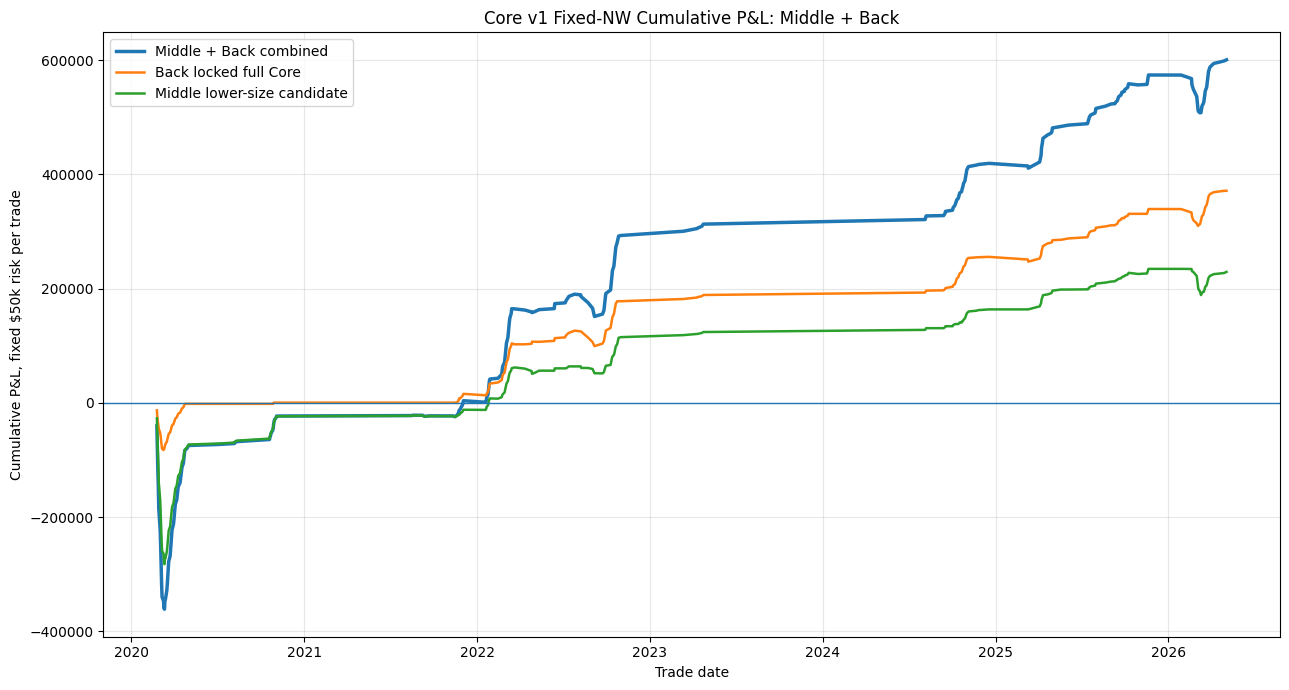


Cell 7 fixed-NW bucket summary


,label,trade_count,selected_dates,win_rate,total_pnl_fixed_5pct,avg_pnl_fixed_5pct,median_pnl_fixed_5pct,profit_factor_fixed_5pct,worst_trade_fixed_5pct,best_trade_fixed_5pct,...,worst_5_trade_sum_fixed_5pct,worst_10_trade_sum_fixed_5pct,worst_20_trade_sum_fixed_5pct,loss_count,loss_count_50k,loss_count_100k,base_net_worth,per_trade_risk_pct_of_base_nw,per_trade_risk_dollars,sizing_mode
0,Back_LOCKED_FULL_CORE,511,209,0.882583,371253.789553,726.524050,980.687765,3.317328,-13129.399949,4012.773822,...,-49054.002802,-80424.066470,-112741.692921,59,0,0,1000000.0,0.05,50000.0,fixed_base_nw_no_compounding
1,Middle_LOWER_SIZE_CANDIDATE,601,224,0.821963,229339.887057,381.597150,952.742744,1.629932,-13129.399949,4012.773822,...,-60662.129913,-117206.922754,-205055.283202,106,0,0,1000000.0,0.05,50000.0,fixed_base_nw_no_compounding
2,Middle_PLUS_Back_COMBINED,1112,246,0.849820,600593.676610,540.102227,969.960046,2.145562,-13129.399949,4012.773822,...,-61999.360075,-120343.954815,-217376.124226,165,0,0,1000000.0,0.05,50000.0,fixed_base_nw_no_compounding



Cell 7 signal count summary


,metric,value
0,source_rows,17568.00
1,selected_rows_core_v1_any_signal,1112.00
2,back_locked_signal_rows,511.00
3,middle_lower_size_candidate_signal_rows,601.00
4,front_rejected_signal_rows,0.00
5,unique_selected_dates,246.00
6,base_net_worth,1000000.00
7,per_trade_risk_pct_of_base_nw,0.05
8,per_trade_risk_dollars,50000.00



Cell 7 annual breakdown


...


Cell 7 daily cumulative P&L tail


core_v1_signal_bucket,trade_date,daily_pnl_back_locked_full_core,daily_pnl_middle_lower_size_candidate,daily_pnl_middle_plus_back,cum_pnl_back_locked_full_core,cum_pnl_middle_lower_size_candidate,cum_pnl_middle_plus_back,equity_curve_back_locked_full_core,equity_curve_middle_lower_size_candidate,equity_curve_middle_plus_back
226,2026-03-06,1354.447019,-3301.251332,-1946.804312,311268.196788,198530.248059,509798.444847,1.311268e+06,1.198530e+06,1.509798e+06
227,2026-03-09,1499.340052,-3528.330677,-2028.990625,312767.536840,195001.917382,507769.454222,1.312768e+06,1.195002e+06,1.507769e+06
228,2026-03-10,3322.283631,-3079.490023,242.793608,316089.820471,191922.427359,508012.247830,1.316090e+06,1.191922e+06,1.508012e+06
229,2026-03-11,3130.257682,-3164.718557,-34.460875,319220.078153,188757.708802,507977.786955,1.319220e+06,1.188758e+06,1.507978e+06
230,2026-03-12,3701.694387,1296.866898,4998.561285,322921.772540,190054.575700,512976.348240,1.322922e+06,1.190055e+06,1.512976e+06
231,2026-03-13,3643.592840,2532.949147,6176.541987,326565.365380,192587.524846,519152.890227,1.326565e+06,1.192588e+06,1.519153e+06
232,2026-03-16,3085.360138,1969.510611,5054.870749,329650.725518,194557.035458,524207.760976,1.329651e+06,1.194557e+06,1.524208e+06
233,2026-03-17,2881.885144,-227.141090,2654.744055,332532.610662,194329.894368,526862.505031,1.332533e+06,1.194330e+06,1.526863e+06
234,2026-03-18,3303.545821,2566.833215,5870.379036,335836.156483,196896.727583,532732.884067,1.335836e+06,1.196897e+06,1.532733e+06
235,2026-03-19,3348.222732,2910.774102,6258.996835,339184.379216,199807.501686,538991.880902,1.339184e+06,1.199808e+06,1.538992e+06



Cell 7 validation


,check,passed,status,detail
0,Cell 6 Core v1 decision loaded,True,PASS,C:\Users\patri\vrp_project\data\audit\vrp_core...
1,Back locked config status valid,True,PASS,Back status: LOCKED_FULL_CORE; source: C:\User...
2,Middle carry-forward config status valid,True,PASS,Middle status: CARRY_FORWARD_LOWER_SIZE_CANDID...
3,Front rejection status valid,True,PASS,Front status: REJECTED_FOR_CORE_V1; source: C:...
4,Exact tenor grid present,True,PASS,"Found: [9, 12, 15, 18, 21, 24, 27, 30, 33]"
5,Required signal and fixed-PnL columns available,True,PASS,Missing: []; P&L return conversion: decimal_re...
6,Back thresholds match locked config,True,PASS,"{'model_vrp_log': 0.7, 'model_vrp_z_3m': 0.7, ..."
7,Middle thresholds match Cell 6 primary carry-f...,True,PASS,{'candidate_id': 'middle_vrp0.80_z0.50_rsi70_f...
8,Front creates no Core v1 signal,True,PASS,Front rejected signal rows: 0
9,Combined signal equals Back OR Middle only,True,PASS,core_v1_any_signal is exactly Back OR Middle.



Saved outputs
Final signal panel:      C:\Users\patri\vrp_project\data\processed\vrp_core_bucket_parameters_v1\07_core_v1_final_signal_panel_20180924_20260701_20260704_191616.parquet
Selected trades:         C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\07_core_v1_selected_trades_fixed_5pct_1mm_20180924_20260701_20260704_191616.csv
Daily P&L curve:         C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\07_core_v1_daily_cumulative_pnl_fixed_5pct_1mm_20180924_20260701_20260704_191616.csv
Bucket summary:          C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\07_core_v1_bucket_summary_fixed_5pct_1mm_20180924_20260701_20260704_191616.csv
Annual breakdown:        C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\07_core_v1_annual_breakdown_fixed_5pct_1mm_20180924_20260701_20260704_191616.csv
Tenor breakdown:         C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\07_core_v1_tenor_breakdown

In [21]:
# ======================================================================================
# Cell 7 — Final Core v1 signal sanity panel + fixed-NW cumulative P&L
# ======================================================================================
#
# Scope:
#   - Build final Core v1 signal panel from Cell 2C.
#   - Use Cell 6 configs:
#       Back   = locked full Core
#       Middle = lower-size carry-forward candidate
#       Front  = rejected
#   - Produce separate Back, Middle, and combined Middle+Back signal/P&L views.
#   - Show cumulative P&L assuming:
#       base net worth = $1,000,000
#       per-trade risk = 5% of base NW = $50,000
#       no compounding
#       gains/losses do not change the account NW used for sizing
#
# Important:
#   - This cell does NOT optimize.
#   - This cell does NOT apply dynamic sizing.
#   - This cell does NOT update trade size after gains/losses.
#   - This cell does NOT include Front.
#   - This cell does NOT retest or alter Back/Middle thresholds.
#
# Output:
#   - final signal panel
#   - selected trades
#   - daily cumulative P&L curve
#   - annual breakdown
#   - bucket summary
#   - cumulative P&L chart
#   - validation
#   - manifest
# ======================================================================================

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ======================================================================================
# 0. Configuration
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

PROCESSED_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\processed\vrp_core_bucket_parameters_v1"
AUDIT_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\audit\vrp_core_bucket_parameters_v1"
CHART_DIR = AUDIT_CORE_BUCKET_DIR / "charts"

PROCESSED_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

BASE_NET_WORTH = 1_000_000.0
PER_TRADE_RISK_PCT_OF_NW = 0.05
PER_TRADE_RISK_DOLLARS = BASE_NET_WORTH * PER_TRADE_RISK_PCT_OF_NW

EXACT_TENOR_GRID = [9, 12, 15, 18, 21, 24, 27, 30, 33]

FRONT_TENORS = [9, 12, 15]
MIDDLE_TENORS = [18, 21, 24]
BACK_TENORS = [27, 30, 33]

TENOR_BUCKET_MAP = {
    9: "Front",
    12: "Front",
    15: "Front",
    18: "Middle",
    21: "Middle",
    24: "Middle",
    27: "Back",
    30: "Back",
    33: "Back",
}

REQUIRED_PNL_RETURN_COL = "normalized_pnl_pct"

EXPECTED_CELL6_BACK_STATUS = "LOCKED_FULL_CORE"
EXPECTED_CELL6_MIDDLE_STATUS = "CARRY_FORWARD_LOWER_SIZE_CANDIDATE_NOT_FULL_CORE"
EXPECTED_CELL6_FRONT_STATUS = "REJECTED_FOR_CORE_V1"


# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory: Path, pattern: str) -> Path:
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"No files found in {directory} matching pattern: {pattern}")
    return files[0]


def parse_project_date_series(
    s: pd.Series,
    label: str = "",
    allow_missing: bool = False,
) -> pd.Series:
    raw = s.copy()

    if pd.api.types.is_datetime64_any_dtype(raw):
        parsed = pd.to_datetime(raw, errors="coerce").dt.normalize()
    else:
        as_str = raw.astype("string").str.strip()

        missing_mask = (
            raw.isna()
            | as_str.isna()
            | as_str.eq("")
            | as_str.str.lower().isin(["nat", "nan", "none"])
        )

        yyyymmdd_mask = as_str.str.fullmatch(r"\d{8}", na=False) & ~missing_mask
        parsed = pd.Series(pd.NaT, index=raw.index, dtype="datetime64[ns]")

        if yyyymmdd_mask.any():
            parsed.loc[yyyymmdd_mask] = pd.to_datetime(
                as_str.loc[yyyymmdd_mask],
                format="%Y%m%d",
                errors="coerce",
            )

        other_mask = ~yyyymmdd_mask & ~missing_mask

        if other_mask.any():
            parsed.loc[other_mask] = pd.to_datetime(
                raw.loc[other_mask],
                errors="coerce",
            )

    bad_mask = parsed.isna()

    if allow_missing:
        return parsed.dt.normalize()

    bad = int(bad_mask.sum())

    if bad > 0:
        sample_bad = raw.loc[bad_mask].head(10).tolist()
        raise ValueError(
            f"Date parsing failed for {bad:,} rows in {label}. "
            f"Sample bad values: {sample_bad}"
        )

    return parsed.dt.normalize()


def normalize_date_columns(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()

    if "trade_date" in df.columns:
        date_col = "trade_date"
    elif "date" in df.columns:
        date_col = "date"
    elif "snapshot_date" in df.columns:
        date_col = "snapshot_date"
    else:
        raise ValueError(f"No date column found in {label}")

    parsed = parse_project_date_series(df[date_col], label=f"{label}.{date_col}")

    df["date"] = parsed
    df["trade_date"] = parsed

    return df


def safe_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def validation_row(check_name: str, passed: bool, detail: str = "") -> dict:
    return {
        "check": check_name,
        "passed": bool(passed),
        "status": "PASS" if passed else "FAIL",
        "detail": detail,
    }


def single_value(df: pd.DataFrame, col: str, label: str):
    if col not in df.columns:
        raise ValueError(f"{label} is missing required column: {col}")

    if len(df) != 1:
        raise ValueError(f"{label} should have exactly one row. Found: {len(df):,}")

    return df[col].iloc[0]


def pct_return_to_decimal(s: pd.Series) -> tuple[pd.Series, str]:
    """
    normalized_pnl_pct should usually be decimal return vs max risk.
    If it appears stored as percent points, convert to decimal.
    """
    raw = pd.to_numeric(s, errors="coerce")

    abs_q95 = raw.abs().quantile(0.95)

    if pd.notna(abs_q95) and abs_q95 > 5.0:
        return raw / 100.0, "percent_points_divided_by_100"
    else:
        return raw, "decimal_return_no_conversion"


def max_drawdown_from_pnl(pnl_series: pd.Series) -> float:
    pnl_series = pd.to_numeric(pnl_series, errors="coerce").dropna()

    if pnl_series.empty:
        return np.nan

    cumulative = pnl_series.cumsum()
    running_max = cumulative.cummax()
    drawdown = cumulative - running_max

    return float(drawdown.min())


def worst_n_trade_sum(pnl_series: pd.Series, n: int = 20) -> float:
    pnl_series = pd.to_numeric(pnl_series, errors="coerce").dropna()

    if pnl_series.empty:
        return np.nan

    return float(pnl_series.sort_values(ascending=True).head(n).sum())


def profit_factor_from_pnl(pnl_series: pd.Series) -> float:
    pnl_series = pd.to_numeric(pnl_series, errors="coerce").dropna()

    if pnl_series.empty:
        return np.nan

    gross_profit = pnl_series[pnl_series > 0].sum()
    gross_loss = pnl_series[pnl_series < 0].sum()

    if gross_loss == 0:
        if gross_profit > 0:
            return np.inf
        return np.nan

    return float(gross_profit / abs(gross_loss))


def summarize_selected_trades(df: pd.DataFrame, label: str) -> dict:
    if df.empty:
        return {
            "label": label,
            "trade_count": 0,
            "selected_dates": 0,
            "win_rate": np.nan,
            "total_pnl_fixed_5pct": 0.0,
            "avg_pnl_fixed_5pct": np.nan,
            "median_pnl_fixed_5pct": np.nan,
            "profit_factor_fixed_5pct": np.nan,
            "worst_trade_fixed_5pct": np.nan,
            "best_trade_fixed_5pct": np.nan,
            "selected_trade_drawdown_fixed_5pct": np.nan,
            "worst_5_trade_sum_fixed_5pct": np.nan,
            "worst_10_trade_sum_fixed_5pct": np.nan,
            "worst_20_trade_sum_fixed_5pct": np.nan,
            "loss_count": 0,
            "loss_count_50k": 0,
            "loss_count_100k": 0,
        }

    pnl = pd.to_numeric(df["pnl_fixed_5pct_of_1mm"], errors="coerce")
    win = pd.to_numeric(df["win"], errors="coerce") if "win" in df.columns else (pnl > 0).astype(float)

    return {
        "label": label,
        "trade_count": int(len(df)),
        "selected_dates": int(df["trade_date"].nunique()),
        "win_rate": float(win.mean()),
        "total_pnl_fixed_5pct": float(pnl.sum()),
        "avg_pnl_fixed_5pct": float(pnl.mean()),
        "median_pnl_fixed_5pct": float(pnl.median()),
        "profit_factor_fixed_5pct": profit_factor_from_pnl(pnl),
        "worst_trade_fixed_5pct": float(pnl.min()),
        "best_trade_fixed_5pct": float(pnl.max()),
        "selected_trade_drawdown_fixed_5pct": max_drawdown_from_pnl(pnl),
        "worst_5_trade_sum_fixed_5pct": worst_n_trade_sum(pnl, 5),
        "worst_10_trade_sum_fixed_5pct": worst_n_trade_sum(pnl, 10),
        "worst_20_trade_sum_fixed_5pct": worst_n_trade_sum(pnl, 20),
        "loss_count": int((pnl < 0).sum()),
        "loss_count_50k": int((pnl <= -50_000).sum()),
        "loss_count_100k": int((pnl <= -100_000).sum()),
    }


# ======================================================================================
# 2. Load Cell 6 configs and Cell 2C panel
# ======================================================================================

core_v1_decision_file = latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "06_core_v1_final_decision_*.csv",
)

back_config_file = latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "06_core_back_locked_full_core_config_*.csv",
)

middle_config_file = latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "06_core_middle_primary_carry_forward_config_*.csv",
)

front_rejection_file = latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "06_core_front_rejection_config_*.csv",
)

cell6_manifest_file = latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "06_core_bucket_decision_manifest_*.csv",
)

signal_file = latest_file(
    PROCESSED_CORE_BUCKET_DIR,
    "02C_cross_tenor_core_signal_base_panel_*.parquet",
)

core_v1_decision = pd.read_csv(core_v1_decision_file)
back_config = pd.read_csv(back_config_file)
middle_config = pd.read_csv(middle_config_file)
front_rejection = pd.read_csv(front_rejection_file)
cell6_manifest = pd.read_csv(cell6_manifest_file)

signal_raw = pd.read_parquet(signal_file)
signal_raw = normalize_date_columns(signal_raw, "Cell 2C signal base panel")

print("=" * 100)
print("Cell 7 — Loaded configs and signal panel")
print("=" * 100)
print(f"Core v1 decision:       {core_v1_decision_file}")
print(f"Back locked config:     {back_config_file}")
print(f"Middle carry config:    {middle_config_file}")
print(f"Front rejection config: {front_rejection_file}")
print(f"Cell 6 manifest:        {cell6_manifest_file}")
print(f"Signal panel:           {signal_file}")


# ======================================================================================
# 3. Extract Back and Middle thresholds from Cell 6 config files
# ======================================================================================

back_status = single_value(back_config, "status", "Back locked config")
middle_status = single_value(middle_config, "status", "Middle primary carry-forward config")
front_status = single_value(front_rejection, "status", "Front rejection config")

back_vrp_log = float(single_value(back_config, "model_vrp_log_threshold", "Back locked config"))
back_z3 = float(single_value(back_config, "model_vrp_z_3m_threshold", "Back locked config"))
back_z1 = float(single_value(back_config, "model_vrp_z_1y_threshold", "Back locked config"))
back_rsi = float(single_value(back_config, "RSI14_threshold", "Back locked config"))
back_fv = float(single_value(back_config, "forecast_vol_pct_threshold", "Back locked config"))

middle_vrp_log = float(single_value(middle_config, "model_vrp_log_threshold", "Middle carry-forward config"))
middle_z3 = float(single_value(middle_config, "model_vrp_z_3m_threshold", "Middle carry-forward config"))
middle_z1 = float(single_value(middle_config, "model_vrp_z_1y_threshold", "Middle carry-forward config"))
middle_rsi = float(single_value(middle_config, "RSI14_threshold", "Middle carry-forward config"))
middle_fv = float(single_value(middle_config, "forecast_vol_pct_threshold", "Middle carry-forward config"))
middle_candidate_id = single_value(middle_config, "candidate_id", "Middle carry-forward config")

print("\n" + "=" * 100)
print("Final signal thresholds")
print("=" * 100)
print("Back locked full Core:")
print(f"  tenors:             {BACK_TENORS}")
print(f"  model_vrp_log:      > {back_vrp_log}")
print(f"  model_vrp_z_3m:     > {back_z3}")
print(f"  model_vrp_z_1y:     > {back_z1}")
print(f"  RSI14:              < {back_rsi}")
print(f"  forecast_vol_pct:   > {back_fv}")

print("\nMiddle lower-size candidate:")
print(f"  candidate_id:       {middle_candidate_id}")
print(f"  tenors:             {MIDDLE_TENORS}")
print(f"  model_vrp_log:      > {middle_vrp_log}")
print(f"  model_vrp_z_3m:     > {middle_z3}")
print(f"  model_vrp_z_1y:     > {middle_z1}")
print(f"  RSI14:              < {middle_rsi}")
print(f"  forecast_vol_pct:   > {middle_fv}")

print("\nFixed-NW P&L assumption:")
print(f"  base NW:            ${BASE_NET_WORTH:,.0f}")
print(f"  per-trade risk %:   {PER_TRADE_RISK_PCT_OF_NW:.2%}")
print(f"  per-trade risk $:   ${PER_TRADE_RISK_DOLLARS:,.0f}")
print("  compounding:        none")


# ======================================================================================
# 4. Clean panel and build final signals
# ======================================================================================

required_signal_cols = [
    "trade_date",
    "tenor",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "forecast_vol_pct",
    "actual_dte",
    REQUIRED_PNL_RETURN_COL,
]

missing_signal_cols = [c for c in required_signal_cols if c not in signal_raw.columns]

if missing_signal_cols:
    raise ValueError(
        "Cell 7 cannot run because required signal/P&L columns are missing. "
        f"Missing: {missing_signal_cols}"
    )

signal = signal_raw.copy()

signal["tenor"] = pd.to_numeric(signal["tenor"], errors="coerce").astype("Int64")
signal = signal[signal["tenor"].isin(EXACT_TENOR_GRID)].copy()
signal["tenor"] = signal["tenor"].astype(int)

if "tenor_bucket" not in signal.columns:
    signal["tenor_bucket"] = signal["tenor"].map(TENOR_BUCKET_MAP)

numeric_cols = [
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "forecast_vol_pct",
    "actual_dte",
    REQUIRED_PNL_RETURN_COL,
]

if "win" in signal.columns:
    numeric_cols.append("win")

signal = safe_numeric(signal, numeric_cols)

pnl_return_decimal, pnl_return_conversion = pct_return_to_decimal(signal[REQUIRED_PNL_RETURN_COL])

signal["pnl_return_vs_trade_risk_decimal"] = pnl_return_decimal
signal["pnl_fixed_5pct_of_1mm"] = signal["pnl_return_vs_trade_risk_decimal"] * PER_TRADE_RISK_DOLLARS
signal["base_net_worth_for_sizing"] = BASE_NET_WORTH
signal["per_trade_risk_pct_of_base_nw"] = PER_TRADE_RISK_PCT_OF_NW
signal["per_trade_risk_dollars"] = PER_TRADE_RISK_DOLLARS
signal["sizing_mode"] = "fixed_base_nw_no_compounding"

# Back locked full-Core signal.
signal["core_back_locked_signal"] = (
    signal["tenor"].isin(BACK_TENORS)
    & (signal["model_vrp_log"] > back_vrp_log)
    & (signal["model_vrp_z_3m"] > back_z3)
    & (signal["model_vrp_z_1y"] > back_z1)
    & (signal["RSI14"] < back_rsi)
    & (signal["forecast_vol_pct"] > back_fv)
)

# Middle lower-size candidate signal.
signal["core_middle_lower_size_candidate_signal"] = (
    signal["tenor"].isin(MIDDLE_TENORS)
    & (signal["model_vrp_log"] > middle_vrp_log)
    & (signal["model_vrp_z_3m"] > middle_z3)
    & (signal["model_vrp_z_1y"] > middle_z1)
    & (signal["RSI14"] < middle_rsi)
    & (signal["forecast_vol_pct"] > middle_fv)
)

# Front is rejected for Core v1.
signal["core_front_rejected_signal"] = False

# Combined signal for the current Core v1 research decision.
signal["core_v1_any_signal"] = (
    signal["core_back_locked_signal"]
    | signal["core_middle_lower_size_candidate_signal"]
)

signal["core_v1_signal_bucket"] = np.select(
    [
        signal["core_back_locked_signal"],
        signal["core_middle_lower_size_candidate_signal"],
    ],
    [
        "Back_LOCKED_FULL_CORE",
        "Middle_LOWER_SIZE_CANDIDATE",
    ],
    default="No_Core_v1_Signal",
)

signal["core_v1_signal_priority"] = np.select(
    [
        signal["core_back_locked_signal"],
        signal["core_middle_lower_size_candidate_signal"],
    ],
    [
        1,
        2,
    ],
    default=99,
)

signal = signal.sort_values(["trade_date", "core_v1_signal_priority", "tenor"]).reset_index(drop=True)


# ======================================================================================
# 5. Build selected-trade and cumulative P&L panels
# ======================================================================================

selected = signal[signal["core_v1_any_signal"]].copy()
selected = selected.dropna(subset=["pnl_fixed_5pct_of_1mm"]).copy()
selected = selected.sort_values(["trade_date", "core_v1_signal_priority", "tenor"]).reset_index(drop=True)

selected["trade_number_combined"] = np.arange(1, len(selected) + 1)
selected["cum_pnl_fixed_5pct_middle_plus_back"] = selected["pnl_fixed_5pct_of_1mm"].cumsum()
selected["equity_curve_fixed_5pct_middle_plus_back"] = BASE_NET_WORTH + selected["cum_pnl_fixed_5pct_middle_plus_back"]

selected["cum_pnl_by_signal_bucket"] = (
    selected.groupby("core_v1_signal_bucket")["pnl_fixed_5pct_of_1mm"].cumsum()
)

# Daily aggregate curve.
daily_bucket = (
    selected.groupby(["trade_date", "core_v1_signal_bucket"], as_index=False)
    .agg(
        trade_count=("pnl_fixed_5pct_of_1mm", "count"),
        daily_pnl_fixed_5pct=("pnl_fixed_5pct_of_1mm", "sum"),
        daily_wins=("pnl_fixed_5pct_of_1mm", lambda s: int((s > 0).sum())),
        daily_losses=("pnl_fixed_5pct_of_1mm", lambda s: int((s < 0).sum())),
    )
)

daily_wide = (
    daily_bucket.pivot_table(
        index="trade_date",
        columns="core_v1_signal_bucket",
        values="daily_pnl_fixed_5pct",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reset_index()
)

for col in ["Back_LOCKED_FULL_CORE", "Middle_LOWER_SIZE_CANDIDATE"]:
    if col not in daily_wide.columns:
        daily_wide[col] = 0.0

daily_wide = daily_wide.sort_values("trade_date").reset_index(drop=True)
daily_wide["daily_pnl_back_locked_full_core"] = daily_wide["Back_LOCKED_FULL_CORE"]
daily_wide["daily_pnl_middle_lower_size_candidate"] = daily_wide["Middle_LOWER_SIZE_CANDIDATE"]
daily_wide["daily_pnl_middle_plus_back"] = (
    daily_wide["daily_pnl_back_locked_full_core"]
    + daily_wide["daily_pnl_middle_lower_size_candidate"]
)

daily_wide["cum_pnl_back_locked_full_core"] = daily_wide["daily_pnl_back_locked_full_core"].cumsum()
daily_wide["cum_pnl_middle_lower_size_candidate"] = daily_wide["daily_pnl_middle_lower_size_candidate"].cumsum()
daily_wide["cum_pnl_middle_plus_back"] = daily_wide["daily_pnl_middle_plus_back"].cumsum()

daily_wide["equity_curve_back_locked_full_core"] = BASE_NET_WORTH + daily_wide["cum_pnl_back_locked_full_core"]
daily_wide["equity_curve_middle_lower_size_candidate"] = BASE_NET_WORTH + daily_wide["cum_pnl_middle_lower_size_candidate"]
daily_wide["equity_curve_middle_plus_back"] = BASE_NET_WORTH + daily_wide["cum_pnl_middle_plus_back"]

daily_curve = daily_wide[
    [
        "trade_date",
        "daily_pnl_back_locked_full_core",
        "daily_pnl_middle_lower_size_candidate",
        "daily_pnl_middle_plus_back",
        "cum_pnl_back_locked_full_core",
        "cum_pnl_middle_lower_size_candidate",
        "cum_pnl_middle_plus_back",
        "equity_curve_back_locked_full_core",
        "equity_curve_middle_lower_size_candidate",
        "equity_curve_middle_plus_back",
    ]
].copy()


# ======================================================================================
# 6. Summaries
# ======================================================================================

back_selected = selected[selected["core_v1_signal_bucket"] == "Back_LOCKED_FULL_CORE"].copy()
middle_selected = selected[selected["core_v1_signal_bucket"] == "Middle_LOWER_SIZE_CANDIDATE"].copy()

bucket_summary = pd.DataFrame(
    [
        summarize_selected_trades(back_selected, "Back_LOCKED_FULL_CORE"),
        summarize_selected_trades(middle_selected, "Middle_LOWER_SIZE_CANDIDATE"),
        summarize_selected_trades(selected, "Middle_PLUS_Back_COMBINED"),
    ]
)

bucket_summary["base_net_worth"] = BASE_NET_WORTH
bucket_summary["per_trade_risk_pct_of_base_nw"] = PER_TRADE_RISK_PCT_OF_NW
bucket_summary["per_trade_risk_dollars"] = PER_TRADE_RISK_DOLLARS
bucket_summary["sizing_mode"] = "fixed_base_nw_no_compounding"

annual_breakdown = pd.DataFrame()

if not selected.empty:
    annual_breakdown = (
        selected.assign(year=selected["trade_date"].dt.year)
        .groupby(["year", "core_v1_signal_bucket"], as_index=False)
        .agg(
            trade_count=("pnl_fixed_5pct_of_1mm", "count"),
            selected_dates=("trade_date", "nunique"),
            total_pnl_fixed_5pct=("pnl_fixed_5pct_of_1mm", "sum"),
            avg_pnl_fixed_5pct=("pnl_fixed_5pct_of_1mm", "mean"),
            median_pnl_fixed_5pct=("pnl_fixed_5pct_of_1mm", "median"),
            worst_trade_fixed_5pct=("pnl_fixed_5pct_of_1mm", "min"),
            best_trade_fixed_5pct=("pnl_fixed_5pct_of_1mm", "max"),
            win_rate=("win", "mean") if "win" in selected.columns else ("pnl_fixed_5pct_of_1mm", lambda s: float((s > 0).mean())),
            loss_count=("pnl_fixed_5pct_of_1mm", lambda s: int((s < 0).sum())),
            loss_count_50k=("pnl_fixed_5pct_of_1mm", lambda s: int((s <= -50_000).sum())),
            loss_count_100k=("pnl_fixed_5pct_of_1mm", lambda s: int((s <= -100_000).sum())),
        )
        .sort_values(["year", "core_v1_signal_bucket"])
        .reset_index(drop=True)
    )

    annual_combined = (
        selected.assign(year=selected["trade_date"].dt.year)
        .groupby("year", as_index=False)
        .agg(
            trade_count=("pnl_fixed_5pct_of_1mm", "count"),
            selected_dates=("trade_date", "nunique"),
            total_pnl_fixed_5pct=("pnl_fixed_5pct_of_1mm", "sum"),
            avg_pnl_fixed_5pct=("pnl_fixed_5pct_of_1mm", "mean"),
            median_pnl_fixed_5pct=("pnl_fixed_5pct_of_1mm", "median"),
            worst_trade_fixed_5pct=("pnl_fixed_5pct_of_1mm", "min"),
            best_trade_fixed_5pct=("pnl_fixed_5pct_of_1mm", "max"),
            win_rate=("win", "mean") if "win" in selected.columns else ("pnl_fixed_5pct_of_1mm", lambda s: float((s > 0).mean())),
            loss_count=("pnl_fixed_5pct_of_1mm", lambda s: int((s < 0).sum())),
            loss_count_50k=("pnl_fixed_5pct_of_1mm", lambda s: int((s <= -50_000).sum())),
            loss_count_100k=("pnl_fixed_5pct_of_1mm", lambda s: int((s <= -100_000).sum())),
        )
    )
    annual_combined["core_v1_signal_bucket"] = "Middle_PLUS_Back_COMBINED"

    annual_breakdown = pd.concat(
        [annual_breakdown, annual_combined[annual_breakdown.columns]],
        ignore_index=True,
    ).sort_values(["year", "core_v1_signal_bucket"]).reset_index(drop=True)

tenor_breakdown = pd.DataFrame()

if not selected.empty:
    tenor_breakdown = (
        selected.groupby(["tenor_bucket", "tenor", "core_v1_signal_bucket"], as_index=False)
        .agg(
            trade_count=("pnl_fixed_5pct_of_1mm", "count"),
            selected_dates=("trade_date", "nunique"),
            total_pnl_fixed_5pct=("pnl_fixed_5pct_of_1mm", "sum"),
            avg_pnl_fixed_5pct=("pnl_fixed_5pct_of_1mm", "mean"),
            median_pnl_fixed_5pct=("pnl_fixed_5pct_of_1mm", "median"),
            worst_trade_fixed_5pct=("pnl_fixed_5pct_of_1mm", "min"),
            best_trade_fixed_5pct=("pnl_fixed_5pct_of_1mm", "max"),
            win_rate=("win", "mean") if "win" in selected.columns else ("pnl_fixed_5pct_of_1mm", lambda s: float((s > 0).mean())),
            loss_count=("pnl_fixed_5pct_of_1mm", lambda s: int((s < 0).sum())),
        )
        .sort_values(["tenor_bucket", "tenor"])
        .reset_index(drop=True)
    )

signal_count_summary = pd.DataFrame(
    [
        {
            "metric": "source_rows",
            "value": len(signal),
        },
        {
            "metric": "selected_rows_core_v1_any_signal",
            "value": len(selected),
        },
        {
            "metric": "back_locked_signal_rows",
            "value": int(signal["core_back_locked_signal"].sum()),
        },
        {
            "metric": "middle_lower_size_candidate_signal_rows",
            "value": int(signal["core_middle_lower_size_candidate_signal"].sum()),
        },
        {
            "metric": "front_rejected_signal_rows",
            "value": int(signal["core_front_rejected_signal"].sum()),
        },
        {
            "metric": "unique_selected_dates",
            "value": int(selected["trade_date"].nunique()),
        },
        {
            "metric": "base_net_worth",
            "value": BASE_NET_WORTH,
        },
        {
            "metric": "per_trade_risk_pct_of_base_nw",
            "value": PER_TRADE_RISK_PCT_OF_NW,
        },
        {
            "metric": "per_trade_risk_dollars",
            "value": PER_TRADE_RISK_DOLLARS,
        },
    ]
)


# ======================================================================================
# 7. Chart cumulative P&L
# ======================================================================================

chart_path = CHART_DIR / f"07_core_v1_middle_plus_back_cumulative_pnl_fixed_5pct_1mm_{TIMESTAMP}.png"

if not daily_curve.empty:
    plt.figure(figsize=(13, 7))
    plt.plot(
        daily_curve["trade_date"],
        daily_curve["cum_pnl_middle_plus_back"],
        label="Middle + Back combined",
        linewidth=2.5,
    )
    plt.plot(
        daily_curve["trade_date"],
        daily_curve["cum_pnl_back_locked_full_core"],
        label="Back locked full Core",
        linewidth=1.8,
    )
    plt.plot(
        daily_curve["trade_date"],
        daily_curve["cum_pnl_middle_lower_size_candidate"],
        label="Middle lower-size candidate",
        linewidth=1.8,
    )
    plt.axhline(0, linewidth=1)
    plt.title("Core v1 Fixed-NW Cumulative P&L: Middle + Back")
    plt.xlabel("Trade date")
    plt.ylabel("Cumulative P&L, fixed $50k risk per trade")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(chart_path, dpi=150)
    plt.show()
else:
    chart_path = None
    print("No selected trades; chart not created.")


# ======================================================================================
# 8. Validation
# ======================================================================================

validation_rows = []

tenors_present = sorted(signal["tenor"].dropna().unique().tolist())

validation_rows.append(
    validation_row(
        "Cell 6 Core v1 decision loaded",
        len(core_v1_decision) == 1,
        str(core_v1_decision_file),
    )
)

validation_rows.append(
    validation_row(
        "Back locked config status valid",
        back_status == EXPECTED_CELL6_BACK_STATUS,
        f"Back status: {back_status}; source: {back_config_file}",
    )
)

validation_rows.append(
    validation_row(
        "Middle carry-forward config status valid",
        middle_status == EXPECTED_CELL6_MIDDLE_STATUS,
        f"Middle status: {middle_status}; source: {middle_config_file}",
    )
)

validation_rows.append(
    validation_row(
        "Front rejection status valid",
        front_status == EXPECTED_CELL6_FRONT_STATUS,
        f"Front status: {front_status}; source: {front_rejection_file}",
    )
)

validation_rows.append(
    validation_row(
        "Exact tenor grid present",
        tenors_present == EXACT_TENOR_GRID,
        f"Found: {tenors_present}",
    )
)

validation_rows.append(
    validation_row(
        "Required signal and fixed-PnL columns available",
        missing_signal_cols == [],
        f"Missing: {missing_signal_cols}; P&L return conversion: {pnl_return_conversion}",
    )
)

validation_rows.append(
    validation_row(
        "Back thresholds match locked config",
        (
            back_vrp_log == 0.70
            and back_z3 == 0.70
            and back_z1 == 0.70
            and back_rsi == 70.0
            and back_fv == 8.5
        ),
        {
            "model_vrp_log": back_vrp_log,
            "model_vrp_z_3m": back_z3,
            "model_vrp_z_1y": back_z1,
            "RSI14": back_rsi,
            "forecast_vol_pct": back_fv,
        },
    )
)

validation_rows.append(
    validation_row(
        "Middle thresholds match Cell 6 primary carry-forward config",
        (
            middle_vrp_log == 0.80
            and middle_z3 == 0.50
            and middle_z1 == 0.50
            and middle_rsi == 70.0
            and middle_fv == 7.5
        ),
        {
            "candidate_id": middle_candidate_id,
            "model_vrp_log": middle_vrp_log,
            "model_vrp_z_3m": middle_z3,
            "model_vrp_z_1y": middle_z1,
            "RSI14": middle_rsi,
            "forecast_vol_pct": middle_fv,
        },
    )
)

validation_rows.append(
    validation_row(
        "Front creates no Core v1 signal",
        int(signal["core_front_rejected_signal"].sum()) == 0,
        f"Front rejected signal rows: {int(signal['core_front_rejected_signal'].sum())}",
    )
)

validation_rows.append(
    validation_row(
        "Combined signal equals Back OR Middle only",
        bool(
            (
                signal["core_v1_any_signal"]
                == (
                    signal["core_back_locked_signal"]
                    | signal["core_middle_lower_size_candidate_signal"]
                )
            ).all()
        ),
        "core_v1_any_signal is exactly Back OR Middle.",
    )
)

validation_rows.append(
    validation_row(
        "No selected Front tenors in Core v1 selected trades",
        not selected["tenor"].isin(FRONT_TENORS).any(),
        f"Selected tenors: {sorted(selected['tenor'].dropna().unique().tolist()) if not selected.empty else []}",
    )
)

validation_rows.append(
    validation_row(
        "Fixed-NW sizing uses constant $50k per trade",
        (
            BASE_NET_WORTH == 1_000_000.0
            and PER_TRADE_RISK_PCT_OF_NW == 0.05
            and PER_TRADE_RISK_DOLLARS == 50_000.0
        ),
        {
            "base_net_worth": BASE_NET_WORTH,
            "per_trade_risk_pct_of_base_nw": PER_TRADE_RISK_PCT_OF_NW,
            "per_trade_risk_dollars": PER_TRADE_RISK_DOLLARS,
        },
    )
)

validation_rows.append(
    validation_row(
        "Selected trades available for cumulative P&L",
        len(selected) > 0,
        f"Selected rows: {len(selected):,}",
    )
)

validation_rows.append(
    validation_row(
        "Daily cumulative P&L curve created",
        len(daily_curve) > 0,
        f"Daily curve rows: {len(daily_curve):,}",
    )
)

validation = pd.DataFrame(validation_rows)

required_pass_checks = [
    "Cell 6 Core v1 decision loaded",
    "Back locked config status valid",
    "Middle carry-forward config status valid",
    "Front rejection status valid",
    "Exact tenor grid present",
    "Required signal and fixed-PnL columns available",
    "Back thresholds match locked config",
    "Middle thresholds match Cell 6 primary carry-forward config",
    "Front creates no Core v1 signal",
    "Combined signal equals Back OR Middle only",
    "No selected Front tenors in Core v1 selected trades",
    "Fixed-NW sizing uses constant $50k per trade",
    "Selected trades available for cumulative P&L",
    "Daily cumulative P&L curve created",
]

cell_passed = bool(validation[validation["check"].isin(required_pass_checks)]["passed"].all())


# ======================================================================================
# 9. Save outputs
# ======================================================================================

date_min = signal["trade_date"].min().strftime("%Y%m%d")
date_max = signal["trade_date"].max().strftime("%Y%m%d")
date_range = f"{date_min}_{date_max}"

final_signal_panel_path = (
    PROCESSED_CORE_BUCKET_DIR
    / f"07_core_v1_final_signal_panel_{date_range}_{TIMESTAMP}.parquet"
)

selected_trades_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"07_core_v1_selected_trades_fixed_5pct_1mm_{date_range}_{TIMESTAMP}.csv"
)

daily_curve_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"07_core_v1_daily_cumulative_pnl_fixed_5pct_1mm_{date_range}_{TIMESTAMP}.csv"
)

bucket_summary_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"07_core_v1_bucket_summary_fixed_5pct_1mm_{date_range}_{TIMESTAMP}.csv"
)

annual_breakdown_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"07_core_v1_annual_breakdown_fixed_5pct_1mm_{date_range}_{TIMESTAMP}.csv"
)

tenor_breakdown_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"07_core_v1_tenor_breakdown_fixed_5pct_1mm_{date_range}_{TIMESTAMP}.csv"
)

signal_count_summary_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"07_core_v1_signal_count_summary_{date_range}_{TIMESTAMP}.csv"
)

validation_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"07_core_v1_final_signal_validation_{date_range}_{TIMESTAMP}.csv"
)

manifest_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"07_core_v1_final_signal_manifest_{date_range}_{TIMESTAMP}.csv"
)

signal.to_parquet(final_signal_panel_path, index=False)
selected.to_csv(selected_trades_path, index=False)
daily_curve.to_csv(daily_curve_path, index=False)
bucket_summary.to_csv(bucket_summary_path, index=False)
annual_breakdown.to_csv(annual_breakdown_path, index=False)
tenor_breakdown.to_csv(tenor_breakdown_path, index=False)
signal_count_summary.to_csv(signal_count_summary_path, index=False)
validation.to_csv(validation_path, index=False)

manifest = pd.DataFrame(
    [
        {
            "cell": "7",
            "timestamp": TIMESTAMP,
            "cell_passed": cell_passed,
            "core_v1_decision_source": str(core_v1_decision_file),
            "back_config_source": str(back_config_file),
            "middle_config_source": str(middle_config_file),
            "front_rejection_source": str(front_rejection_file),
            "cell6_manifest_source": str(cell6_manifest_file),
            "signal_source": str(signal_file),
            "base_net_worth": BASE_NET_WORTH,
            "per_trade_risk_pct_of_base_nw": PER_TRADE_RISK_PCT_OF_NW,
            "per_trade_risk_dollars": PER_TRADE_RISK_DOLLARS,
            "pnl_return_column": REQUIRED_PNL_RETURN_COL,
            "pnl_return_conversion": pnl_return_conversion,
            "back_signal_thresholds": {
                "tenors": BACK_TENORS,
                "model_vrp_log": back_vrp_log,
                "model_vrp_z_3m": back_z3,
                "model_vrp_z_1y": back_z1,
                "RSI14": back_rsi,
                "forecast_vol_pct": back_fv,
            },
            "middle_signal_thresholds": {
                "candidate_id": middle_candidate_id,
                "tenors": MIDDLE_TENORS,
                "model_vrp_log": middle_vrp_log,
                "model_vrp_z_3m": middle_z3,
                "model_vrp_z_1y": middle_z1,
                "RSI14": middle_rsi,
                "forecast_vol_pct": middle_fv,
            },
            "front_status": "REJECTED_FOR_CORE_V1",
            "selected_trade_count": len(selected),
            "selected_dates": selected["trade_date"].nunique() if not selected.empty else 0,
            "final_signal_panel_output": str(final_signal_panel_path),
            "selected_trades_output": str(selected_trades_path),
            "daily_curve_output": str(daily_curve_path),
            "bucket_summary_output": str(bucket_summary_path),
            "annual_breakdown_output": str(annual_breakdown_path),
            "tenor_breakdown_output": str(tenor_breakdown_path),
            "signal_count_summary_output": str(signal_count_summary_path),
            "chart_output": str(chart_path) if chart_path is not None else None,
            "validation_output": str(validation_path),
            "notes": (
                "Final Core v1 signal sanity panel. "
                "Back locked full Core and Middle lower-size candidate flags are separate. "
                "Cumulative P&L uses fixed $50k risk per selected trade based on $1mm base NW and 5% per trade. "
                "No compounding and no dynamic account resizing."
            ),
        }
    ]
)

manifest.to_csv(manifest_path, index=False)


# ======================================================================================
# 10. Print final summary
# ======================================================================================

print("\n" + "=" * 100)
print("Cell 7 fixed-NW bucket summary")
print("=" * 100)
display(bucket_summary)

print("\n" + "=" * 100)
print("Cell 7 signal count summary")
print("=" * 100)
display(signal_count_summary)

print("\n" + "=" * 100)
print("Cell 7 annual breakdown")
print("=" * 100)
display(annual_breakdown)

print("\n" + "=" * 100)
print("Cell 7 tenor breakdown")
print("=" * 100)
display(tenor_breakdown)

print("\n" + "=" * 100)
print("Cell 7 daily cumulative P&L tail")
print("=" * 100)
display(daily_curve.tail(20))

print("\n" + "=" * 100)
print("Cell 7 validation")
print("=" * 100)
display(validation)

print("\n" + "=" * 100)
print("Saved outputs")
print("=" * 100)
print(f"Final signal panel:      {final_signal_panel_path}")
print(f"Selected trades:         {selected_trades_path}")
print(f"Daily P&L curve:         {daily_curve_path}")
print(f"Bucket summary:          {bucket_summary_path}")
print(f"Annual breakdown:        {annual_breakdown_path}")
print(f"Tenor breakdown:         {tenor_breakdown_path}")
print(f"Signal count summary:    {signal_count_summary_path}")
if chart_path is not None:
    print(f"Cumulative P&L chart:    {chart_path}")
print(f"Validation:              {validation_path}")
print(f"Manifest:                {manifest_path}")

if not cell_passed:
    failed = validation.loc[~validation["passed"], ["check", "detail"]]
    print("\nFAILED CHECKS:")
    display(failed)
    raise RuntimeError("Cell 7 failed validation.")

print("\n" + "=" * 100)
print("CELL 7 PASSED")
print("=" * 100)
print("Final Core v1 signal sanity panel complete.")
print("Back:   locked full Core signal.")
print("Middle: lower-size candidate signal.")
print("Front:  rejected / excluded.")
print(f"P&L view: fixed ${PER_TRADE_RISK_DOLLARS:,.0f} risk per trade, no compounding.")

In [ ]:
# ======================================================================================
# Cell 6A — Reopen Front: best lower-size Core candidate search
# ======================================================================================
#
# Scope:
#   - Reopen Front after Cell 6 for a different question:
#       "What is the best possible Front candidate if it can be sized lower?"
#   - Front bucket = 9D, 12D, 15D only.
#   - Use bucket-level thresholds across all Front tenors.
#   - Allow z_3m and z_1y thresholds to differ in this wider search.
#   - Rank candidates by Front-specific robustness, not by Back-equivalent Core filters.
#
# Explicitly not in scope:
#   - No Back re-optimization.
#   - No Middle re-optimization.
#   - No sizing decision.
#   - No portfolio overlap test.
#   - No per-tenor Front optimization.
#   - No automatic override of Cell 6.
#
# Important:
#   - This cell can recommend "best Front candidate to carry forward."
#   - It does NOT lock Front into Core.
#   - Final inclusion must still be decided after sizing / portfolio overlap testing.
# ======================================================================================

from pathlib import Path
from datetime import datetime
import itertools

import numpy as np
import pandas as pd


# ======================================================================================
# 0. Configuration
# ======================================================================================

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

PROCESSED_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\processed\vrp_core_bucket_parameters_v1"
AUDIT_CORE_BUCKET_DIR = PROJECT_ROOT / r"data\audit\vrp_core_bucket_parameters_v1"

PROCESSED_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_CORE_BUCKET_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

EXACT_TENOR_GRID = [9, 12, 15, 18, 21, 24, 27, 30, 33]

FRONT_TENORS = [9, 12, 15]
MIDDLE_TENORS = [18, 21, 24]
BACK_TENORS = [27, 30, 33]

TENOR_BUCKET_MAP = {
    9: "Front",
    12: "Front",
    15: "Front",
    18: "Middle",
    21: "Middle",
    24: "Middle",
    27: "Back",
    30: "Back",
    33: "Back",
}

LOCKED_CORE_BACK_THRESHOLDS = {
    "model_vrp_log": 0.70,
    "model_vrp_z_3m": 0.70,
    "model_vrp_z_1y": 0.70,
    "RSI14": 70.0,
    "forecast_vol_pct": 8.5,
}

# Wider Front search grid.
# This intentionally allows z_3m and z_1y to differ.
FRONT_VRP_LOG_GRID_6A = [0.60, 0.70, 0.80, 0.90, 1.00, 1.10, 1.20, 1.30]
FRONT_Z_3M_GRID_6A = [0.30, 0.50, 0.70, 0.90, 1.10, 1.30, 1.50, 1.75, 2.00]
FRONT_Z_1Y_GRID_6A = [0.30, 0.50, 0.70, 0.90, 1.10, 1.30, 1.50, 1.75, 2.00]
FRONT_RSI_CAP_GRID_6A = [55.0, 60.0, 62.0, 65.0, 68.0, 70.0]
FRONT_FORECAST_VOL_FLOOR_GRID_6A = [7.5, 8.5, 10.0, 12.5, 15.0, 17.5, 20.0]

# Front carry-forward guardrails.
# These are intentionally less strict than Back-quality filters.
# They decide whether Front is even worth carrying into sizing tests.
FRONT_CARRY_FORWARD_GUARDRAILS = {
    "min_trade_count": 50,
    "min_win_rate_preferred": 0.78,
    "min_win_rate_floor": 0.75,
    "min_profit_factor_preferred": 1.50,
    "min_profit_factor_floor": 1.25,
    "max_loss_count_100k_preferred": 10,
    "max_loss_count_100k_floor": 25,
    "min_positive_year_share": 0.70,
    "min_worst_year_pnl_floor": -1_000_000,
}

TOP_N_CANDIDATES = 100
TOP_N_SELECTED_TRADE_EXPORT = 50


# ======================================================================================
# 1. Helpers
# ======================================================================================

def latest_file(directory: Path, pattern: str) -> Path:
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"No files found in {directory} matching pattern: {pattern}")
    return files[0]


def optional_latest_file(directory: Path, pattern: str):
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        return None
    return files[0]


def parse_project_date_series(
    s: pd.Series,
    label: str = "",
    allow_missing: bool = False,
) -> pd.Series:
    raw = s.copy()

    if pd.api.types.is_datetime64_any_dtype(raw):
        parsed = pd.to_datetime(raw, errors="coerce").dt.normalize()
    else:
        as_str = raw.astype("string").str.strip()

        missing_mask = (
            raw.isna()
            | as_str.isna()
            | as_str.eq("")
            | as_str.str.lower().isin(["nat", "nan", "none"])
        )

        yyyymmdd_mask = as_str.str.fullmatch(r"\d{8}", na=False) & ~missing_mask
        parsed = pd.Series(pd.NaT, index=raw.index, dtype="datetime64[ns]")

        if yyyymmdd_mask.any():
            parsed.loc[yyyymmdd_mask] = pd.to_datetime(
                as_str.loc[yyyymmdd_mask],
                format="%Y%m%d",
                errors="coerce",
            )

        other_mask = ~yyyymmdd_mask & ~missing_mask

        if other_mask.any():
            parsed.loc[other_mask] = pd.to_datetime(
                raw.loc[other_mask],
                errors="coerce",
            )

    bad_mask = parsed.isna()

    if allow_missing:
        return parsed.dt.normalize()

    bad = int(bad_mask.sum())

    if bad > 0:
        sample_bad = raw.loc[bad_mask].head(10).tolist()
        raise ValueError(
            f"Date parsing failed for {bad:,} rows in {label}. "
            f"Sample bad values: {sample_bad}"
        )

    return parsed.dt.normalize()


def normalize_date_columns(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()

    if "trade_date" in df.columns:
        date_col = "trade_date"
    elif "date" in df.columns:
        date_col = "date"
    elif "snapshot_date" in df.columns:
        date_col = "snapshot_date"
    else:
        raise ValueError(f"No date column found in {label}")

    parsed = parse_project_date_series(df[date_col], label=f"{label}.{date_col}")

    df["date"] = parsed
    df["trade_date"] = parsed

    return df


def safe_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def validation_row(check_name: str, passed: bool, detail: str = "") -> dict:
    return {
        "check": check_name,
        "passed": bool(passed),
        "status": "PASS" if passed else "FAIL",
        "detail": detail,
    }


def choose_pnl_column(df: pd.DataFrame) -> str:
    candidates = [
        "normalized_pnl_dollars",
        "pnl_dollars",
        "trade_pnl_dollars",
        "pnl",
        "trade_pnl",
        "pnl_per_1mm",
        "pnl_1mm",
        "normalized_pnl",
        "normalized_pnl_pct",
        "return_vs_max_loss",
        "ret_vs_max_loss",
        "max_loss_return",
    ]

    for col in candidates:
        if col in df.columns and pd.to_numeric(df[col], errors="coerce").notna().sum() > 0:
            return col

    raise ValueError(
        "Could not find usable P&L column. "
        f"Tried: {candidates}"
    )


def choose_win_column(df: pd.DataFrame) -> str:
    candidates = [
        "win",
        "is_win",
        "winner",
        "expired_otm",
    ]

    for col in candidates:
        if col in df.columns and pd.to_numeric(df[col], errors="coerce").notna().sum() > 0:
            return col

    raise ValueError(
        "Could not find usable win/outcome column. "
        f"Tried: {candidates}"
    )


def max_drawdown_from_pnl(pnl_series: pd.Series) -> float:
    if pnl_series.empty:
        return np.nan

    cumulative = pnl_series.cumsum()
    running_max = cumulative.cummax()
    drawdown = cumulative - running_max

    return float(drawdown.min())


def worst_n_trade_sum(pnl_series: pd.Series, n: int = 20) -> float:
    if pnl_series.empty:
        return np.nan

    return float(pnl_series.sort_values(ascending=True).head(n).sum())


def profit_factor_from_pnl(pnl_series: pd.Series) -> float:
    if pnl_series.empty:
        return np.nan

    gross_profit = pnl_series[pnl_series > 0].sum()
    gross_loss = pnl_series[pnl_series < 0].sum()

    if gross_loss == 0:
        if gross_profit > 0:
            return np.inf
        return np.nan

    return float(gross_profit / abs(gross_loss))


def safe_ratio(num, den):
    if den is None or den == 0 or pd.isna(den):
        return np.nan
    return num / den


def build_candidate_id(
    vrp_log_threshold: float,
    z3_threshold: float,
    z1_threshold: float,
    rsi_cap: float,
    forecast_vol_floor: float,
) -> str:
    return (
        f"front6A_"
        f"vrp{vrp_log_threshold:.2f}_"
        f"z3m{z3_threshold:.2f}_"
        f"z1y{z1_threshold:.2f}_"
        f"rsi{rsi_cap:.0f}_"
        f"fv{forecast_vol_floor:.1f}"
    )


def add_front_guardrail_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["profit_factor_capped"] = (
        pd.to_numeric(df["profit_factor"], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .clip(upper=25.0)
    )

    df["passes_front_preferred_carry"] = (
        (df["trade_count"] >= FRONT_CARRY_FORWARD_GUARDRAILS["min_trade_count"])
        & (df["win_rate"] >= FRONT_CARRY_FORWARD_GUARDRAILS["min_win_rate_preferred"])
        & (df["profit_factor_capped"] >= FRONT_CARRY_FORWARD_GUARDRAILS["min_profit_factor_preferred"])
        & (df["loss_count_100k"] <= FRONT_CARRY_FORWARD_GUARDRAILS["max_loss_count_100k_preferred"])
        & (df["positive_year_share"] >= FRONT_CARRY_FORWARD_GUARDRAILS["min_positive_year_share"])
        & (df["worst_year_pnl"] >= FRONT_CARRY_FORWARD_GUARDRAILS["min_worst_year_pnl_floor"])
    )

    df["passes_front_floor_carry"] = (
        (df["trade_count"] >= FRONT_CARRY_FORWARD_GUARDRAILS["min_trade_count"])
        & (df["win_rate"] >= FRONT_CARRY_FORWARD_GUARDRAILS["min_win_rate_floor"])
        & (df["profit_factor_capped"] >= FRONT_CARRY_FORWARD_GUARDRAILS["min_profit_factor_floor"])
        & (df["loss_count_100k"] <= FRONT_CARRY_FORWARD_GUARDRAILS["max_loss_count_100k_floor"])
        & (df["positive_year_share"] >= FRONT_CARRY_FORWARD_GUARDRAILS["min_positive_year_share"])
        & (df["worst_year_pnl"] >= FRONT_CARRY_FORWARD_GUARDRAILS["min_worst_year_pnl_floor"])
    )

    df["front_floor_fail_count"] = (
        (df["trade_count"] < FRONT_CARRY_FORWARD_GUARDRAILS["min_trade_count"]).astype(int)
        + (df["win_rate"] < FRONT_CARRY_FORWARD_GUARDRAILS["min_win_rate_floor"]).astype(int)
        + (df["profit_factor_capped"] < FRONT_CARRY_FORWARD_GUARDRAILS["min_profit_factor_floor"]).astype(int)
        + (df["loss_count_100k"] > FRONT_CARRY_FORWARD_GUARDRAILS["max_loss_count_100k_floor"]).astype(int)
        + (df["positive_year_share"] < FRONT_CARRY_FORWARD_GUARDRAILS["min_positive_year_share"]).astype(int)
        + (df["worst_year_pnl"] < FRONT_CARRY_FORWARD_GUARDRAILS["min_worst_year_pnl_floor"]).astype(int)
    )

    df["front_preferred_fail_count"] = (
        (df["trade_count"] < FRONT_CARRY_FORWARD_GUARDRAILS["min_trade_count"]).astype(int)
        + (df["win_rate"] < FRONT_CARRY_FORWARD_GUARDRAILS["min_win_rate_preferred"]).astype(int)
        + (df["profit_factor_capped"] < FRONT_CARRY_FORWARD_GUARDRAILS["min_profit_factor_preferred"]).astype(int)
        + (df["loss_count_100k"] > FRONT_CARRY_FORWARD_GUARDRAILS["max_loss_count_100k_preferred"]).astype(int)
        + (df["positive_year_share"] < FRONT_CARRY_FORWARD_GUARDRAILS["min_positive_year_share"]).astype(int)
        + (df["worst_year_pnl"] < FRONT_CARRY_FORWARD_GUARDRAILS["min_worst_year_pnl_floor"]).astype(int)
    )

    return df


def score_front_candidate(row: pd.Series) -> float:
    """
    Front-specific carry-forward score.

    This is not a lock score.
    It favors usable Front candidates at lower size:
      - enough trades
      - good win rate
      - reasonable profit factor
      - lower tail-loss count
      - tolerable annual behavior
    """
    total_pnl_m = row.get("total_pnl", 0.0) / 1_000_000.0
    dd_m = abs(row.get("selected_trade_drawdown", 0.0)) / 1_000_000.0
    worst_year_m = row.get("worst_year_pnl", 0.0) / 1_000_000.0
    worst_20_m = row.get("worst_20_trade_sum", 0.0) / 1_000_000.0

    trade_count = row.get("trade_count", 0.0)
    trade_count_score = min(trade_count / 250.0, 1.0)

    score = 0.0

    score += 4.00 * row.get("win_rate", 0.0)
    score += 1.15 * min(row.get("profit_factor_capped", 0.0), 4.0)
    score += 0.65 * row.get("positive_year_share", 0.0)
    score += 0.45 * trade_count_score
    score += 0.25 * total_pnl_m

    score -= 0.75 * dd_m
    score -= 0.55 * row.get("loss_count_100k", 0.0)
    score -= 0.10 * row.get("loss_count_50k", 0.0)
    score += 0.50 * worst_year_m
    score += 0.25 * worst_20_m

    if row.get("passes_front_preferred_carry", False):
        score += 4.0
    elif row.get("passes_front_floor_carry", False):
        score += 2.0

    return float(score)


def display_cols() -> list[str]:
    return [
        "front_review_rank",
        "candidate_id",
        "vrp_log_threshold",
        "z_3m_threshold",
        "z_1y_threshold",
        "rsi_cap",
        "forecast_vol_floor",
        "trade_count",
        "selected_dates",
        "frequency_by_row",
        "win_rate",
        "profit_factor",
        "total_pnl",
        "worst_trade",
        "selected_trade_drawdown",
        "worst_20_trade_sum",
        "loss_count",
        "loss_count_50k",
        "loss_count_100k",
        "active_years",
        "positive_years",
        "positive_year_share",
        "worst_year_pnl",
        "median_annual_pnl",
        "count_9d",
        "count_12d",
        "count_15d",
        "passes_front_preferred_carry",
        "passes_front_floor_carry",
        "front_preferred_fail_count",
        "front_floor_fail_count",
        "front6a_review_score",
    ]


# ======================================================================================
# 2. Load latest Cell 2C signal base panel and Cell 6 decision
# ======================================================================================

signal_file = latest_file(
    PROCESSED_CORE_BUCKET_DIR,
    "02C_cross_tenor_core_signal_base_panel_*.parquet",
)

cell6_decision_file = optional_latest_file(
    AUDIT_CORE_BUCKET_DIR,
    "06_core_v1_final_decision_*.csv",
)

signal_raw = pd.read_parquet(signal_file)
signal_raw = normalize_date_columns(signal_raw, "Cell 2C signal base panel")

if "tenor" not in signal_raw.columns:
    raise ValueError("Cell 2C signal panel is missing tenor column.")

signal_raw["tenor"] = pd.to_numeric(signal_raw["tenor"], errors="coerce").astype("Int64")
signal_raw = signal_raw[signal_raw["tenor"].isin(EXACT_TENOR_GRID)].copy()
signal_raw["tenor"] = signal_raw["tenor"].astype(int)

if "tenor_bucket" not in signal_raw.columns:
    signal_raw["tenor_bucket"] = signal_raw["tenor"].map(TENOR_BUCKET_MAP)

signal_raw = signal_raw.sort_values(["trade_date", "tenor"]).reset_index(drop=True)

print("=" * 100)
print("Cell 6A — Loaded inputs")
print("=" * 100)
print(f"Signal source:       {signal_file}")
print(f"Rows:                {len(signal_raw):,}")
print(f"Date range:          {signal_raw['trade_date'].min().date()} to {signal_raw['trade_date'].max().date()}")
print(f"Tenors found:        {sorted(signal_raw['tenor'].dropna().unique().tolist())}")
if cell6_decision_file is not None:
    print(f"Cell 6 decision:     {cell6_decision_file}")
else:
    print("Cell 6 decision:     not found; continuing from Cell 2C only")


# ======================================================================================
# 3. Build Front research panel
# ======================================================================================

required_signal_cols = [
    "trade_date",
    "tenor",
    "tenor_bucket",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "forecast_vol_pct",
    "actual_dte",
]

missing_required_signal_cols = [c for c in required_signal_cols if c not in signal_raw.columns]
if missing_required_signal_cols:
    raise ValueError(
        "Cell 6A cannot run because required signal columns are missing. "
        f"Missing: {missing_required_signal_cols}"
    )

pnl_col = choose_pnl_column(signal_raw)
win_col = choose_win_column(signal_raw)

numeric_cols = [
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "forecast_vol_pct",
    "actual_dte",
    pnl_col,
    win_col,
]

signal_raw = safe_numeric(signal_raw, numeric_cols)

front_panel_all = signal_raw[
    (signal_raw["tenor_bucket"] == "Front")
    & (signal_raw["tenor"].isin(FRONT_TENORS))
].copy()

front_required_eval_cols = [
    "trade_date",
    "tenor",
    "tenor_bucket",
    "model_vrp_log",
    "model_vrp_z_3m",
    "model_vrp_z_1y",
    "RSI14",
    "forecast_vol_pct",
    "actual_dte",
    pnl_col,
    win_col,
]

front_panel = front_panel_all.dropna(subset=front_required_eval_cols).copy()

if "fit_status" in front_panel.columns:
    front_panel = front_panel[front_panel["fit_status"] == "FIT_OK"].copy()

front_panel = front_panel.sort_values(["trade_date", "tenor"]).reset_index(drop=True)

eligible_rows = len(front_panel)
eligible_dates = front_panel["trade_date"].nunique()

print("\n" + "=" * 100)
print("Front reopened research panel")
print("=" * 100)
print(f"Front rows before required-field drop: {len(front_panel_all):,}")
print(f"Front rows after required-field drop:  {len(front_panel):,}")
print(f"Eligible unique dates:                 {eligible_dates:,}")
print(f"P&L column selected:                   {pnl_col}")
print(f"Win column selected:                   {win_col}")
print(f"Front tenors:                          {FRONT_TENORS}")
print(f"Date range:                            {front_panel['trade_date'].min().date()} to {front_panel['trade_date'].max().date()}")


# ======================================================================================
# 4. Run wider Front search
# ======================================================================================

candidate_rows = []
annual_rows = []
selected_trade_exports = []

param_grid = list(
    itertools.product(
        FRONT_VRP_LOG_GRID_6A,
        FRONT_Z_3M_GRID_6A,
        FRONT_Z_1Y_GRID_6A,
        FRONT_RSI_CAP_GRID_6A,
        FRONT_FORECAST_VOL_FLOOR_GRID_6A,
    )
)

expected_candidate_count = (
    len(FRONT_VRP_LOG_GRID_6A)
    * len(FRONT_Z_3M_GRID_6A)
    * len(FRONT_Z_1Y_GRID_6A)
    * len(FRONT_RSI_CAP_GRID_6A)
    * len(FRONT_FORECAST_VOL_FLOOR_GRID_6A)
)

print("\n" + "=" * 100)
print("Running widened Front carry-forward search")
print("=" * 100)
print(f"Candidate count: {len(param_grid):,}")
print("z_3m and z_1y thresholds are allowed to differ in Cell 6A.")

for (
    vrp_log_threshold,
    z3_threshold,
    z1_threshold,
    rsi_cap,
    forecast_vol_floor,
) in param_grid:

    candidate_id = build_candidate_id(
        vrp_log_threshold=vrp_log_threshold,
        z3_threshold=z3_threshold,
        z1_threshold=z1_threshold,
        rsi_cap=rsi_cap,
        forecast_vol_floor=forecast_vol_floor,
    )

    selected = front_panel[
        (front_panel["model_vrp_log"] > vrp_log_threshold)
        & (front_panel["model_vrp_z_3m"] > z3_threshold)
        & (front_panel["model_vrp_z_1y"] > z1_threshold)
        & (front_panel["RSI14"] < rsi_cap)
        & (front_panel["forecast_vol_pct"] > forecast_vol_floor)
    ].copy()

    selected = selected.sort_values(["trade_date", "tenor"]).reset_index(drop=True)

    trade_count = len(selected)
    selected_dates = selected["trade_date"].nunique() if trade_count > 0 else 0

    if trade_count > 0:
        pnl = selected[pnl_col].astype(float)
        win = selected[win_col].astype(float)

        total_pnl = float(pnl.sum())
        avg_pnl = float(pnl.mean())
        median_pnl = float(pnl.median())
        best_trade = float(pnl.max())
        worst_trade = float(pnl.min())
        pnl_std = float(pnl.std(ddof=1)) if trade_count > 1 else np.nan

        win_rate = float(win.mean())
        loss_count = int((pnl < 0).sum())
        profit_factor = profit_factor_from_pnl(pnl)
        profit_factor_capped = min(profit_factor, 25.0) if pd.notna(profit_factor) and np.isfinite(profit_factor) else 25.0

        selected_trade_drawdown = max_drawdown_from_pnl(pnl)
        worst_5_trade_sum = worst_n_trade_sum(pnl, n=5)
        worst_10_trade_sum = worst_n_trade_sum(pnl, n=10)
        worst_20_trade_sum = worst_n_trade_sum(pnl, n=20)

        loss_count_50k = int((pnl <= -50_000).sum())
        loss_count_100k = int((pnl <= -100_000).sum())

        count_9d = int((selected["tenor"] == 9).sum())
        count_12d = int((selected["tenor"] == 12).sum())
        count_15d = int((selected["tenor"] == 15).sum())

        pnl_9d = float(selected.loc[selected["tenor"] == 9, pnl_col].sum())
        pnl_12d = float(selected.loc[selected["tenor"] == 12, pnl_col].sum())
        pnl_15d = float(selected.loc[selected["tenor"] == 15, pnl_col].sum())

        first_trade_date = selected["trade_date"].min()
        last_trade_date = selected["trade_date"].max()

        annual = (
            selected.assign(year=selected["trade_date"].dt.year)
            .groupby("year", as_index=False)
            .agg(
                trade_count=(pnl_col, "count"),
                selected_dates=("trade_date", "nunique"),
                total_pnl=(pnl_col, "sum"),
                avg_pnl=(pnl_col, "mean"),
                median_pnl=(pnl_col, "median"),
                worst_trade=(pnl_col, "min"),
                best_trade=(pnl_col, "max"),
                win_rate=(win_col, "mean"),
                loss_count=(pnl_col, lambda s: int((s < 0).sum())),
                loss_count_50k=(pnl_col, lambda s: int((s <= -50_000).sum())),
                loss_count_100k=(pnl_col, lambda s: int((s <= -100_000).sum())),
            )
        )

        active_years = int((annual["trade_count"] > 0).sum())
        positive_years = int((annual["total_pnl"] > 0).sum())
        negative_years = int((annual["total_pnl"] < 0).sum())
        positive_year_share = safe_ratio(positive_years, active_years)
        worst_year_pnl = float(annual["total_pnl"].min()) if len(annual) else np.nan
        best_year_pnl = float(annual["total_pnl"].max()) if len(annual) else np.nan
        median_annual_pnl = float(annual["total_pnl"].median()) if len(annual) else np.nan
        min_annual_trades = int(annual["trade_count"].min()) if len(annual) else 0
        median_annual_trades = float(annual["trade_count"].median()) if len(annual) else np.nan
        min_annual_win_rate = float(annual["win_rate"].min()) if len(annual) else np.nan
        median_annual_win_rate = float(annual["win_rate"].median()) if len(annual) else np.nan
        max_annual_loss_count_100k = int(annual["loss_count_100k"].max()) if len(annual) else 0

        for _, annual_row in annual.iterrows():
            annual_rows.append(
                {
                    "candidate_id": candidate_id,
                    "vrp_log_threshold": vrp_log_threshold,
                    "z_3m_threshold": z3_threshold,
                    "z_1y_threshold": z1_threshold,
                    "rsi_cap": rsi_cap,
                    "forecast_vol_floor": forecast_vol_floor,
                    "year": int(annual_row["year"]),
                    "trade_count": int(annual_row["trade_count"]),
                    "selected_dates": int(annual_row["selected_dates"]),
                    "total_pnl": float(annual_row["total_pnl"]),
                    "avg_pnl": float(annual_row["avg_pnl"]),
                    "median_pnl": float(annual_row["median_pnl"]),
                    "worst_trade": float(annual_row["worst_trade"]),
                    "best_trade": float(annual_row["best_trade"]),
                    "win_rate": float(annual_row["win_rate"]),
                    "loss_count": int(annual_row["loss_count"]),
                    "loss_count_50k": int(annual_row["loss_count_50k"]),
                    "loss_count_100k": int(annual_row["loss_count_100k"]),
                }
            )

    else:
        total_pnl = np.nan
        avg_pnl = np.nan
        median_pnl = np.nan
        best_trade = np.nan
        worst_trade = np.nan
        pnl_std = np.nan
        win_rate = np.nan
        loss_count = 0
        profit_factor = np.nan
        profit_factor_capped = np.nan
        selected_trade_drawdown = np.nan
        worst_5_trade_sum = np.nan
        worst_10_trade_sum = np.nan
        worst_20_trade_sum = np.nan
        loss_count_50k = 0
        loss_count_100k = 0
        count_9d = 0
        count_12d = 0
        count_15d = 0
        pnl_9d = np.nan
        pnl_12d = np.nan
        pnl_15d = np.nan
        first_trade_date = pd.NaT
        last_trade_date = pd.NaT
        active_years = 0
        positive_years = 0
        negative_years = 0
        positive_year_share = np.nan
        worst_year_pnl = np.nan
        best_year_pnl = np.nan
        median_annual_pnl = np.nan
        min_annual_trades = 0
        median_annual_trades = np.nan
        min_annual_win_rate = np.nan
        median_annual_win_rate = np.nan
        max_annual_loss_count_100k = 0

    candidate_rows.append(
        {
            "candidate_id": candidate_id,
            "bucket": "Front",
            "tenors": ",".join(map(str, FRONT_TENORS)),
            "vrp_log_threshold": vrp_log_threshold,
            "z_3m_threshold": z3_threshold,
            "z_1y_threshold": z1_threshold,
            "rsi_cap": rsi_cap,
            "forecast_vol_floor": forecast_vol_floor,
            "eligible_rows": eligible_rows,
            "eligible_dates": eligible_dates,
            "trade_count": trade_count,
            "selected_dates": selected_dates,
            "frequency_by_row": safe_ratio(trade_count, eligible_rows),
            "frequency_by_date": safe_ratio(selected_dates, eligible_dates),
            "win_rate": win_rate,
            "avg_pnl": avg_pnl,
            "median_pnl": median_pnl,
            "pnl_std": pnl_std,
            "total_pnl": total_pnl,
            "profit_factor": profit_factor,
            "profit_factor_capped": profit_factor_capped,
            "best_trade": best_trade,
            "worst_trade": worst_trade,
            "selected_trade_drawdown": selected_trade_drawdown,
            "worst_5_trade_sum": worst_5_trade_sum,
            "worst_10_trade_sum": worst_10_trade_sum,
            "worst_20_trade_sum": worst_20_trade_sum,
            "loss_count": loss_count,
            "loss_count_50k": loss_count_50k,
            "loss_count_100k": loss_count_100k,
            "count_9d": count_9d,
            "count_12d": count_12d,
            "count_15d": count_15d,
            "pnl_9d": pnl_9d,
            "pnl_12d": pnl_12d,
            "pnl_15d": pnl_15d,
            "active_years": active_years,
            "positive_years": positive_years,
            "negative_years": negative_years,
            "positive_year_share": positive_year_share,
            "worst_year_pnl": worst_year_pnl,
            "best_year_pnl": best_year_pnl,
            "median_annual_pnl": median_annual_pnl,
            "min_annual_trades": min_annual_trades,
            "median_annual_trades": median_annual_trades,
            "min_annual_win_rate": min_annual_win_rate,
            "median_annual_win_rate": median_annual_win_rate,
            "max_annual_loss_count_100k": max_annual_loss_count_100k,
            "first_trade_date": first_trade_date,
            "last_trade_date": last_trade_date,
        }
    )


sweep_results = pd.DataFrame(candidate_rows)

if sweep_results.empty:
    raise RuntimeError("Front reopened search produced no candidate rows.")

sweep_results = add_front_guardrail_flags(sweep_results)
sweep_results["front6a_review_score"] = sweep_results.apply(score_front_candidate, axis=1)

sweep_results = sweep_results.sort_values(
    [
        "passes_front_preferred_carry",
        "passes_front_floor_carry",
        "front_floor_fail_count",
        "front6a_review_score",
        "win_rate",
        "profit_factor_capped",
        "loss_count_100k",
        "selected_trade_drawdown",
        "total_pnl",
    ],
    ascending=[
        False,
        False,
        True,
        False,
        False,
        False,
        True,
        False,
        False,
    ],
).reset_index(drop=True)

sweep_results["front_review_rank"] = np.arange(1, len(sweep_results) + 1)

annual_breakdown = pd.DataFrame(annual_rows)

preferred_carry_candidates = sweep_results[sweep_results["passes_front_preferred_carry"]].copy()
floor_carry_candidates = sweep_results[sweep_results["passes_front_floor_carry"]].copy()

win_ranked_candidates = (
    sweep_results[sweep_results["trade_count"] >= FRONT_CARRY_FORWARD_GUARDRAILS["min_trade_count"]]
    .sort_values(["win_rate", "profit_factor_capped", "loss_count_100k", "total_pnl"], ascending=[False, False, True, False])
    .head(TOP_N_CANDIDATES)
    .reset_index(drop=True)
)

tail_control_candidates = (
    sweep_results[sweep_results["trade_count"] >= FRONT_CARRY_FORWARD_GUARDRAILS["min_trade_count"]]
    .sort_values(["loss_count_100k", "loss_count_50k", "worst_trade", "selected_trade_drawdown", "win_rate"], ascending=[True, True, False, False, False])
    .head(TOP_N_CANDIDATES)
    .reset_index(drop=True)
)

drawdown_adjusted_candidates = (
    sweep_results[sweep_results["trade_count"] >= FRONT_CARRY_FORWARD_GUARDRAILS["min_trade_count"]]
    .sort_values(["selected_trade_drawdown", "loss_count_100k", "profit_factor_capped", "win_rate", "total_pnl"], ascending=[False, True, False, False, False])
    .head(TOP_N_CANDIDATES)
    .reset_index(drop=True)
)

top_review_candidates = sweep_results.head(TOP_N_CANDIDATES).copy()

best_candidate = top_review_candidates.iloc[0].copy()

print("\n" + "=" * 100)
print("Front reopened search complete")
print("=" * 100)
print(f"Candidates evaluated:             {len(sweep_results):,}")
print(f"Preferred carry candidates:       {len(preferred_carry_candidates):,}")
print(f"Floor carry candidates:           {len(floor_carry_candidates):,}")
print(f"Best candidate:                   {best_candidate['candidate_id']}")
print(f"Best candidate win rate:          {best_candidate['win_rate']:.4f}")
print(f"Best candidate profit factor:     {best_candidate['profit_factor']:.4f}")
print(f"Best candidate trade count:       {int(best_candidate['trade_count']):,}")
print(f"Best candidate >$100k losses:     {int(best_candidate['loss_count_100k']):,}")


# ======================================================================================
# 5. Export selected trades for top candidates
# ======================================================================================

for _, candidate in top_review_candidates.head(TOP_N_SELECTED_TRADE_EXPORT).iterrows():
    candidate_id = candidate["candidate_id"]

    selected = front_panel[
        (front_panel["model_vrp_log"] > candidate["vrp_log_threshold"])
        & (front_panel["model_vrp_z_3m"] > candidate["z_3m_threshold"])
        & (front_panel["model_vrp_z_1y"] > candidate["z_1y_threshold"])
        & (front_panel["RSI14"] < candidate["rsi_cap"])
        & (front_panel["forecast_vol_pct"] > candidate["forecast_vol_floor"])
    ].copy()

    selected["candidate_id"] = candidate_id
    selected["candidate_front_review_rank"] = candidate["front_review_rank"]
    selected["candidate_vrp_log_threshold"] = candidate["vrp_log_threshold"]
    selected["candidate_z_3m_threshold"] = candidate["z_3m_threshold"]
    selected["candidate_z_1y_threshold"] = candidate["z_1y_threshold"]
    selected["candidate_rsi_cap"] = candidate["rsi_cap"]
    selected["candidate_forecast_vol_floor"] = candidate["forecast_vol_floor"]
    selected["candidate_passes_front_preferred_carry"] = candidate["passes_front_preferred_carry"]
    selected["candidate_passes_front_floor_carry"] = candidate["passes_front_floor_carry"]

    export_cols = [
        c for c in [
            "candidate_id",
            "candidate_front_review_rank",
            "trade_date",
            "tenor",
            "tenor_bucket",
            "actual_dte",
            "model_vrp_log",
            "model_vrp_z_3m",
            "model_vrp_z_1y",
            "RSI14",
            "forecast_vol_pct",
            "implied_variance",
            "forecast_variance_har_downside_v1",
            pnl_col,
            win_col,
            "entry_credit_points",
            "entry_bid",
            "entry_ask",
            "entry_mid",
            "short_strike_selected",
            "selected_expiry_date",
            "expiry_spx_close",
            "expired_otm",
            "pricing_status",
            "candidate_vrp_log_threshold",
            "candidate_z_3m_threshold",
            "candidate_z_1y_threshold",
            "candidate_rsi_cap",
            "candidate_forecast_vol_floor",
            "candidate_passes_front_preferred_carry",
            "candidate_passes_front_floor_carry",
        ]
        if c in selected.columns
    ]

    selected_trade_exports.append(selected[export_cols].copy())

if selected_trade_exports:
    top_selected_trades = pd.concat(selected_trade_exports, ignore_index=True)
else:
    top_selected_trades = pd.DataFrame()


# ======================================================================================
# 6. Decision summary
# ======================================================================================

if len(preferred_carry_candidates) > 0:
    cell6a_decision = "FRONT_PREFERRED_LOWER_SIZE_CARRY_CANDIDATES_EXIST"
    recommended_next_step = (
        "Carry the best Front candidate into the later portfolio/sizing notebook, "
        "but do not promote it to full Core."
    )

elif len(floor_carry_candidates) > 0:
    cell6a_decision = "FRONT_FLOOR_LOWER_SIZE_CARRY_CANDIDATES_EXIST"
    recommended_next_step = (
        "Carry the best Front candidate as an exploratory lower-size candidate only. "
        "Require strict portfolio/sizing confirmation."
    )

else:
    cell6a_decision = "NO_FRONT_CARRY_CANDIDATE_FOUND_EVEN_AFTER_REOPEN"
    recommended_next_step = (
        "Keep Front rejected for Core v1 unless a different trade structure, exit rule, or hedge is introduced."
    )

best_front_config = pd.DataFrame(
    [
        {
            "config_name": "core_front_best_lower_size_candidate_v1_reopened",
            "bucket": "Front",
            "tenors": ",".join(map(str, FRONT_TENORS)),
            "candidate_id": best_candidate["candidate_id"],
            "denominator_model": "har_downside_v1",
            "model_vrp_log_operator": ">",
            "model_vrp_log_threshold": best_candidate["vrp_log_threshold"],
            "model_vrp_z_3m_operator": ">",
            "model_vrp_z_3m_threshold": best_candidate["z_3m_threshold"],
            "model_vrp_z_1y_operator": ">",
            "model_vrp_z_1y_threshold": best_candidate["z_1y_threshold"],
            "RSI14_operator": "<",
            "RSI14_threshold": best_candidate["rsi_cap"],
            "forecast_vol_pct_operator": ">",
            "forecast_vol_pct_threshold": best_candidate["forecast_vol_floor"],
            "observed_trade_count": best_candidate["trade_count"],
            "observed_win_rate": best_candidate["win_rate"],
            "observed_profit_factor": best_candidate["profit_factor"],
            "observed_loss_count_100k": best_candidate["loss_count_100k"],
            "observed_selected_trade_drawdown": best_candidate["selected_trade_drawdown"],
            "passes_front_preferred_carry": best_candidate["passes_front_preferred_carry"],
            "passes_front_floor_carry": best_candidate["passes_front_floor_carry"],
            "status": cell6a_decision,
            "sizing_status": "NOT_APPLIED_IN_THIS_NOTEBOOK",
            "notes": (
                "Best Front candidate from reopened Cell 6A search. "
                "This is not a full Core lock. "
                "Carry forward only if sizing/portfolio tests confirm the risk contribution."
            ),
        }
    ]
)

decision_summary = pd.DataFrame(
    [
        {
            "decision": cell6a_decision,
            "recommended_next_step": recommended_next_step,
            "candidate_count": len(sweep_results),
            "preferred_carry_candidate_count": len(preferred_carry_candidates),
            "floor_carry_candidate_count": len(floor_carry_candidates),
            "best_candidate_id": best_candidate["candidate_id"],
            "best_candidate_trade_count": best_candidate["trade_count"],
            "best_candidate_win_rate": best_candidate["win_rate"],
            "best_candidate_profit_factor": best_candidate["profit_factor"],
            "best_candidate_loss_count_100k": best_candidate["loss_count_100k"],
            "best_candidate_selected_trade_drawdown": best_candidate["selected_trade_drawdown"],
            "best_candidate_total_pnl": best_candidate["total_pnl"],
            "front_carry_forward_guardrails": str(FRONT_CARRY_FORWARD_GUARDRAILS),
            "interpretation": (
                "Cell 6A reopens Front under a lower-size carry-forward objective. "
                "It does not override Cell 6 unless the user later accepts the new Front candidate."
            ),
        }
    ]
)


# ======================================================================================
# 7. Annual diagnostics
# ======================================================================================

focus_candidate_ids = top_review_candidates["candidate_id"].head(25).tolist()

annual_focus = (
    annual_breakdown[annual_breakdown["candidate_id"].isin(focus_candidate_ids)]
    .sort_values(["candidate_id", "year"])
    .reset_index(drop=True)
    if not annual_breakdown.empty else pd.DataFrame()
)

annual_summary = pd.DataFrame()

if not annual_breakdown.empty:
    annual_summary = (
        annual_breakdown.groupby("candidate_id", as_index=False)
        .agg(
            active_years=("year", "nunique"),
            total_pnl_sum=("total_pnl", "sum"),
            median_annual_pnl=("total_pnl", "median"),
            worst_year_pnl=("total_pnl", "min"),
            best_year_pnl=("total_pnl", "max"),
            min_annual_win_rate=("win_rate", "min"),
            median_annual_win_rate=("win_rate", "median"),
            max_annual_loss_count=("loss_count", "max"),
            max_annual_loss_count_50k=("loss_count_50k", "max"),
            max_annual_loss_count_100k=("loss_count_100k", "max"),
            min_annual_trades=("trade_count", "min"),
            median_annual_trades=("trade_count", "median"),
        )
        .sort_values(["worst_year_pnl", "median_annual_pnl"], ascending=[False, False])
        .reset_index(drop=True)
    )


# ======================================================================================
# 8. Validation
# ======================================================================================

validation_rows = []

tenors_present = sorted(signal_raw["tenor"].dropna().unique().tolist())
front_tenors_present = sorted(front_panel_all["tenor"].dropna().unique().tolist())
research_tenors = sorted(front_panel["tenor"].dropna().unique().tolist())

validation_rows.append(
    validation_row(
        "Cell 2C signal panel loaded",
        len(signal_raw) > 0,
        str(signal_file),
    )
)

validation_rows.append(
    validation_row(
        "Exact tenor grid present in source",
        tenors_present == EXACT_TENOR_GRID,
        f"Found: {tenors_present}",
    )
)

validation_rows.append(
    validation_row(
        "Front bucket restricted to 9/12/15",
        front_tenors_present == FRONT_TENORS,
        f"Front tenors found: {front_tenors_present}",
    )
)

validation_rows.append(
    validation_row(
        "Sweep does not include Middle or Back rows",
        set(research_tenors).issubset(set(FRONT_TENORS)),
        f"Research tenors: {research_tenors}",
    )
)

validation_rows.append(
    validation_row(
        "Required signal columns available",
        missing_required_signal_cols == [],
        f"Missing: {missing_required_signal_cols}",
    )
)

validation_rows.append(
    validation_row(
        "P&L column selected",
        pnl_col is not None,
        f"P&L column: {pnl_col}",
    )
)

validation_rows.append(
    validation_row(
        "Win column selected",
        win_col is not None,
        f"Win column: {win_col}",
    )
)

validation_rows.append(
    validation_row(
        "Eligible Front research rows available",
        eligible_rows > 0,
        f"Eligible rows: {eligible_rows:,}; eligible dates: {eligible_dates:,}",
    )
)

duplicate_research_rows = int(front_panel.duplicated(subset=["trade_date", "tenor"]).sum())

validation_rows.append(
    validation_row(
        "No duplicate trade_date x tenor in research panel",
        duplicate_research_rows == 0,
        f"Duplicates: {duplicate_research_rows}",
    )
)

required_numeric_matrix = (
    front_panel[
        [
            "model_vrp_log",
            "model_vrp_z_3m",
            "model_vrp_z_1y",
            "RSI14",
            "forecast_vol_pct",
            pnl_col,
            win_col,
        ]
    ]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=float)
)

finite_signal_count = int(np.isfinite(required_numeric_matrix).sum())
expected_finite_signal_count = len(front_panel) * required_numeric_matrix.shape[1]

validation_rows.append(
    validation_row(
        "No non-finite required numeric research values",
        finite_signal_count == expected_finite_signal_count,
        f"Finite values: {finite_signal_count:,}; expected: {expected_finite_signal_count:,}",
    )
)

validation_rows.append(
    validation_row(
        "Candidate grid count matches expected",
        len(sweep_results) == expected_candidate_count,
        f"Evaluated: {len(sweep_results):,}; expected: {expected_candidate_count:,}",
    )
)

validation_rows.append(
    validation_row(
        "z_3m and z_1y searched separately",
        bool((sweep_results["z_3m_threshold"] != sweep_results["z_1y_threshold"]).any()),
        "Cell 6A intentionally allows z_3m_threshold != z_1y_threshold.",
    )
)

validation_rows.append(
    validation_row(
        "Bucket-level thresholds only",
        True,
        "One candidate threshold set is applied across 9D/12D/15D; no per-tenor thresholds.",
    )
)

validation_rows.append(
    validation_row(
        "At least one candidate has trades",
        int((sweep_results["trade_count"] > 0).sum()) > 0,
        f"Candidates with trades: {int((sweep_results['trade_count'] > 0).sum()):,}",
    )
)

validation_rows.append(
    validation_row(
        "Best Front candidate config created",
        len(best_front_config) == 1,
        best_front_config.to_dict("records")[0],
    )
)

validation_rows.append(
    validation_row(
        "No Back or Middle thresholds changed",
        LOCKED_CORE_BACK_THRESHOLDS == {
            "model_vrp_log": 0.70,
            "model_vrp_z_3m": 0.70,
            "model_vrp_z_1y": 0.70,
            "RSI14": 70.0,
            "forecast_vol_pct": 8.5,
        },
        f"Back reference only: {LOCKED_CORE_BACK_THRESHOLDS}",
    )
)

validation_rows.append(
    validation_row(
        "Decision summary created",
        len(decision_summary) == 1,
        f"Decision: {cell6a_decision}",
    )
)

validation = pd.DataFrame(validation_rows)

required_pass_checks = [
    "Cell 2C signal panel loaded",
    "Exact tenor grid present in source",
    "Front bucket restricted to 9/12/15",
    "Sweep does not include Middle or Back rows",
    "Required signal columns available",
    "P&L column selected",
    "Win column selected",
    "Eligible Front research rows available",
    "No duplicate trade_date x tenor in research panel",
    "No non-finite required numeric research values",
    "Candidate grid count matches expected",
    "z_3m and z_1y searched separately",
    "Bucket-level thresholds only",
    "At least one candidate has trades",
    "Best Front candidate config created",
    "No Back or Middle thresholds changed",
    "Decision summary created",
]

cell_passed = bool(validation[validation["check"].isin(required_pass_checks)]["passed"].all())


# ======================================================================================
# 9. Save outputs
# ======================================================================================

date_min = front_panel["trade_date"].min().strftime("%Y%m%d")
date_max = front_panel["trade_date"].max().strftime("%Y%m%d")
date_range = f"{date_min}_{date_max}"

sweep_results_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_reopened_best_candidate_sweep_results_{date_range}_{TIMESTAMP}.csv"
)

top_review_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_reopened_top_review_candidates_{date_range}_{TIMESTAMP}.csv"
)

preferred_carry_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_reopened_preferred_carry_candidates_{date_range}_{TIMESTAMP}.csv"
)

floor_carry_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_reopened_floor_carry_candidates_{date_range}_{TIMESTAMP}.csv"
)

win_ranked_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_reopened_win_ranked_candidates_{date_range}_{TIMESTAMP}.csv"
)

tail_control_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_reopened_tail_control_candidates_{date_range}_{TIMESTAMP}.csv"
)

drawdown_adjusted_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_reopened_drawdown_adjusted_candidates_{date_range}_{TIMESTAMP}.csv"
)

annual_breakdown_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_reopened_annual_breakdown_{date_range}_{TIMESTAMP}.csv"
)

annual_focus_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_reopened_annual_focus_{date_range}_{TIMESTAMP}.csv"
)

annual_summary_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_reopened_annual_summary_{date_range}_{TIMESTAMP}.csv"
)

top_selected_trades_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_reopened_top_selected_trades_{date_range}_{TIMESTAMP}.csv"
)

best_front_config_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_best_lower_size_candidate_config_{date_range}_{TIMESTAMP}.csv"
)

decision_summary_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_reopened_decision_summary_{date_range}_{TIMESTAMP}.csv"
)

validation_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_reopened_validation_{date_range}_{TIMESTAMP}.csv"
)

manifest_path = (
    AUDIT_CORE_BUCKET_DIR
    / f"06A_core_front_reopened_manifest_{date_range}_{TIMESTAMP}.csv"
)

sweep_results.to_csv(sweep_results_path, index=False)
top_review_candidates.to_csv(top_review_path, index=False)
preferred_carry_candidates.to_csv(preferred_carry_path, index=False)
floor_carry_candidates.to_csv(floor_carry_path, index=False)
win_ranked_candidates.to_csv(win_ranked_path, index=False)
tail_control_candidates.to_csv(tail_control_path, index=False)
drawdown_adjusted_candidates.to_csv(drawdown_adjusted_path, index=False)
annual_breakdown.to_csv(annual_breakdown_path, index=False)
annual_focus.to_csv(annual_focus_path, index=False)

if not annual_summary.empty:
    annual_summary.to_csv(annual_summary_path, index=False)

if not top_selected_trades.empty:
    top_selected_trades.to_csv(top_selected_trades_path, index=False)

best_front_config.to_csv(best_front_config_path, index=False)
decision_summary.to_csv(decision_summary_path, index=False)
validation.to_csv(validation_path, index=False)

manifest = pd.DataFrame(
    [
        {
            "cell": "6A",
            "timestamp": TIMESTAMP,
            "cell_passed": cell_passed,
            "decision": cell6a_decision,
            "recommended_next_step": recommended_next_step,
            "signal_source": str(signal_file),
            "cell6_decision_source": str(cell6_decision_file) if cell6_decision_file is not None else None,
            "front_tenors": ",".join(map(str, FRONT_TENORS)),
            "middle_tenors_not_tested": ",".join(map(str, MIDDLE_TENORS)),
            "back_tenors_not_retested": ",".join(map(str, BACK_TENORS)),
            "pnl_col": pnl_col,
            "win_col": win_col,
            "eligible_rows": eligible_rows,
            "eligible_dates": eligible_dates,
            "candidate_count": len(sweep_results),
            "expected_candidate_count": expected_candidate_count,
            "preferred_carry_candidate_count": len(preferred_carry_candidates),
            "floor_carry_candidate_count": len(floor_carry_candidates),
            "best_candidate_id": best_candidate["candidate_id"],
            "best_candidate_vrp_log_threshold": best_candidate["vrp_log_threshold"],
            "best_candidate_z_3m_threshold": best_candidate["z_3m_threshold"],
            "best_candidate_z_1y_threshold": best_candidate["z_1y_threshold"],
            "best_candidate_rsi_cap": best_candidate["rsi_cap"],
            "best_candidate_forecast_vol_floor": best_candidate["forecast_vol_floor"],
            "best_candidate_trade_count": best_candidate["trade_count"],
            "best_candidate_win_rate": best_candidate["win_rate"],
            "best_candidate_profit_factor": best_candidate["profit_factor"],
            "best_candidate_loss_count_100k": best_candidate["loss_count_100k"],
            "best_candidate_selected_trade_drawdown": best_candidate["selected_trade_drawdown"],
            "front_vrp_log_grid": ",".join(map(str, FRONT_VRP_LOG_GRID_6A)),
            "front_z_3m_grid": ",".join(map(str, FRONT_Z_3M_GRID_6A)),
            "front_z_1y_grid": ",".join(map(str, FRONT_Z_1Y_GRID_6A)),
            "front_rsi_cap_grid": ",".join(map(str, FRONT_RSI_CAP_GRID_6A)),
            "front_forecast_vol_floor_grid": ",".join(map(str, FRONT_FORECAST_VOL_FLOOR_GRID_6A)),
            "front_carry_forward_guardrails": str(FRONT_CARRY_FORWARD_GUARDRAILS),
            "sweep_results_output": str(sweep_results_path),
            "top_review_output": str(top_review_path),
            "preferred_carry_output": str(preferred_carry_path),
            "floor_carry_output": str(floor_carry_path),
            "win_ranked_output": str(win_ranked_path),
            "tail_control_output": str(tail_control_path),
            "drawdown_adjusted_output": str(drawdown_adjusted_path),
            "annual_breakdown_output": str(annual_breakdown_path),
            "annual_focus_output": str(annual_focus_path),
            "annual_summary_output": str(annual_summary_path) if not annual_summary.empty else None,
            "top_selected_trades_output": str(top_selected_trades_path) if not top_selected_trades.empty else None,
            "best_front_config_output": str(best_front_config_path),
            "decision_summary_output": str(decision_summary_path),
            "validation_output": str(validation_path),
            "notes": (
                "Cell 6A reopens Front under a lower-size carry-forward objective. "
                "It does not apply sizing, does not optimize per tenor, does not retest Back/Middle, "
                "and does not automatically override Cell 6."
            ),
        }
    ]
)

manifest.to_csv(manifest_path, index=False)


# ======================================================================================
# 10. Print final summary
# ======================================================================================

print("\n" + "=" * 100)
print("Cell 6A decision summary")
print("=" * 100)
display(decision_summary)

print("\n" + "=" * 100)
print("Best Front lower-size candidate config")
print("=" * 100)
display(best_front_config)

print("\n" + "=" * 100)
print("Preferred Front carry candidates")
print("=" * 100)

if preferred_carry_candidates.empty:
    print("None.")
else:
    display(preferred_carry_candidates[[c for c in display_cols() if c in preferred_carry_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("Floor Front carry candidates")
print("=" * 100)

if floor_carry_candidates.empty:
    print("None.")
else:
    display(floor_carry_candidates[[c for c in display_cols() if c in floor_carry_candidates.columns]].head(75))

print("\n" + "=" * 100)
print("Top reviewed Front candidates")
print("=" * 100)
display(top_review_candidates[[c for c in display_cols() if c in top_review_candidates.columns]].head(100))

print("\n" + "=" * 100)
print("Win-ranked Front candidates")
print("=" * 100)
display(win_ranked_candidates[[c for c in display_cols() if c in win_ranked_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("Tail-control Front candidates")
print("=" * 100)
display(tail_control_candidates[[c for c in display_cols() if c in tail_control_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("Drawdown-adjusted Front candidates")
print("=" * 100)
display(drawdown_adjusted_candidates[[c for c in display_cols() if c in drawdown_adjusted_candidates.columns]].head(50))

print("\n" + "=" * 100)
print("Annual focus for top reviewed Front candidates")
print("=" * 100)

if annual_focus.empty:
    print("No annual focus rows.")
else:
    display(annual_focus.head(150))

print("\n" + "=" * 100)
print("Cell 6A validation")
print("=" * 100)
display(validation)

print("\n" + "=" * 100)
print("Saved outputs")
print("=" * 100)
print(f"Sweep results:             {sweep_results_path}")
print(f"Top review candidates:     {top_review_path}")
print(f"Preferred carry candidates:{preferred_carry_path}")
print(f"Floor carry candidates:    {floor_carry_path}")
print(f"Win-ranked candidates:     {win_ranked_path}")
print(f"Tail-control candidates:   {tail_control_path}")
print(f"Drawdown-adjusted:         {drawdown_adjusted_path}")
print(f"Annual breakdown:          {annual_breakdown_path}")
print(f"Annual focus:              {annual_focus_path}")
if not annual_summary.empty:
    print(f"Annual summary:            {annual_summary_path}")
if not top_selected_trades.empty:
    print(f"Top selected trades:       {top_selected_trades_path}")
print(f"Best Front config:         {best_front_config_path}")
print(f"Decision summary:          {decision_summary_path}")
print(f"Validation:                {validation_path}")
print(f"Manifest:                  {manifest_path}")

if not cell_passed:
    failed = validation.loc[~validation["passed"], ["check", "detail"]]
    print("\nFAILED CHECKS:")
    display(failed)
    raise RuntimeError("Cell 6A failed validation.")

print("\n" + "=" * 100)
print("CELL 6A PASSED")
print("=" * 100)
print("Front reopened best-candidate search complete.")
print(f"Decision: {cell6a_decision}")
print(f"Recommended next step: {recommended_next_step}")
print(f"Best candidate: {best_candidate['candidate_id']}")

Cell 6A — Loaded inputs
Signal source:       C:\Users\patri\vrp_project\data\processed\vrp_core_bucket_parameters_v1\02C_cross_tenor_core_signal_base_panel_20180924_20260701_20260704_181305.parquet
Rows:                17,568
Date range:          2018-09-24 to 2026-07-01
Tenors found:        [9, 12, 15, 18, 21, 24, 27, 30, 33]
Cell 6 decision:     C:\Users\patri\vrp_project\data\audit\vrp_core_bucket_parameters_v1\06_core_v1_final_decision_20200102_20260603_20260704_184708.csv

Front reopened research panel
Front rows before required-field drop: 5,856
Front rows after required-field drop:  4,852
Eligible unique dates:                 1,620
P&L column selected:                   normalized_pnl_dollars
Win column selected:                   win
Front tenors:                          [9, 12, 15]
Date range:                            2020-01-02 to 2026-06-12

Running widened Front carry-forward search
Candidate count: 27,216
z_3m and z_1y thresholds are allowed to differ in Cell 6A.
